In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import regex
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from os import replace

# Đọc dữ liệu file Excel

In [50]:
df = pd.read_excel("final dataset.xlsx")

In [51]:
df.head(5)

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q40g,Q40h,Q40i,Q40j,Q40k,Q40l,Q40m,Q40n,Q40o,source
0,Afghanistan,2.0,27.0,Afghanistan,القدس المفتوحة,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AR
1,Afghanistan,4.0,100.0,Afghanistan,456,2.0,2.0,3.0,2.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EN
2,Afghanistan,1.0,21.0,Albania,منيا,1.0,1.0,1.0,1.0,1.0,...,3.0,2.0,3.0,4.0,3.0,2.0,2.0,1.0,1.0,EN
3,Afghanistan,1.0,18.0,Ecuador,"Universidad Indoamerica., Facultad Arquitectur...",2.0,1.0,1.0,1.0,4.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,ES
4,Afghanistan,2.0,26.0,Spain,De vigo universidad,1.0,2.0,2.0,1.0,2.0,...,4.0,3.0,4.0,3.0,3.0,3.0,4.0,3.0,4.0,ES


In [52]:
df.tail(5)

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q40g,Q40h,Q40i,Q40j,Q40k,Q40l,Q40m,Q40n,Q40o,source
23213,NaN,2.0,38.0,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EN
23214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,EN
23215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EN
23216,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EN
23217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,2.0,5.0,3.0,4.0,2.0,2.0,4.0,5.0,EN


# Thông tin về dữ liệu

Xem thông tin tổng quan

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23218 entries, 0 to 23217
Columns: 174 entries, Q1 to source
dtypes: float64(170), object(4)
memory usage: 30.8+ MB


Kiểm tra phân phối chuẩn

In [54]:
df.describe()

,Q2,Q3,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,...,Q40f,Q40g,Q40h,Q40i,Q40j,Q40k,Q40l,Q40m,Q40n,Q40o
count,23050.000000,23006.000000,22689.000000,22763.000000,22714.000000,22689.000000,22622.000000,22746.000000,22768.000000,22414.000000,...,17779.000000,17784.000000,17777.000000,17786.000000,17775.000000,17769.000000,17777.000000,17774.000000,17784.000000,17795.000000
mean,1.619436,27.351343,1.217639,1.147344,1.206525,1.665653,2.464283,1.959509,3.311578,1.285714,...,3.697958,4.211257,3.904877,3.629203,3.941885,3.500985,3.631490,3.807528,3.445682,3.711436
std,0.553122,91.473376,0.412649,0.354457,0.494152,0.471772,0.855107,0.950517,1.066705,0.451764,...,0.930056,0.809440,0.912465,1.017961,0.922902,0.999556,0.968475,0.897007,1.052829,0.904301
min,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,19.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,...,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,2.000000,21.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,3.000000,1.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
75%,2.000000,23.000000,1.000000,1.000000,1.000000,2.000000,3.000000,3.000000,4.000000,2.000000,...,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,4.000000,2006.000000,2.000000,2.000000,3.000000,2.000000,4.000000,3.000000,5.000000,2.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


Thống kê số lượng giá trị thiếu

In [55]:
missing_values = df.isnull().sum()
missing_df = pd.DataFrame({
    'Cột': df.columns,
    'Giá trị thiếu': missing_values.values
})

In [56]:
print(missing_df)

        Cột  Giá trị thiếu
0        Q1           1487
1        Q2            168
2        Q3            212
3        Q4            301
4        Q5            639
..      ...            ...
169    Q40l           5441
170    Q40m           5444
171    Q40n           5434
172    Q40o           5423
173  source              0

[174 rows x 2 columns]


# Xử lý giá trị thiếu:
* Cột quan trọng: loại bỏ dòng thiếu
* Cột không quan trọng: thay bằng “Unknown”

Xác định cột quan trọng

In [57]:
important_cols = (
    [
        "Q2",
        "Q3",
        "Q6",
        "Q7",
        "Q8",
        "Q9",
        "Q10",
        "Q11",
        "Q12",
        "Q13",
        "Q14",
        "Q15",
        "Q16",
        "Q17",
    ]
    + [f"Q18{c}" for c in "abcdefghijkl"]
    + [f"Q19{c}" for c in "abcdefghij"]
    + ["Q20"]
    + [f"Q21{c}" for c in "abcd"]
    + [f"Q22{c}" for c in "abcdefghij"]
    + [f"Q23{c}" for c in "abcd"]
    + [f"Q24{c}" for c in "abcdefg"]
    + [f"Q25{c}" for c in "abcd"]
    + [f"Q26{c}" for c in "abcdefghij"]
    + [f"Q27{c}" for c in "abcdefghij"]
    + [f"Q28{c}" for c in "abcdefghi"]
    + [f"Q29{c}" for c in "abcdefghi"]
    + [f"Q30{c}" for c in "abcdefghijkl"]
    + [f"Q31{c}" for c in "abcd"]
    + [f"Q32{c}" for c in "abcdefghijklmno"]
    + ["Q33", "Q34"]
    + [f"Q35{c}" for c in "abcdefghijklmn"]
    + ["Q36", "Q37", "Q38", "Q39"]
    + [f"Q40{c}" for c in "abcdefghijklmno"]
)

Xác định cột không quan trọng

In [58]:
non_important_cols = [
    "Q1",
    "Q4",
    "Q5",
    "source"
]

In [59]:
df_cleaned = df.copy()

Xử lý giá trị thiếu cho cột quan trọng

In [60]:
df_cleaned = df_cleaned.dropna(subset=important_cols)

Xử lý giá trị thiếu cho cột không quan trọng

In [61]:
for col in non_important_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].fillna("Unknown")

Danh sách phân loại cột

In [62]:
summary_df = pd.DataFrame({
    "Important Columns": pd.Series(important_cols),
    "Non-important Columns": pd.Series(non_important_cols)
})

In [63]:
summary_df.head(4)

,Important Columns,Non-important Columns
0,Q2,Q1
1,Q3,Q4
2,Q6,Q5
3,Q7,source


In [64]:
print("Dữ liệu sau xử lý:", df_cleaned.shape)
print("Tổng số giá trị thiếu:", df_cleaned.isnull().sum().sum())

Dữ liệu sau xử lý: (9947, 174)
Tổng số giá trị thiếu: 0


In [65]:
df = df_cleaned

In [66]:
df

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q40g,Q40h,Q40i,Q40j,Q40k,Q40l,Q40m,Q40n,Q40o,source
4,Afghanistan,2.0,26.0,Spain,De vigo universidad,1.0,2.0,2.0,1.0,2.0,...,4.0,3.0,4.0,3.0,3.0,3.0,4.0,3.0,4.0,ES
6,Afghanistan,2.0,21.0,Turkey,Cumhuriyet Üniversitesi,1.0,1.0,1.0,2.0,2.0,...,2.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,TR
7,Afghanistan,2.0,21.0,Turkey,Cumhuriyet üniversitesi,1.0,1.0,1.0,2.0,1.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,TR
9,Afghanistan,2.0,23.0,Turkey,"Sivas cumhuriyet üniversite, Eğitim fakültesi",1.0,1.0,1.0,1.0,1.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,TR
16,Albania,2.0,18.0,Albania,"Universsity of Korca,Faculty of Naturale scien...",1.0,1.0,1.0,1.0,2.0,...,5.0,4.0,4.0,5.0,4.0,4.0,2.0,4.0,4.0,EN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23070,Unknown,2.0,21.0,Zimbabwe,Midlands State University,1.0,1.0,1.0,2.0,3.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,4.0,EN
23071,Unknown,2.0,21.0,Zimbabwe,"Midlands State University, Faculty of Business...",1.0,1.0,1.0,2.0,3.0,...,5.0,5.0,4.0,5.0,3.0,5.0,4.0,5.0,4.0,EN
23096,Unknown,2.0,21.0,Unknown,المنيا,1.0,2.0,1.0,1.0,2.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,5.0,AR
23122,Unknown,2.0,24.0,Unknown,Tanzania,1.0,1.0,1.0,2.0,2.0,...,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,EN


# Xử lý dữ liệu không hợp lệ:
* Sai định dạng
* Ngoài phạm vi -> cần lọc
* Loại bỏ giá trị “rác”, định dạng sai, hoặc sai logic

Phạm vi hợp lệ cho từng nhóm cột

In [67]:
valid_ranges = {
    "Q3": range(17, 66),
    "Q2": [1, 2, 3, 4],
    "Q6": [1, 2],
    "Q7": [1, 2],
    "Q8": [1, 2, 3],
    "Q9": [1, 2],
    "Q11": [1, 2, 3],
    "Q12": [1, 2, 3, 4, 5],
    "Q13": [1, 2],
    "Q14": [1, 2, 3],
    "Q15": [1, 2, 3, 4, 5],
    "Q16": [1, 2, 3, 4, 5],
    "Q17": [1, 2, 3, 4],
    "Q20": [1, 2, 3],
    "Q33": [1, 2, 3, 4, 5],
    "Q34": [1, 2, 3],
    "Q36": [1, 2, 3],
    "Q37": [1, 2],
    "Q38": [1, 2, 3],
    "Q39": [1, 2, 3, 4, 5],
}

Tự động thêm các cột Likert

In [68]:
for i in range(18, 41):
    for col in df_cleaned.columns:
        if col.startswith(f"Q{i}"):
            valid_ranges[col] = [1, 2, 3, 4, 5]


Lọc dữ liệu chỉ giữ lại dòng có giá trị hợp lệ

In [69]:
df_valid = df_cleaned.copy()

In [70]:
for col, valid_vals in valid_ranges.items():
    if col in df_valid.columns:
        df_valid = df_valid[df_valid[col].isin(valid_vals)]

In [71]:
df_valid.head(10)

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q40g,Q40h,Q40i,Q40j,Q40k,Q40l,Q40m,Q40n,Q40o,source
4,Afghanistan,2.0,26.0,Spain,De vigo universidad,1.0,2.0,2.0,1.0,2.0,...,4.0,3.0,4.0,3.0,3.0,3.0,4.0,3.0,4.0,ES
6,Afghanistan,2.0,21.0,Turkey,Cumhuriyet Üniversitesi,1.0,1.0,1.0,2.0,2.0,...,2.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,TR
7,Afghanistan,2.0,21.0,Turkey,Cumhuriyet üniversitesi,1.0,1.0,1.0,2.0,1.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,TR
9,Afghanistan,2.0,23.0,Turkey,"Sivas cumhuriyet üniversite, Eğitim fakültesi",1.0,1.0,1.0,1.0,1.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,TR
16,Albania,2.0,18.0,Albania,"Universsity of Korca,Faculty of Naturale scien...",1.0,1.0,1.0,1.0,2.0,...,5.0,4.0,4.0,5.0,4.0,4.0,2.0,4.0,4.0,EN
17,Albania,2.0,18.0,Albania,"University of Korca,Faculty of natural science...",1.0,1.0,1.0,1.0,2.0,...,5.0,4.0,4.0,4.0,5.0,4.0,3.0,3.0,4.0,EN
21,Albania,2.0,18.0,Albania,Faculty of natyral siense and human sienses,1.0,1.0,1.0,1.0,2.0,...,5.0,5.0,4.0,5.0,4.0,5.0,5.0,3.0,4.0,EN
22,Albania,1.0,20.0,Albania,Universiteti Fan S Noli,1.0,1.0,1.0,2.0,3.0,...,4.0,4.0,4.0,4.0,2.0,4.0,4.0,4.0,3.0,EN
32,Albania,2.0,20.0,Albania,University of Korça,1.0,1.0,1.0,2.0,3.0,...,3.0,2.0,2.0,3.0,3.0,3.0,2.0,1.0,3.0,EN
33,Albania,1.0,20.0,Albania,University of Korça,1.0,1.0,1.0,2.0,3.0,...,5.0,5.0,5.0,5.0,4.0,5.0,5.0,5.0,5.0,EN


In [72]:
df = df_valid

In [73]:
df

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q40g,Q40h,Q40i,Q40j,Q40k,Q40l,Q40m,Q40n,Q40o,source
4,Afghanistan,2.0,26.0,Spain,De vigo universidad,1.0,2.0,2.0,1.0,2.0,...,4.0,3.0,4.0,3.0,3.0,3.0,4.0,3.0,4.0,ES
6,Afghanistan,2.0,21.0,Turkey,Cumhuriyet Üniversitesi,1.0,1.0,1.0,2.0,2.0,...,2.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,TR
7,Afghanistan,2.0,21.0,Turkey,Cumhuriyet üniversitesi,1.0,1.0,1.0,2.0,1.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,TR
9,Afghanistan,2.0,23.0,Turkey,"Sivas cumhuriyet üniversite, Eğitim fakültesi",1.0,1.0,1.0,1.0,1.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,TR
16,Albania,2.0,18.0,Albania,"Universsity of Korca,Faculty of Naturale scien...",1.0,1.0,1.0,1.0,2.0,...,5.0,4.0,4.0,5.0,4.0,4.0,2.0,4.0,4.0,EN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23070,Unknown,2.0,21.0,Zimbabwe,Midlands State University,1.0,1.0,1.0,2.0,3.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,4.0,EN
23071,Unknown,2.0,21.0,Zimbabwe,"Midlands State University, Faculty of Business...",1.0,1.0,1.0,2.0,3.0,...,5.0,5.0,4.0,5.0,3.0,5.0,4.0,5.0,4.0,EN
23096,Unknown,2.0,21.0,Unknown,المنيا,1.0,2.0,1.0,1.0,2.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,5.0,AR
23122,Unknown,2.0,24.0,Unknown,Tanzania,1.0,1.0,1.0,2.0,2.0,...,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,EN


In [74]:
print("Kích thước dữ liệu sau khi lọc giá trị sai:", df_valid.shape)
print("Tổng số giá trị thiếu sau lọc:", df_valid.isnull().sum().sum())

Kích thước dữ liệu sau khi lọc giá trị sai: (9924, 174)
Tổng số giá trị thiếu sau lọc: 0


Tên trường nghi ngờ không hợp lệ

In [75]:
def is_valid_institution_name(name):
    if not isinstance(name, str):
        return False
    name = name.strip()
    if name.isdigit():
        return False
    if not re.search(r'[A-Za-z]', name):
        return False
    return True

In [76]:
invalid_names = df_valid[~df_valid['Q5'].apply(is_valid_institution_name)]['Q5'].unique()
invalid_df = pd.DataFrame({'Tên trường nghi ngờ không hợp lệ': sorted(invalid_names)})

In [77]:
print(invalid_df)

                   Tên trường nghi ngờ không hợp lệ
0                                                 .
1                                              2559
2                 ?????????? ????? ????? ?? ???????
3     المعهد العالي للإعلامية وتقنيات الاتصال بسوسة
4                                      Α.Σ.ΠΑΙ.Τ.Ε.
..                                              ...
310                                          関西学院大学
311                                   関西学院大学 総合政策学部
312                                   関西学院大学　総合政策学部
313                            関西学院大学　総合政策学部　国際政策学科
314                                    関西学院大学総合政策学部

[315 rows x 1 columns]


Làm sạch tên trường 

In [78]:
# Hàm kiểm tra tên trường hợp lệ
def is_valid_institution_name(name):
    if not isinstance(name, str):
        return False
    name = name.strip()
    if name.isdigit():
        return False
    if not re.search(r'[A-Za-z]', name):
        return False
    return True

# Hàm làm sạch tên trường
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    cleaned = regex.sub(r"[^\p{L}\s]", "", text)

    cleaned = regex.sub(r'\s+', ' ', cleaned)
    return cleaned.strip()

# Làm sạch và thay thế trực tiếp vào cột Q5
df_valid = df_valid.copy()
df_valid['Q5'] = df_valid['Q5'].apply(clean_text)

# Hiển thị danh sách các tên trường sau khi làm sạch
cleaned_names_df = pd.DataFrame({'Tên trường sau khi làm sạch': sorted(df_valid['Q5'].unique())})
print(cleaned_names_df)

                            Tên trường sau khi làm sạch
0                                                      
1                                              AAMUSTED
2     AAMUSTED Faculty of Science and Applied Mathem...
3              AAMUSTED Faculty of Vocational Education
4            AAMUSTED Faculty of information Technology
...                                                 ...
3957                                          近畿大学 理工学部
3958                                             関西学院大学
3959                                      関西学院大学 総合政策学部
3960                               関西学院大学 総合政策学部 国際政策学科
3961                                       関西学院大学総合政策学部

[3962 rows x 1 columns]


In [79]:
unique_names = df_valid['Q5'].dropna().unique()

for name in unique_names:
    print(name)

De vigo universidad
Cumhuriyet Üniversitesi
Cumhuriyet üniversitesi
Sivas cumhuriyet üniversite Eğitim fakültesi
Universsity of KorcaFaculty of Naturale sciencs ang human sciencs
University of KorcaFaculty of natural sciences and human sciences
Faculty of natyral siense and human sienses
Universiteti Fan S Noli
University of Korça
Fan S Noli
University of korca
University of Korca
university of Korca
Universiteti i Korces Fan Noli
universiteti Fan Stilian Noli
Universieti Fan S Noli Korce
University of Fan Noli
Universiteti i Korces Fan SNoli
Universitu of Korça Faculty of Economics
Fan S Noli University economic faculty
University of Korca Faculty of Economics
Universiteti FanS Noli
University of Korce Faculty of Economics
University FanSNoli
Umiversity Fan nolikorce
University of KorcaFaculty of Public Administration
FanSNoli
Universiteti Fan Noli
University of Fan S Noli
University fan noli
University FanSNoli Korce
Universiteti FanSNoli fakulteti I ekonomise
Universiteti i Korçes
U

# Chuẩn hoá tên trường

In [80]:
name_map = {
    'القدس المفتوحة': 'Al-Quds Open University',
    'منيا': 'Minia University',
    'Universidad Indoamerica Facultad Arquitectura y construcción': 'Indoamerica University',
    'De vigo universidad': 'University of Vigo',
    'Cumhuriyet Üniversitesi': 'Cumhuriyet University',
    'Cumhuriyet üniversitesi': 'Cumhuriyet University',
    'Sivas cumhuriyet üniversite Eğitim Fakültesi': 'Sivas Cumhuriyet University',
    'Sivas cumhuriyet üniversite Eğitim fakültesi': 'Sivas Cumhuriyet University',
    'University of Sharjah College of Health Sciences': 'University of Sharjah',
    ' ': 'Unknown',
    '': 'Unknown',
    'seeu': 'South East European University',
    'University of Korca faculty of natyral': 'University of Korça',
    'University of korcafaculty of natural sciences and human siences': 'University of Korça',
    'Universsity of KorcaFaculty of Naturale sciencs ang human sciencs': 'University of Korça',
    'University of KorcaFaculty of natural sciences and human sciences': 'University of Korça',
    'University of Korca Faculty of natural sciences and human sciences': 'University of Korça',
    'University of korca faculty of natural science and human science': 'University of Korça',
    'University of KorçaFaculty natyral sciences and human sciences': 'University of Korça',
    'Faculty of natyral siense and human sienses': 'University of Korça',
    'Universiteti Fan S Noli': 'Fan S. Noli University',
    'University of korca': 'University of Korça',
    'university of korça': 'University of Korça',
    'University of Fan S NoliKorcaFaculty of Education and Phylology': 'Fan S. Noli University',
    'University Fan noli Korce Albania faculty phfilology': 'Fan S. Noli University',
    'University of Fan SNoli Korce ALBANIA': 'Fan S. Noli University',
    'University of FanSNoli Faculty of Education Phylologi': 'Fan S. Noli University',
    'University of FanNoli Korca Albania Faculty EducationFilology': 'Fan S. Noli University',
    'University Fans Noli': 'Fan S. Noli University',
    'University of Korça': 'University of Korça',
    'Fan S Noli': 'Fan S. Noli University',
    'University of Korca': 'University of Korça',
    'Of korca': 'University of Korça',
    'Univeristy of Korca': 'University of Korça',
    'Univerisiteti of Korca': 'University of Korça',
    'Universy of Fan S Noli korcafaculty education filolgy': 'Fan S. Noli University',
    'Universy of Fan S Noli korcafaculty education filolology': 'Fan S. Noli University',
    'jUniversity Fan Noli Korca Faculty of Education Philology': 'Fan S. Noli University',
    'universiti Fan Noli Korce': 'Fan S. Noli University',
    'University Fan S Noli Korca Faculty of Education Philology': 'Fan S. Noli University',
    'University fans noli korca facuty of education and filology': 'Fan S. Noli University',
    'Universiteti Fan Noli': 'Fan S. Noli University',
    'university of Korca': 'University of Korça',
    'Universiteti i Korces Fan Noli': 'Fan S. Noli University',
    'Unversiteti of Fan S noli': 'Fan S. Noli University',
    'universiteti Fan Stilian Noli': 'Fan S. Noli University',
    'Fan S Noli Korce': 'Fan S. Noli University',
    'Universieti Fan S Noli Korce': 'Fan S. Noli University',
    'University of Fan S Noli Economic Faculty': 'Fan S. Noli University',
    'University of Fan Noli': 'Fan S. Noli University',
    'Universiteti i Korces Fan SNoli': 'Fan S. Noli University',
    'University FanSNoli': 'Fan S. Noli University',
    'University of Fan SNoli': 'Fan S. Noli University',
    'University of Fan S Noli': 'Fan S. Noli University',
    'University Korca Fan SNoli': 'Fan S. Noli University',
    'FanSNoli': 'Fan S. Noli University',
    'University FanSNoli korca': 'Fan S. Noli University',
    'Universiteti Korca': 'University of Korça',
    'Fan S noli': 'Fan S. Noli University',
    'Korc': 'University of Korça',
    'University of Korca Faculty Bussnines Administration': 'University of Korça',
    'Universitu of Korça Faculty of Economics': 'University of Korça',
    'Fan S Noli University economic faculty': 'Fan S. Noli University',
    'University of Korca Faculty of economics': 'University of Korça',
    'University of Korca Faculty of Economics': 'University of Korça',
    'Universiteti FanS Noli': 'Fan S. Noli University',
    'University of Korce Faculty of Economics': 'University of Korça',
    'Fan Noli': 'Fan S. Noli University',
    'Universiteti Fan Noli Korce': 'Fan S. Noli University',
    'University of Korca Faculty of Economy': 'University of Korça',
    'Umiversity Fan nolikorce': 'Fan S. Noli University',
    'University of KorcaFaculty of Public Administration': 'University of Korça',
    'Universiteti i Korces Fakulteti ekonomik': 'University of Korça',
    'University of FanSNoli financeaccounting': 'Fan S. Noli University',
    'University of economis': 'University of Korça',
    'University Fan stiljan noli': 'Fan S. Noli University',
    'University Fan Noli Korce': 'Fan S. Noli University',
    'University fan noli': 'Fan S. Noli University',
    'University Fan Noli': 'Fan S. Noli University',
    'University FanS Noli Korce': 'Fan S. Noli University',
    'University of Fan S Noli in Korca': 'Fan S. Noli University',
    'University FanS Noli': 'Fan S. Noli University',
    'University Fan S Noli Korçë': 'Fan S. Noli University',
    'University korce FanSNoli': 'Fan S. Noli University',
    'University Fans Noli Korçë': 'Fan S. Noli University',
    'University FanSNoli Korce': 'Fan S. Noli University',
    'University Fan NoliFaculty of science': 'Fan S. Noli University',
    'Finance': 'Fan S. Noli University',
    'University of Korca Fan Kristian Nol Faculty of economic': 'Fan S. Noli University',
    'University Fan SNoli Faculty of Economics': 'Fan S. Noli University',
    'University of Fan SNoli Faculty of Economic': 'Fan S. Noli University',
    'University of Fan NoliFaculty of Economic': 'Fan S. Noli University',
    'University Fan SNoli': 'Fan S. Noli University',
    'Universiteti FanSNoli fakulteti I ekonomise': 'Fan S. Noli University',
    'Universiteti i Korçes': 'University of Korça',
    'Universitety of Korça': 'University of Korça',
    'university of korca': 'University of Korça',
    'Universitet Fan Noli': 'Fan S. Noli University',
    'University FanSNoli of Korca': 'Fan S. Noli University',
    'University of Korce': 'University of Korça',
    'Fan S Noli Korçë Albania': 'Fan S. Noli University',
    'Fan S Noli University of Korça Faculty of Natural and Huaman Science': 'University of Korça',
    'University Fan S Noli': 'Fan S. Noli University',
    'Business Menagment': 'Fan S. Noli University',
    'University of Korca Economic Faculty': 'University of Korça',
    'Fan S Noli university': 'Fan S. Noli University',
    'University of Korca Faculty Economy': 'University of Korça',
    'Univeraiteti fan stilian noli fakulteti ekonomik': 'Fan S. Noli University',
    'Fan Noli University': 'Fan S. Noli University',
    'University of KorçaFaculty of Finance': 'University of Korça',
    'Fan S NOLI UNIVERSITY FACULTY OF ECONOMICS': 'Fan S. Noli University',
    'Univerdity of Korca Faculty of Economy': 'University of Korça',
    'universiteri Fan S Noli': 'Fan S. Noli University',
    'Physical Education': 'Fan S. Noli University',
    'Universiteti FanSNoli': 'Fan S. Noli University',
    'Universiteti Fansnoli': 'Fan S. Noli University',
    'University Fan S Noli Korca Albania': 'Fan S. Noli University',
    'University': 'Fan S. Noli University',
    'Korce unversiteti fan noli': 'Fan S. Noli University',
    'Univesity Fan Noli Korca Albania': 'Fan S. Noli University',
    'Uiversity Fan S Noli korca abaia': 'Fan S. Noli University',
    'Universiteti FanSNoliFakulteti i Edukimit dhe Filologjise': 'Fan S. Noli University',
    'FanSnNoli': 'Fan S. Noli University',
    'University Fan Noli korce': 'Fan S. Noli University',
    'Universiteti i Korces': 'University of Korça',
    'Universiteti i korces': 'University of Korça',
    'University korce': 'University of Korça',
    'Fan Stilian Noli': 'Fan S. Noli University',
    'Univiersity Fan Noli': 'Fan S. Noli University',
    'Public': 'Fan S. Noli University',
    'Korce': 'University of Korça',
    'Universiteti Korce': 'University of Korça',
    'Fan snoli': 'Fan S. Noli University',
    'Universiteti Korces': 'University of Korça',
    'Universiteti Fan SNoli': 'Fan S. Noli University',
    'university fan s noli': 'Fan S. Noli University',
    'Fan noli': 'Fan S. Noli University',
    'FanS Noli': 'Fan S. Noli University',
    'University fan snoli korçë': 'Fan S. Noli University',
    'universiteti fan s noli': 'Fan S. Noli University',
    'Fan noli university': 'Fan S. Noli University',
    'Faculty Korça': 'University of Korça',
    'Universiteti fan stilian noli': 'Fan S. Noli University',
    'Universiteti Fans Noli': 'Fan S. Noli University',
    'Universiteti FanSNoli Fakulteti i shkencave natyrore dhe shkencave humane': 'University of Korça',
    'University Fan Noli Korçë': 'Fan S. Noli University',
    'Unversiteti Fan s noli': 'Fan S. Noli University',
    'University of Fan Noli Faculty of economics': 'Fan S. Noli University',
    'Universitety Fan S Noli': 'Fan S. Noli University',
    'Universiteti FaSNoli Korce': 'Fan S. Noli University',
    'Fan SNoli University': 'Fan S. Noli University',
    'Universiteti i Korces Fakulteti ekonomik finance kontabilitet': 'University of Korça',
    'FanNoli korceekonomiku': 'Fan S. Noli University',
    'Fan Noli university': 'Fan S. Noli University',
    'Universiteti i Korces fakulteti i ekonomise': 'University of Korça',
    'Universiteti FanSNoli Korce': 'Fan S. Noli University',
    'Administrim dhe politika sociale': 'Fan S. Noli University',
    'University of korça': 'University of Korça',
    'University of Public Administration': 'University of Korça',
    'University FanSNoli korca': 'Fan S. Noli University',
    'Univerity FanSNoliFaculty of natural sciences and humanities': 'University of Korça',
    'A': 'Fan S. Noli University',
    'Udhdi': 'Fan S. Noli University',
    'University fan NOLI korca faculty of education and': 'Fan S. Noli University',
    'Universiteti Fan Noli Korca Faculty of education and philology Albania': 'Fan S. Noli University',
    'University of FanNoli Korca Faculty of Education Philology Albania': 'Fan S. Noli University',
    'University FanS Noli Korca faculty of education and Philology Albania': 'Fan S. Noli University',
    'University Fan Noli Korca faculty of education and philology Albania': 'Fan S. Noli University',
    'University of Fan SNoli Korca Faculty of Education and Philology Albania': 'Fan S. Noli University',
    'University of KorçaFaculty of Education': 'University of Korça',
    'Universiteti Fan S Noli Korce': 'Fan S. Noli University',
    'University Fan SNoli Korce': 'Fan S. Noli University',
    'University Korce master HistoryGeography': 'University of Korça',
    'UNIVERSITETI FAN S NOLI KORCE FAKULTETI I EDUKIMIT DHE FILOLOGJISË': 'Fan S. Noli University',
    'University of Korça Faculty of Education and Philology': 'University of Korça',
    'Univeristeti Fan Noli': 'Fan S. Noli University',
    'university Fan Noli': 'Fan S. Noli University',
    'Fan S Noli University': 'Fan S. Noli University',
    'University of Tirana Faculty of Social Sciences': 'University of Tirana',
    'University of Tirana Faculty of Social Science': 'University of Tirana',
    'Faculty of Social Sciences': 'University of Tirana',
    'Universiteti Shkencave Sociale': 'University of Tirana',
    'Universiteti i Tiranës Fakulteti i shkencave sociale': 'University of Tirana',
    'University of Tirana Faculty of social sciences': 'University of Tirana',
    'Fakulteti shkencave sociale': 'University of Tirana',
    'University of TiranaFaculty of Social Sciences': 'University of Tirana',
    'University of social sciences': 'University of Tirana',
    'Universi i Tiranes Fakulteti i Shkencave Sociale': 'University of Tirana',
    'Faculty of social sciences': 'University of Tirana',
    'faculty of Social Sciences': 'University of Tirana',
    'University of Tirana Faculty of Sociology': 'University of Tirana',
    'Aldent': 'Aldent University',
    'Universiteti i Tiranes': 'University of Tirana',
    'University of tirana': 'University of Tirana',
    'Universiteti i Tiranes Fakulteti i Shkencave Sociale': 'University of Tirana',
    'Fakulteti i Shkencave Sociale': 'University of Tirana',
    'Uneversiteti of social science': 'University of Tirana',
    'Univrsiteri tiranes fakulteti shkencave sociale': 'University of Tirana',
    'Univeriteti i Tiranës Fakulteti i shkencave sociale': 'University of Tirana',
    'Universitetti i Trainese Fakulteteti Shkeca Sociale': 'University of Tirana',
    'Faculty of social science': 'University of Tirana',
    'Fakulteti i shkencave sociale': 'University of Tirana',
    'Faculty of Social Science': 'University of Tirana',
    'University of Social Sciences Tirane': 'University of Tirana',
    'Univerisity of TiranaFaculty of Social Sciences': 'University of Tirana',
    'Universiteti i Tiranes fakulteti i shkencave sociale': 'University of Tirana',
    'جامعة البولتكنك ،كلية الطب وعلوم الصحة': 'Palestine Polytechnic University',
    'جامعة الشارقة ، كلية العلوم ، التقنيات الحيوية': 'University of Sharjah',
    'جامعة الشارقة كلية العلوم التقنيات الحيوية': 'University of Sharjah',
    'Икономически университет Варна': 'University of Economics Varna',
    'ФМИ Св Климент Охридски': 'Sofia University St. Kliment Ohridski',
    'Технически университет София Факултет по телекомуникации': 'Technical University of Sofia',
    'ТУ София': 'Technical University of Sofia',
    'Технически университет София': 'Technical University of Sofia',
    'НПГ по КТС гр Правец': 'National Vocational High School of Computer Technology and Electronics',
    'ТУ': 'Technical University of Sofia',
    'Ευρωπαϊκό Πανεπιστήμιο Κύπρου': 'European University Cyprus',
    'جامعة المنيا، كلية التربية النوعية': 'Minia University',
    'جامعة المنيا كلية التربية النوعية': 'Minia University',
    'جامعة المنيا': 'Minia University',
    'جامعة المنيا كلية التربيه النوعيه': 'Minia University',
    'جامعة المنيا كلية تربيه نوعيه': 'Minia University',
    'جامعة المنيا، كلية التربية النوعية، قسم الاعلام التربوي شعبة اذاعة': 'Minia University',
    'جامعة المنيا كلية التربية النوعية قسم إعلام تربوي': 'Minia University',
    'جامعة المنيا ؛ كلية تربية نوعية قسم الاعلام': 'Minia University',
    'Universidad Técnica Indoamérica': 'Indoamerica Technological University',
    'Universidad tecnológica Indoamérica facultad de ingeniería industria y producción': 'Indoamerica Technological University',
    'Universidad Indoamerica facultad de Derecho': 'Indoamerica University',
    'Universidad Indoamérica facultad de Derecho': 'Indoamerica University',
    'Universidad Indoamerica Facultad de Ciencias políticas y económicas': 'Indoamerica University',
    'Universidad INDOAMÉRICA': 'Indoamerica University',
    'Universidad Indoamerica de AmbatoFacultad de Derecho': 'Indoamerica University',
    'Indoamérica': 'Indoamerica University',
    'Universidad Tecnologica Indoamerica Facultad de Salud y Bienestar Humano': 'Indoamerica Technological University',
    'Universidad Tecnológica Indoamerica Facultad de Jurisprudencia': 'Indoamerica Technological University',
    'Universidad Indoamerica Facultad aria de Salud': 'Indoamerica University',
    'Universidad indoramerica': 'Indoamerica University',
    'Universidad Indoamerica facultad de medicina': 'Indoamerica University',
    'Universidad técnica indoamericana Facultad de contabilidad y auditoría': 'Indoamerica Technological University',
    'Universidad Indoamerica facultad de derecho': 'Indoamerica University',
    'Univercidad indoamerica': 'Indoamerica University',
    'Universidad indoamerica Facultad de Ciencias de la salud y bienestar humano': 'Indoamerica University',
    'Universidad Tecnológica Indoamérica Facultad de Arquitectura': 'Indoamerica Technological University',
    'Universidad Técnica Indoamerica': 'Indoamerica Technological University',
    'Universidad Indoamerica t Jurisprudencia y Ciencas Económicas': 'Indoamerica University',
    'Universidad Indoamerica facultad administración de empresas': 'Indoamerica University',
    'Universidad Indoamerica En La Facultad De Administración De Empresas': 'Indoamerica University',
    'Universidad Indoamérica facultad de administacion de empresas': 'Indoamerica University',
    'Universidad Indoamérica facultad de ciencias de la salud y bienestar humano': 'Indoamerica University',
    'Universidad Técnica de Ambato Facultad de Contabilidad de Auditoría': 'Indoamerica Technological University',
    'Universidad Tecnológica Indoamérica Facult de Jurisprudencia y Ciencias Políticas': 'Indoamerica Technological University',
    'Universidad Indoamérica Facultad en ciencias de la educación': 'Indoamerica University',
    'univercidad indoamerica': 'Indoamerica University',
    'Universidad tecnológica indoamerica faculdad de jurisprudenciay cienciaspolíticas': 'Indoamerica Technological University',
    'Universidad Indoamerica Facultad de Administración de empresas': 'Indoamerica University',
    'Universidad indoamerica facultad Derecho': 'Indoamerica University',
    'Universidad Tecnológica Indoamérica Facultad Ciencias de la salud y bienestar humano': 'Indoamerica Technological University',
    'Universidad Tecnologica Indoamerica Facultad de Derecho': 'Indoamerica Technological University',
    'UNIVERSIDAD INDOAMERICA FACULTAD JURISPRUDENCIA': 'Indoamerica University',
    'Universidad IndoamericaFacultad de administración': 'Indoamerica University',
    'Universidad tecnológica Indoamérica facultad de jurisprudencia y ciencias sociales': 'Indoamerica Technological University',
    'Universidad Indoamerica Facultad de Administración y Negocios': 'Indoamerica University',
    'Universidad Indoamerica Facultad de jurisprudencia y ciencias políticas': 'Indoamerica University',
    'Universidad Indoamérica Facultad de Jurisprudencia y Ciencias Políticas': 'Indoamerica University',
    'Universidad Indoamerica facultad de jurisprudencia': 'Indoamerica University',
    'Universidad Indoamèrica': 'Indoamerica University',
    'Univercidad Tecnica Indoametica': 'Indoamerica Technological University',
    'Universidad tecnologica Indoameric': 'Indoamerica Technological University',
    'Derecho universidad Indoamerica': 'Indoamerica University',
    'Universidad de Indoamerica Facultad de jurisprudencia y ciencias políticas': 'Indoamerica University',
    'Uti': 'Indoamerica Technological University',
    'Unibercidad Indoaerica facultad de ciencias en la Educacion': 'Indoamerica University',
    'Escuela Superior Politécnica del Litoral Facultad de FADCOM': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica de Litoral Facultad de Ciencias de la Vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseño y Comunicación Visual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Electricidad y Computación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias de la Vida': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Facultad de Arte Diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral facultad FCSH': 'ESPOL',
    'Espol': 'ESPOL',
    'Escuela Superior Politécnica del Litoral FCSH': 'ESPOL',
    'Universidad Politécnica de Litoral facultad de ciencias sociales y humanistica': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad FSCH': 'ESPOL',
    'Escuela Superior Politécnica del Litoral FSCH': 'ESPOL',
    'ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL FCSH': 'ESPOL',
    'Escuela Superior Politécnica de Litoral Facultad de Ciencias Sociales y Humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales y Humanísticas': 'ESPOL',
    'Espol Facultad de Ciencias Sociales y Humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Falcutad de Ciencias Sociales y Humanística': 'ESPOL',
    'Escuela Superior Politecníca del Litoral Faculta de Ciencias Sociales y Humanistica': 'ESPOL',
    'Escuela politécnica del litoral FCSH': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad FCSH': 'ESPOL',
    'Universidad Politécnica del Litoral Facultad de Ciencias Sociales y Humanística': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería Marítima y Ciencias del Mar': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ciencias de la Vida': 'ESPOL',
    'Escuela Superior Politécnica del litoral': 'ESPOL',
    'Escuela Superior politécnica del litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería mecánica y ciencias de la producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de electricidad y computación': 'ESPOL',
    'Escuela Superior Politécnica de Litoral': 'ESPOL',
    'Escuela Superior Politecnica del litoral Facultad de Arte diseño y comunicación audiovisual': 'ESPOL',
    'Escuela superior politecnica del litoral facultad de arte diseño comunicación audiovisual': 'ESPOL',
    'ESPOL facultad FADCOM': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales y Humanistica': 'ESPOL',
    'Universidad politécnica del litoral facultad de arte diseño y comunicación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseño y Comunicación': 'ESPOL',
    'Escuela Superior politécnica del Litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral FADCOM': 'ESPOL',
    'Escuela Superior Politecnica del Litoral FADCOM': 'ESPOL',
    'Universidad Superior Politécnica del Litoral Facultad de Arte Diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior del Litoral Facultad de Ciencias de la Vida': 'ESPOL',
    'Escuela superior politécnica del Litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral facultad de diseño y comunicación audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Diseño y Comunicación Audiovisual': 'ESPOL',
    'ESCUELA SUPERIOR POLITÉCNICA DEL LITORALFACULTAD DE CIENCIAS SOCIALES Y HUMANÍSTICAS': 'ESPOL',
    'Escuela Superior POlitecnica del litoral': 'ESPOL',
    'Escuela superior politécnica facultad de arte diseño y comunicación audiovisual': 'ESPOL',
    'Escuela superior politécnica del litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ciencias Sociales y Humanística': 'ESPOL',
    'Escuela Superior Politécnica del Litoral FAcultad de arte diseño y comunicación audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Naturales y Matemáticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ciencias Sociales y Humanisticas': 'ESPOL',
    'Escuela Superior Politécnica del Litorial Facultad de Arte Diseño y Comunicación': 'ESPOL',
    'Escuela Superior Politecnica del Litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ArteDiseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias de la vida': 'ESPOL',
    'Escuela Superior Politecnica Del Litoral Facultad Ciencias De La Tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ingeniería en Ciencias de la Tierra': 'ESPOL',
    'EspolFacultad de ciencias de la tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad FIEC': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad FADCOM': 'ESPOL',
    'Espol Facultad de arte diseño y comunicación': 'ESPOL',
    'La Escuela Superior Politécnica del LitoralFacultad de Ingeniería en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria en Electricidad y Computacion': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Electricidad y Computaciòn': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Faculta Ciencias de la Vida': 'ESPOL',
    'Escuela Supeior del Litoral Facultad de Arte Diseño y comunicación': 'ESPOL',
    'ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL': 'ESPOL',
    'Escuela Superior Politénica del Litorial Facultad de Arte Diseño y Comunicación': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL FACULTAD DE CIENCIAS DE LA VIDA': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Artes Diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Faculta de Arte Diseño y Comunicación Audiovisual': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL FACULTAD DE DISEÑO Y COMUNICACIÓN': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseño y Comunicación audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseño y Comunicación Audivisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Diseño Arte y Comunicación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de arte diseño y comunicación audiovisual': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL FACULTAD DE ARTE DISEÑO Y COMUNICACION AUDIOVISUAL': 'ESPOL',
    'Escuela Superior Politecnica del litoral Facultad FADOM': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Facultad de Ciencias de la Vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ciencias sociales y humanistica': 'ESPOL',
    'Escuela Superior Politécnica del Litoral facultad FADCOM': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de artes diseño y comunicacion audivisual': 'ESPOL',
    'Escuela superior politécnica del litoral Fadcom': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de arte diseño y comunicación': 'ESPOL',
    'Escuela superior politecnica del litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Mecánica en Ciencias de la Producción': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL FACULTAD DE INGENIERÍA Y CIENCIAS DE LA PRODUCCIÓN': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseño Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ingeniería en Electricidad y Computación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseño y Producción audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de arte diseño y Comunicación audivisual arte diseño y comunicación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Electricidad y Computación': 'ESPOL',
    'Escuela Superior Politécnica Del Litoral Facultad de Arte Diseño Y Comunicación': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Mecánica y Ciencas de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del LitoralFacultad de diseño y medios audiovisuales': 'ESPOL',
    'espol': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria Mecanica y Ciencias de la Producción FIMCP': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería de Electricidad y Computación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ciencias Sociales y Humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria Mecanica y Ciencias de la Produccion': 'ESPOL',
    'Escuela Superior Politécnica del Ecuador': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Mecánica': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Arte Diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Facultad de ingenieria mecanica y ciencias de la produccion': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Facultad de Ingeniería en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Facultad de Ingenieria en Electricidad y Computacion': 'ESPOL',
    'Escuela Superior Politécnica Del Litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral FIEC': 'ESPOL',
    'Escuela Superior Politécnica del Litoral ESPOL Facultad de Ingeniería en Electricidad y Computación FIEC': 'ESPOL',
    'Facultad de Ingeniería en Electricidad y Computación': 'ESPOL',
    'Facultad de Ingeniería Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Mecánica y Ciencias de la Producción': 'ESPOL',
    'ESPOL Facultad de Ingeniería en Electricidad y Computación': 'ESPOL',
    'Escuela Politécnica del Litoral Facultad de Ciencias y Matemáticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales y Humanisticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ingenieria Mecanica Y Ciencia de la Produccion': 'ESPOL',
    'ESCUELA POLITÉCNICA SUPERIOR DEL LITORAL': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseño y Comunicación Social': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Electricidad': 'ESPOL',
    'Escuela superior politécnica del litoral facultad de ciencias sociales y humanísticas': 'ESPOL',
    'Escuela Superior Politécnica Litoral FIEC': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ciencias Naturales y Matematicas': 'ESPOL',
    'ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL FACULTAD DE ARTE DISEÑO Y COMUNICACIÓN': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenería Marítima y Ciencias del Mar': 'ESPOL',
    'ESPOCH Facultad de Ciencias': 'ESPOCH',
    'Facultad de ciencias': 'ESPOCH',
    'Escuela Superior Politécnica de Chimborazo': 'ESPOCH',
    'Escuela superior politécnica de chimborazo': 'ESPOCH',
    'Escuela Polictecnica Superior Chimborazo': 'ESPOCH',
    'Escuela Superior Politecnica del Litoral Facultad de Ciencias Naturales y Matematicas': 'ESPOL',
    'Espoch facultad de ciencias': 'ESPOCH',
    'ESPOCH': 'ESPOCH',
    'Escuela Superior Politécnica de Chimborazo Facultad de Ciencias': 'ESPOCH',
    'Espol Facultad de Ciencias de la Vida': 'ESPOL',
    'Escuela Superior Politecnica de ChimborazoFacultad de ciencias': 'ESPOCH',
    'ESCUELA SUPERIOR POLITÉCNICA DE CHIMBORAZO': 'ESPOCH',
    'Escuela Superior Politécnica del Litoral Facultad Ciencias Sociales y Humanistica': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Matemáticas y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ciencias de la vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ingenieria Maritima y Ciencias del Mar': 'ESPOL',
    'Escuela superior politécnica del litoral facultad de ciencias sociales y humanística': 'ESPOL',
    'Escuela Superior Politécnica del Litoral facultad de fimcp': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales y Humanísticas FCSH': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad ciencias de la vida': 'ESPOL',
    'ESPOL FCSH': 'ESPOL',
    'escuela superior politécnica del litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Fadcom': 'ESPOL',
    'Escuela Superior Politécnica del Litoral ESPOL Facultad Ciencias de la Vida': 'ESPOL',
    'Escuela Superior Politécnica de Litoral Facultad de Arte Diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica Litoral': 'ESPOL',
    'Escuela Superior Politécnico del Litoram': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales Humanísticas': 'ESPOL',
    'Espol FICM': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad en ciencias de la vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ciencias sociales y humanísticas': 'ESPOL',
    'Escuela Politécnica Nacional Facultad de Ciencias': 'National Polytechnic School',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Mecánica y Ciencias de la Producción FIMCP': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ciencias Sociales Y Humanisticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Electricidad y computación': 'ESPOL',
    'Escuela politécnica Nacional': 'National Polytechnic School',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenier Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior del Litoral Facultad de Arte Diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Naturales y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria en Mecánica y ciencas de la producción': 'ESPOL',
    'Escuela Politécnica Nacional': 'National Polytechnic School',
    'Escuela Politécnica Nacional del Ecuador Facultad de Geología y Petróleos': 'National Polytechnic School',
    'Escuela Superior Politecnica del Litoral Facultad de Ciencias Sociales Humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias sociales y Humanística': 'ESPOL',
    'Escuela Politécnica Superior del Litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería Mecánica y ciencias de la Producción': 'ESPOL',
    'Escuela superior del litoral facultad de ciencias de la Vida': 'ESPOL',
    'Universidad Politécnica Nacional': 'National Polytechnic School',
    'Escuela Superior Politécnica de Chimborazo facultad de ciencias': 'ESPOCH',
    'Escuela superior politécnica de Chimborazo': 'ESPOCH',
    'Universidad de Riobamba facultad de ciencias': 'University of Riobamba',
    'Escuela Superior Politécnica Del Chimborazo': 'ESPOCH',
    'Escuela Superior Politecnica del Litoral Facultad de Ciencias Sociales y Humanisticas': 'ESPOL',
    'Escuela Politécnica Nacional EPN Facultad de ingeniería civil y ambiental': 'National Polytechnic School',
    'Escuela Superior Politécnica del Litoral ESPOL': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería Mecánica y Ciencias en la Producción': 'ESPOL',
    'Escuela Politécnica Nacional Facultad de Mecánica': 'National Polytechnic School',
    'ESPOCH facultad de Ciencias Carrera de Ingeniería Ambiental': 'ESPOCH',
    'Escuela Superior Politecnica del Litoral ESPOL': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en mecánica y ciencias de la producción': 'ESPOL',
    'Escuela Superior Politécnica Del Litoral Facultad de Ingeniería en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Politécnica Nacional Facultad de Ingeniería Civil y Ambiental': 'National Polytechnic School',
    'La Escuela Superior Politécnica del Litoral': 'ESPOL',
    'scuela Superior Politécnica del Litoral Facultad Ciencias de la Vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseñó y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del litoral Facultad de Ingeniería en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Arte Diseño y Comuncacion Audiovisual': 'ESPOL',
    'Escuela superior del litoral facultad de arte diseño y comunicación audiovisual': 'ESPOL',
    'Escuela Politécnica del Litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litorial Facultad de Ingeniería Mecánica y ciencia de la producción': 'ESPOL',
    'Escuela Politécnica del Litoral Facultad ciencias sociales y humanísticas': 'ESPOL',
    'ESPOL facultad de ingeniería naval': 'ESPOL',
    'Escuela Superior Politécnica del litoral Facultad de Arte Diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral facultad de arte diseño y comunicación audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte diseño y comunicación Audiovisual': 'ESPOL',
    'Universidad Espol Facultad Fadcom': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ingenieria mecanica y ciencias de la produccion': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Faculta de Ciencias Sociales y Humanística': 'ESPOL',
    'Escuela Politécnica del Litoral Facultad de Arte Diseño y Comunicación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ingenieria Mecanica Y Ciencias de la Produccion': 'ESPOL',
    'Escuela Superior Politécnica del LitoralFaculta Ciencias Sociales y Humanistica': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ciencias de la vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral facultad de arte diseño y comunicación': 'ESPOL',
    'escuela superior politecnica del litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería Maritima y Ciencias del Mar': 'ESPOL',
    'ESPOL FADCOM': 'ESPOL',
    'ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL ESPOL': 'ESPOL',
    'Escuela superior politécnica del litoral facultad de ingeniería marítima y ciencias del mar': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL FACULTAD DE CIENCIAS SOCIALES Y HUMANISTICA': 'ESPOL',
    'Escuela superior politécnica del litoral Facultad Fadcom': 'ESPOL',
    'Universidad Estatal de Bolivar': 'State University of Bolivar',
    'Escuela Superior Politécnica del Litoral Facultad de ingeniería de Electricidad y Computación': 'ESPOL',
    'Pontificia Universidad Católica del Ecuador Sede Manabí': 'Pontifical Catholic University of Ecuador',
    'Universidad Yachay': 'Yachay Tech University',
    'Universidad de Investigación de Tecnología Experimental Yachay': 'Yachay Tech University',
    'Escuela Superior Politécnica del Litoral Facultad de ingeniería mecánica y ciencias de la producción': 'ESPOL',
    'Pontificia Universidad Católica del Ecuador': 'Pontifical Catholic University of Ecuador',
    'Universidad Yachay Tech': 'Yachay Tech University',
    'Pontificia Universidad Católica del Ecuador sede Manabi': 'Pontifical Catholic University of Ecuador',
    'PONTIFICA UNIVERSIDAD CATÓLICA DEL ECUADOR': 'Pontifical Catholic University of Ecuador',
    'Pontificia Universidad Católica del Ecuador Sede Manabí Facultad de biología': 'Pontifical Catholic University of Ecuador',
    'Pontificia universidad católica del Ecuador': 'Pontifical Catholic University of Ecuador',
    'Pontificia Universidad Católica del Ecuador Sede en Manabi': 'Pontifical Catholic University of Ecuador',
    'Pontificia Universidad Católica del Ecuador Sede Manabí': 'Pontifical Catholic University of Ecuador',
    'Escuela Superior Politécnica del Litoral Facultad FCNM': 'ESPOL',
    'Ponticifica Universidad Catolica del Ecuador': 'Pontifical Catholic University of Ecuador',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales Y Humanística': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias naturales y matemáticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería y Ciencias de la Tierra': 'ESPOL',
    'Universidad Yachay Tech Escuela de Ciencias Biológicas e Ingeniería': 'Yachay Tech University',
    'Yachay Tech': 'Yachay Tech University',
    'Escuela Superior Politécnica del Literoal Facultad de Ciencias de la Vida': 'ESPOL',
    'Escuela superior politécnica del litoral Facultad de ciencias sociales y humanísticas': 'ESPOL',
    'ESPOL Facultad de Ingeniería Mecánica y Ciencias de la Producción': 'ESPOL',
    'Universidad Escuela Superior Politécnica del Litoral Facultad de Electricidad y Computación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería marítima y ciencias del mar': 'ESPOL',
    'Escuela Superior Politecnica de Litorial': 'ESPOL',
    'Espol facultad de ciencias de la tierra': 'ESPOL',
    'Escuela superior politécnica del litoral facultad de ciencias naturales y matemáticas': 'ESPOL',
    'Pontificia Universidad del Ecuador Sede Manabi': 'Pontifical Catholic University of Ecuador',
    'Escuela Superior Politécnica del Litoral Facultad De Ciencias Naturales y Matemáticas': 'ESPOL',
    'Escuela superior politécnica del litoral Facultad de ciencias naturales y matemáticas': 'ESPOL',
    'Universidad Yachay Tech Facultad de Química e Ingeniería': 'Yachay Tech University',
    'Escuela Superior Politécnica del Litoral Facultad Facultad de Ingeniería en Electricidad y Computación': 'ESPOL',
    'Escuela superior politécnica del litoral Espol': 'ESPOL',
    'Universidad Yachay Tech Escuela de Ciencias Agroindustriales': 'Yachay Tech University',
    'Pontificia Universidad Católica del Ecuador PUCE MANABI': 'Pontifical Catholic University of Ecuador',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencia Naturales y Matemáticas': 'ESPOL',
    'Universidad Yachay Tech Escuela de Ciencias Físicas y Nanotecnología': 'Yachay Tech University',
    'Pontificia Unidad Católica del Ecuador': 'Pontifical Catholic University of Ecuador',
    'Universidad pontificia católica de Ecuador': 'Pontifical Catholic University of Ecuador',
    'ESPOL Facultad Ciencias de la tierra': 'ESPOL',
    'Escuela Superior del Litoral Facultad de Ciencias Sociales y Humanisticas': 'ESPOL',
    'Escuela Politécnica Del Litoral': 'ESPOL',
    'Escuela superior politécnica del litoral ESPOL': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL FACULTAD CIENCIAS DE LA VIDA': 'ESPOL',
    'Universidad Escuela superior Politécnica del Litoral': 'ESPOL',
    'Escuela superior politécnica de litoral facultad de ingeniería en electricidad y computación': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL Facultad de Ingeniería en Electricidad y Computación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ingeniería en electricidad y computación': 'ESPOL',
    'ESPOLFIEC': 'ESPOL',
    'Escuela Superior Politecnica del Literal': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL FACULTAD DE INGENIERIA EN ELECTRICIDAD Y COMPUTACIÓN': 'ESPOL',
    'Escuela Superior Politécnica del LitoralFacultad de Ingeniería en Electricidad y Computación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería Electricidad y Computación': 'ESPOL',
    'EspolFacultad de Ingeniería en Electricidad y Computación': 'ESPOL',
    'Escuela Politécnica Nacional Facultad de Ciencias Administrativas': 'National Polytechnic School',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Electricidad y Computación FIEC': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ingeniería en ciencias de la tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litorall Facultad de Ciencias Sociales y Humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ingeniería eléctrica y computación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria en electricidad y computación': 'ESPOL',
    'Escuela Supeiro Politecnica del Litoral': 'ESPOL',
    'ESPOL Facultad de Ciencias Sociales y Humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Literal Facultad de Ciencias Sociales y Humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ingeniería en electrónica y automatización': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ingeniera mecánica y ciencias de la producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ciencias Naturales y Matemáticas': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Facultad de Ingenieria Maritima y Ciencias del Mar': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultan de Ingeniería mecánica y ciencias de la producción': 'ESPOL',
    'Escuela Superior Politécnica Del Litoral Facultad de Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica espol facultad de ciencias naturales y matemáticas': 'ESPOL',
    'Escuela Superior del Litoral Facultad de Ciencias de la Tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad ingeniería mecanica y ciencias de la producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias de la Tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria Maritima y Ciencias del Mar': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencia Sociales y Humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería de Mecánica y Ciencias de la Producción': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL Facultad de Ciencias Naturales y Matemáticass': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria en Electricidad y Computación': 'ESPOL',
    'ESPOL FCNM': 'ESPOL',
    'ESPOL Facultad Ciencias de la Vida': 'ESPOL',
    'Escuela superior politécnica del litoral facultad de ciencias de la vida': 'ESPOL',
    'Universidad politecnica nacional del ecuador': 'National Polytechnic School',
    'ESPOL Facultad de ciencia de la vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales y Humanísitcas': 'ESPOL',
    'Escuela superior politecnica del Litoral Facultad Fimcp': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería Mecánica y de ciencias de producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria en Ciencias de la Tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litoral ESPOL Facultad de Ingeniería en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Universidad Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales y Humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del LitoralFacultad de Ciencias Naturales y Matemáticas': 'ESPOL',
    'Universidad superior Politecnica del litoral': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Facultad de ciencias de la vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Naturales y matemáticas': 'ESPOL',
    'Escuela superior politecnica del Litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias sociales y humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseño y comunicación visual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral facultad de ciencias de la vida': 'ESPOL',
    'ESPE Administración de Negocios': 'ESPE Administration of Business',
    'Universidad Politecnica del Litoral': 'ESPOL',
    'ESPOL Facultad de Ciencias Sociales y Humanisticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad De Ciencias Sociales Y Humanísticas': 'ESPOL',
    'Escuela superior politécnica del Litoral facultad ciencias ingenieria de la tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenierías en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela superior politecnica del Litoral Facultad de ciencias sociales y humanistica': 'ESPOL',
    'Escuela Superior Politecnica Del Litoral Facultad de Ingenieria En Electricidad y Computación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad en Ingeniería Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería marítima y ciencias del Mar': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte diseño y comunicación audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del LitoralFacultad de Ciencias Sociales y Humanísticas': 'ESPOL',
    'Escuela superior politécnica del litoral facultad de ingeniería en ciencias de la la tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria Ciencia de la Tierra': 'ESPOL',
    'Escuela Superior Politécnica del Literal': 'ESPOL',
    'Universidad Politécnica del Litoral': 'ESPOL',
    'Escuela superior técnica del litoral facultad de': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Mecánica y Ciencias de la producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en electricidad y computación': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Facultad de Mecánica y Ciencias de la Producción': 'ESPOL',
    'ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL FACULTAD DE CIENCIAS SOCIALES Y HUMANISTICAS': 'ESPOL',
    'Escuela Superior politécnica del Litoral Facultad de Ingeniería en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela politécnica del Litoral': 'ESPOL',
    'Escuela Politécnica del Litoral Facultad de Arte Diseño y Comunicación Visual': 'ESPOL',
    'Escuela superior politécnica litoral': 'ESPOL',
    'Escuela superior politécnica del litoral facultad de arte diseño y comunicación audiovisual': 'ESPOL',
    'Espolfadcom': 'ESPOL',
    'ESPOL Facultad de Maritima': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ciencas sociales y humanisticas': 'ESPOL',
    'Escuela Superior Politécnica del litoral facultad de ciencias sociales y humanidades': 'ESPOL',
    'ESCUELSA SUPERIOR POLITECNICA DEL LITORAL FACULTAD DE ARTE DISEÑO Y COMUNICACION AUDIOVISUAL': 'ESPOL',
    'EPN Facultad ingeniería química y agroindustrial': 'National Polytechnic School',
    'Escuela superior politécnica del litoral facultad de ingeniería en electricidad y computación': 'ESPOL',
    'Escuela superior politécnica del litoral facultad de ingeniería mecánica y ciencias de la producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ingeniería en Electricidad y Computación': 'ESPOL',
    'Facultad Ciencias Sociales y Humanísticas': 'ESPOL',
    'Escuela Superior Politecnica del litoral Facultad de Ingeniería en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Espol Facultad de Ingeniería en Electricidad y Computación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte diseño y Comunicación audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales y Humanisticasticas': 'ESPOL',
    'Universivad politecnica del litoral facultad de arte y comunicación audiovisual': 'ESPOL',
    'Escuela superior politécnica del litoral Facultad de ingeniería mecánica y ciencias de la producción': 'ESPOL',
    'Escuela Superior Politécnica del LitoraL Facultad Ciencias de la Vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias de la tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales y Humanística': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facutad de Ciencias Naturales y Matemáticas': 'ESPOL',
    'Escuela Superior Politécnica Del Litoral Facultad de Arte Diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela superior politécnica del litorial': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Producción para medios de comunicación': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Facultad de ciencias de la Tierra': 'ESPOL',
    'Universidad Politecnica Facultad de Arte Diseño y medios de comunicacion audiovisuales': 'ESPOL',
    'Escuela Superior Politecnica Del Litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias De La Vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ingeniería en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Diseño Grafico': 'ESPOL',
    'Escuela superior politécnica del litoral FIMCP': 'ESPOL',
    'Escuela superior politécnica del litoral Facultad de ciencias sociales y humanística': 'ESPOL',
    'Escuela Superior Politécnica del Litoral FIMCP': 'ESPOL',
    'Muhammadiyah Metro University Faculty Education of English Language': 'Muhammadiyah University of Metro',
    'Muhammadiyah university of metro Faculty of Teacher Training and Education': 'Muhammadiyah University of Metro',
    'University of Muhammadiyah Metro Faculty of Teacher and Training Education': 'Muhammadiyah University of Metro',
    'University of Muhammadiyah Metro Faculty of teaching training and education': 'Muhammadiyah University of Metro',
    'University of binus': 'BINUS University',
    'University of Bina Nusantara Faculty of Accounting': 'BINUS University',
    'Bina Nusantara University': 'BINUS University',
    'Bina Nusantara': 'BINUS University',
    'Binus University': 'BINUS University',
    'University Bina Nusantara': 'BINUS University',
    'Bina Nusantara University School of Accounting': 'BINUS University',
    'University of Bina Nusantara': 'BINUS University',
    'binus university': 'BINUS University',
    'University of Tirana Faculty of SocialSciences Sociology Department': 'University of Tirana',
    'Universiteti of Shkencave Sociale': 'University of Tirana',
    'Shkenca sociale': 'University of Tirana',
    'Universiteti i TiranësFakulteti i Shkencave Sociale': 'University of Tirana',
    'University of Tirana Faculty of social sience': 'University of Tirana',
    'Universiteti i Tiranes Fakulteti i shkencave sociale': 'University of Tirana',
    'University of Tirana Fakulty of Social Sciences': 'University of Tirana',
    'University of Social Science': 'University of Tirana',
    'Unversiteti i shkencave sociale': 'University of Tirana',
    'University of Tirana Faculty of Public Administration': 'University of Tirana',
    'Universiteti I Tiranes': 'University of Tirana',
    'University pf Tirana': 'University of Tirana',
    'University of Albania Faculty of Social Sciences': 'University of Tirana',
    'University of Albania faculty of social science': 'University of Tirana',
    'University of TiranaFaculty of social sciences': 'University of Tirana',
    'Fakulteti I shkencave sociale': 'University of Tirana',
    'FAKULTETI I SHKENCAVE SOCIALE UT': 'University of Tirana',
    'University of Social Sciences': 'University of Tirana',
    'Fakulteti I Shkencave Sociale': 'University of Tirana',
    'university of Tirana Faculty of Social Sciences': 'University of Tirana',
    'University of Innsbruck Faculty of Educational Studies': 'University of Innsbruck',
    'Technical University of SofiaFaculty of Telecommunications': 'Technical University of Sofia',
    'University of Aegean': 'University of the Aegean',
    'Universita di Verona': 'University of Verona',
    'Università degli Studi di Brescia': 'University of Brescia',
    'università degli studi di brescia': 'University of Brescia',
    'Sapienza Universita di ROma': 'Sapienza University of Rome',
    'University of Luxembourg Department of Computer Science': 'University of Luxembourg',
    'University South East European': 'South East European University',
    'South East European University': 'South East European University',
    'South european universityfaculty of public administration': 'South East European University',
    'UEJL Faculty of Law': 'South East European University',
    'University Seeu Tetovo': 'South East European University',
    'SEEU': 'South East European University',
    'South East Evrope University': 'South East European University',
    'South East Europian university': 'South East European University',
    'South East European University faculty of languages culture and communication': 'South East European University',
    'Faculty social science': 'South East European University',
    'University of South East Europe Tetovo': 'South East European University',
    'Seeu fac Law': 'South East European University',
    'SEEU University Tetovo': 'South East European University',
    'IAU University college of science Humanities': 'Imam Abdulrahman Bin Faisal University',
    'Universidade de Coruna': 'University of A Coruña',
    'Univeritade de Coruna': 'University of A Coruña',
    'Universiteti i Shkencave Sociale': 'University of Tirana',
    'Service pneumologie Rouiba Algerest Faculté de médecine': 'University of Algiers',
    'University of oran faculty of medicine': 'University of Oran',
    'University of oran faculty of medecine': 'University of Oran',
    'University of Oran faculty of medicine': 'University of Oran',
    'University of oran Faculty of medicine': 'University of Oran',
    'Université oran faculté de médecine': 'University of Oran',
    'University oran faculté of medecine': 'University of Oran',
    'Faculté de médecine université oran': 'University of Oran',
    'Faculté de médecine Oran': 'University of Oran',
    'University oran faculty of medicine': 'University of Oran',
    'University Oran faculty of medecine': 'University of Oran',
    'University of Ahmed Ben Bella faculty of medicine': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty of medicine Oran': 'University of Oran',
    'University Ahmed Ben Bella': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty of medicine university of oran': 'University of Oran',
    'Faculty of medecine University of Oran': 'University of Oran',
    'Faculty of medecine university of oran': 'University of Oran',
    'Ahmed ben bella University oran Faculty of Medicine': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty of medecine oran': 'University of Oran',
    'University of USTO ORAN': 'University of Oran',
    'Faculty of medcine oran': 'University of Oran',
    'Faculty of oran': 'University of Oran',
    'Faculty of medicine oram': 'University of Oran',
    'Faculté de Medecine Université Ahmed Ben Bella Oran': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty medicine oran': 'University of Oran',
    'Faculty of medecine Oran University Oran': 'University of Oran',
    'Université Ahmed Benbella Oran': 'University of Oran 1 Ahmed Ben Bella',
    'University of medical science Oran Algeria': 'University of Oran',
    'University of medicine of Oran algeria': 'University of Oran',
    'Faculty of medicine unervisty of oran algeria': 'University of Oran',
    'Faculty of medecineUniversity oran Algeria': 'University of Oran',
    'faculty of ahmed ben bella oran algeria': 'University of Oran 1 Ahmed Ben Bella',
    'University of medicine Oran': 'University of Oran',
    'University of medicine oran': 'University of Oran',
    'Université doran faculté de médecine': 'University of Oran',
    'Faculty of medicine of oran': 'University of Oran',
    'Faculty of medicine university Oran': 'University of Oran',
    'université usto': 'University of Oran',
    'University of OranFaculty of applied sciences': 'University of Oran',
    'University of Oran Ahmed Ben Bellafaculty of exact sciences': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty of medicin oran': 'University of Oran',
    'Science of technology of Oran': 'University of Oran',
    'University of Oran': 'University of Oran',
    'Université oran': 'University of Oran',
    'Faculty of Medicine University of Oran': 'University of Oran',
    'University of Oran faculty of of medicine': 'University of Oran',
    'university of ahemed ben bella oran faculty of science': 'University of Oran 1 Ahmed Ben Bella',
    'Faculté de médecine dOran Algérie': 'University of Oran',
    'University medical': 'University of Oran',
    'University of Oran Faculty of medecine': 'University of Oran',
    'Faculté de médecine': 'University of Oran',
    'Faculté de médecine dOran': 'University of Oran',
    'Faculté de médecine oran': 'University of Oran',
    'university of oran faculty of medicine': 'University of Oran',
    'Faculté de Médecine Oran': 'University of Oran',
    'Oran': 'University of Oran',
    'University of oranmedical school': 'University of Oran',
    'University of medicine university oran': 'University of Oran',
    'university ahmed ben bella oran faculty of medecine': 'University of Oran 1 Ahmed Ben Bella',
    'University of Oran faculty of Applied Sciences': 'University of Oran',
    'University Oran': 'University of Oran',
    'university of Oran faculty of exact and applied science': 'University of Oran',
    'University of ORAN faculty of medicine': 'University of Oran',
    'University of Oran Faculty of Medicine': 'University of Oran',
    'University of ORAN Faculty of Exact and applied Sciences': 'University of Oran',
    'Université Oran': 'University of Oran',
    'Faculté of medicine oran': 'University of Oran',
    'university of algers': 'University of Algiers',
    'Faculty of medical oran': 'University of Oran',
    'University of oran médecine': 'University of Oran',
    'University of oran algeria faculty of medicine': 'University of Oran',
    'Università di Verona dipartimento culture e civiltà': 'University of Verona',
    'University of Economics in Katowice': 'University of Economics in Katowice',
    'Katowice university of economics': 'University of Economics in Katowice',
    'UNIVERSIDAD DE ALICANTE': 'University of Alicante',
    'Universitat Internacional de Catalunya Doctorate School': 'International University of Catalonia',
    'Manchester Metropolitan University Business School': 'Manchester Metropolitan University',
    'Universidad internacional de Cataluña': 'International University of Catalonia',
    'Universidad de Alicante': 'University of Alicante',
    'UIC': 'International University of Catalonia',
    'UICARQ': 'International University of Catalonia',
    'Universitat Internacional de Catalunya': 'International University of Catalonia',
    'UiC': 'International University of Catalonia',
    'UicCom': 'International University of Catalonia',
    'Universidade Katyavala Bwila Faculdade de Economia': 'Katyavala Bwila University',
    'Uic': 'International University of Catalonia',
    'NOVA University IHMT': 'NOVA University of Lisbon',
    'Universitat Internacional de Catalunya Faculty of Communication': 'International University of Catalonia',
    'Università Domenicana': 'Pontifical University of Saint Thomas Aquinas',
    'Universidad Tecnológica Nacional Facultad Regional de Rosario': 'National Technological University',
    'Universidad Nacional Guillermo Brown Rectorado': 'National University of Guillermo Brown',
    'UICLAW': 'International University of Catalonia',
    'Universidade de Coruña': 'University of A Coruña',
    'Universidad de Coruña': 'University of A Coruña',
    'Universidad da Coruña': 'University of A Coruña',
    'Universidade da Coruña Facultad de economia y empresa': 'University of A Coruña',
    'UIC ARQ': 'International University of Catalonia',
    'University of Medicine Pharmacy Carol Davila Faculty of General Medicine': 'Carol Davila University of Medicine and Pharmacy',
    'University of East London School of Psychology': 'University of East London',
    'Universität Innsbruck': 'University of Innsbruck',
    'Universität Innsbruck Fakultät für Chemie und Pharmazie': 'University of Innsbruck',
    'University of Innsbruck Faculty of Pharmacy': 'University of Innsbruck',
    'University of Innsbruck Institute of Pharmacy': 'University of Innsbruck',
    'University of Innsbruck': 'University of Innsbruck',
    'University of Innsbruck Faculty for Chemistry and Pharmacy': 'University of Innsbruck',
    'Universität of Innsbruck Faculty of Pharmacy': 'University of Innsbruck',
    'University of innsbruck': 'University of Innsbruck',
    'Art education University of Innsbruck': 'University of Innsbruck',
    'IBK': 'University of Innsbruck',
    'University of Innsbruck Faculty of Media Studies': 'University of Innsbruck',
    'University of Innsbruck Faculty of Mathematics Computer Science and Physics': 'University of Innsbruck',
    'University of Innsbruck Faculty of Language Literature and Culture': 'University of Innsbruck',
    'Leopold Franzens Universität': 'University of Innsbruck',
    'University of Innsbruck Faculty of Teacher Education': 'University of Innsbruck',
    'LeopoldFranzensUniversität Innsbruck Facukty of Law': 'University of Innsbruck',
    'LeopoldFranzensUniversität Innsbruck Faculty of art history': 'University of Innsbruck',
    'University of Innsbruck Germanistik': 'University of Innsbruck',
    'University of Innsbruck Mathematics': 'University of Innsbruck',
    'LFUI Technische Wissenschaften': 'University of Innsbruck',
    'University of Innsbruck historicphilosophical Faculty': 'University of Innsbruck',
    'university innsbruck faculty of philological and cultural studies faculty of political science': 'University of Innsbruck',
    'University of Innsbruck Computer Science': 'University of Innsbruck',
    'Innsbruck': 'University of Innsbruck',
    'Universität of Innsbruck': 'University of Innsbruck',
    'Universität Innsbruck Linguistik und Medien': 'University of Innsbruck',
    'LeopoldFranzens Universität Innsbruck Fakultät für Mathematik Informatik und Physik': 'University of Innsbruck',
    'University of Innsbruck Faculty for Teachers Education': 'University of Innsbruck',
    'University of Innsbruck Lehramt': 'University of Innsbruck',
    'University of Innsbruck English': 'University of Innsbruck',
    'University of Innsbruck Institut for Media Institut for Geography and Institut for Political Sciences': 'University of Innsbruck',
    'University of Innsbruck Master Medien': 'University of Innsbruck',
    'University of Innsbruck faculty of business and management': 'University of Innsbruck',
    'Leopold Franzens Universität Innsbruck': 'University of Innsbruck',
    'Uibk': 'University of Innsbruck',
    'university of innsbruck': 'University of Innsbruck',
    'University of Innsbruck Sociology': 'University of Innsbruck',
    'LeopoldFranzensUniversität Innsbruck': 'University of Innsbruck',
    'SoWi': 'University of Innsbruck',
    'University of Innsbruck faculty of biology': 'University of Innsbruck',
    'University of Innsbruck Faculty of Math Informatic and Physic': 'University of Innsbruck',
    'LFU': 'University of Innsbruck',
    'LeopoldFranzens University Innsbruck': 'University of Innsbruck',
    'University of Innsbruck Faculty of LawFaculty of Social and Political Science': 'University of Innsbruck',
    'University of Innsbruck sociology': 'University of Innsbruck',
    'University of Innsbruck Faculty of Biology': 'University of Innsbruck',
    'University of Innsbruck Faculty of Education': 'University of Innsbruck',
    'Innsbruck Universität': 'University of Innsbruck',
    'University of Innsbruck Faculty of Philosophy and History': 'University of Innsbruck',
    'University of Innsbruck Faculty of Law': 'University of Innsbruck',
    'Universität Innsbruck Interfakultäres Studium': 'University of Innsbruck',
    'University of Innsbruck Faculty of Mathematics Physics and Computer Science': 'University of Innsbruck',
    'University of Innsbruck Psychology': 'University of Innsbruck',
    'University of Innsbruck Faculty of Business Management': 'University of Innsbruck',
    'Universität Innsbruck Fakultät Erziehungs Bildungswissenschaften': 'University of Innsbruck',
    'University of Innsbruck Faculty of teachers education': 'University of Innsbruck',
    'University of Innsbruck Faculty of Social and Political Sciences': 'University of Innsbruck',
    'University of Innsbruck Department of Translation Studies': 'University of Innsbruck',
    'University of Sarajevo School of Economics and Business': 'University of Sarajevo',
    'European University Cyprus SCHOOL OF HUMANITIES SOCIAL EDUCATION SCIENCES': 'European University Cyprus',
    'European University of Cyprus': 'European University Cyprus',
    'Sapienza University of Rome Faculty Statistical Sciences': 'Sapienza University of Rome',
    'UICADE': 'International University of Catalonia',
    'Universitat International Cataluña': 'International University of Catalonia',
    'UICVENTURE': 'International University of Catalonia',
    'Manchester Metropolitan University Faculty of Business and Law': 'Manchester Metropolitan University',
    'La Sapienza Health Economics': 'Sapienza University of Rome',
    'Sapienza University of Rome': 'Sapienza University of Rome',
    'Istanbul üniversitesi iktisat fakültesi': 'Istanbul University',
    'university of Sharjah': 'University of Sharjah',
    'University of Sharjah': 'University of Sharjah',
    'Patuakhali science and technology university': 'Patuakhali Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology University Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee mohammad danesh science and technology university Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTU': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Dinajpur Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Patuakhali Science and Technology University Department of Agricultural Extension and Rural Development': 'Patuakhali Science and Technology University',
    'University of Patuakhali Science and Technology faculty of Agricultural Extension and Rural Development': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology University': 'Patuakhali Science and Technology University',
    'University of Patuakhali Science and Technology University Department of Agricultural extension and Rural development': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology University Agriculture Extension Rural Development': 'Patuakhali Science and Technology University',
    'Hajee Mohammad danesh science and technology University faculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology UniversityDinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTU Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Daesh Science and Technology University Dinajpur Bangladesh Faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'university of hajee mohammed danesh science and technology university Faculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh Science and technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danish Science and Technology University Faculty of Business Administration': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Faculty of Business Study': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Faculty of BBA': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology UniversityDinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and technology university dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology UniversityFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu Faculty of BBA LS': 'Hajee Mohammad Danesh Science and Technology University',
    'HstuFaculty of Business studiesBBA in MarketingLS': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology UniversityDinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Daesh Science And Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Bangladesh Faculty of Business Administration': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTUFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad Danesh Science and Technology Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTUDinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed danesh science technology university': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology University faculty of business administration': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajje Mohammad Danesh Science Technology Universit Dinajpu': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology university': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Bangladesh Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and technology faculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad Danesh Science And Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad danesh science and technology University Dinajpur Faculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh science and technology university faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology UniversityFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu BBA in marketing L S': 'Hajee Mohammad Danesh Science and Technology University',
    'University of HSTU Faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad danesh science and technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hazee Muhammad Danesh Science And Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Ljubljana Faculty of Public Administration': 'University of Ljubljana',
    'Hajee Mohammed Danesh Science and Technology University Dinajpur under Faculty of Business Administration': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajer Mohammad danesh science and technology university faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad Danesh Science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad Danesh Science and Technology University faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Patuakhali science amd technology University': 'Patuakhali Science and Technology University',
    'HSTU Dinajpur Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science and Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and Technology University Dinajpur Faculty of Business administration': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science and Technology University Dinajpur Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University BBA in Marketing': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Danesh Science Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology UniversityDinajpurFaculty of Business StudiesDepartment of Marketing': 'Hajee Mohammad Danesh Science and Technology University',
    'BBA in Marketing HSTU': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajjee Mohammad Danesh Science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohamma Danesh science and Technology University Dinajpure Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danwsh Science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology Universit Dinajpur Faculty of Business Studie': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Teach University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohamamd Danesh science Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad danesh science and technology faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'hajee mohammed danesh science and technology university faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad Danesh Science Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'HAJEE DANESH SCIENCE AND TECHNOLOGY UNIVERSITY': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology Universal Faculty of Businessmen Administration Department of Marketing': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mahmammad Danesh Science and Technology university Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University faculty of business studies Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh Science and Technology University Dinajpur faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology UniversityDinajpur Faculty of Markteing': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee mohammad danesh science and technology University dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad Danesh Science Technology Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science And Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Faculty Of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTUFaculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee mohammad Danesh science and Technology universitydinajpurFaculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University DinajpurFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Faculty Of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Faculty Of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed danesh science and technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science And Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad Danesh Science and Technology University faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and technology Unversity': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and Technology universityDinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hakeem Mohammad Danesh Science and Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTU Department of MKT': 'Hajee Mohammad Danesh Science and Technology University',
    'Patuakhali Science and Technology Univarsity Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology University faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology university faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and Technology University': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology universityfaculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology universityFaculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Sciences And Technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'University of PSTU faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science Technology University': 'Patuakhali Science and Technology University',
    'Patuakhali Science Technology University Faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science and technology university': 'Patuakhali Science and Technology University',
    'Patuakhali Science And Technology University faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science technology univerysity': 'Patuakhali Science and Technology University',
    'Patuakhali science and Technology University PSTU': 'Patuakhali Science and Technology University',
    'PSTUAgricultural': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology UniversityFaculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science Technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science technologyfaculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science And Technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhalu Science and Technology University BangladesFaculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science Technology UniversityFaculty of Agriculture': 'Patuakhali Science and Technology University',
    'University of Patuakhali science and technology Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Faculty of Agriculture in Patuakhali Science And Technology University': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology University Faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology Universities Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science And Technology UniversityFaculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and Technology University faculty of agriculture': 'Patuakhali Science and Technology University',
    'potuakhali science and technology university Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'PSTUfaculty of agriculture': 'Patuakhali Science and Technology University',
    'PATUAKHALI SCIENCE AND TECHNOLOGY UNIVERSITY FACULTY OF AGRICULTURE': 'Patuakhali Science and Technology University',
    'University of Dhaka': 'University of Dhaka',
    'University Of Dhaka': 'University of Dhaka',
    'University of Rome La Sapienza': 'Sapienza University of Rome',
    'Yamanashi gakuin daigaku iCLA': 'Yamanashi Gakuin University',
    'Yamanashi Gakuin University': 'Yamanashi Gakuin University',
    'NOVA University of Lisbon Institute of Hygiene and Tropical Medicine': 'NOVA University of Lisbon',
    'Ulster University': 'Ulster University',
    'Manchester Metropolitan University': 'Manchester Metropolitan University',
    'Yamanashi Gukuin university': 'Yamanashi Gakuin University',
    'UA': 'University of Aveiro',
    'Artevelde University of Applied Sciences Arteveldehogeschool': 'Artevelde University of Applied Sciences',
    'Vrije Universitetit Brussel VUB': 'Vrije Universiteit Brussel',
    'Unic': 'University of Nicosia',
    'university of luxembourg': 'University of Luxembourg',
    'International University of Catalunya': 'International University of Catalonia',
    'Uni of Sheffield History': 'University of Sheffield',
    'Universidad de Liubliana Facultad de Administración Pública': 'University of Ljubljana',
    'University of Economics Sarajevo': 'University of Sarajevo',
    'University of Sarajevo': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economics and Business': 'University of Sarajevo',
    'Univerisity of Sarajevo': 'University of Sarajevo',
    'Univerzitet u sarajevu ekonomski falkutet': 'University of Sarajevo',
    'Ekonomski fakultet Sarajevo': 'University of Sarajevo',
    'UNSA Ekonomski Fakultet': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economy and Business School': 'University of Sarajevo',
    'Ekonomski fakultet Univerziteta u Sarajevu': 'University of Sarajevo',
    'Ekonomski fakultet u Sarajevu': 'University of Sarajevo',
    'Univerzitet u Sarajevu Ekonomski fakultet': 'University of Sarajevo',
    'University of Economics in Sarajevo': 'University of Sarajevo',
    'Ekonomski Fakultet Univerzitet u Sarajevu': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economics': 'University of Sarajevo',
    'Faculty of Economics and Business': 'University of Sarajevo',
    'EFSA': 'University of Sarajevo',
    'Faculty of Economics and Business in Sarajevo': 'University of Sarajevo',
    'Faculty of Economics in Sarajevo': 'University of Sarajevo',
    'School of Economics and Business in Sarajevo': 'University of Sarajevo',
    'University of Sarajevo School for economics and business in Sarajevo': 'University of Sarajevo',
    'Ekonomski fakultet': 'University of Sarajevo',
    'Univerzitet u Sarajevu Ekonomski fakultet u Sarajevu': 'University of Sarajevo',
    'Faculty of Economic Sarajevo': 'University of Sarajevo',
    'University of Sarajevo Economy': 'University of Sarajevo',
    'School of Economics and Business Sarajevo': 'University of Sarajevo',
    'University of Sarajevo The School of Economics and Business': 'University of Sarajevo',
    'faculty of economy Sarajevo': 'University of Sarajevo',
    'School of Business and Economics': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economy': 'University of Sarajevo',
    'University of Sarajevo Faculty of economics and business': 'University of Sarajevo',
    'University of Sarajevo EFSA': 'University of Sarajevo',
    'Univerzitet u Sarajevu': 'University of Sarajevo',
    'School of economics and business Sarajevo': 'University of Sarajevo',
    'Facuty of Economics and Business Sarajevo': 'University of Sarajevo',
    'School of Economics and Business Sarajevo University of Sarajevo': 'University of Sarajevo',
    'School of Economics and Business University of Sarajevo': 'University of Sarajevo',
    'Efsa': 'University of Sarajevo',
    'University of Sarajevo Ekonomski fakultet': 'University of Sarajevo',
    'School of Economics and Business University in Sarajevo': 'University of Sarajevo',
    'Faculty of Economy Sarajevo': 'University of Sarajevo',
    'Univerzitet u Sarajevu Ekonomski Fakultet Sarajevo': 'University of Sarajevo',
    'International Burch University': 'International Burch University',
    'University of Sarajevo School for Economics and Businesses': 'University of Sarajevo',
    'Scholl of Economics and business': 'University of Sarajevo',
    'University of Sarajevo school of economics and business': 'University of Sarajevo',
    'Ekonomski Fakultet u Sarajevu UNSA': 'University of Sarajevo',
    'Unuversity of Sarajevo Faculty of Economics': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economics and Business Sarajevo': 'University of Sarajevo',
    'Ekonomski fakultet Univerziteta u Sarajevu Menadzment': 'University of Sarajevo',
    'Univerzitet u Sarajevu University in Sarajevo': 'University of Sarajevo',
    'University of Belgrade Faculty of Organizational Sciences': 'University of Belgrade',
    'University of Ljubljana Biotechnical faculty': 'University of Ljubljana',
    'Faculty of Public administration Ljubljana': 'University of Ljubljana',
    'University of Ljubljana Faculty of public administration': 'University of Ljubljana',
    'Universidad de Botswana Coste dIvoire': 'University of Botswana',
    'University of Johannesburg': 'University of Johannesburg',
    'Universidade Federal do Rio Grande do Sul': 'Federal University of Rio Grande do Sul',
    'Universidade Federal do Rio Grande do Sul UFRGS': 'Federal University of Rio Grande do Sul',
    'Universidade Federal do Rio grande do Sul': 'Federal University of Rio Grande do Sul',
    'Universidade Federal Rio Grande do Sul': 'Federal University of Rio Grande do Sul',
    'Universidade Federal do Maranhão': 'Federal University of Maranhão',
    'UNIVERSIDADE FEDERAL DO MARANHÃO': 'Federal University of Maranhão',
    'UNIVERSIDADE FEDERAL DO MARANHÃO UFMA': 'Federal University of Maranhão',
    'UFMA': 'Federal University of Maranhão',
    'Universidade Estadual do Maranhão': 'State University of Maranhão',
    'UEMA Universidade Estadual do Maranhão': 'State University of Maranhão',
    'UEMA': 'State University of Maranhão',
    'UFMA Universidade Federal do Maranhão': 'Federal University of Maranhão',
    'UEMASUL': 'State University of the South of Maranhão',
    'Universidade Estadual do Maranhão UEMA': 'State University of Maranhão',
    'IFMA Instituto Federal de Educação Ciência e Tecnologia do Maranhão Monte Castelo': 'Federal Institute of Maranhão',
    'IFMA': 'Federal University of Maranhão',
    'Ufma': 'Federal University of Maranhão',
    'Instituto Federal do Maranhão': 'Federal Institute of Maranhão',
    'Instituto Federal de Educação Ciência e Tecnologia do Maranhão IFMA': 'Federal Institute of Maranhão',
    'Instituto Federal de Educação Ciência e Tecnologia do Maranhão': 'Federal Institute of Maranhão',
    'Universidade Federal do Matanhão': 'Federal University of Maranhão',
    'Federal University of Maranhao': 'Federal University of Maranhão',
    'UNIVERSIDADE FEDERAL DO MARANHÃO MESTRADO PRODEMA': 'Federal University of Maranhão',
    'Universidade federal do Maranhão': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão UFMA': 'Federal University of Maranhão',
    'Universidade estadual do maranhao': 'State University of Maranhão',
    'Universidade Federal do Maranhão Ufma': 'Federal University of Maranhão',
    'Universidade Federal Do Maranhão': 'Federal University of Maranhão',
    'universidade federal do maranhão': 'Federal University of Maranhão',
    'INPE': 'National Institute for Space Research',
    'National Institute of Space Research': 'National Institute for Space Research',
    'Instituto Nacional de Pesquisas Espaciais': 'National Institute for Space Research',
    'National Institute for Space Research': 'National Institute for Space Research',
    'Federal University of Maranhão': 'Federal University of Maranhão',
    'Universidade Ceuma': 'Ceuma University',
    'Universidade Federal do Maranhão Ciências Contábeis': 'Federal University of Maranhão',
    'Centro universitário UniAraguaia': 'UniAraguaia University Center',
    'UNIARAGUAIA': 'UniAraguaia University Center',
    'Uniaraguaia': 'UniAraguaia University Center',
    'UniAraguaia': 'UniAraguaia University Center',
    'Universidade Nova de Lisboa': 'NOVA University of Lisbon',
    'Saúde coletiva Ufrgs': 'Federal University of Rio Grande do Sul',
    'UFRGS': 'Federal University of Rio Grande do Sul',
    'UNIVERSIDADE FEDERAL DO RIO GRANDE DO SUL FACULDADE DE EDUCAÇÃO': 'Federal University of Rio Grande do Sul',
    'Instituto Federal do Rio Grande do Sul IFRS': 'Federal Institute of Rio Grande do Sul',
    'Universidade Federal de Goiás UFG Instituto de Patologia Tropical Publica Federal': 'Federal University of Goiás',
    'UFF': 'Fluminense Federal University',
    'Universidade Federal da Fronteira Sul': 'Federal University of Fronteira Sul',
    'uni araguaira periodo': 'UniAraguaia University Center',
    'Universidade federal do rio grande do sul Saúde Coletiva': 'Federal University of Rio Grande do Sul',
    'Universidade Federal do Rio Grande Escola de Enfermagem': 'Federal University of Rio Grande',
    'universidade federal do acre': 'Federal University of Acre',
    'UFRGS Publicity and Advertising': 'Federal University of Rio Grande do Sul',
    'Federal University of Rio Grande do Sul': 'Federal University of Rio Grande do Sul',
    'universidade federal do rio grande do sul': 'Federal University of Rio Grande do Sul',
    'Oswaldo Cruz Foundation': 'Oswaldo Cruz Foundation',
    'Universidade Federal do Maranhão Centro de Ciência de Balsas': 'Federal University of Maranhão',
    'Univesp': 'Virtual University of the State of São Paulo',
    'UFMA Federal University of Maranhão': 'Federal University of Maranhão',
    'Universidade federal do Maranhão Faculdade de Licenciatura em Ciências biológicas': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Departamento de Geociências': 'Federal University of Maranhão',
    'UFMA UNIVERSIDADE FEDERAL DO MARANHÃO': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Administração pública': 'Federal University of Maranhão',
    'Universidade federal do Maranhão Sociologia': 'Federal University of Maranhão',
    'Universidade Federal do Maranhã UFMA': 'Federal University of Maranhão',
    'Universidade Federal do Ceará': 'Federal University of Ceará',
    'Facimp': 'Facimp Wyden',
    'Universidade Federal do Maranhão Codó': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Campus Imperatriz': 'Federal University of Maranhão',
    'Universidades Federal do Maranhão': 'Federal University of Maranhão',
    'Universidade Federal Do Maranhão Departamento de Psicologia': 'Federal University of Maranhão',
    'Federal Univesity of Maranhão UFMA': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão departamento de física': 'Federal University of Maranhão',
    'University of Maranhão Faculty of Public Social Sciences': 'Federal University of Maranhão',
    'UFPIUFMA': 'Federal University of Maranhão',
    'Universidade Federal do MaranhãoUFMA': 'Federal University of Maranhão',
    'UFMA Campus São Bernardo MA': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Curso de Direito': 'Federal University of Maranhão',
    'Universidade Federal do Marahão': 'Federal University of Maranhão',
    'UNIVERSIDADE Federal do MARANHÃO': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Brazil': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Faculdade de Letras Espanhol': 'Federal University of Maranhão',
    'University of Federal of Maranhão': 'Federal University of Maranhão',
    'Universidade Federal ufma': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Campus São Luis': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Faculdade de medicina': 'Federal University of Maranhão',
    'Universidade Federa do Maranhão': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Curso de Agronomia': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão engenharia de pesca': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Faculdade de Psicologia': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Law': 'Federal University of Maranhão',
    'Faveni': 'Faveni University',
    'Universidade Federal Maranhão': 'Federal University of Maranhão',
    'University of Maranhão': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Engenharia de Pesca': 'Federal University of Maranhão',
    'Federal University of Maranhão Faculty of Design': 'Federal University of Maranhão',
    'Faculdade ufma Maranhão': 'Federal University of Maranhão',
    'Federal University of the state of Maranhão': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão UFMA estou estudando no semestre': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão faculdade de Ciências Naturais QUÍMICA': 'Federal University of Maranhão',
    'National Institute of Spacial Research INPE': 'National Institute for Space Research',
    'University of the state of Rio de Janeiro UERJ': 'State University of Rio de Janeiro',
    'FIOCRUZ': 'Oswaldo Cruz Foundation',
    'Federal University of Piauí CCN Postgraduate Program in Computer Science': 'Federal University of Piauí',
    'USP': 'University of São Paulo',
    'Universidade Luterana do Brasil ULBRA': 'Lutheran University of Brazil',
    'Universidade de Brasília': 'University of Brasília',
    'Universidade de BrasíliaFaculdade de Ciências da Saúde': 'University of Brasília',
    'Universidade de Brasília saúde coletiva': 'University of Brasília',
    'University of Brasília': 'University of Brasília',
    'University of Brasília': 'University of Brasília',
    'Universidade de Brasilia UNB': 'University of Brasília',
    'Universidade de São Paulo': 'University of São Paulo',
    'Universidade de Brasilia Faculdade de Ciências da Saúde': 'University of Brasília',
    'UnB Universidade de Brasília Faculdade de Saúde': 'University of Brasília',
    'Universidade Federal de Minas Gerais Escola de Enfermagem': 'Federal University of Minas Gerais',
    'Universidade de Brasília UnB': 'University of Brasília',
    'Universidade de Brasília faculdade de saúde': 'University of Brasília',
    'Universidade de Brasília Departamento de Antropologia': 'University of Brasília',
    'Universidade Nacional de Brasília': 'University of Brasília',
    'University of Brasilia': 'University of Brasília',
    'Federal University of Minas Gerais': 'Federal University of Minas Gerais',
    'Universidade Federal de Minas Gerais': 'Federal University of Minas Gerais',
    'UFMG': 'Federal University of Minas Gerais',
    'Federal University of Minas Gerais Faculty of Law': 'Federal University of Minas Gerais',
    'Universidade de Brasília Faculdade de Ciências da Saúde': 'University of Brasília',
    'Universidade Federal de Minas Gerais Escola de Educação Física Fisioterapia e Terapia Ocupacional': 'Federal University of Minas Gerais',
    'ufmg': 'Federal University of Minas Gerais',
    'Universidade federal de Minas Gerais': 'Federal University of Minas Gerais',
    'Universidade de Minas Gerais Escola de Enfermagem': 'Federal University of Minas Gerais',
    'Universidade federal de Minas gerais': 'Federal University of Minas Gerais',
    'Federal University of Minas Gerais Faculty of Fine Arts': 'Federal University of Minas Gerais',
    'UFMG Faculdade de Ciências Humanas e Filosofia': 'Federal University of Minas Gerais',
    'Federal University of Pelotas Brazil': 'Federal University of Pelotas',
    'Universidad Indoamérica Medicina': 'Indoamerica University',
    'Università degli studi di Verona': 'University of Verona',
    'Universidad Iberoamericana de Puebla': 'Ibero-American University of Puebla',
    'Universidade do Porto IHMT': 'NOVA University of Lisbon',
    'Universidade de Évora': 'University of Évora',
    'Instituto Politécnico de Viana do Castelo': 'Polytechnic Institute of Viana do Castelo',
    'UNIVERSIDADE NOVA DE LISBOA IHMT': 'NOVA University of Lisbon',
    'Universidade nova de lisboa instituto de higiene e medicina tropical': 'NOVA University of Lisbon',
    'Universidades Nova de Lisboa Institute of Higiene and Tropical Medicine': 'NOVA University of Lisbon',
    'Universidade da Coruña Facultade de Turismo': 'University of A Coruña',
    'Universidade da Coruña Facultad de Comunicación': 'University of A Coruña',
    'University of Economics Varna': 'University of Economics Varna',
    'UE VARNA': 'University of Economics Varna',
    'UEVarna': 'University of Economics Varna',
    'University of economics': 'University of Economics Varna',
    'UE Varna': 'University of Economics Varna',
    'University of economics Varna': 'University of Economics Varna',
    'University of economics Varna Faculty of Informatics': 'University of Economics Varna',
    'University of economicsVarna': 'University of Economics Varna',
    'Varna University of Economics': 'University of Economics Varna',
    'Sofia University Faculty of Mathematics and Informatics': 'Sofia University',
    'Faculty of mathematics and informatics of Sofias university': 'Sofia University',
    'Sofia university': 'Sofia University',
    'Sofia University': 'Sofia University',
    'Sofia University Kliment Ohridski Faculty of Mathematics and Informatics': 'Sofia University',
    'University of Sofia FMI': 'Sofia University',
    'Sofia University Saint Kliment Ohridski': 'Sofia University',
    'FMI': 'Sofia University',
    'University of Ecconomics Varna': 'University of Economics Varna',
    'Univeristy of Sofia Facluty pf Maths and Informatik': 'Sofia University',
    'Sofia University St Kilment Ohriski Faculty of Mathematics and Informatics': 'Sofia University',
    'SUStKliment Ohridski': 'Sofia University',
    'Sofia University St Kliment Ohridski Faculty of geology and geography': 'Sofia University',
    'University of Sofia': 'Sofia University',
    'Sofia university faculty of mathematics and Informatics': 'Sofia University',
    'Faculty of mathematics and informatics Sofias University': 'Sofia University',
    'Sofia University St Kliment Ohridski': 'Sofia University',
    'Sofia University StKliment Ohridski': 'Sofia University',
    'University of Sofia Faculty of Mathematics and Informatics': 'Sofia University',
    'SU FMI': 'Sofia University',
    'Faculty of Mathematics and Informatics University of Sofia': 'Sofia University',
    'Sofia University St Kliment Ohridksi Faculty of Mathematics and Informatics': 'Sofia University',
    'Faculty of Mathematics and Informatics Sofia University saint Kliment Ohridski': 'Sofia University',
    'sofia university st kliment ohridski': 'Sofia University',
    'Sofia University St Kliment Ohridski Faculty of mathematics and informatics': 'Sofia University',
    'Sofia University St Kliment Ohridski Faculty of Matemathics and Informatics': 'Sofia University',
    'Information technology University in Sofia': 'Sofia University',
    'Faculty of Mathematics and Informatics Sofia University': 'Sofia University',
    'Faculty of Mathematics ans Informatics': 'Sofia University',
    'University of Sofia Kliment Ohridski': 'Sofia University',
    'Technical university of Sofia': 'Technical University of Sofia',
    'Tu Sofia': 'Technical University of Sofia',
    'Technical University of Sofia': 'Technical University of Sofia',
    'Technical universitySofia': 'Technical University of Sofia',
    'Technical': 'Technical University of Sofia',
    'Technical University Sofia': 'Technical University of Sofia',
    'Techincal University Sofia': 'Technical University of Sofia',
    'TUSofia': 'Technical University of Sofia',
    'Technical University of Sofia Faculty of Telecommunications': 'Technical University of Sofia',
    'Ty Sofia': 'Technical University of Sofia',
    'Sofia University St St Kliment Ohridski Faculty of Mathematics and Informatics': 'Sofia University',
    'TechnicalUniversity of Sofia': 'Technical University of Sofia',
    'technical uni sofia': 'Technical University of Sofia',
    'TUSOFIA': 'Technical University of Sofia',
    'TU SOFIA': 'Technical University of Sofia',
    'technical university': 'Technical University of Sofia',
    'Technical University in Sofia Faculty of Economics': 'Technical University of Sofia',
    'Technical University Faculty of English engineering': 'Technical University of Sofia',
    'Technical university Sofia': 'Technical University of Sofia',
    'Technical university Bulgaria': 'Technical University of Sofia',
    'The Technical University of Sofia': 'Technical University of Sofia',
    'Technical university of Sofia Faculty ot Telecommunications': 'Technical University of Sofia',
    'Technical university of Sophia': 'Technical University of Sofia',
    'TuSofia': 'Technical University of Sofia',
    'Ту софия': 'Technical University of Sofia',
    'TySofia': 'Technical University of Sofia',
    'Technical University TU Sofia Faculty of telecommunications': 'Technical University of Sofia',
    'Technical UniversitySofia': 'Technical University of Sofia',
    'Technical University Sofia Faculty of Telecommunications': 'Technical University of Sofia',
    'Technical university of sofia faculty of computer systems and technology': 'Technical University of Sofia',
    'TU Sofua': 'Technical University of Sofia',
    'Technical university TU Sofia Faculty of Applied Mathematics and Informatics': 'Technical University of Sofia',
    'Technical university Sofia Faculty of Economics': 'Technical University of Sofia',
    'Technical University Sofia Faculty of Computer Systems and Technology': 'Technical University of Sofia',
    'Techinal University of Sofia': 'Technical University of Sofia',
    'Technical University Of Sofia': 'Technical University of Sofia',
    'Technical University of Sofia Faculty of Applied Mathematics and Informatics': 'Technical University of Sofia',
    'Technical University FDIBA': 'Technical University of Sofia',
    'Technical University of Sofia Plovdiv Branch': 'Technical University of Sofia',
    'Southwest university Neofit Rilski': 'South-West University "Neofit Rilski"',
    'Technical university of Sofia Faculty of computer scinence': 'Technical University of Sofia',
    'Technical University of Sofia Faculty of management': 'Technical University of Sofia',
    'ТUSofia': 'Technical University of Sofia',
    'Technical University Sofia Faculty of Economic': 'Technical University of Sofia',
    'About The Technical University of Sofia Faculty of Management': 'Technical University of Sofia',
    'FDIBA TUSofia': 'Technical University of Sofia',
    'Technical university of Sofia Faculty of transport': 'Technical University of Sofia',
    'Tu sofia': 'Technical University of Sofia',
    'Technical university of Sofia Faculty of Electrical engineering': 'Technical University of Sofia',
    'Technical University of Sofia English Language Faculty of Engineering': 'Technical University of Sofia',
    'University Of Nicosia': 'University of Nicosia',
    'UDC': 'University of A Coruña',
    'University of Sapienza Faculty of Economics': 'Sapienza University of Rome',
    'University of Pavia': 'University of Pavia',
    'University of Luxembourg FSHE': 'University of Luxembourg',
    'University of Maribor': 'University of Maribor',
    'Felician University': 'Felician University',
    'UNIA': 'International University of Andalusia',
    'University of Kyrenia sociology': 'University of Kyrenia',
    'DHCEU': 'CEU Cardenal Herrera University',
    'University of the Fraser Valley': 'University of the Fraser Valley',
    'university of the fraser valley': 'University of the Fraser Valley',
    'UFV': 'University of the Fraser Valley',
    'Univeristy of the Fraser Valley': 'University of the Fraser Valley',
    'univercity of fraiser valley': 'University of the Fraser Valley',
    'University of Fraser Valley': 'University of the Fraser Valley',
    'university of the fraser vally': 'University of the Fraser Valley',
    'YGU ICLA': 'Yamanashi Gakuin University',
    'Universitat de catalunya': 'International University of Catalonia',
    'University of Chester': 'University of Chester',
    'University of Chester The School of Psychology': 'University of Chester',
    'University of East London': 'University of East London',
    'Universidade Federal do Rio Grande': 'Federal University of Rio Grande',
    'UNICV': 'University of Cape Verde',
    'Universidade de Cabo Verde': 'University of Cape Verde',
    'Universidade de Cabo Verde Escola de Negócios e Governação': 'University of Cape Verde',
    'UniCV': 'University of Cape Verde',
    'Universidade de Mindelo': 'University of Mindelo',
    'Universidad de Cabo Verde': 'University of Cape Verde',
    'Universidades de Cabo Verde Escola de Negocios e Governaçao': 'University of Cape Verde',
    'Universidade de cabo verde ISCEE': 'University of Cape Verde',
    'Universidade cabo verde estudos ingleses': 'University of Cape Verde',
    'Universidade de Cabo Verde faed': 'University of Cape Verde',
    'Escola académica do mindelo': 'University of Mindelo',
    'Universidade Cabo Verde': 'University of Cape Verde',
    'Istituto Superior de Ciências Económicas e Empresariais': 'Higher Institute of Economic and Business Sciences',
    'universidade de Cabo Verde': 'University of Cape Verde',
    'Universidade de Cabo VerdeFaculdade de Ciências e Tecnologia': 'University of Cape Verde',
    'Universidade Cabo Verde Faculdade Ciencias e tecnologias': 'University of Cape Verde',
    'Universidade de Cabo Verde Faculdade Ciência e Tecnologia': 'University of Cape Verde',
    'Universidade de Mindelo faculdade de ciências humanos sociais e artes': 'University of Mindelo',
    'Universidade Jean Piaget': 'Jean Piaget University of Cape Verde',
    'Universidade cabo verde': 'University of Cape Verde',
    'Universidada de cabo verde': 'University of Cape Verde',
    'Universidade de cabo verde faculdade de educação e desporto': 'University of Cape Verde',
    'University of Cape vert faculty of education ans sport': 'University of Cape Verde',
    'University of Cape Verde': 'University of Cape Verde',
    'University of Cape Verde Faculty of Science and Technology': 'University of Cape Verde',
    'University of Cape Verde Faculty of social and human sciences': 'University of Cape Verde',
    'Universidade de Cabo Verde Faculdade de Ciências Sociais Humanas e Artes': 'University of Cape Verde',
    'University of cape verde': 'University of Cape Verde',
    'Universidade de cabo Verde': 'University of Cape Verde',
    'University of Cape Verd': 'University of Cape Verde',
    'Universidade de Cabo VerdeUNICV Faculdade de Educação e Desporto': 'University of Cape Verde',
    'UNICV Mindelo': 'University of Cape Verde',
    'Unicv FAED FACULDADE EDUCAÇÃO E DESPORTO': 'University of Cape Verde',
    'universidade cabo verde UNICV Universidade De Educação E Desporto': 'University of Cape Verde',
    'Universidade de Cabo Verde Polo do Mindelo': 'University of Cape Verde',
    'Universidade de educação e desporto': 'University of Cape Verde',
    'Faculdade de Educação e Desporto Unicv FAED polo do mindelo unicv': 'University of Cape Verde',
    'Universidade de Cabo Verde Mindelo': 'University of Cape Verde',
    'Universidade de Cabo Verde Faculdade de esucacão e desporto': 'University of Cape Verde',
    'University of Cab verd': 'University of Cape Verde',
    'Universidade de Cabo VerdePraia': 'University of Cape Verde',
    'Universidade de Cabo Verd': 'University of Cape Verde',
    'University of Cape Verde school of business and governance': 'University of Cape Verde',
    'Universidade Técnica do Atlântico': 'Technical University of the Atlantic',
    'Instituto Politécnico de Macau': 'Macao Polytechnic University',
    'Universidade de Macau': 'University of Macau',
    'Universidade Católica Portuguesa': 'Catholic University of Portugal',
    'Instituto Politécnico do Cávado e do Ave': 'Polytechnic Institute of Cávado and Ave',
    'Universidade do Minho': 'University of Minho',
    'Universidade Lusófona': 'Lusophone University of Humanities and Technologies',
    'Universidade do Algarve': 'University of the Algarve',
    'Universidade da Beira Interior': 'University of Beira Interior',
    'Universidade de Trás-os-Montes e Alto Douro': 'University of Trás-os-Montes and Alto Douro',
    'Instituto Universitário de Lisboa': 'ISCTE – University Institute of Lisbon',
    'Universidade de Coimbra': 'University of Coimbra',
    'Universidade da Madeira': 'University of Madeira',
    'Universidade dos Açores': 'University of the Azores',
    'Instituto Politécnico de Viseu': 'Polytechnic Institute of Viseu',
    'Instituto Politécnico de Tomar': 'Polytechnic Institute of Tomar',
    'Instituto Politécnico de Setúbal': 'Polytechnic Institute of Setúbal',
    'Instituto Politécnico de Santarém': 'Polytechnic Institute of Santarém',
    'Instituto Politécnico do Porto': 'Polytechnic Institute of Porto',
    'Instituto Politécnico de Portalegre': 'Polytechnic Institute of Portalegre',
    'Instituto Politécnico de Leiria': 'Polytechnic Institute of Leiria',
    'Instituto Politécnico de Coimbra': 'Polytechnic Institute of Coimbra',
    'Instituto Politécnico da Guarda': 'Polytechnic Institute of Guarda',
    'Instituto Politécnico de Castelo Branco': 'Polytechnic Institute of Castelo Branco',
    'Instituto Politécnico de Bragança': 'Polytechnic Institute of Bragança',
    'Instituto Politécnico de Beja': 'Polytechnic Institute of Beja',
    'Universidad Indoamerica': 'Indoamerica University',
    'Universidad IndoAmerica': 'Indoamerica University',
    'Universidad Tecnologica Indoamerica': 'Indoamerica University',
    'Universidad Indoamérica': 'Indoamerica University',
    'Universidad Indoamerica': 'Indoamerica University',
    'Indoamerica': 'Indoamerica University',
    'Universidad Indoamerica': 'Indoamerica University',
    'University of Tirana Faculty of SocialSciences Sociology Department': 'University of Tirana',
    'Universiteti of Shkencave Sociale': 'University of Tirana',
    'Shkenca sociale': 'University of Tirana',
    'Universiteti i TiranësFakulteti i Shkencave Sociale': 'University of Tirana',
    'University of Tirana Faculty of social sience': 'University of Tirana',
    'University of Tirana Fakulty of Social Sciences': 'University of Tirana',
    'University of Social Science': 'University of Tirana',
    'Unversiteti i shkencave sociale': 'University of Tirana',
    'University of Tirana Faculty of Public Administration': 'University of Tirana',
    'Universiteti I Tiranes': 'University of Tirana',
    'University pf Tirana': 'University of Tirana',
    'University of Albania Faculty of Social Sciences': 'University of Tirana',
    'University of Albania faculty of social science': 'University of Tirana',
    'Fakulteti I shkencave sociale': 'University of Tirana',
    'FAKULTETI I SHKENCAVE SOCIALE UT': 'University of Tirana',
    'University of Social Sciences': 'University of Tirana',
    'Fakulteti I Shkencave Sociale': 'University of Tirana',
    'university of Tirana Faculty of Social Sciences': 'University of Tirana',
    'University of Innsbruck Faculty of Educational Studies': 'University of Innsbruck',
    'Technical University of SofiaFaculty of Telecommunications': 'Technical University of Sofia',
    'University of Aegean': 'University of the Aegean',
    'Universita di Verona': 'University of Verona',
    'Università degli Studi di Brescia': 'University of Brescia',
    'università degli studi di brescia': 'University of Brescia',
    'Sapienza Universita di ROma': 'Sapienza University of Rome',
    'University of Luxembourg': 'University of Luxembourg',
    'University of Luxembourg Department of Computer Science': 'University of Luxembourg',
    'University South East European': 'South East European University',
    'South East European University': 'South East European University',
    'South european universityfaculty of public administration': 'South East European University',
    'UEJL Faculty of Law': 'South East European University',
    'University Seeu Tetovo': 'South East European University',
    'SEEU': 'South East European University',
    'South East Evrope University': 'South East European University',
    'South East Europian university': 'South East European University',
    'South East European University faculty of languages culture and communication': 'South East European University',
    'Faculty social science': 'South East European University',
    'University of South East Europe Tetovo': 'South East European University',
    'Seeu fac Law': 'South East European University',
    'SEEU University Tetovo': 'South East European University',
    'IAU University college of science Humanities': 'Imam Abdulrahman Bin Faisal University',
    'Universidade de Coruna': 'University of A Coruña',
    'Univeritade de Coruna': 'University of A Coruña',
    'Universiteti i Shkencave Sociale': 'University of Tirana',
    'Service pneumologie Rouiba Algerest Faculté de médecine': 'University of Algiers',
    'University of oran faculty of medicine': 'University of Oran',
    'University of oran faculty of medecine': 'University of Oran',
    'Université oran faculté de médecine': 'University of Oran',
    'University oran faculté of medecine': 'University of Oran',
    'Faculté de médecine université oran': 'University of Oran',
    'Faculté de médecine Oran': 'University of Oran',
    'University Oran faculty of medecine': 'University of Oran',
    'University of Ahmed Ben Bella faculty of medicine': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty of medicine Oran': 'University of Oran',
    'University Ahmed Ben Bella': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty of medicine university of oran': 'University of Oran',
    'Faculty of medecine University of Oran': 'University of Oran',
    'Faculty of medecine university of oran': 'University of Oran',
    'Ahmed ben bella University oran Faculty of Medicine': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty of medecine oran': 'University of Oran',
    'University of USTO ORAN': 'University of Oran',
    'Faculty of medcine oran': 'University of Oran',
    'Faculty of oran': 'University of Oran',
    'Faculty of medicine oram': 'University of Oran',
    'Faculté de Medecine Université Ahmed Ben Bella Oran': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty medicine oran': 'University of Oran',
    'Faculty of medecine Oran University Oran': 'University of Oran',
    'Université Ahmed Benbella Oran': 'University of Oran 1 Ahmed Ben Bella',
    'University of medical science Oran Algeria': 'University of Oran',
    'University of medicine of Oran algeria': 'University of Oran',
    'Faculty of medicine unervisty of oran algeria': 'University of Oran',
    'Faculty of medecineUniversity oran Algeria': 'University of Oran',
    'faculty of ahmed ben bella oran algeria': 'University of Oran 1 Ahmed Ben Bella',
    'University of medicine Oran': 'University of Oran',
    'University of medicine oran': 'University of Oran',
    'Université doran faculté de médecine': 'University of Oran',
    'Faculty of medicine of oran': 'University of Oran',
    'Faculty of medicine university Oran': 'University of Oran',
    'université usto': 'University of Oran',
    'University of OranFaculty of applied sciences': 'University of Oran',
    'University of Oran Ahmed Ben Bellafaculty of exact sciences': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty of medicin oran': 'University of Oran',
    'Science of technology of Oran': 'University of Oran',
    'University of Oran': 'University of Oran',
    'Université oran': 'University of Oran',
    'Faculty of Medicine University of Oran': 'University of Oran',
    'University of Oran faculty of of medicine': 'University of Oran',
    'university of ahemed ben bella oran faculty of science': 'University of Oran 1 Ahmed Ben Bella',
    'Faculté de médecine dOran Algérie': 'University of Oran',
    'University medical': 'University of Oran',
    'University of Oran Faculty of medecine': 'University of Oran',
    'Faculté de médecine': 'University of Oran',
    'Faculté de médecine dOran': 'University of Oran',
    'Faculté de médecine oran': 'University of Oran',
    'Faculté de Médecine Oran': 'University of Oran',
    'Oran': 'University of Oran',
    'University of oranmedical school': 'University of Oran',
    'University of medicine university oran': 'University of Oran',
    'university ahmed ben bella oran faculty of medecine': 'University of Oran 1 Ahmed Ben Bella',
    'University of Oran faculty of Applied Sciences': 'University of Oran',
    'University Oran': 'University of Oran',
    'university of Oran faculty of exact and applied science': 'University of Oran',
    'University of ORAN faculty of medicine': 'University of Oran',
    'University of ORAN Faculty of Exact and applied Sciences': 'University of Oran',
    'Université Oran': 'University of Oran',
    'Faculté of medicine oran': 'University of Oran',
    'university of algers': 'University of Algiers',
    'Faculty of medical oran': 'University of Oran',
    'University of oran médecine': 'University of Oran',
    'University of oran algeria faculty of medicine': 'University of Oran',
    'Università di Verona dipartimento culture e civiltà': 'University of Verona',
    'University of Economics in Katowice': 'University of Economics in Katowice',
    'Katowice university of economics': 'University of Economics in Katowice',
    'UNIVERSIDAD DE ALICANTE': 'University of Alicante',
    'Universitat Internacional de Catalunya Doctorate School': 'International University of Catalonia',
    'Manchester Metropolitan University Business School': 'Manchester Metropolitan University',
    'Universidad internacional de Cataluña': 'International University of Catalonia',
    'Universidad de Alicante': 'University of Alicante',
    'UIC': 'International University of Catalonia',
    'UICARQ': 'International University of Catalonia',
    'Universitat Internacional de Catalunya': 'International University of Catalonia',
    'UiC': 'International University of Catalonia',
    'UicCom': 'International University of Catalonia',
    'University of Ljubljana': 'University of Ljubljana',
    'Universidade Katyavala Bwila Faculdade de Economia': 'Katyavala Bwila University',
    'Uic': 'International University of Catalonia',
    'NOVA University IHMT': 'NOVA University of Lisbon',
    'Universitat Internacional de Catalunya Faculty of Communication': 'International University of Catalonia',
    'Università Domenicana': 'Pontifical University of Saint Thomas Aquinas',
    'Universidad Tecnológica Nacional Facultad Regional de Rosario': 'National Technological University',
    'Universidad Nacional Guillermo Brown Rectorado': 'National University of Guillermo Brown',
    'UICLAW': 'International University of Catalonia',
    'Universidade de Coruña': 'University of A Coruña',
    'Universidad de Coruña': 'University of A Coruña',
    'Universidad da Coruña': 'University of A Coruña',
    'Universidade da Coruña Facultad de economia y empresa': 'University of A Coruña',
    'UIC ARQ': 'International University of Catalonia',
    'University of Medicine Pharmacy Carol Davila Faculty of General Medicine': 'Carol Davila University of Medicine and Pharmacy',
    'University of East London School of Psychology': 'University of East London',
    'Universität Innsbruck': 'University of Innsbruck',
    'Universität Innsbruck Fakultät für Chemie und Pharmazie': 'University of Innsbruck',
    'University of Innsbruck Faculty of Pharmacy': 'University of Innsbruck',
    'University of Innsbruck Institute of Pharmacy': 'University of Innsbruck',
    'University of Innsbruck': 'University of Innsbruck',
    'University of Innsbruck Faculty for Chemistry and Pharmacy': 'University of Innsbruck',
    'Universität of Innsbruck Faculty of Pharmacy': 'University of Innsbruck',
    'university of innsbruck': 'University of Innsbruck',
    'Art education University of Innsbruck': 'University of Innsbruck',
    'IBK': 'University of Innsbruck',
    'University of Innsbruck Faculty of Media Studies': 'University of Innsbruck',
    'University of Innsbruck Faculty of Mathematics Computer Science and Physics': 'University of Innsbruck',
    'University of Innsbruck Faculty of Language Literature and Culture': 'University of Innsbruck',
    'Leopold Franzens Universität': 'University of Innsbruck',
    'University of Innsbruck Faculty of Teacher Education': 'University of Innsbruck',
    'LeopoldFranzensUniversität Innsbruck Facukty of Law': 'University of Innsbruck',
    'LeopoldFranzensUniversität Innsbruck Faculty of art history': 'University of Innsbruck',
    'University of Innsbruck Germanistik': 'University of Innsbruck',
    'University of Innsbruck Mathematics': 'University of Innsbruck',
    'LFUI Technische Wissenschaften': 'University of Innsbruck',
    'University of Innsbruck historicphilosophical Faculty': 'University of Innsbruck',
    'university innsbruck faculty of philological and cultural studies faculty of political science': 'University of Innsbruck',
    'University of Innsbruck Computer Science': 'University of Innsbruck',
    'Innsbruck': 'University of Innsbruck',
    'Universität of Innsbruck': 'University of Innsbruck',
    'Universität Innsbruck Linguistik und Medien': 'University of Innsbruck',
    'LeopoldFranzens Universität Innsbruck Fakultät für Mathematik Informatik und Physik': 'University of Innsbruck',
    'University of Innsbruck Faculty for Teachers Education': 'University of Innsbruck',
    'University of Innsbruck Lehramt': 'University of Innsbruck',
    'University of Innsbruck English': 'University of Innsbruck',
    'University of Innsbruck Institut for Media Institut for Geography and Institut for Political Sciences': 'University of Innsbruck',
    'University of Innsbruck Master Medien': 'University of Innsbruck',
    'University of Innsbruck faculty of business and management': 'University of Innsbruck',
    'Leopold Franzens Universität Innsbruck': 'University of Innsbruck',
    'Uibk': 'University of Innsbruck',
    'University of Innsbruck Sociology': 'University of Innsbruck',
    'LeopoldFranzensUniversität Innsbruck': 'University of Innsbruck',
    'SoWi': 'University of Innsbruck',
    'University of Innsbruck faculty of biology': 'University of Innsbruck',
    'University of Innsbruck Faculty of Math Informatic and Physic': 'University of Innsbruck',
    'LFU': 'University of Innsbruck',
    'LeopoldFranzens University Innsbruck': 'University of Innsbruck',
    'University of Innsbruck Faculty of LawFaculty of Social and Political Science': 'University of Innsbruck',
    'University of Innsbruck sociology': 'University of Innsbruck',
    'University of Innsbruck Faculty of Biology': 'University of Innsbruck',
    'University of Innsbruck Faculty of Education': 'University of Innsbruck',
    'Innsbruck Universität': 'University of Innsbruck',
    'University of Innsbruck Faculty of Philosophy and History': 'University of Innsbruck',
    'University of Innsbruck Faculty of Law': 'University of Innsbruck',
    'Universität Innsbruck Interfakultäres Studium': 'University of Innsbruck',
    'University of Innsbruck Faculty of Mathematics Physics and Computer Science': 'University of Innsbruck',
    'University of Innsbruck Psychology': 'University of Innsbruck',
    'University of Innsbruck Faculty of Business Management': 'University of Innsbruck',
    'Universität Innsbruck Fakultät Erziehungs Bildungswissenschaften': 'University of Innsbruck',
    'University of Innsbruck Faculty of teachers education': 'University of Innsbruck',
    'University of Innsbruck Faculty of Social and Political Sciences': 'University of Innsbruck',
    'University of Innsbruck Department of Translation Studies': 'University of Innsbruck',
    'University of Sarajevo School of Economics and Business': 'University of Sarajevo',
    'European University Cyprus SCHOOL OF HUMANITIES SOCIAL EDUCATION SCIENCES': 'European University Cyprus',
    'European University of Cyprus': 'European University Cyprus',
    'Sapienza University of Rome Faculty Statistical Sciences': 'Sapienza University of Rome',
    'UICADE': 'International University of Catalonia',
    'Universitat International Cataluña': 'International University of Catalonia',
    'UICVENTURE': 'International University of Catalonia',
    'Manchester Metropolitan University Faculty of Business and Law': 'Manchester Metropolitan University',
    'La Sapienza Health Economics': 'Sapienza University of Rome',
    'Sapienza University of Rome': 'Sapienza University of Rome',
    'Istanbul üniversitesi iktisat fakültesi': 'Istanbul University',
    'university of Sharjah': 'University of Sharjah',
    'University of Sharjah': 'University of Sharjah',
    'Patuakhali science and technology university': 'Patuakhali Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology University Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee mohammad danesh science and technology university Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTU': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Dinajpur Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Patuakhali Science and Technology University Department of Agricultural Extension and Rural Development': 'Patuakhali Science and Technology University',
    'University of Patuakhali Science and Technology faculty of Agricultural Extension and Rural Development': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology University': 'Patuakhali Science and Technology University',
    'University of Patuakhali Science and Technology University Department of Agricultural extension and Rural development': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology University Agriculture Extension Rural Development': 'Patuakhali Science and Technology University',
    'Hajee Mohammad danesh science and technology University faculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology UniversityDinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTU Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Daesh Science and Technology University Dinajpur Bangladesh Faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'university of hajee mohammed danesh science and technology university Faculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh Science and technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danish Science and Technology University Faculty of Business Administration': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Faculty of Business Study': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Faculty of BBA': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology UniversityDinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and technology university dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology UniversityFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu Faculty of BBA LS': 'Hajee Mohammad Danesh Science and Technology University',
    'HstuFaculty of Business studiesBBA in MarketingLS': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology UniversityDinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Daesh Science And Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Bangladesh Faculty of Business Administration': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTUFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad Danesh Science and Technology Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTUDinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed danesh science technology university': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology University faculty of business administration': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajje Mohammad Danesh Science Technology Universit Dinajpu': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology university': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Bangladesh Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and technology faculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad Danesh Science And Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad danesh science and technology University Dinajpur Faculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh science and technology university faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology UniversityFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu BBA in marketing L S': 'Hajee Mohammad Danesh Science and Technology University',
    'University of HSTU Faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad danesh science and technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hazee Muhammad Danesh Science And Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Ljubljana Faculty of Public Administration': 'University of Ljubljana',
    'Hajee Mohammed Danesh Science and Technology University Dinajpur under Faculty of Business Administration': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajer Mohammad danesh science and technology university faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad Danesh Science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad Danesh Science and Technology University faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Patuakhali science amd technology University': 'Patuakhali Science and Technology University',
    'HSTU Dinajpur Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science and Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and Technology University Dinajpur Faculty of Business administration': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science and Technology University Dinajpur Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University BBA in Marketing': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Danesh Science Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology UniversityDinajpurFaculty of Business StudiesDepartment of Marketing': 'Hajee Mohammad Danesh Science and Technology University',
    'BBA in Marketing HSTU': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajjee Mohammad Danesh Science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohamma Danesh science and Technology University Dinajpure Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danwsh Science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology Universit Dinajpur Faculty of Business Studie': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Teach University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohamamd Danesh science Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad danesh science and technology faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'hajee mohammed danesh science and technology university faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad Danesh Science Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'HAJEE DANESH SCIENCE AND TECHNOLOGY UNIVERSITY': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology Universal Faculty of Businessmen Administration Department of Marketing': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mahmammad Danesh Science and Technology university Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University faculty of business studies Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh Science and Technology University Dinajpur faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology UniversityDinajpur Faculty of Markteing': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee mohammad danesh science and technology University dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad Danesh Science Technology Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science And Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Faculty Of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTUFaculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee mohammad Danesh science and Technology universitydinajpurFaculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University DinajpurFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Faculty Of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Faculty Of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed danesh science and technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science And Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad Danesh Science and Technology University faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and technology Unversity': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and Technology universityDinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hakeem Mohammad Danesh Science and Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTU Department of MKT': 'Hajee Mohammad Danesh Science and Technology University',
    'Patuakhali Science and Technology Univarsity Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology University faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology university faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and Technology University': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology universityfaculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology universityFaculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Sciences And Technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'University of PSTU faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science Technology University': 'Patuakhali Science and Technology University',
    'Patuakhali Science Technology University Faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science and technology university': 'Patuakhali Science and Technology University',
    'Patuakhali Science And Technology University faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science technology univerysity': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology University PSTU': 'Patuakhali Science and Technology University',
    'PSTUAgricultural': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology UniversityFaculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science Technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science technologyfaculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science And Technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhalu Science and Technology University BangladesFaculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science Technology UniversityFaculty of Agriculture': 'Patuakhali Science and Technology University',
    'University of Patuakhali science and technology Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Faculty of Agriculture in Patuakhali Science And Technology University': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology University Faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology Universities Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science And Technology UniversityFaculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and Technology University faculty of agriculture': 'Patuakhali Science and Technology University',
    'potuakhali science and technology university Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'PSTUfaculty of agriculture': 'Patuakhali Science and Technology University',
    'PATUAKHALI SCIENCE AND TECHNOLOGY UNIVERSITY FACULTY OF AGRICULTURE': 'Patuakhali Science and Technology University',
    'University of Dhaka': 'University of Dhaka',
    'University Of Dhaka': 'University of Dhaka',
    'University of Rome La Sapienza': 'Sapienza University of Rome',
    'Yamanashi gakuin daigaku iCLA': 'Yamanashi Gakuin University',
    'Yamanashi Gakuin University': 'Yamanashi Gakuin University',
    'NOVA University of Lisbon Institute of Hygiene and Tropical Medicine': 'NOVA University of Lisbon',
    'Ulster University': 'Ulster University',
    'Manchester Metropolitan University': 'Manchester Metropolitan University',
    'Yamanashi Gukuin university': 'Yamanashi Gakuin University',
    'UA': 'University of Aveiro',
    'Artevelde University of Applied Sciences Arteveldehogeschool': 'Artevelde University of Applied Sciences',
    'Vrije Universitetit Brussel VUB': 'Vrije Universiteit Brussel',
    'Unic': 'University of Nicosia',
    'university of luxembourg': 'University of Luxembourg',
    'International University of Catalunya': 'International University of Catalonia',
    'Uni of Sheffield History': 'University of Sheffield',
    'Universidad de Liubliana Facultad de Administración Pública': 'University of Ljubljana',
    'University of Economics Sarajevo': 'University of Sarajevo',
    'University of Sarajevo': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economics and Business': 'University of Sarajevo',
    'Univerisity of Sarajevo': 'University of Sarajevo',
    'Univerzitet u sarajevu ekonomski falkutet': 'University of Sarajevo',
    'Ekonomski fakultet Sarajevo': 'University of Sarajevo',
    'UNSA Ekonomski Fakultet': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economy and Business School': 'University of Sarajevo',
    'Ekonomski fakultet Univerziteta u Sarajevu': 'University of Sarajevo',
    'Ekonomski fakultet u Sarajevu': 'University of Sarajevo',
    'Univerzitet u Sarajevu Ekonomski fakultet': 'University of Sarajevo',
    'University of Economics in Sarajevo': 'University of Sarajevo',
    'Ekonomski Fakultet Univerzitet u Sarajevu': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economics': 'University of Sarajevo',
    'Faculty of Economics and Business': 'University of Sarajevo',
    'EFSA': 'University of Sarajevo',
    'Faculty of Economics and Business in Sarajevo': 'University of Sarajevo',
    'Faculty of Economics in Sarajevo': 'University of Sarajevo',
    'School of Economics and Business in Sarajevo': 'University of Sarajevo',
    'University of Sarajevo School for economics and business in Sarajevo': 'University of Sarajevo',
    'Ekonomski fakultet': 'University of Sarajevo',
    'Univerzitet u Sarajevu Ekonomski fakultet u Sarajevu': 'University of Sarajevo',
    'Faculty of Economic Sarajevo': 'University of Sarajevo',
    'University of Sarajevo Economy': 'University of Sarajevo',
    'School of Economics and Business Sarajevo': 'University of Sarajevo',
    'University of Sarajevo The School of Economics and Business': 'University of Sarajevo',
    'faculty of economy Sarajevo': 'University of Sarajevo',
    'School of Business and Economics': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economy': 'University of Sarajevo',
    'University of Sarajevo Faculty of economics and business': 'University of Sarajevo',
    'University of Sarajevo EFSA': 'University of Sarajevo',
    'Univerzitet u Sarajevu': 'University of Sarajevo',
    'School of economics and business Sarajevo': 'University of Sarajevo',
    'Facuty of Economics and Business Sarajevo': 'University of Sarajevo',
    'School of Economics and Business Sarajevo University of Sarajevo': 'University of Sarajevo',
    'School of Economics and Business University of Sarajevo': 'University of Sarajevo',
    'Efsa': 'University of Sarajevo',
    'University of Sarajevo Ekonomski fakultet': 'University of Sarajevo',
    'School of Economics and Business University in Sarajevo': 'University of Sarajevo',
    'Faculty of Economy Sarajevo': 'University of Sarajevo',
    'Univerzitet u Sarajevu Ekonomski Fakultet Sarajevo': 'University of Sarajevo',
    'International Burch University': 'International Burch University',
    'University of Sarajevo School for Economics and Businesses': 'University of Sarajevo',
    'Scholl of Economics and business': 'University of Sarajevo',
    'University of Sarajevo school of economics and business': 'University of Sarajevo',
    'Ekonomski Fakultet u Sarajevu UNSA': 'University of Sarajevo',
    'Unuversity of Sarajevo Faculty of Economics': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economics and Business Sarajevo': 'University of Sarajevo',
    'Ekonomski fakultet Univerziteta u Sarajevu Menadzment': 'University of Sarajevo',
    'Univerzitet u Sarajevu University in Sarajevo': 'University of Sarajevo',
    'University of Belgrade Faculty of Organizational Sciences': 'University of Belgrade',
    'University of Ljubljana Biotechnical faculty': 'University of Ljubljana',
    'Faculty of Public administration Ljubljana': 'University of Ljubljana',
    'University of Ljubljana Faculty of public administration': 'University of Ljubljana',
    'Universidad de Botswana Coste dIvoire': 'University of Botswana',
    'University of Johannesburg': 'University of Johannesburg',
    'Universidade Federal do Rio Grande do Sul': 'Federal University of Rio Grande do Sul',
    'Universidade Federal do Rio Grande do Sul UFRGS': 'Federal University of Rio Grande do Sul',
    'Universidade Federal do Rio grande do Sul': 'Federal University of Rio Grande do Sul',
    'Universidade Federal Rio Grande do Sul': 'Federal University of Rio Grande do Sul',
    'Universidade Federal do Maranhão': 'Federal University of Maranhão',
    'UNIVERSIDADE FEDERAL DO MARANHÃO': 'Federal University of Maranhão',
    'UNIVERSIDADE FEDERAL DO MARANHÃO UFMA': 'Federal University of Maranhão',
    'UFMA': 'Federal University of Maranhão',
    'Universidade Estadual do Maranhão': 'State University of Maranhão',
    'UEMA Universidade Estadual do Maranhão': 'State University of Maranhão',
    'UEMA': 'State University of Maranhão',
    'UFMA Universidade Federal do Maranhão': 'Federal University of Maranhão',
    'UEMASUL': 'State University of the South of Maranhão',
    'Universidade Estadual do Maranhão UEMA': 'State University of Maranhão',
    'IFMA Instituto Federal de Educação Ciência e Tecnologia do Maranhão Monte Castelo': 'Federal Institute of Maranhão',
    'IFMA': 'Federal University of Maranhão',
    'Ufma': 'Federal University of Maranhão',
    'Instituto Federal do Maranhão': 'Federal Institute of Maranhão',
    'Instituto Federal de Educação Ciência e Tecnologia do Maranhão IFMA': 'Federal Institute of Maranhão',
    'Instituto Federal de Educação Ciência e Tecnologia do Maranhão': 'Federal Institute of Maranhão',
    'Universidade Federal do Matanhão': 'Federal University of Maranhão',
    'Federal University of Maranhao': 'Federal University of Maranhão',
    'UNIVERSIDADE FEDERAL DO MARANHÃO MESTRADO PRODEMA': 'Federal University of Maranhão',
    'Universidade federal do Maranhão': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão UFMA': 'Federal University of Maranhão',
    'Universidade estadual do maranhao': 'State University of Maranhão',
    'Universidade Federal do Maranhão Ufma': 'Federal University of Maranhão',
    'Universidade Federal Do Maranhão': 'Federal University of Maranhão',
    'universidade federal do maranhão': 'Federal University of Maranhão',
    'INPE': 'National Institute for Space Research',
    'National Institute of Space Research': 'National Institute for Space Research',
    'Instituto Nacional de Pesquisas Espaciais': 'National Institute for Space Research',
    'Federal University of Maranhão': 'Federal University of Maranhão',
    'Universidade Ceuma': 'Ceuma University',
    'Universidade Federal do Maranhão Ciências Contábeis': 'Federal University of Maranhão',
    'Centro universitário UniAraguaia': 'UniAraguaia University Center',
    'UNIARAGUAIA': 'UniAraguaia University Center',
    'Uniaraguaia': 'UniAraguaia University Center',
    'UniAraguaia': 'UniAraguaia University Center',
    'Universidade Nova de Lisboa': 'NOVA University of Lisbon',
    'Saúde coletiva Ufrgs': 'Federal University of Rio Grande do Sul',
    'UFRGS': 'Federal University of Rio Grande do Sul',
    'UNIVERSIDADE FEDERAL DO RIO GRANDE DO SUL FACULDADE DE EDUCAÇÃO': 'Federal University of Rio Grande do Sul',
    'Instituto Federal do Rio Grande do Sul IFRS': 'Federal Institute of Rio Grande do Sul',
    'Universidade Federal de Goiás UFG Instituto de Patologia Tropical Publica Federal': 'Federal University of Goiás',
    'UFF': 'Fluminense Federal University',
    'Universidade Federal da Fronteira Sul': 'Federal University of Fronteira Sul',
    'uni araguaira periodo': 'UniAraguaia University Center',
    'Universidade federal do rio grande do sul Saúde Coletiva': 'Federal University of Rio Grande do Sul',
    'Universidade Federal do Rio Grande Escola de Enfermagem': 'Federal University of Rio Grande',
    'universidade federal do acre': 'Federal University of Acre',
    'UFRGS Publicity and Advertising': 'Federal University of Rio Grande do Sul',
    'universidade federal do rio grande do sul': 'Federal University of Rio Grande do Sul',
    'Oswaldo Cruz Foundation': 'Oswaldo Cruz Foundation',
    'Universidade Federal do Maranhão Centro de Ciência de Balsas': 'Federal University of Maranhão',
    'Univesp': 'Virtual University of the State of São Paulo',
    'UFMA Federal University of Maranhão': 'Federal University of Maranhão',
    'Universidade federal do Maranhão Faculdade de Licenciatura em Ciências biológicas': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Departamento de Geociências': 'Federal University of Maranhão',
    'UFMA UNIVERSIDADE FEDERAL DO MARANHÃO': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Administração pública': 'Federal University of Maranhão',
    'Universidade federal do Maranhão Sociologia': 'Federal University of Maranhão',
    'Universidade Federal do Maranhã UFMA': 'Federal University of Maranhão',
    'Universidade Federal do Ceará': 'Federal University of Ceará',
    'Facimp': 'Facimp Wyden',
    'Universidade Federal do Maranhão Codó': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Campus Imperatriz': 'Federal University of Maranhão',
    'Universidades Federal do Maranhão': 'Federal University of Maranhão',
    'Universidade Federal Do Maranhão Departamento de Psicologia': 'Federal University of Maranhão',
    'Federal Univesity of Maranhão UFMA': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão departamento de física': 'Federal University of Maranhão',
    'University of Maranhão Faculty of Public Social Sciences': 'Federal University of Maranhão',
    'UFPIUFMA': 'Federal University of Maranhão',
    'Universidade Federal do MaranhãoUFMA': 'Federal University of Maranhão',
    'UFMA Campus São Bernardo MA': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Curso de Direito': 'Federal University of Maranhão',
    'Universidade Federal do Marahão': 'Federal University of Maranhão',
    'UNIVERSIDADE Federal do MARANHÃO': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Brazil': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Faculdade de Letras Espanhol': 'Federal University of Maranhão',
    'University of Federal of Maranhão': 'Federal University of Maranhão',
    'Universidade Federal ufma': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Campus São Luis': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Faculdade de medicina': 'Federal University of Maranhão',
    'Universidade Federa do Maranhão': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Curso de Agronomia': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão engenharia de pesca': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Faculdade de Psicologia': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Law': 'Federal University of Maranhão',
    'Faveni': 'Faveni University',
    'Universidade Federal Maranhão': 'Federal University of Maranhão',
    'University of Maranhão': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Engenharia de Pesca': 'Federal University of Maranhão',
    'Federal University of Maranhão Faculty of Design': 'Federal University of Maranhão',
    'Faculdade ufma Maranhão': 'Federal University of Maranhão',
    'Federal University of the state of Maranhão': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão UFMA estou estudando no semestre': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão faculdade de Ciências Naturais QUÍMICA': 'Federal University of Maranhão',
    'National Institute of Spacial Research INPE': 'National Institute for Space Research',
    'University of the state of Rio de Janeiro UERJ': 'State University of Rio de Janeiro',
    'FIOCRUZ': 'Oswaldo Cruz Foundation',
    'Federal University of Piauí CCN Postgraduate Program in Computer Science': 'Federal University of Piauí',
    'USP': 'University of São Paulo',
    'Universidade Luterana do Brasil ULBRA': 'Lutheran University of Brazil',
    'Universidade de Brasília': 'University of Brasília',
    'Universidade de BrasíliaFaculdade de Ciências da Saúde': 'University of Brasília',
    'Universidade de Brasília saúde coletiva': 'University of Brasília',
    'University of Brasília': 'University of Brasília',
    'University of Brasília': 'University of Brasília',
    'Universidade de Brasilia UNB': 'University of Brasília',
    'Universidade de São Paulo': 'University of São Paulo',
    'Universidade de Brasilia Faculdade de Ciências da Saúde': 'University of Brasília',
    'UnB Universidade de Brasília Faculdade de Saúde': 'University of Brasília',
    'Universidade Federal de Minas Gerais Escola de Enfermagem': 'Federal University of Minas Gerais',
    'Universidade de Brasília UnB': 'University of Brasília',
    'Universidade de Brasília faculdade de saúde': 'University of Brasília',
    'Universidade de Brasília Departamento de Antropologia': 'University of Brasília',
    'Universidade Nacional de Brasília': 'University of Brasília',
    'University of Brasilia': 'University of Brasília',
    'Federal University of Minas Gerais': 'Federal University of Minas Gerais',
    'Universidade Federal de Minas Gerais': 'Federal University of Minas Gerais',
    'UFMG': 'Federal University of Minas Gerais',
    'Federal University of Minas Gerais Faculty of Law': 'Federal University of Minas Gerais',
    'Universidade Federal de Minas Gerais Escola de Educação Física Fisioterapia e Terapia Ocupacional': 'Federal University of Minas Gerais',
    'ufmg': 'Federal University of Minas Gerais',
    'Universidade federal de Minas Gerais': 'Federal University of Minas Gerais',
    'Universidade de Minas Gerais Escola de Enfermagem': 'Federal University of Minas Gerais',
    'Universidade federal de Minas gerais': 'Federal University of Minas Gerais',
    'Federal University of Minas Gerais Faculty of Fine Arts': 'Federal University of Minas Gerais',
    'UFMG Faculdade de Ciências Humanas e Filosofia': 'Federal University of Minas Gerais',
    'Federal University of Pelotas Brazil': 'Federal University of Pelotas',
    'Universidad Indoamérica Medicina': 'Indoamerica University',
    'Università degli studi di Verona': 'University of Verona',
    'Universidad Iberoamericana de Puebla': 'Ibero-American University of Puebla',
    'Universidade do Porto IHMT': 'NOVA University of Lisbon',
    'Universidade de Évora': 'University of Évora',
    'UNIVERSIDADE NOVA DE LISBOA IHMT': 'NOVA University of Lisbon',
    'Universidade nova de lisboa instituto de higiene e medicina tropical': 'NOVA University of Lisbon',
    'Universidades Nova de Lisboa Institute of Higiene and Tropical Medicine': 'NOVA University of Lisbon',
    'Universidade da Coruña Facultade de Turismo': 'University of A Coruña',
    'Universidade da Coruña Facultad de Comunicación': 'University of A Coruña',
    'University of Economics Varna': 'University of Economics Varna',
    'UE VARNA': 'University of Economics Varna',
    'UEVarna': 'University of Economics Varna',
    'University of economics': 'University of Economics Varna',
    'UE Varna': 'University of Economics Varna',
    'University of economics Varna': 'University of Economics Varna',
    'University of economics Varna Faculty of Informatics': 'University of Economics Varna',
    'University of economicsVarna': 'University of Economics Varna',
    'Varna University of Economics': 'University of Economics Varna',
    'Sofia University Faculty of Mathematics and Informatics': 'Sofia University',
    'Faculty of mathematics and informatics of Sofias university': 'Sofia University',
    'Sofia university': 'Sofia University',
    'Sofia University': 'Sofia University',
    'Sofia University Kliment Ohridski Faculty of Mathematics and Informatics': 'Sofia University',
    'University of Sofia FMI': 'Sofia University',
    'Sofia University Saint Kliment Ohridski': 'Sofia University',
    'FMI': 'Sofia University',
    'University of Ecconomics Varna': 'University of Economics Varna',
    'Univeristy of Sofia Facluty pf Maths and Informatik': 'Sofia University',
    'Sofia University St Kilment Ohriski Faculty of Mathematics and Informatics': 'Sofia University',
    'SUStKliment Ohridski': 'Sofia University',
    'Sofia University St Kliment Ohridski Faculty of geology and geography': 'Sofia University',
    'Sofia University St Kliment Ohridski': 'Sofia University',
    'Sofia University StKliment Ohridski': 'Sofia University',
    'University of Sofia Faculty of Mathematics and Informatics': 'Sofia University',
    'SU FMI': 'Sofia University',
    'Faculty of Mathematics and Informatics University of Sofia': 'Sofia University',
    'Sofia University St Kliment Ohridksi Faculty of Mathematics and Informatics': 'Sofia University',
    'Faculty of Mathematics and Informatics Sofia University saint Kliment Ohridski': 'Sofia University',
    'sofia university st kliment ohridski': 'Sofia University',
    'Sofia University St Kliment Ohridski Faculty of Matemathics and Informatics': 'Sofia University',
    'Information technology University in Sofia': 'Sofia University',
    'Faculty of Mathematics and Informatics Sofia University': 'Sofia University',
    'Faculty of Mathematics ans Informatics': 'Sofia University',
    'University of Sofia Kliment Ohridski': 'Sofia University',
    'Technical university of Sofia': 'Technical University of Sofia',
    'Tu Sofia': 'Technical University of Sofia',
    'Technical University of Sofia': 'Technical University of Sofia',
    'Technical universitySofia': 'Technical University of Sofia',
    'Technical': 'Technical University of Sofia',
    'Technical University Sofia': 'Technical University of Sofia',
    'Techincal University Sofia': 'Technical University of Sofia',
    'TUSofia': 'Technical University of Sofia',
    'Technical University of Sofia Faculty of Telecommunications': 'Technical University of Sofia',
    'Ty Sofia': 'Technical University of Sofia',
    'Sofia University St St Kliment Ohridski Faculty of Mathematics and Informatics': 'Sofia University',
    'TechnicalUniversity of Sofia': 'Technical University of Sofia',
    'technical uni sofia': 'Technical University of Sofia',
    'TUSOFIA': 'Technical University of Sofia',
    'TU SOFIA': 'Technical University of Sofia',
    'technical university': 'Technical University of Sofia',
    'Technical University in Sofia Faculty of Economics': 'Technical University of Sofia',
    'Technical University Faculty of English engineering': 'Technical University of Sofia',
    'Technical university Bulgaria': 'Technical University of Sofia',
    'The Technical University of Sofia': 'Technical University of Sofia',
    'Technical university of Sofia Faculty ot Telecommunications': 'Technical University of Sofia',
    'Technical university of Sophia': 'Technical University of Sofia',
    'TuSofia': 'Technical University of Sofia',
    'Ту софия': 'Technical University of Sofia',
    'TySofia': 'Technical University of Sofia',
    'Technical University TU Sofia Faculty of telecommunications': 'Technical University of Sofia',
    'Technical UniversitySofia': 'Technical University of Sofia',
    'Technical University Sofia Faculty of Telecommunications': 'Technical University of Sofia',
    'Technical university of sofia faculty of computer systems and technology': 'Technical University of Sofia',
    'TU Sofua': 'Technical University of Sofia',
    'Technical university TU Sofia Faculty of Applied Mathematics and Informatics': 'Technical University of Sofia',
    'Technical university Sofia Faculty of Economics': 'Technical University of Sofia',
    'Technical University Sofia Faculty of Computer Systems and Technology': 'Technical University of Sofia',
    'Techinal University of Sofia': 'Technical University of Sofia',
    'Technical University Of Sofia': 'Technical University of Sofia',
    'Technical University of Sofia Faculty of Applied Mathematics and Informatics': 'Technical University of Sofia',
    'Technical University FDIBA': 'Technical University of Sofia',
    'Technical University of Sofia Plovdiv Branch': 'Technical University of Sofia',
    'Southwest university Neofit Rilski': 'South-West University "Neofit Rilski"',
    'Technical university of Sofia Faculty of computer scinence': 'Technical University of Sofia',
    'Technical university of Sofia Faculty of management': 'Technical University of Sofia',
    'ТUSofia': 'Technical University of Sofia',
    'Technical University Sofia Faculty of Economic': 'Technical University of Sofia',
    'About The Technical University of Sofia Faculty of Management': 'Technical University of Sofia',
    'FDIBA TUSofia': 'Technical University of Sofia',
    'Technical university of Sofia Faculty of transport': 'Technical University of Sofia',
    'Technical university of Sofia Faculty of Electrical engineering': 'Technical University of Sofia',
    'Technical University of Sofia English Language Faculty of Engineering': 'Technical University of Sofia',
    'University Of Nicosia': 'University of Nicosia',
    'UDC': 'University of A Coruña',
    'University of Sapienza Faculty of Economics': 'Sapienza University of Rome',
    'University of Pavia': 'University of Pavia',
    'University of Luxembourg FSHE': 'University of Luxembourg',
    'University of Maribor': 'University of Maribor',
    'Felician University': 'Felician University',
    'UNIA': 'International University of Andalusia',
    'University of Kyrenia sociology': 'University of Kyrenia',
    'DHCEU': 'CEU Cardenal Herrera University',
    'University of the Fraser Valley': 'University of the Fraser Valley',
    'university of the fraser valley': 'University of the Fraser Valley',
    'UFV': 'University of the Fraser Valley',
    'Univeristy of the Fraser Valley': 'University of the Fraser Valley',
    'univercity of fraiser valley': 'University of the Fraser Valley',
    'University of Fraser Valley': 'University of the Fraser Valley',
    'university of the fraser vally': 'University of the Fraser Valley',
    'YGU ICLA': 'Yamanashi Gakuin University',
    'Universitat de catalunya': 'International University of Catalonia',
    'University of Chester': 'University of Chester',
    'University of Chester The School of Psychology': 'University of Chester',
    'University of East London': 'University of East London',
    'Universidade Federal do Rio Grande': 'Federal University of Rio Grande',
    'UNICV': 'University of Cape Verde',
    'Universidade de Cabo Verde': 'University of Cape Verde',
    'Universidade de Cabo Verde Escola de Negócios e Governação': 'University of Cape Verde',
    'UniCV': 'University of Cape Verde',
    'Universidade de Mindelo': 'University of Mindelo',
    'Universidad de Cabo Verde': 'University of Cape Verde',
    'Universidades de Cabo Verde Escola de Negocios e Governaçao': 'University of Cape Verde',
    'Universidade de cabo verde ISCEE': 'University of Cape Verde',
    'Universidade cabo verde estudos ingleses': 'University of Cape Verde',
    'Universidade de Cabo Verde faed': 'University of Cape Verde',
    'Escola académica do mindelo': 'University of Mindelo',
    'Universidade Cabo Verde': 'University of Cape Verde',
    'Istituto Superior de Ciências Económicas e Empresariais': 'Higher Institute of Economic and Business Sciences',
    'universidade de Cabo Verde': 'University of Cape Verde',
    'Universidade de Cabo VerdeFaculdade de Ciências e Tecnologia': 'University of Cape Verde',
    'Universidade Cabo Verde Faculdade Ciencias e tecnologias': 'University of Cape Verde',
    'Universidade de Cabo Verde Faculdade Ciência e Tecnologia': 'University of Cape Verde',
    'Universidade de Mindelo faculdade de ciências humanos sociais e artes': 'University of Mindelo',
    'Universidade Jean Piaget': 'Jean Piaget University of Cape Verde',
    'universidade cabo verde': 'University of Cape Verde',
    'Universidada de cabo verde': 'University of Cape Verde',
    'Universidade de cabo verde faculdade de educação e desporto': 'University of Cape Verde',
    'University of Cape vert faculty of education ans sport': 'University of Cape Verde',
    'University of Cape Verde': 'University of Cape Verde',
    'University of Cape Verde Faculty of Science and Technology': 'University of Cape Verde',
    'University of Cape Verde Faculty of social and human sciences': 'University of Cape Verde',
    'Universidade de Cabo Verde Faculdade de Ciências Sociais Humanas e Artes': 'University of Cape Verde',
    'University of cape verde': 'University of Cape Verde',
    'Universidade de cabo Verde': 'University of Cape Verde',
    'University of Cape Verd': 'University of Cape Verde',
    'Universidade de Cabo VerdeUNICV Faculdade de Educação e Desporto': 'University of Cape Verde',
    'UNICV Mindelo': 'University of Cape Verde',
    'Unicv FAED FACULDADE EDUCAÇÃO E DESPORTO': 'University of Cape Verde',
    'universidade cabo verde UNICV Universidade De Educação E Desporto': 'University of Cape Verde',
    'Universidade de Cabo Verde Polo do Mindelo': 'University of Cape Verde',
    'Universidade de educação e desporto': 'University of Cape Verde',
    'Faculdade de Educação e Desporto Unicv FAED polo do mindelo unicv': 'University of Cape Verde',
    'Universidade de Cabo Verde Mindelo': 'University of Cape Verde',
    'Universidade de Cabo Verde Faculdade de esucacão e desporto': 'University of Cape Verde',
    'University of Cab verd': 'University of Cape Verde',
    'Universidade de Cabo VerdePraia': 'University of Cape Verde',
    'Universidade de Cabo Verd': 'University of Cape Verde',
    'University of Cape Verde school of business and governance': 'University of Cape Verde',
    'Universidade Técnica do Atlântico': 'Technical University of the Atlantic',
    'Instituto Politécnico de Macau': 'Macao Polytechnic University',
    'Universidade de Macau': 'University of Macau',
    'Universidade Católica Portuguesa': 'Catholic University of Portugal',
    'Instituto Politécnico do Cávado e do Ave': 'Polytechnic Institute of Cávado and Ave',
    'Universidade do Minho': 'University of Minho',
    'Universidade Lusófona': 'Lusophone University of Humanities and Technologies',
    'Universidade do Algarve': 'University of the Algarve',
    'Universidade da Beira Interior': 'University of Beira Interior',
    'Universidade de Trás-os-Montes e Alto Douro': 'University of Trás-os-Montes and Alto Douro',
    'Instituto Universitário de Lisboa': 'ISCTE – University Institute of Lisbon',
    'Universidade de Coimbra': 'University of Coimbra',
    'Universidade da Madeira': 'University of Madeira',
    'Universidade dos Açores': 'University of the Azores',
    'Instituto Politécnico de Viseu': 'Polytechnic Institute of Viseu',
    'Instituto Politécnico de Tomar': 'Polytechnic Institute of Tomar',
    'Instituto Politécnico de Setúbal': 'Polytechnic Institute of Setúbal',
    'Instituto Politécnico de Santarém': 'Polytechnic Institute of Santarém',
    'Instituto Politécnico do Porto': 'Polytechnic Institute of Porto',
    'Instituto Politécnico de Portalegre': 'Polytechnic Institute of Portalegre',
    'Instituto Politécnico de Leiria': 'Polytechnic Institute of Leiria',
    'Instituto Politécnico de Coimbra': 'Polytechnic Institute of Coimbra',
    'Instituto Politécnico da Guarda': 'Polytechnic Institute of Guarda',
    'Instituto Politécnico de Castelo Branco': 'Polytechnic Institute of Castelo Branco',
    'Instituto Politécnico de Bragança': 'Polytechnic Institute of Bragança',
    'Instituto Politécnico de Beja': 'Polytechnic Institute of Beja',
    'Universidad Indoamerica': 'Indoamerica University',
    'Universidad IndoAmerica': 'Indoamerica University',
    'Universidad Tecnologica Indoamerica': 'Indoamerica University',
    'Universidad Indoamérica': 'Indoamerica University',
    'Indoamerica': 'Indoamerica University',
    'University Utara Malaysia': 'Universiti Utara Malaysia',
    'Academic College of Tel Aviv-Yafo': 'The Academic College of Tel Aviv-Yafo',
    'Jerusalem Academy of Music and Dance': 'The Jerusalem Academy of Music and Dance',
    'College of Management Academic Studies': 'The College of Management Academic Studies',
    'Hebrew University of Jerusalem': 'The Hebrew University of Jerusalem',
    'Wingate Institute': 'The Wingate Institute',
    'Academic College of Ramat Gan': 'The Academic College of Ramat Gan',
    'Pavol Jozef Šafárik University': 'Pavol Jozef Šafárik University in Košice',
    'ENSAI': 'National School for Statistics and Analysis of Information',
    'Friedrich-Alexander University Erlangen-Nürnberg': 'Friedrich-Alexander-Universität Erlangen-Nürnberg',
    'University of Milan-Bicocca': 'University of Milano-Bicocca',
    "Delta state university of science and technology ozoro": "Delta State University",
    "Delta state university of science and technology ozorofaculty of computing": "Delta State University",
    "Delta state university faculty of social sciences": "Delta State University",
    "Delta State University Department of Mass Communication": "Delta State University",
    "Delta state university abrakafaculty of education": "Delta State University",
    "Delta state university Faculty of Education": "Delta State University",
    "Delta state university faculty of marketing": "Delta State University",
    "Delta state university ABRAKA FACULTY OF EDUCATION": "Delta State University",
    "Delta state university of science and technology faculty of computing Ozoro": "Delta State University",
    "Delta State University Guidance And Counselling": "Delta State University",
    "Delta State University of science and technology ozoro": "Delta State University",
    "Delta state university of science and technologyfaculty of computing": "Delta State University",
    "Delta state university delsu": "Delta State University",
    "DELTA STATE UNIVERSITY OF SCIENCE AND TECHNOLOGY OZOROCOMPUTING": "Delta State University",
    "Delta state university of science and technology faculty of library and information science": "Delta State University",
    "Delta state University Faculty of Arts and Humanities": "Delta State University",
    "Delta State University Oleh": "Delta State University",
    "Delta State University Faculty of law Oleh campus": "Delta State University",
    "Delta State University Faculty of Law": "Delta State University",
    "Delta state University Faculty of Law": "Delta State University",
    "Delta state university faculty of law": "Delta State University",
    "Delta State University Faculty of law": "Delta State University",
    "Delta State University Faculty Of Law": "Delta State University",
    "Delta State University Oleh Campus": "Delta State University",
    "Delta state universityoleh campus faculty of law": "Delta State University",
    "Delta State University Abraka Faculty Of Education": "Delta State University",
    "Delta state university abraka delta state Nigeria faculty education": "Delta State University",
    "Delta state university science and technology": "Delta State University",
    "Delta State University Faculty of Basic Medical Science": "Delta State University",
    "Delta state university faculty of basic medical science": "Delta State University",
    "Delta State university faculty of basic medical sciences": "Delta State University",
    "Delta State University Abraka Faculty of Basic Medical Science": "Delta State University",
    "Delta state university Basic medical sciences": "Delta State University",
    "Delta State University Abraka Delta State Nigeria": "Delta State University",
    "Delta State University Faculty of Basic Medical Sciences": "Delta State University",
    "Delta state university Faculty of Basic Medical Sciences": "Delta State University",
    "Delta state university Faculty of Basic medical sciences": "Delta State University",
    "Delta State University Abraka Delta State": "Delta State University",
    "Delta state University Abtaka": "Delta State University",
    "Delta State University faculty of Basic Medical Science": "Delta State University",
    "Delta state university Faculty of Law Oleh campus": "Delta State University",
    "Delta state university Faculty of Law": "Delta State University",
    "Delta state universityOleh campus": "Delta State University",
    "Delta state university Faculty of law": "Delta State University",
    "Delta State University faculty of law": "Delta State University",
    "Delta State University Faculty of Arts Theatre Arts": "Delta State University",
    "DELTA STATE UNIVERSITY ABRAKA LAW OLEH CAMPUS": "Delta State University",
    "Delta state university faculty of Law": "Delta State University",
    "Delta State University Abraka Faculty of Basic and Medical Sciences": "Delta State University",
    "Delta State University Abraka Nigeria Faculty of Law": "Delta State University",
    "Delta state university abraka oleh campus Faculty of Law": "Delta State University",
    "Delta state university abraka faculty of law Oleh campus": "Delta State University",
    "Delta State University Abraka Oleh Campus Faculty of law": "Delta State University",
    "Delta state university faculty of English education": "Delta State University",
    "Delta State University Faculty of Law Oleh": "Delta State University",
    "Delta state university Abraka Faculty of education": "Delta State University",
    "Delta state university delsu Oleh campus faculty of law": "Delta State University",
    "Delta state university Abraka oleh campus": "Delta State University",
    "Delta state university Abkraka Faculty of Law Oleh Campus": "Delta State University",
    "Delta state university abraka faculty of law": "Delta State University",
    "Delta State University Of Science and Technology Ozoro Faculty of Computing": "Delta State University",
    "Delta state university oleh campus": "Delta State University",
    "uic": "International University of Catalonia",
    "Delta state universityfaculty of law": "Delta State University",
    "UNIVERSIDADE DA CORUÑA FACULTAD DE CIENCIAS ECONÓMICAS": "University of A Coruña",
    "Universidad de A Coruña": "University of A Coruña",
    "UICMED": "International University of Catalonia",
    "Uic Barcelona": "International University of Catalonia",
    "uicarch": "International University of Catalonia",
    "Universitat internacional de catalunya barcelona": "International University of Catalonia",
    "UICPhDARQ": "International University of Catalonia",
    "UIC MUDESP": "International University of Catalonia",
    "Universidade da Coruña Facultad de economía": "University of A Coruña",
    "Universidade da Coruña UDC Facultad de Derecho": "University of A Coruña",
    "Universidade de Coruña Facultade de Dereito": "University of A Coruña",
    "Universidad de coruña": "University of A Coruña",
    "UNIVERSIDAD DE LA CORUÑA": "University of A Coruña",
    "Universidad de La Coruña Facultad de Derecho": "University of A Coruña",
    "Universidad de La Coruña Facultad de Economía y Empresa": "University of A Coruña",
    "Universidade da Coruña Facultade de Filoloxía": "University of A Coruña",
    "Universidade A Coruña": "University of A Coruña",
    "Universidade da Coruña Facultad de Informática": "University of A Coruña",
    "Universidade da Coruña Facultade de Economía e Empresa": "University of A Coruña",
    "Universidade da coruña": "University of A Coruña",
    "Universidad de la Coruña": "University of A Coruña",
    "Universidad da Coruña Facultad de Informática": "University of A Coruña",
    "Universidad de A Coruña Facultad de Ciencias": "University of A Coruña",
    "Universidade da Coruña Escola Politécnica de Enxeñería de Ferrol": "University of A Coruña",
    "Universidad de Coruña Facultad de ciencias de la Educación": "University of A Coruña",
    "Universidad Da Coruña": "University of A Coruña",
    "Universidad de La Coruña": "University of A Coruña",
    "Universidade a Coruña": "University of A Coruña",
    "Universidade da Coruña Facultad de Economía y Empresas": "University of A Coruña",
    "Universidade de A Coruña": "University of A Coruña",
    "Universidade de Coruña Facultade de Ciencias da Educación": "University of A Coruña",
    "Universidade da Coruña Escuela Técnica Superior de Arquitectura": "University of A Coruña",
    "Universidad de A Coruña Facultad de Enfermería Ferrol": "University of A Coruña",
    "Universidad de Coruña Facultad de informática": "University of A Coruña",
    "Universidad de La Coruña facultad de economía y empresa": "University of A Coruña",
    "Universidade da Coruña Facultade de Ciencias da Educación": "University of A Coruña",
    "Universidad de la Coruña Facultad de Humanidades y Documentación": "University of A Coruña",
    "Universidad de La Coruña facultad ciencias de la Educación": "University of A Coruña",
    "Universidad de a coruña": "University of A Coruña",
    "Universidad de La Coruña Facultad de Ciencias de la Educación": "University of A Coruña",
    "Universidades da Coruña Facultad de Turismo": "University of A Coruña",
    "Universidade da Coruña Facultade Ciencias da Educación": "University of A Coruña",
    "Universidad de A Coruña EPEF": "University of A Coruña",
    "Universidad de A coruña Facultad de Filología": "University of A Coruña",
    "Universidad da Coruña Facultad Economía y Empresa": "University of A Coruña",
    "Universidade da Coruña Facultad Ciencias de la Educación": "University of A Coruña",
    "Universidad da Coruña Facultad de Ciencias de la Comunicación": "University of A Coruña",
    "UNIVERSIDADE DA CORUÑA": "University of A Coruña",
    "Universidad de A Coruña Facultad de Filología": "University of A Coruña",
    "Universidad de Coruña Campus de de Esteiro Facultad de Enfermería y Podología": "University of A Coruña",
    "Universidade da Coruña Facultad de Economía y Empresa": "University of A Coruña",
    "Universidade da Coruña Facultade de Informática": "University of A Coruña",
    "Universidade da Coruña Facultad de Ciencias": "University of A Coruña",
    "Universidade de A Coruña Facultade de Socioloxía": "University of A Coruña",
    "Univesidade de A Coruña": "University of A Coruña",
    "universidade de a coruña": "University of A Coruña",
    "Universidae Da Coruña": "University of A Coruña",
    "Universidad da Coruña Facultad de Derecho": "University of A Coruña",
    "Universidade da Coruña Facultad de Filología": "University of A Coruña",
    "Universidad da Coruña Campus de Ferrol": "University of A Coruña",
    "Universidade da Coruña Facultade de Humanidades e Documentación": "University of A Coruña",
    "Universidad de la Coruña Facultad de informática": "University of A Coruña",
    "Universidad de A Coruña Escuela técnica superior de arquitectura": "University of A Coruña",
    "Universidade da Coruña Facultad ciencias del trabajo": "University of A Coruña",
    "Universidade da Coruña Facultad de Derecho": "University of A Coruña",
    "Facultad de Informática de Coruña": "University of A Coruña",
    "Universidad de A Coruña Facultad de Infromatica": "University of A Coruña",
    "Universidade da Coruña Facultad de humanidades": "University of A Coruña",
    "Universidad de A Coruña Escuela Universitaria de Enfermería": "University of A Coruña",
    "Universidad de A Coruña Facultad de Informática": "University of A Coruña",
    "Universidad de A Coruña Facultad de Humanidades y Documentación": "University of A Coruña",
    "Universidade da Coruña Facultade de economía e empresa": "University of A Coruña",
    "Universidade da Coruña Facultade de Turismo": "University of A Coruña",
    "Universidade da CoruñaFacultade de Filoloxía": "University of A Coruña",
    "Universidad de Coruña Facultad de Ciencias de la Salud": "University of A Coruña",
    "Universidad Coruña": "University of A Coruña",
    "Universidad da Coruña": "University of A Coruña",
    "Universidade da Coruña": "University of A Coruña",
    "Universidade da Coruña Elviña": "University of A Coruña",
    "Universidad de Alicante Facultad de Ciéncias Económicas": "University of A Coruña",
    "UICADELAW": "International University of Catalonia",
    "Universitat Internacional de Catalunya Facultad dAdministració i Direcció dEmpreses": "International University of Catalonia",
    "Universitat Internacional de Catalunya Facultat dHumanitats": "International University of Catalonia",
    "UICPSY": "International University of Catalonia",
    "Universitat internacional de cataluña": "International University of Catalonia",
    "Universitat Internacional de Cataluña": "International University of Catalonia",
    "Universidad Internacional Cataluña": "International University of Catalonia",
    "International University Catalonia": "International University of Catalonia",
    "UIC LAW": "International University of Catalonia",
    "Uic Law": "International University of Catalonia",
    "UIC Barcelona Faculty of Architecture": "International University of Catalonia",
    "Uic University": "International University of Catalonia",
    "UICPhDHEALTH": "International University of Catalonia",
    "UIc": "International University of Catalonia",
    "Univeristat Internacional de Catalunya": "International University of Catalonia",
    "University International of Catalonia": "International University of Catalonia",
    "University international of Catalunya faculty of architecture": "International University of Catalonia",
    "University of Barcelona Faculty of Architecture": "International University of Catalonia",
    "Universitat Internacional de Catalunya UICPhDCOMHUM": "International University of Catalonia",
    "UICPhDCOMHUM": "International University of Catalonia",
    "UicLAW": "International University of Catalonia",
    "Universitat Internacional de Catalunya Facultat de Dret": "International University of Catalonia",
    "Uic Barcelona Derecho": "International University of Catalonia",
    "Uix": "International University of Catalonia",
    "International University of Catalonia UIC": "International University of Catalonia",
    "UIC barcelona": "International University of Catalonia",
    "Universitat Internacional de Catalunya UIC": "International University of Catalonia",
    "UICADEMARKETING": "International University of Catalonia",
    "UICADEHUM": "International University of Catalonia",
    "UICADEINGENIERIA": "International University of Catalonia",
    "UICADEENGINYERIA": "International University of Catalonia",
    "International university of catalonia": "International University of Catalonia",
    "UUCADE": "International University of Catalonia",
    "UIC Universidad Internacional de Cataluña": "International University of Catalonia",
    "International University of Barcelona Faculty of Social Science": "International University of Catalonia",
    "International University of Catalonia Faculty of Business": "International University of Catalonia",
    "Universidad Internacional de Catalunya UIC": "International University of Catalonia",
    "Internationatiol university of catalonia": "International University of Catalonia",
    "UNIVERSIDAD INTERNACIONAL DE CATALUNYA": "International University of Catalonia",
    "Universitar Internacional de Catalunya UIC": "International University of Catalonia",
    "UICcom": "International University of Catalonia",
    "UIC ndo Periodismo": "International University of Catalonia",
    "Uic mudesp": "International University of Catalonia",
    "Uic Ade": "International University of Catalonia",
    "UIC ADE year": "International University of Catalonia",
    "Universidad Internacional de Catalauña": "International University of Catalonia",
    "uicADE": "International University of Catalonia",
    "UICVenture": "International University of Catalonia",
    'UIC Venture': 'International University of Catalonia',
    'Universitat Internacional Catalunya': 'International University of Catalonia',
    'Universidad': 'International University of Catalonia',
    'uic ade': 'International University of Catalonia',
    'Uic ADE': 'International University of Catalonia',
    'UIC FACULTAD DE ADE Y DERECHO': 'International University of Catalonia',
    'Universitat Internacional de Catalunya Faculty of Economy': 'International University of Catalonia',
    'University of Coruña': 'University of A Coruña',
    'University of La Coruña': 'University of A Coruña',
    'Universidade Da Coruña': 'University of A Coruña',
    'Universidad de la Coruña Facultad de Economía': 'University of A Coruña',
    'University of La Sapienza': 'Sapienza University of Rome',
    'University of Sapienza Roma Faculty of pharmacy and medicine': 'Sapienza University of Rome',
    'University of Kryneia': 'University of Kyrenia',
    'University of Kyrenia faculty of medicine': 'University of Kyrenia',
    'University of KyreniaMedicine': 'University of Kyrenia',
    'University of kayrenia faculty of medicine': 'University of Kyrenia',
    'Universidad da coruña Facultad da ciencias': 'University of A Coruña',
    'Univeristy of Luxembourg CDH': 'University of Luxembourg',
    'Universidad international de Catalunya': 'International University of Catalonia',
    'Université de Fribourg': 'University of Fribourg',
    'PHSG': 'Pädagogische Hochschule St. Gallen',
    'اكادمية السادات للعلوم الارية': 'Sadat Academy for Management Sciences',
    'university of brescia universita degli studi di brescia': 'University of Brescia',
    'Sapienza university of Rome Faculty of information engineeringand statistics': 'Sapienza University of Rome',
    'جامعة أتاتورك ، كلية الأدبيات قسم علم النفس': 'Atatürk University',
    'Kilis aralık üniveristesi iktisat bölümü': 'Kilis Aralık University',
    'جامعة عجمان': 'Ajman University',
    'جامعة الشارقة، كلية التغذية السريرية': 'University of Sharjah',
    'Uos': 'University of Sharjah',
    'University of Sharjah mass communication radio and tv': 'University of Sharjah',
    'Gulf medical university pharmD': 'Gulf Medical University',
    'South East European University Faculty of Computer science': 'South East European University',
    'South East European University Faculty of Business and Economy': 'South East European University',
    'UNIVERSITY OF JAPAN': 'University of Japan',
    'University of kyreniamedicine faculty': 'University of Kyrenia',
    'GIRNE ÜNİVERSİTESİ': 'University of Kyrenia',
    'University of Nicosia Faculty of Science and Engineering': 'University of Nicosia',
    'University of delh': 'University of Delhi',
    'State University of ZanzibarFaculty of Bachelor of art with education': 'State University of Zanzibar',
    'The state University of Zanzibar': 'State University of Zanzibar',
    'State university of Zanzibar college of health sciences': 'State University of Zanzibar',
    'State university of Zanzibar': 'State University of Zanzibar',
    'udsm': 'University of Dar es Salaam',
    'UDSM': 'University of Dar es Salaam',
    'University of DAR ee Salaam': 'University of Dar es Salaam',
    'DAR ES SALAAM UNIVERSITY COLLEGE OF EDUCATION': 'University of Dar es Salaam',
    'Dar es Salaam University College of Education': 'University of Dar es Salaam',
    'University of dar es salaam': 'University of Dar es Salaam',
    'DUCE': 'University of Dar es Salaam',
    'University of dar es salam': 'University of Dar es Salaam',
    'The university of dar es salaam': 'University of Dar es Salaam',
    'UDSM DUCE': 'University of Dar es Salaam',
    'Dar es salaam university college of education DUCE': 'University of Dar es Salaam',
    'Dar es Salaam': 'University of Dar es Salaam',
    'University of Dar Es Salaam': 'University of Dar es Salaam',
    'University of Daressalaam': 'University of Dar es Salaam',
    'Dar es salaam College of Education': 'University of Dar es Salaam',
    'University of Dar es salaam main campus': 'University of Dar es Salaam',
    'University of Dar es salaam Dar es salaam college of education college of': 'University of Dar es Salaam',
    'UNIVERSITY OF DAR ES SALAAM': 'University of Dar es Salaam',
    'Dar es salaam University College of Education DUCE': 'University of Dar es Salaam',
    'Da es salaam University College of Education DUCE': 'University of Dar es Salaam',
    'University of dar es saalam': 'University of Dar es Salaam',
    'Dares salaam university college of education': 'University of Dar es Salaam',
    'University of Dar es salaam faculty of Education': 'University of Dar es Salaam',
    'University of dar es salaam faculty of education': 'University of Dar es Salaam',
    'UDSM Faculty Education': 'University of Dar es Salaam',
    'Udsm': 'University of Dar es Salaam',
    'University of daressalaam': 'University of Dar es Salaam',
    'The university of Dar es salaam': 'University of Dar es Salaam',
    'University of Daresalaam': 'University of Dar es Salaam',
    'University of dar es salaam facult of psychology': 'University of Dar es Salaam',
    'Dar es salaam university college of education': 'University of Dar es Salaam',
    'University of dar es salaamfaculty of education psychology': 'University of Dar es Salaam',
    'University of Daresalaam Faculty of Education Curriculum studies': 'University of Dar es Salaam',
    'UNIVERSITY of DAR ES SALAAM': 'University of Dar es Salaam',
    'University of Dar es salaam School of Education': 'University of Dar es Salaam',
    'UDSM Faculty EDUCATION': 'University of Dar es Salaam',
    'university of Dar es salaam': 'University of Dar es Salaam',
    'DAR ES SALAAM UNIVERSITY COLLEGE OF EDUCATION DUCE': 'University of Dar es Salaam',
    'Open University of Tanzania Faculty of Arts and Social Sciences': 'Open University of Tanzania',
    'University of dar es salaam Faculty of humanities': 'University of Dar es Salaam',
    'University of dar es salaam fucult of education': 'University of Dar es Salaam',
    'The State University of Zanzibar SUZAscience with education': 'State University of Zanzibar',
    'Suza university': 'State University of Zanzibar',
    'STATE UNIVERSITY OF ZANZIBAR': 'State University of Zanzibar',
    'The State University of Zanzibar Faculty of Science with education': 'State University of Zanzibar',
    'The state university of zanzibar Faculty of natural science': 'State University of Zanzibar',
    'State University of Zanzibar SUZA': 'State University of Zanzibar',
    'STATE UNIVERSITY OF ZANZIBAR SUZA': 'State University of Zanzibar',
    'The state university of Zanzibar faculty of science with education': 'State University of Zanzibar',
    'State University of zanzibar SUZA': 'State University of Zanzibar',
    'The state University of Zanzibar Natural sciences': 'State University of Zanzibar',
    'State university of zanzibar foculty Bachelor Science with education': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of science education': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of science with education': 'State University of Zanzibar',
    'The State University of Zanzibar SUZA science with education': 'State University of Zanzibar',
    'The State University of Zanzibar Faculty of science with education': 'State University of Zanzibar',
    'State University of Zanzibar': 'State University of Zanzibar',
    'State University of Zanzibar suza': 'State University of Zanzibar',
    'The State University of Zanzibar': 'State University of Zanzibar',
    'The University of Zanzibar faculty of Education': 'State University of Zanzibar',
    'The State University of Zanzibar SUZA': 'State University of Zanzibar',
    'THE STATE UNIVERSITY OF ZANZIBAR': 'State University of Zanzibar',
    'THE STATE UNIVERSITY OF ZANZIBAR SUZA bachelor of arts with education': 'State University of Zanzibar',
    'State of Zanzibar faculty of Bachelor of art with education': 'State University of Zanzibar',
    'The State University of Zanzibar faculty of Education': 'State University of Zanzibar',
    'The state university of Zanzibar SUZA Batcher of arts with education': 'State University of Zanzibar',
    'ABDILLAH SIMAI DARU THE STATE UNIVERSITY OF ZANZIBAR SUZA BEARCHELOR OF ART WITH EDUCATION': 'State University of Zanzibar',
    'THE STATE UNIVERSITY OF ZANZIBAR SUZA': 'State University of Zanzibar',
    'State university of Zanzibar SUZA Bachela of art with education': 'State University of Zanzibar',
    'State university of zanzibar': 'State University of Zanzibar',
    'State university of Zanzibar in faculty of Bachelor of art with education': 'State University of Zanzibar',
    'Universitu of Zanzibar': 'State University of Zanzibar',
    'State university of zanzibar at barchelor of art with education': 'State University of Zanzibar',
    'University of Zanzibar': 'State University of Zanzibar',
    'The state university of Zanzibar': 'State University of Zanzibar',
    'The state university of Zanzibar SUZA Barchelor of art with education': 'State University of Zanzibar',
    'State university of zanzibar faculty education': 'State University of Zanzibar',
    'Suza': 'State University of Zanzibar',
    'State University of Zanzibar faculty bachelor of art with education': 'State University of Zanzibar',
    'The state university of zanzibar': 'State University of Zanzibar',
    'State University of Zanzibar science with education': 'State University of Zanzibar',
    'University of dar es salaam faculty of school of education': 'University of Dar es Salaam',
    'State University of zanziba': 'State University of Zanzibar',
    'UNIVERSITY OF DARE ES SALAAM': 'University of Dar es Salaam',
    'University of Dar es Salaam Faculty of Education': 'University of Dar es Salaam',
    'University of DaresSalaam College of Education': 'University of Dar es Salaam',
    'UNIVERSITY OF DARESSALAAM': 'University of Dar es Salaam',
    'University of Dar es laam': 'University of Dar es Salaam',
    'University of Dar es salaam Faculty of education': 'University of Dar es Salaam',
    'University of daressalaam fuculty of early childhood education': 'University of Dar es Salaam',
    'SOED': 'University of Dar es Salaam',
    'University of dares salaama': 'University of Dar es Salaam',
    'University of Daressalaam school of education': 'University of Dar es Salaam',
    'UNIVERSITY OF DAR ES SALAAM SCHOOL OF EDUCATION': 'University of Dar es Salaam',
    'University of Daressalaam Faculty of Adult and Community Education': 'University of Dar es Salaam',
    'UNIVERST OF DAR ES SALAAM': 'University of Dar es Salaam',
    'university of Dar es salaam school of education': 'University of Dar es Salaam',
    'University Of Dar es Salaam': 'University of Dar es Salaam',
    'UNIVERSITY OF DAR ES SALAAMFACULTY OF ADULT EDUCATION': 'University of Dar es Salaam',
    'University of dareslam': 'University of Dar es Salaam',
    'University of Dar es Salaam School of Education': 'University of Dar es Salaam',
    'university of dar es salaam': 'University of Dar es Salaam',
    'University of daressalaamfaculty of physical education and sport sciences': 'University of Dar es Salaam',
    'University of dar es salaamfaculty of bachelor of education in early childhood': 'University of Dar es Salaam',
    'University of Dar Es Salaam Faculty of Bachelor education in Adult and Community Education': 'University of Dar es Salaam',
    'University of Dar Es Salaam Faculty of Bachelor education in adult and community education': 'University of Dar es Salaam',
    'University of Dar es salaam faculty of education in psychology': 'University of Dar es Salaam',
    'University of Daressalaam faculty of physical education with sport sciences': 'University of Dar es Salaam',
    'University of Dae es Salaam': 'University of Dar es Salaam',
    'University of DSM': 'University of Dar es Salaam',
    'University of Dar es Salaam UDSM': 'University of Dar es Salaam',
    'University of dar es salaam faculty of education in physical education and sports science': 'University of Dar es Salaam',
    'University of daresalaam': 'University of Dar es Salaam',
    'University of Dar es Salaam UDSM Bachelor of education in adult and community education': 'University of Dar es Salaam',
    'University of Dar es salaam physical education and sport scince': 'University of Dar es Salaam',
    'University of dar es salaam school of education Soed': 'University of Dar es Salaam',
    'University Of Dar es salaam Early child hood': 'University of Dar es Salaam',
    'The state university of ZanzibarSchool of health and medical science': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of bachelor of medical laboratory science': 'State University of Zanzibar',
    'State University of zanzibar faculty of medical laboratory science': 'State University of Zanzibar',
    'THE STATE UNIVERSITY OF ZANZIBARFacult of MEDICAL LABORATORY SCIENCES': 'State University of Zanzibar',
    'Stare University Of Zanzibar': 'State University of Zanzibar',
    'SUZA': 'State University of Zanzibar',
    'STATE UNIVERSITY OF ZANZIBAR SCHOOL OF HEALTH AND MEDICAL SCIENCE': 'State University of Zanzibar',
    'State university of Zanzibar Doctor of dental surgery': 'State University of Zanzibar',
    'State University Of Zanzibar': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of medical doctor': 'State University of Zanzibar',
    'State University of zanzibar': 'State University of Zanzibar',
    'The state university of Zanzibar suza': 'State University of Zanzibar',
    'State University of ZanzibarFaculty of medical doctor': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of Medical Laboratory Science': 'State University of Zanzibar',
    'State University of Zanzibar fuculty of medicine': 'State University of Zanzibar',
    'State university of suza fuculty of medical doctor': 'State University of Zanzibar',
    'State University of zanzibar Doctor of medicine': 'State University of Zanzibar',
    'University of suza faculty of medical laboratory science': 'State University of Zanzibar',
    'The state university of Zanzibar faculty of doctor of medicine': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of doctor of medicine': 'State University of Zanzibar',
    'State university of Zanzibar faculty of medical laboratory science': 'State University of Zanzibar',
    'The State University of Zanzibar faculty of medicine MD': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of medicine': 'State University of Zanzibar',
    'THE STATE UNIVERSITY OF ZANZIBAR Faculty OF IT with Accounting': 'State University of Zanzibar',
    'State university of Zanzibar IT with Accounting': 'State University of Zanzibar',
    'University of suza IT with Accounting': 'State University of Zanzibar',
    'SUZA Department of Computer science ICT and Media': 'State University of Zanzibar',
    'State University of zanzibar suza school of business': 'State University of Zanzibar',
    'Suza Information Technology Application and management': 'State University of Zanzibar',
    'University of Zanzibar Department of computer science and information technology': 'State University of Zanzibar',
    'University of SUZA Faculty of Information Technology': 'State University of Zanzibar',
    'Suza faculty of Bita': 'State University of Zanzibar',
    'State university of zanzibar faculty of computer science': 'State University of Zanzibar',
    'The State University of Zanzibar SUZA Faculty or IT Application and Management': 'State University of Zanzibar',
    'State University of ZanzibarSUZA': 'State University of Zanzibar',
    'The State University of Zanzibar faculty of dental of surgery': 'State University of Zanzibar',
    'SUZA faculty of IT with Accounting': 'State University of Zanzibar',
    'State University of Zanzibar mass communication': 'State University of Zanzibar',
    'State University Of Zanzibar SUZA': 'State University of Zanzibar',
    'Satate University of Zanzibar': 'State University of Zanzibar',
    'Zu': 'State University of Zanzibar',
    'Glorious polytechnic college': 'Glorious Polytechnic College',
    'State university of Zanzibar bachelor of information technology application and management': 'State University of Zanzibar',
    'MICROTECH': 'Microtech Institute',
    'Zanzibar University Faculty of Engineering': 'Zanzibar University',
    'salamailyasagmailcom': 'Unknown',
    'State University of Zanzibar faculty of computer science and information technology': 'State University of Zanzibar',
    'The State University Of Zanzibar Suza': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of Information Technology': 'State University of Zanzibar',
    'School of Health and Medical SciencesSUZA': 'State University of Zanzibar',
    'State University of ZanzibarChwaka IT with Account': 'State University of Zanzibar',
    'State University of ZanzibarFaculty of Doctor of Medicine': 'State University of Zanzibar',
    'The State University Of Zanzibar Department of Computer Science and Information Technology': 'State University of Zanzibar',
    'University of suza medical science': 'State University of Zanzibar',
    'THE STATE UNIVERSITY OF ZANZIBAR SUZAFACULTY OF IT WITH ACCOUNTING': 'State University of Zanzibar',
    'SUZA environmental science': 'State University of Zanzibar',
    'State university of suza': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of Information Technology with Accounting': 'State University of Zanzibar',
    'State university of Zanzibar department of IT and Mass communication': 'State University of Zanzibar',
    'The State university of Zanzibar Department of Computer science and Information technology': 'State University of Zanzibar',
    'State university of ZANZIBAR faculty of medical laboratory science': 'State University of Zanzibar',
    'DIT': 'Dar es Salaam Institute of Technology',
    'MWANAKWEREKWE VOCATIONAL TRAINING COLLEGE': 'Mwanakwerekwe Vocational Training College',
    'Vocational training center': 'Unknown',
    'Mwalimu Nyerere college': 'Mwalimu Nyerere College',
    'State university of ZanzibarBDITA': 'State University of Zanzibar',
    'Mwanakwerekwe vocational training authority': 'Mwanakwerekwe Vocational Training College',
    'School of Business Chwaka': 'State University of Zanzibar',
    'State University of zanzibar faculty of bachelor degree of medical laboratory science': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of Medicine': 'State University of Zanzibar',
    'University of health and medical science': 'Unknown',
    'University of Zanzibar suza': 'State University of Zanzibar',
    'States University of Zanzibar': 'State University of Zanzibar',
    'State University of Zanzibar faculty of medicine': 'State University of Zanzibar',
    'State university of Zanzibar medical doctor': 'State University of Zanzibar',
    'State University of Zanzibar School of health and medical sciences': 'State University of Zanzibar',
    'State University of ZanzibarBachela of medical laboratory science': 'State University of Zanzibar',
    'The state University of zanzibar suza': 'State University of Zanzibar',
    'Suza fuculty BITAM': 'State University of Zanzibar',
    'University of suza': 'State University of Zanzibar',
    'University of Daressaalam': 'University of Dar es Salaam',
    'University of daressaalam': 'University of Dar es Salaam',
    'University of dar es salaam fuculty of education with adults community development': 'University of Dar es Salaam',
    'THE STATE UNIVERSITY OF ZANZIBARSUZA': 'State University of Zanzibar',
    'State University of Zanzibar faculty of Education': 'State University of Zanzibar',
    'The state university of Zanzibar Barchelor of Art with Education': 'State University of Zanzibar',
    'The State University of Zanzibar Barchelor of arts with education': 'State University of Zanzibar',
    'The state university of Zanzibar SUZA': 'State University of Zanzibar',
    'The state University of Zanzibar SUZA': 'State University of Zanzibar',
    'State university of Zanzibar SUZA': 'State University of Zanzibar',
    'The State University of ZanzibarSUZA': 'State University of Zanzibar',
    'The state University of zanzibar': 'State University of Zanzibar',
    'STATE UNIVERSITY OF ZANZIBARSUZA': 'State University of Zanzibar',
    'State university of zanzibar Bachelor of art with education': 'State University of Zanzibar',
    'The state university of Zanzibar Suza Faculty of bartuler of arts with education': 'State University of Zanzibar',
    'The state University of Zanzibar Suza': 'State University of Zanzibar',
    'The State university of Zanzibar': 'State University of Zanzibar',
    'STATE UNIVERSITY OF ZANZIBARFACULTY OF EDUCATION AND HUMAN RESOURCES': 'State University of Zanzibar',
    'The state university of zanzibar SUZA': 'State University of Zanzibar',
    'State University of ZanzibarSuza': 'State University of Zanzibar',
    'STATE UNIVERSITY OF ZANZIBAR BERCHOLAR OF ART WITH EDUCATION': 'State University of Zanzibar',
    'Chuo kikuu Zanzibar': 'State University of Zanzibar',
    'The state university of Zanzibar bartuler of arts with education': 'State University of Zanzibar',
    'State university of Zanzibar faculty of natural science': 'State University of Zanzibar',
    'Jamiatu zinjibar': 'State University of Zanzibar',
    'University of ZANZIBAR Faculty of education': 'State University of Zanzibar',
    'The state university of Zanzibar Degree': 'State University of Zanzibar',
    'State University of ZanzibarFaculty of science with education': 'State University of Zanzibar',
    'State University of Zanzibar School of leadership and foreign language': 'State University of Zanzibar',
    'State university of Zanzibar Suza': 'State University of Zanzibar',
    'The state university of Zanzibar faculty of bachelor of science with education': 'State University of Zanzibar',
    'The State University of Zanzibar SUZA Faculty of Education': 'State University of Zanzibar',
    'The state university of the zanzibar': 'State University of Zanzibar',
    'The state university of Zanzibar Bachelor of science with education': 'State University of Zanzibar',
    'The State Of University Of Zanzibar': 'State University of Zanzibar',
    'University of Daressalaam faculty of Early childhood education': 'University of Dar es Salaam',
    'The Chinese University of Hong Kong Faculty of engineering': 'The Chinese University of Hong Kong',
    'Muhammadiyah metro university': 'Muhammadiyah University of Metro',
    'Yamanashi gakuin university liberal art': 'Yamanashi Gakuin University',
    'Bansomdejchaopraya Rajabhat university': 'Bansomdejchaopraya Rajabhat University',
    'BSRU': 'Bansomdejchaopraya Rajabhat University',
    'Mahidol university': 'Mahidol University',
    'Chiang Mai University': 'Chiang Mai University',
    'Chiang mai university': 'Chiang Mai University',
    'Chiangmai university': 'Chiang Mai University',
    'Chiangmai univer': 'Chiang Mai University',
    'NPRU': 'Nakhon Pathom Rajabhat University',
    'Chiang Mai university': 'Chiang Mai University',
    'Bansomdej Chaopraya Rajbhat University': 'Bansomdejchaopraya Rajabhat University',
    'Bansombejchaopraya Rajaphat university': 'Bansomdejchaopraya Rajabhat University',
    'Ketsadaphon': 'Unknown',
    'Chiangmai University': 'Chiang Mai University',
    'ChiangMai': 'Chiang Mai University',
    'Bansomdejchaopraya Rajabhat University Bachelor of Education Program in English': 'Bansomdejchaopraya Rajabhat University',
    'มหาวิทราชภัฏบ้านสมเด็จ': 'Bansomdejchaopraya Rajabhat University',
    'Kingkarn Rodrat': 'Unknown',
    'Bansomdejchaopraya Rajabhat University Faculty of Education': 'Bansomdejchaopraya Rajabhat University',
    'Bansomdejchaopraya Rajabhat': 'Bansomdejchaopraya Rajabhat University',
    'University Nakhon Ratchasima Rajabhat Faculty of Education': 'Nakhon Ratchasima Rajabhat University',
    'Nakhon Ratchasima Rajabhat University Bachelor of Education Program in English': 'Nakhon Ratchasima Rajabhat University',
    'Nakhon Ratchasima Rajabhat University Faculty of Education in English': 'Nakhon Ratchasima Rajabhat University',
    'English education of Rajabaj Nakhonratchasima University': 'Nakhon Ratchasima Rajabhat University',
    'University of Rajabhat NakhonrachasimaBachelor of Education Program in English Faculty of Education': 'Nakhon Ratchasima Rajabhat University',
    'Bachelor of Education English major NRRU University': 'Nakhon Ratchasima Rajabhat University',
    'Suratham pitak University': 'Suratham Pitak University',
    'Nakhon Ratchasima Rajabhat University Faculty of education': 'Nakhon Ratchasima Rajabhat University',
    'Nakhon Ratchasima Rajabhat University Faculty of Education': 'Nakhon Ratchasima Rajabhat University',
    'Nakhon Ratchasima Rajabhat University Faculty of Education English': 'Nakhon Ratchasima Rajabhat University',
    'Université du Luxembourg FHSE': 'University of Luxembourg',
    'Özel Safa Ali Rıza Özderici Fen Lisesi': 'Safa Ali Rıza Özderici Science High School',
    'University oof Nicosia': 'University of Nicosia',
    'European University Cyprus School of Sciences': 'European University Cyprus',
    'Nueva Ecija University Science of Technology': 'Nueva Ecija University of Science and Technology',
    'NUEVA ECIJA UNIVERSITY OF SCIENCE AND TECHNOLOGY': 'Nueva Ecija University of Science and Technology',
    'Bachelor of science in Information Technology': 'Nueva Ecija University of Science and Technology',
    'Neust': 'Nueva Ecija University of Science and Technology',
    'Nueva ecija University of Science technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University of Science and TechnologyNEUST': 'Nueva Ecija University of Science and Technology',
    'Neuva Ecija University of Science and Technology': 'Nueva Ecija University of Science and Technology',
    'NEUST SUMACAB CAMPUS': 'Nueva Ecija University of Science and Technology',
    'IT': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija Univesity of Science and Technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University of Science and technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University of Sciend and Technilogy': 'Nueva Ecija University of Science and Technology',
    'Nueva ecija university of science and technology': 'Nueva Ecija University of Science and Technology',
    'University of Science and Technology': 'Nueva Ecija University of Science and Technology',
    'nueva ecija university of science and technology': 'Nueva Ecija University of Science and Technology',
    'De La Salle UniversityManila': 'De La Salle University',
    'Dela Salle University Manila': 'De La Salle University',
    'De la salle University': 'De La Salle University',
    'De La Saslle University': 'De La Salle University',
    'De La Salle Universtity': 'De La Salle University',
    'De Lasalle University': 'De La Salle University',
    'Nueva Ecija University of Science and Technology NEUST': 'Nueva Ecija University of Science and Technology',
    'DLSU': 'De La Salle University',
    'DSLU': 'De La Salle University',
    'De LaSalle University Manila': 'De La Salle University',
    'De La Salle': 'De La Salle University',
    'NEUST CICT': 'Nueva Ecija University of Science and Technology',
    'De La Salle University Department of Electronics Engineering': 'De La Salle University',
    'DE LA SALLE UNIVERSITY': 'De La Salle University',
    'DLSU Manila': 'De La Salle University',
    'de la salle university': 'De La Salle University',
    'Dela Salle University': 'De La Salle University',
    'De La Salle University of Manila': 'De La Salle University',
    'De La Salle University College of Computer Studies': 'De La Salle University',
    'De La Salle University Maila': 'De La Salle University',
    'De la salle university': 'De La Salle University',
    'De La Salle University Manila Undergraduate Student': 'De La Salle University',
    'De La Salle University Manila Undergrad Student': 'De La Salle University',
    'De La Salle University Undergraduate Student': 'De La Salle University',
    'De La Sallle University Manila': 'De La Salle University',
    'De La Salle University Manila College of Computer Studies': 'De La Salle University',
    'Nueva Ecija University of Science and Technology College of Information and Communication Technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University of Science and Technology College of Information and Communications Technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University of Science and Technology Faculty of Information Technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University Of Science and Technology': 'Nueva Ecija University of Science and Technology',
    'NEUVA ECIJA UNIVERSITY OF SCIENCE AND TECHNOLOGY': 'Nueva Ecija University of Science and Technology',
    'Neuva ecija university of science and technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University of Science and Techonology': 'Nueva Ecija University of Science and Technology',
    'NATIONAL UNIVERSITY OF SCIENCE AND TECHNOLOGY': 'Nueva Ecija University of Science and Technology',
    'Nueva University of Science and Technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University of science and technology': 'Nueva Ecija University of Science and Technology',
    'Nueva ecija university of science anf technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija of Science and Technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University Science and Technology': 'Nueva Ecija University of Science and Technology',
    'Nueva ecija science and technology': 'Nueva Ecija University of Science and Technology',
    'CICT': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University Of Science and technology': 'Nueva Ecija University of Science and Technology',
    'Neuva Ecija University of Science and technology': 'Nueva Ecija University of Science and Technology',
    'Nueva ecija University of Science and Technology': 'Nueva Ecija University of Science and Technology',
    'University of science and technology': 'Nueva Ecija University of Science and Technology',
    'جامعة انتي فرنسا كلية علوم و تكنولوجيا الرياضة': 'University of Nantes',
    'UBS OF BRETAGNE SUD': 'University of South Brittany',
    'Sorbonne Université': 'Sorbonne University',
    'University of south Brittany France': 'University of South Brittany',
    'University Of Luxembourg': 'University of Luxembourg',
    'Faculté de médecine Nouakchott': 'University of Nouakchott',
    'UMF grigore t popa': 'Grigore T. Popa University of Medicine and Pharmacy',
    'Ecole polytechnique fédéral de lausanne': 'École Polytechnique Fédérale de Lausanne',
    'المعهد العالي للإعلامية و تقنيات الإتصال حمام سوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة سوسة المعهد العالي للإعلامية وتقنيات الاتصال': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي الإعلامية و تقنيات الإتصال بحمام سوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة سوسة، كلية الطب ابن الجزار بسوسة': 'University of Sousse',
    'جامعة سوسة، كلية الطب ابن الجزار سوسة': 'University of Sousse',
    'ISITCom': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي للعلوم الاعلامية بسوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة سوسة': 'University of Sousse',
    'جامعة سوسة ، المعهد العالي للإعلامية و تكنولوجيات الاتصال': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي للاعلامية وتقنيات الاتصال بحمام سوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة سوسة ، المعهد العالي للإعلامية و تقنيات الإتصال ISCOM': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'isitcom': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي للإعلامية و تكنولوجية الإتصالات بحمام سوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة سوسة، المعهد العالي للاعلامية و تقنيات الاتصال بحمام سوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Isitcom': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي للإعلامية و تكنولوجيا الإتصالات حمام سوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة سوسة، المعهد العالي للاعلامية و تكنولوجيات الاتصال بسوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'كليةالإدارة العامة': 'University of Sousse',
    'جامعة سوسة ، المعهد العالي للاعلامية و تقنيات الاتصالات': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Institut supérieur dinformatique et de technologie de télécommunications': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'faculté de médecine de sousse': 'University of Sousse',
    'المعهد العالي للإعلامية و تكنولوجيا الإتصالات بسوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي للاعلاميةًو تقنيات الاتصال': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'ISITCOM': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'كلية الطب بسوسة': 'University of Sousse',
    'Institut supérieur de transport et logistique': 'Higher Institute of Transport and Logistics of Sousse',
    'Institut supérieur du transport et de la logistique à Sousse Tunisie': 'Higher Institute of Transport and Logistics of Sousse',
    'جامعة سوسة ، المعهد العالي للنقل و خدمات الاتصال': 'Higher Institute of Transport and Logistics of Sousse',
    'المعهد العالي للنقل وخدمات الاتصال': 'Higher Institute of Transport and Logistics of Sousse',
    'المعهد العالي للنقل و اللوجستية': 'Higher Institute of Transport and Logistics of Sousse',
    'École Nationale des Sciences de lInformatique': 'National School of Computer Sciences',
    'Faculté de médecine sousse': 'University of Sousse',
    'Istls': 'Higher Institute of Transport and Logistics of Sousse',
    'LogisUniversité sousse Institut supérieur de transport et de la': 'Higher Institute of Transport and Logistics of Sousse',
    'Institut superieur de transport et logistique de sousse': 'Higher Institute of Transport and Logistics of Sousse',
    'Institut supérieur de transport et de la logistique': 'Higher Institute of Transport and Logistics of Sousse',
    'المعهد العالي للإعلامية وتقنيات الاتصال بسوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي لعلوم الحاسوب وتكنولوجيا الاتصال بحمام سوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Faculté de médecine de Sfax': 'University of Sfax',
    'Institut Supérieur dInformatique et des Technologies de Communication de Hammam Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'كلية الطب': 'University of Sousse',
    'ISITCOM SOUSSE': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي للنقل و اللوجيستية': 'Higher Institute of Transport and Logistics of Sousse',
    'Iscae': 'Higher Institute of Commerce and Business Administration',
    'Faculté du medecine de monastir': 'University of Monastir',
    'جامعة المنستير، كلية الطب بالمنستير': 'University of Monastir',
    'جامعة الطب بالمنستير': 'University of Monastir',
    'كلية الطب بالمنستير': 'University of Monastir',
    'Institut supérieur de transport et de logistique': 'Higher Institute of Transport and Logistics of Sousse',
    'institut supérieur du transport et de la logistique de sousse istls': 'Higher Institute of Transport and Logistics of Sousse',
    'institut supérieure de transport et de la logistique': 'Higher Institute of Transport and Logistics of Sousse',
    'جامعة سوسة كلية الطب': 'University of Sousse',
    'كلية الطب ابن الجزار سوسة': 'University of Sousse',
    'المعهد العالي للنقل و اللوجستية بسوسة': 'Higher Institute of Transport and Logistics of Sousse',
    'Upsat': 'Private University of Sciences and Technologies of Sousse',
    'UPSAT': 'Private University of Sciences and Technologies of Sousse',
    'Upsat sousse': 'Private University of Sciences and Technologies of Sousse',
    'المعهد العالي الخاص لعلوم التمريض': 'Private University of Sciences and Technologies of Sousse',
    'المعهد العالية للنقل و اللوجستية': 'Higher Institute of Transport and Logistics of Sousse',
    'UPAT Sousse': 'Private University of Sciences and Technologies of Sousse',
    'UPSAT sousse': 'Private University of Sciences and Technologies of Sousse',
    'المعهد الخاص لعلوم الصحة بسوسة': 'Private University of Sciences and Technologies of Sousse',
    'المعهد العالي الخاص لعلوم وتقنيات الصحة بسوسة': 'Private University of Sciences and Technologies of Sousse',
    'جامعه تونسية ،جامعة الصحة': 'Private University of Sciences and Technologies of Sousse',
    'الكلية الخاصة لعلوم الصحة': 'Private University of Sciences and Technologies of Sousse',
    'Faculté de médecine de Tunis': 'University of Tunis El Manar',
    'جامعة تونس المنار كلية الطب بتونس': 'University of Tunis El Manar',
    'جامعة تونس المنار، كلية الطب بتونس': 'University of Tunis El Manar',
    'كلية الطب بتونس ،جامعة تونس المنار': 'University of Tunis El Manar',
    'جامعة المنار، كلية الطب': 'University of Tunis El Manar',
    'كلية الطب بتونس جامعة تونس المنار': 'University of Tunis El Manar',
    'جامعة الطب بتونس': 'University of Tunis El Manar',
    'كلية الطب بتونس': 'University of Tunis El Manar',
    'institut supérieur privé des sciences de la santé de sousse': 'Private University of Sciences and Technologies of Sousse',
    'faculte de medecine de tunis': 'University of Tunis El Manar',
    'Institut supérieur du transport et de la logistique': 'Higher Institute of Transport and Logistics of Sousse',
    'UPSAT Sousse': 'Private University of Sciences and Technologies of Sousse',
    'Upsat faculté privé de la santé': 'Private University of Sciences and Technologies of Sousse',
    'جامعة تقنيات و فنون الصحة': 'Private University of Sciences and Technologies of Sousse',
    'Faculté de médecine de sousse': 'University of Sousse',
    'Fms': 'University of Sousse',
    'Faculty of medecine Sousse': 'University of Sousse',
    'كلية التجارة': 'University of Sousse',
    'جامعة سوسة، المعهد العالي للإعلامية و تقنيات الإتصال': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة المنستير كلية طب الاسنان': 'University of Monastir',
    'جامعة سوسة، المعهد العالي للإعلامية و تكنولوجيا الاتصالات سوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي للعلوم الانسانية، جامعة تونس المنار': 'University of Tunis El Manar',
    'IHEC Carthage': 'Higher Institute of Business Administration of Carthage',
    'Faculte medecine sousse': 'University of Sousse',
    'University of Sousse faculty of medicine sousse': 'University of Sousse',
    'Faculty of medicine Monastir': 'University of Monastir',
    'Medical school Ibn Eljazzar Sousse': 'University of Sousse',
    'ESSTHS': 'Higher School of Sciences and Technology of Hammam Sousse',
    'Faculty of medecine sousse': 'University of Sousse',
    'faculty of medicine Ibn El Jazzar De Sousse': 'University of Sousse',
    'UNIVERSITY OF SOUSSE Faculty of medicine of sousse': 'University of Sousse',
    'Faculty of sousse': 'University of Sousse',
    'Faculty of medicine sousse': 'University of Sousse',
    'University of Sousse Ibn El Jazzar Medical Faculty': 'University of Sousse',
    'Faculte de medecine de sousse IBN EL JAZZAR': 'University of Sousse',
    'University of Sousse Faculty of Medicine': 'University of Sousse',
    'Faculty of medicine of Sousse Tunisia': 'University of Sousse',
    'Faculty of medicine of Sousse': 'University of Sousse',
    'University of Sousse faculty of medicine': 'University of Sousse',
    'Faculty of medical studies sousse': 'University of Sousse',
    'Faculty of médecine sousse': 'University of Sousse',
    'university of sousse FM Sousse': 'University of Sousse',
    'Faculty of medicine of sousse': 'University of Sousse',
    'university of sousse Faculty of medecine': 'University of Sousse',
    'Faculty of medecine of sousse': 'University of Sousse',
    'The Faculty of Medicine of Sousse': 'University of Sousse',
    'university of Sousse Faculty of medicine': 'University of Sousse',
    'University of Sousse Faculty of medecine': 'University of Sousse',
    'faculty of medicine sousse': 'University of Sousse',
    'Faculty of medecine Ibn El Jazzar of Sousse': 'University of Sousse',
    'Faculty of medicine Ibn Jazzar Sousse': 'University of Sousse',
    'Faculty of Medicine of Sousse Tunisia': 'University of Sousse',
    'Faculty Of Medicine Sousse': 'University of Sousse',
    'Faculté de Médecine de Sousse': 'University of Sousse',
    'faculté de médecine de Sousse': 'University of Sousse',
    'Faculty of medecin of sousse': 'University of Sousse',
    'Faculty of medecine of Sousse': 'University of Sousse',
    'Faculty of medicine of sousse tunisia': 'University of Sousse',
    'Faculty of Medicine of Sousse': 'University of Sousse',
    'Medical University of Sousse': 'University of Sousse',
    'Faculty of Medicine Ibn El Jazzar of Sousse': 'University of Sousse',
    'Sousse faculty of medicine': 'University of Sousse',
    'University of Sousse Faculty of medicine of Sousse': 'University of Sousse',
    'University of Sousse Faculty of medical study': 'University of Sousse',
    'University ibn jazzar sousse': 'University of Sousse',
    'university of soussefaculty of medecin': 'University of Sousse',
    'Faculty of medicine Sousse': 'University of Sousse',
    'Medical faculty of sousse Ibn El Jazzar': 'University of Sousse',
    'University of Sousse Faculty OF Medicine of Sousse': 'University of Sousse',
    'Medical university of ibn jazar sousse': 'University of Sousse',
    'University of Sfax Faculty of économie and management': 'University of Sfax',
    'University of medecine ibn el jazzar sousse': 'University of Sousse',
    'Esprit': 'ESPRIT School of Engineering',
    'University of sousse': 'University of Sousse',
    'ISITCOM hammam Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'University of Sousse higher institution of information and communication technologies': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'University of Sousse Institut Supérieur dinformatique et des technologies de communication de Hammam Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Isitcom university of sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'ISITCOM HS': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Height institute of informatics and communication technology of souusse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Institut Supérieur de lInformatique et des Technologies de Communication': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'University of Sousse Higher Institute of Computer Science and Communication Technologies of Hammam Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'University of sousseisitcom': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Higher institute of computer science and communication technologies': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Université de Sousse': 'University of Sousse',
    'Isitcom sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'ISITcom hammam Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Higher Institute of Computer Science and Communication Technology Hammam Sousse ISITCOM': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'faculty of medecine Ibn El Jazzar': 'University of Sousse',
    'Isitcom hammem sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Institut supérieur dinformatique et des technologies de communication de Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Higher Institute of Computer Sciences and Communication Technologies of Hammam Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Institut supèrieure dinformatique et des technologies de communication': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Higher Institute of Computer Science and Communications Technology of Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'ISITCOM Hamem Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'University of sousse ibn el jazzar medical school': 'University of Sousse',
    'Faculty de médecine de sousse': 'University of Sousse',
    'faculty of medicine of Sousse': 'University of Sousse',
    'Ibn El Jazzar Medical Faculty of Sousse': 'University of Sousse',
    'ISSATSO': 'Higher Institute of Applied Science and Technology Sousse',
    'University of transport and logistics': 'Higher Institute of Transport and Logistics of Sousse',
    'Faculty of medecine of Tunis': 'University of Tunis El Manar',
    'higher institution of computer science and communication technologies': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Institute of computer science and technology of communication sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Institut Supérieur du Transport et de la logistique de sousse ISTLS': 'Higher Institute of Transport and Logistics of Sousse',
    'Faculté medecine soussf': 'University of Sousse',
    'Institut supérieur de transport et de la logistique de Sousse': 'Higher Institute of Transport and Logistics of Sousse',
    'Faculty of medicine of Tunis': 'University of Tunis El Manar',
    'Faculty Of Medecine Ibn Al Jazzar Sousse': 'University of Sousse',
    'Faculty of medicine Ibn Al Jazzar Sousse': 'University of Sousse',
    'Ibn el jazzar medical faculty of Sousse': 'University of Sousse',
    'Faculty of medicine habib bourguiba Monastir': 'University of Monastir',
    'Faculty of Medicine of Monastir': 'University of Monastir',
    'Faculté de Médecine de Monastir': 'University of Monastir',
    'Faculty of Medicine of Monastir University of Monastir': 'University of Monastir',
    'medical university of monastir Tunisia': 'University of Monastir',
    'faculty of medicine of monastir': 'University of Monastir',
    'Medical school': 'University of Monastir',
    'university of Monastir faculty of medicine of Monastir': 'University of Monastir',
    'Faculté de médecine de monastir': 'University of Monastir',
    'Faculty of medicine momastir': 'University of Monastir',
    'Faculty of medecine of monastir': 'University of Monastir',
    'ISITCOM Hammam Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'university of monastirfaculty of medecine': 'University of Monastir',
    'University of Monastir faculty of medicine': 'University of Monastir',
    'FMM Faculty of Medicine of Monastir': 'University of Monastir',
    'Faculty of medicine Monastir fmm': 'University of Monastir',
    'Institut supérieur de transport et de la logistique sousse': 'Higher Institute of Transport and Logistics of Sousse',
    'medical university in Monastir Tunisia': 'University of Monastir',
    'Isitcom HS': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'UNIVERSITY OF TUNIS EL MANAR FACULTY OF MEDICINE': 'University of Tunis El Manar',
    'Faculty of Economic Sciences and Managment': 'University of Sousse',
    'Université de Monastir Institut supérieur des arts et métiers de Mahdia': 'University of Monastir',
    'Université privé de sciences de la santé sousse': 'Private University of Sciences and Technologies of Sousse',
    'UPSATSousse': 'Private University of Sciences and Technologies of Sousse',
    'Medical university of sousse': 'University of Sousse',
    'University of medecine of Tunis': 'University of Tunis El Manar',
    'Medical school tunis': 'University of Tunis El Manar',
    'Faculty of medecine tunis': 'University of Tunis El Manar',
    'Faculty of medicine Tunis': 'University of Tunis El Manar',
    'Faculty of Medicine of Tunisia': 'University of Tunis El Manar',
    'Faculty of medecine Tunis': 'University of Tunis El Manar',
    'Faculty of Medicine of Tunis': 'University of Tunis El Manar',
    'Faculty of medicine of tunis': 'University of Tunis El Manar',
    'Faculty Of Medicine Tunis': 'University of Tunis El Manar',
    'Faculty of medicine of Tunis University of Tunis El Manar': 'University of Tunis El Manar',
    'University Tunis el Manar Faculty of Medicine': 'University of Tunis El Manar',
    'University of Tunis El Manar Faculty of Medicine of Tunis': 'University of Tunis El Manar',
    'University of Manar Faculty of medicine of Tunis': 'University of Tunis El Manar',
    'University of Tunis El Manar': 'University of Tunis El Manar',
    'Faculty of medicine tunis': 'University of Tunis El Manar',
    'Faculté de médecine de Tunis Université Tunis El Manar': 'University of Tunis El Manar',
    'Faculty of medecine of Tunisia': 'University of Tunis El Manar',
    'University of Tunis El Manar Faculty of medecine': 'University of Tunis El Manar',
    'Faculty of medicine university of tunis el manar': 'University of Tunis El Manar',
    'Medicine university of tunis': 'University of Tunis El Manar',
    'University of Tunis Manar Faculty of Medecine': 'University of Tunis El Manar',
    'Faculty of Medicine Tunis': 'University of Tunis El Manar',
    'Medicine School of Tunis': 'University of Tunis El Manar',
    'University of Tunis El Manar Faculty of Medicine': 'University of Tunis El Manar',
    'Faculty of Medecine Tunis': 'University of Tunis El Manar',
    'FACULTY OF MEDICINE OF TUNIS': 'University of Tunis El Manar',
    'university of tunis el manar faculty of medicine of tunis': 'University of Tunis El Manar',
    'Faculty of Medecine of Tunis': 'University of Tunis El Manar',
    'University of Manar Faculty of Medecine Tunis': 'University of Tunis El Manar',
    'university of medecine of tunis': 'University of Tunis El Manar',
    'faculté de médecine de tunis FMT': 'University of Tunis El Manar',
    'Universtity of Tunis El Manar Faculty of Medicine of Tunis': 'University of Tunis El Manar',
    'University of medicine tunis': 'University of Tunis El Manar',
    'University of TunisFaculty of medecine': 'University of Tunis El Manar',
    'Medical school of Tunis': 'University of Tunis El Manar',
    'University of Tunis el Manar Faculty of Medicine': 'University of Tunis El Manar',
    'Faculté de médecine de tunis': 'University of Tunis El Manar',
    'faculty of medicine of tunisia': 'University of Tunis El Manar',
    'Medical university of Tunis': 'University of Tunis El Manar',
    'Faculty of medecine of tunis': 'University of Tunis El Manar',
    'faculté de médecine de tunis': 'University of Tunis El Manar',
    'University of Tunis ManarFaculty of Medicin of Tunis': 'University of Tunis El Manar',
    'faculty of medecine of tunisia': 'University of Tunis El Manar',
    'FACULTY OF MEDECINE OF TUNIS': 'University of Tunis El Manar',
    'Faculty of medicine of tunisia': 'University of Tunis El Manar',
    'Medicine school of tunis': 'University of Tunis El Manar',
    'faculty of medecine of tunis': 'University of Tunis El Manar',
    'faculté de médecine de Tunis': 'University of Tunis El Manar',
    'upsat': 'Private University of Sciences and Technologies of Sousse',
    'faculty of medicine tunis': 'University of Tunis El Manar',
    'Faculty of medecine tunisia': 'University of Tunis El Manar',
    'University of Tunis el manar': 'University of Tunis El Manar',
    'University of sousse Faculty of medicine of Sousse': 'University of Sousse',
    'Msb': 'University of Sousse',
    'University of sousse Institut supérieur de transport logistique sousse': 'Higher Institute of Transport and Logistics of Sousse',
    'Hight institute of transport and logistics': 'Higher Institute of Transport and Logistics of Sousse',
    'École nationale darchitecture et durbanisme': 'National School of Architecture and Urbanism',
    'Université of logistic and transport Sousse': 'Higher Institute of Transport and Logistics of Sousse',
    'faculty of medecin Ibn al jazzar sousse': 'University of Sousse',
    'Higher Institute of Transport and Logistics of Sousse': 'Higher Institute of Transport and Logistics of Sousse',
    'ESSTSS': 'Higher School of Sciences and Technology of Sousse',
    'Faculty of letters sousse': 'University of Sousse',
    'University of monastir faculty of dental medicine of monastir': 'University of Monastir',
    'University of Monastir faculty of dental medicine': 'University of Monastir',
    'Isitcom hammam Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Faculty of dental medicine of monastir': 'University of Monastir',
    'Faculty of dental medecine of Monastir': 'University of Monastir',
    'Institut supérieur dinforrmatique et ses technologies de communication': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Université of medicine of sousse': 'University of Sousse',
    'University of Science and Technology Hammam Sousse': 'Higher School of Sciences and Technology of Hammam Sousse',
    'Université of medecine Sousse tunisia': 'University of Sousse',
    'University of medicine sousse': 'University of Sousse',
    'Business school university of Manouba': 'University of Manouba',
    'Iset zaghouan': 'Higher Institute of Technological Studies of Zaghouan',
    'University of manoubaschool of business': 'University of Manouba',
    'Faculty of dentistry of monastir': 'University of Monastir',
    'Institut Supérieur dInformatique et des Techniques de Communication de Hammam Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'University of Sousse faculty of medicine of Sousse': 'University of Sousse',
    'UPSAT Faculté des Sciences de la Santé': 'Private University of Sciences and Technologies of Sousse',
    'Institut supérieur du transport et de la logistique de sousse': 'Higher Institute of Transport and Logistics of Sousse',
    'Facultyof medecine': 'University of Sousse',
    'Faculty of Sports Science': 'University of Sousse',
    'Doğu Akdeniz Üniversitesi Eğitim Bilimleri Fakültesi': 'Eastern Mediterranean University',
    'Doğu Akdeniz üniversitesi Eğitim fakültesi': 'Eastern Mediterranean University',
    'Doğu Akdeniz üniversitesi eğitim fakültesi': 'Eastern Mediterranean University',
    'Eğitim fakültesi': 'Eastern Mediterranean University',
    'Dogu akdeniz üniversitesieğitim fakültesi': 'Eastern Mediterranean University',
    'Doğu Akdeniz': 'Eastern Mediterranean University',
    'Doğu Akdeniz Üniverstesi': 'Eastern Mediterranean University',
    'Doğu Akdeniz Üniversitesi Okul Öncesi Öğretmenliği': 'Eastern Mediterranean University',
    'Eastern mediterranean university': 'Eastern Mediterranean University',
    'Eastern Mediterrean University': 'Eastern Mediterranean University',
    'Eastern Mediterranean University Education Faculty': 'Eastern Mediterranean University',
    'Eastern Mediterenean University Faculty of English Language Teaching': 'Eastern Mediterranean University',
    'Eastern Mediterrenean University': 'Eastern Mediterranean University',
    'EMU EF': 'Eastern Mediterranean University',
    'Emu eğitim fakültesi': 'Eastern Mediterranean University',
    'EMUEF': 'Eastern Mediterranean University',
    'Doğu Akdeniz Üniversitesi eğitim fakültesi': 'Eastern Mediterranean University',
    'doğu akdeniz üniversitesi': 'Eastern Mediterranean University',
    'emu': 'Eastern Mediterranean University',
    'Doğu Akdeniz üniversitesi Türkçe öğretmenliği': 'Eastern Mediterranean University',
    'university of kyrenia': 'University of Kyrenia',
    'Università di Verona Dipartimento di Neuroscienze': 'University of Verona',
    'Sapienza University of Rome faculty of medicine': 'Sapienza University of Rome',
    'Sapienza University of Roma Faculty of Statistics': 'Sapienza University of Rome',
    'İzmir Katip Çelebi üniversitesi': 'Izmir Katip Celebi University',
    'Istanbul Universitesi Iktisat Fakultesi': 'Istanbul University',
    'İstanbul Mayıs üniversitesi': 'Istanbul Mayıs University',
    'İstanbul Cerrahpaşa üniversitesi': 'Istanbul Cerrahpasa University',
    'İstanbul Üniversitesi İktisat Fakültesi Yönetim Bilişim Sistemleri Bölümü': 'Istanbul University',
    'TC İstanbul Mayıs Üniversitesi': 'Istanbul Mayıs University',
    'İstanbul üniversitesi iktisat fakültesi': 'Istanbul University',
    'İstambul üniversitesi': 'Istanbul University',
    'İstanbul Üniversitesi İktisat Fakültesi': 'Istanbul University',
    'İstanbul üniversitesi İktisat fakültesi': 'Istanbul University',
    'İstanbul üniversitesi': 'Istanbul University',
    'istanbul üniversitesi iktisat fakültesi iktisat bölümü': 'Istanbul University',
    'istanbul üniversitesi iktisat bölümü fakültesi': 'Istanbul University',
    'i̇stanbul üniversitesi': 'Istanbul University',
    'İstanbul Medeniyet Üniversitesi': 'Istanbul Medeniyet University',
    'Kilis Aralık üniversitesi iktisat': 'Kilis Aralık University',
    'Kilis Aralık Üniversitesi': 'Kilis Aralık University',
    'istanbul Üniversitesi İktisat Fakültesi': 'Istanbul University',
    'İstanbul Beykent Üniversitesi Yazılım mühendisliği': 'Istanbul Beykent University',
    'Kilis Aralık üniversitesi': 'Kilis Aralık University',
    'istanbul üniversitesi': 'Istanbul University',
    'Atatürk Universitesi Edebiyat Fakültesi': 'Atatürk University',
    'İstanbul Üniversitesiiktisat fakültesi': 'Istanbul University',
    'Atatürk üniversitesi': 'Atatürk University',
    'Atatürk Üniversitesi': 'Atatürk University',
    'Ata': 'Atatürk University',
    'Atatürk üniversitesi edebiyat fakültesi': 'Atatürk University',
    'Atatürk Üniversitesi Edebiyat fakültesi': 'Atatürk University',
    'Atatürk Üniversitesi Edebiyat Fakültesi': 'Atatürk University',
    'Atatürk Üniversitesi Edebiyat Fakültesi Psikoloji Bölümü': 'Atatürk University',
    'Atatürk Üniversitesi edebiyat fakültesi': 'Atatürk University',
    'Atatürk Üniversitesi psikoloji bölümü': 'Atatürk University',
    'ATATÜRK ÜNİVERSİTESİ EDEBİYAT FAKÜLTESİ': 'Atatürk University',
    'Ataturk universitesi edebiyat fakültesi': 'Atatürk University',
    'atatürk üniversite': 'Atatürk University',
    'Edebiyat Fakültesi Psikoloji bölümü': 'Atatürk University',
    'Atatürk üniversitesi Edebiyat Fakültesi': 'Atatürk University',
    'Erzurum Atatürk üniversitesi': 'Atatürk University',
    'Atatürk üniversitesiEdebiyat Fakültesi': 'Atatürk University',
    'Atatürk üniversitesi Edebiyat fakültesi': 'Atatürk University',
    'atatürk üniversitesi edebiyat fakültesi': 'Atatürk University',
    'Atatürk ÜniversitesiEdebiyat Fakültesi': 'Atatürk University',
    'Atatürk Üniversitesi Psikoloji Bölümü': 'Atatürk University',
    'İstanbul university economics': 'Istanbul University',
    'Sivas Cumhuriyet üniversitesi': 'Sivas Cumhuriyet University',
    'Cumhuriyet Üniversitesi Eğitim Fakültesi': 'Sivas Cumhuriyet University',
    'Sivas Cumhuriyet üniversitesi eğitim fakültesi': 'Sivas Cumhuriyet University',
    'Sivas Cumhuriyet Üniversitesi Eğitim Fakültesi': 'Sivas Cumhuriyet University',
    'Sivas Cumhuriyet Üniversitesi': 'Sivas Cumhuriyet University',
    'Sivas cumhuriyet üniversitesi': 'Sivas Cumhuriyet University',
    'Sivas Cumhuriyet ÜniversitesiEğitim Fakültesi': 'Sivas Cumhuriyet University',
    'Cumhuriyet üniversitesi eğitim fakültesi': 'Sivas Cumhuriyet University',
    'Lisans': 'Sivas Cumhuriyet University',
    'Sivas cumhuriyet Üniversitesi': 'Sivas Cumhuriyet University',
    'Sivas cumhuriyet üniversitesi psikolojik danışmanlık ve rehberlik': 'Sivas Cumhuriyet University',
    'sivas cumhuriyet üniversitesi PDR': 'Sivas Cumhuriyet University',
    'Cumhuriyet üniversitesi Eğitim Fakültesi': 'Sivas Cumhuriyet University',
    'Sivas Cumhuriyet Üniversitesi Eğitim fakültesi': 'Sivas Cumhuriyet University',
    'SİVAS CUMHURİYET ÜNİVERSİTESİ EĞİTİM FAKÜLTESİ': 'Sivas Cumhuriyet University',
    'Eğitim Bilimleri Fakültesi': 'Sivas Cumhuriyet University',
    'Sivas Cumhuriyet üniversitesi Eğitim fakültesi': 'Sivas Cumhuriyet University',
    'Cumhuriyet Üniversitesi eğitim fakültesi': 'Sivas Cumhuriyet University',
    'CUMHURİYET ÜNİVERSİTESİ': 'Sivas Cumhuriyet University',
    'Sivas cumhuriyet üniversitesi eğitim fakültesi': 'Sivas Cumhuriyet University',
    'Uludağ Üniversitesi İlahiyat Fakültesi': 'Uludağ University',
    'Cumhuriyet üniversitesi pdr': 'Sivas Cumhuriyet University',
    'Cumhuriyet üniverstesiibbf': 'Sivas Cumhuriyet University',
    'Cumhuriyet üniversitesi sağlık bilimleri fakültesi': 'Sivas Cumhuriyet University',
    'Cumhuriyet Üniversitesi PDR': 'Sivas Cumhuriyet University',
    'Cumhuriyet Üniversitesi Eğitim Bilimleri Fakültesi': 'Sivas Cumhuriyet University',
    'Sivas cumhuriyet üniversitesi sağlık meslek yüksekokulu': 'Sivas Cumhuriyet University',
    'Atatürk Üniversitesi Edebiyat Fakültesi Psikoloji Bölüm': 'Atatürk University',
    'Erzurum Atatürk Üniversitesi Edebiyat Fakültesi': 'Atatürk University',
    'ATATÜRK ÜNİVERSİTESİ': 'Atatürk University',
    'Atatürk Üniversitesi Edebiyat Fakültesi Psikoloji bölümü': 'Atatürk University',
    'eğitim fakültesi': 'Atatürk University',
    'Atatürk Üniversitesi Psikoloji Edebiyat Fakültesi': 'Atatürk University',
    'Paü': 'Pamukkale University',
    'KAYSERİ': 'Kayseri University',
    'doğu akdeniz üniversitesi eğitim fakültesi müzik öğretmenliği bölümü': 'Eastern Mediterranean University',
    'Kayseri Üniversitesi': 'Kayseri University',
    'Üniversite': 'Unknown',
    'Tokat Gaziosmanpaşa Üniversitesi psikolojik danışmanlık ve rehberlik': 'Tokat Gaziosmanpaşa University',
    'Selçuk üniversitesi': 'Selçuk University',
    'İstanbul Üniversitesi Hukuk Fakültesi': 'Istanbul University',
    'Ondokuz mayıs üniversitesi halka ilişkiler ve tanıtım': 'Ondokuz Mayıs University',
    'Sivaas cumhuriyet üniversitesi eğitim fakültesi': 'Sivas Cumhuriyet University',
    'Hacı Bayram Veli Üniversitesi': 'Hacı Bayram Veli University',
    'Cumhuriyet Üniversitesi Eğitim Bilimleri': 'Sivas Cumhuriyet University',
    'SİVAS CUMHURİYET ÜNİVERSİTESİ': 'Sivas Cumhuriyet University',
    'Cumhuriyet üniversitesiTürk dili ve edebiyatı fakültesi': 'Sivas Cumhuriyet University',
    'Sivas Cumhuriyet üniversitesi edebiyat fakültesi': 'Sivas Cumhuriyet University',
    'University of Ataturk Faculty of Letters': 'Atatürk University',
    'University of Atatürk Faculty of Letters': 'Atatürk University',
    'Unıversity Of Atatürk Faculty of Letters': 'Atatürk University',
    'University of AtatürkFaculty of Letters': 'Atatürk University',
    'University of Ataturk Faculty of the Latters': 'Atatürk University',
    'Univercity of AtaturkFaculty of Letters': 'Atatürk University',
    'University of Atatürk faculty of letters': 'Atatürk University',
    'Universitiy of Atatürk facultyof letters': 'Atatürk University',
    'University of Ataturk facullty of letters': 'Atatürk University',
    'Üniversity off Atatürkfaculty of Letters': 'Atatürk University',
    'Unıversity of Atatürk Foculty of letters': 'Atatürk University',
    'University of Atatürk Faculty of letters': 'Atatürk University',
    'University of Ataturk faculty of letters': 'Atatürk University',
    'Üniversity of Atatürk faculty of Letters': 'Atatürk University',
    'University of atatürk faculty of Letters': 'Atatürk University',
    'Atatürk Unuverst': 'Atatürk University',
    'Üniversite of Atatürkfaculty of letters': 'Atatürk University',
    'Ataturk University Faculty of Literature': 'Atatürk University',
    'University of Atatürk facualty of latters': 'Atatürk University',
    'University of atatürk Faculty of letters': 'Atatürk University',
    'University of Atatürkfaculty of letters': 'Atatürk University',
    'Universty Of ataturk faculty off letters': 'Atatürk University',
    'University Atatürk fakuty of letter': 'Atatürk University',
    'University of ataturkfacult of letters': 'Atatürk University',
    'University of Atatürk faculy of letters': 'Atatürk University',
    'University of Ataturk Faculty of Latters': 'Atatürk University',
    'Universitiy Of Atatürk Faculty Of letters': 'Atatürk University',
    'Atatürk üniversitesi edebiya fakültesi': 'Atatürk University',
    'Edebiyat Fakültesi': 'Atatürk University',
    'Atatürk üniversitesi sosyoloji edebiyat fakültesi': 'Atatürk University',
    'Unuversity of Ataturk Faculty of Letters': 'Atatürk University',
    'University Atatürk Faculty letters': 'Atatürk University',
    'Atatürk üniversity': 'Atatürk University',
    'University of Ataturk faculty of Letters': 'Atatürk University',
    'Üniversite of Atatürk Faculty of letters': 'Atatürk University',
    'University of AtaturkFaculty of letters': 'Atatürk University',
    'unıversty of Atatürkfaculty of letters': 'Atatürk University',
    'University of AtatürkFaculty of letters': 'Atatürk University',
    'Ataturk of university letter of faculty': 'Atatürk University',
    'university of Ataturk faculty of letters': 'Atatürk University',
    'University of Atatürk': 'Atatürk University',
    'Universtiy of Atatürk': 'Atatürk University',
    'Atatürk Universty fakulty of letter': 'Atatürk University',
    'University of Ataturk faculty': 'Atatürk University',
    'Atatürk üniversitesi psikoloji bölümü': 'Atatürk University',
    'Unıversity of Ataturk Faculty of Letters': 'Atatürk University',
    'University of Ataturk Faculty of letters': 'Atatürk University',
    'University of atatürk faculty of letters': 'Atatürk University',
    'University Of Ataturk Faculty of Letters': 'Atatürk University',
    'UNIVERSİTY OF ATATÜRK Faculty Letter': 'Atatürk University',
    'Üniversty Of Atatürk faculty Of letters': 'Atatürk University',
    'UNIVERSITY OF ATATÜRK': 'Atatürk University',
    'university of ataturk faculty of letters': 'Atatürk University',
    'University of ataturk faculty of letters': 'Atatürk University',
    'University of Atatürk Fakulty of letters': 'Atatürk University',
    'Universty of Atatürk facullty of letters': 'Atatürk University',
    'Univercity of Ataturk': 'Atatürk University',
    'Unıversıty of Atatürk faculity of letters': 'Atatürk University',
    'University of atatürk': 'Atatürk University',
    'Üniversity of Atatürk Faculty of literature': 'Atatürk University',
    'UNIVERYSTIY OF ATATÜRK': 'Atatürk University',
    'University of Ataturk': 'Atatürk University',
    'Unıversity of Atatürk': 'Atatürk University',
    'Univ': 'Unknown',
    'University of AtaturkFaculty of Letters': 'Atatürk University',
    'UNİVERSİTY OF ATATÜRK FACULTY OF LETTERS': 'Atatürk University',
    'Universitey of Atatürk Faculty of Letter': 'Atatürk University',
    'Üniversity of Atatürk Faculty of Letters': 'Atatürk University',
    'University of Atatürk fakulty of Edebiyat': 'Atatürk University',
    'Universty of AtatürkFaculty of Letters': 'Atatürk University',
    'Universty of Atatürk faculty of letters': 'Atatürk University',
    'Atatürk ÜniversitesiPsikoloji fakültesi': 'Atatürk University',
    'University of ataturk fakülte of letters': 'Atatürk University',
    'Atatürk Üniversty': 'Atatürk University',
    'University of ataturkfaculty of letters': 'Atatürk University',
    'University of AtatürkFaculty of Lettery': 'Atatürk University',
    'Üniversite of AtatürkFaculty of Letters': 'Atatürk University',
    'Unıversty of Atatürk': 'Atatürk University',
    'University of Atatürk Faculty of psychology': 'Atatürk University',
    'University Of Atatürk Faculty Of Letters': 'Atatürk University',
    'University of AtatürkFacultyof letters': 'Atatürk University',
    'Üniversite of Atatürk Faculty of psychology': 'Atatürk University',
    'University Of Atatürk faculty Of letters': 'Atatürk University',
    'Atatürk of Universty': 'Atatürk University',
    'PsikolojiEdebiyat fakültesiATA UNİ': 'Atatürk University',
    'University of Ataturk Faculty of Literature': 'Atatürk University',
    'Atatürk üniversitesi Edebiyat Fakğltesi': 'Atatürk University',
    'Atatürk üniversitesi edebiyat fakültesi psikoloji bölümü': 'Atatürk University',
    'Atatürk University of Erzurum faculty of latters': 'Atatürk University',
    'ATATÜRK UNIVERSITY OF LITERATURE FACULTY PSYCHOLOGY DEPARTMENT': 'Atatürk University',
    'Uel': 'University of East London',
    'Dogu Akdeniz Üniversitesi': 'Eastern Mediterranean University',
    'Херсонський державний університет': 'Kherson State University',
    'Università di Verona Facoltà di Linguistica': 'University of Verona',
    'University of Luxembourg Faculty of ScienceTechnology and Medicine FSTM': 'University of Luxembourg',
    'Univerzita Pavla Jozefa Šafárika v Košiciach': 'Pavol Jozef Šafárik University in Košice',
    'UEK': 'University of Economics in Katowice',
    'University Pomeranian in Stupsk': 'Pomeranian University in Słupsk',
    'Universitatea Ștefan cel Mare facultatea de științele pedagogiei': 'Ștefan cel Mare University of Suceava',
    'Pavol Jozef Šafárik Univerzity in Košice fakulty of publik Administration': 'Pavol Jozef Šafárik University in Košice',
    'Univerzita Pavla Jozefa Safárika v Kosiciach Fakulta vereinei správy': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Josef Šafarik University in Košice faculty of public administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafarika University Kosice': 'Pavol Jozef Šafárik University in Košice',
    'UPJŠ verejná správa': 'Pavol Jozef Šafárik University in Košice',
    'pavol jozef šafarika univerzita in košice verejná správa': 'Pavol Jozef Šafárik University in Košice',
    'Pavel Jozef Šafarik University in Košice Faculty of Public Administr': 'Pavol Jozef Šafárik University in Košice',
    'University Pavla Jozefa Saffarika verejná správa': 'Pavol Jozef Šafárik University in Košice',
    'UPJŠ varejna správa': 'Pavol Jozef Šafárik University in Košice',
    'Public Administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafárik University in košice Faculty of public administration': 'Pavol Jozef Šafárik University in Košice',
    'University of Pavol Jozef Safarik in Kosice fakulty of public administration': 'Pavol Jozef Šafárik University in Košice',
    'University Herson': 'Kherson State University',
    'Borys Grinchenko Kyiv University Faculty of Romance and Germanic Philology': 'Borys Grinchenko Kyiv University',
    'Boris Grinchenko Kyiv University': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv University Faculty of English Translation': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv University Faculty of Philology': 'Borys Grinchenko Kyiv University',
    'Bodys Grinchenko Kyiv University': 'Borys Grinchenko Kyiv University',
    'Borys Hrinchenko Kyiv University': 'Borys Grinchenko Kyiv University',
    'Київський університет імені Бориса Грінченка': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv University Faculty of RomanoGermanic Philology': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko University': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv University Faculty of English Philology': 'Borys Grinchenko Kyiv University',
    'Kyiv Borys Grinchenko University faculty of RomanGermanic languages': 'Borys Grinchenko Kyiv University',
    'Kyiv University of Borys Grinchenko Faculty of Geman languages': 'Borys Grinchenko Kyiv University',
    'BGKU': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv University Faculty of Translation': 'Borys Grinchenko Kyiv University',
    'KUBG': 'Borys Grinchenko Kyiv University',
    'Kyiv Borys Grinchenko university': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv University Faculty of Oriental Languages': 'Borys Grinchenko Kyiv University',
    'Kyiv University named after Boris Grinchenko Faculty of Psychology Social Work and Special Education': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv University Ukraine': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv University Romance and Germanic Philology Faculty': 'Borys Grinchenko Kyiv University',
    'Kyiv Boris Grinchenko University': 'Borys Grinchenko Kyiv University',
    'Grinchenko university of Kyiv': 'Borys Grinchenko Kyiv University',
    'Borys Grsnchenko Kyiv Universyti Faculty of Journalism': 'Borys Grinchenko Kyiv University',
    'Kyiv University of Borys Grinchenko': 'Borys Grinchenko Kyiv University',
    'The Institute of Software Systems of the National Academy of Sciences of Ukraine': 'Institute of Software Systems',
    'Program systems institute': 'Institute of Software Systems',
    'Institute of Software Systems Kyiv': 'Institute of Software Systems',
    'Kherson State University Faculty of Computer Sciences Physics and Mathematics': 'Kherson State University',
    'KHERSON STATE UNIVERSITY': 'Kherson State University',
    'Херсонський державний університет факультет бізнесу і права': 'Kherson State University',
    'Kherson State University Faculty of Business and Law': 'Kherson State University',
    'Kherson State University Faculty of Computer Science Physics and Mathematics': 'Kherson State University',
    'Kherson State University Faculty of Biology Geography and Ecology': 'Kherson State University',
    'Kherson State University Faculty of Foreign Philology and Journalism': 'Kherson State University',
    'KSU': 'Kherson State University',
    'Kherson State University Faculty of Physical Education and Sports': 'Kherson State University',
    'Kherson State University faculty computer sciences physics and mathematics': 'Kherson State University',
    'Kherson State University Faculty of Computer Science Physic and Mathematics FCPPM': 'Kherson State University',
    'kherson state university': 'Kherson State University',
    'Херсонський державний університет факультет компютерних наук фізики та математики': 'Kherson State University',
    'Херсонський Державний Університет': 'Kherson State University',
    'University Boris Grinchenko': 'Borys Grinchenko Kyiv University',
    'University of Kyiv Faculty of RomanoGermanic philology': 'Borys Grinchenko Kyiv University',
    'Ivan Kozhedub Kharkiv National University of the Air Force': 'Ivan Kozhedub Kharkiv National Air Force University',
    'Borys Grinchenko Kyiv University faculty of Philology': 'Borys Grinchenko Kyiv University',
    'Kyiv University named after Boris Hrinchenko Faculty of RomanoGermanic Philology': 'Borys Grinchenko Kyiv University',
    'Херсонский Державный Університет': 'Kherson State University',
    'Kherson state university': 'Kherson State University',
    'Igor Sikorsky Kyiv Polytechnic Institute Faculty of Linguistics': 'Igor Sikorsky Kyiv Polytechnic Institute',
    'Kherson State University Faculty of Computer Science': 'Kherson State University',
    'Херсонський державний університет факультет компютерні науки': 'Kherson State University',
    'Kyiv University of Culture': 'Kyiv National University of Culture and Arts',
    'КНУКІМ факультет піару журналістики та інформаційної політики': 'Kyiv National University of Culture and Arts',
    'Kyiv University of Culture Faculty of PR and Journalism': 'Kyiv National University of Culture and Arts',
    'University of culture and arts': 'Kyiv National University of Culture and Arts',
    'KNUKA': 'Kyiv National University of Culture and Arts',
    'ХЕРСОНСЬКИЙ ДЕРЖАВНИЙ УНІВЕРСИТЕТ': 'Kherson State University',
    'Kyiv University of Culture Faculty of PR and Public Relations': 'Kyiv National University of Culture and Arts',
    'KNUCA або Kyiv National University of Culture and Arts': 'Kyiv National University of Culture and Arts',
    'KNUKiM': 'Kyiv National University of Culture and Arts',
    'Knuca faculty pr journalist and information politics': 'Kyiv National University of Culture and Arts',
    'KNUCA': 'Kyiv National University of Culture and Arts',
    'Kyiv National University of culture and arts': 'Kyiv National University of Culture and Arts',
    'Knukim': 'Kyiv National University of Culture and Arts',
    'Kyiv University of Culture Faculty of Public Relations Journalism and Cyber Security': 'Kyiv National University of Culture and Arts',
    'Київський національний університет культури і мистецтв': 'Kyiv National University of Culture and Arts',
    'Kyiv National University of Culture and Arts KNUCA': 'Kyiv National University of Culture and Arts',
    'Kherson government university': 'Kherson State University',
    'Kyiv national university of culture and arts': 'Kyiv National University of Culture and Arts',
    'Київський університет культури та мистецтв': 'Kyiv National University of Culture and Arts',
    'Херсонський державний університет факультет психології історії та соціології': 'Kherson State University',
    'Херсонський державний університет факультет фізичного виховання і спорту': 'Kherson State University',
    'Kyiv National University of Cultural and Arts': 'Kyiv National University of Culture and Arts',
    'КНУКіМ Kyiv National University of Cultural and Arts': 'Kyiv National University of Culture and Arts',
    'Borys Grinchenko Kyiv University Faculty of romance and germanic philology': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv Metropolitan University': 'Borys Grinchenko Kyiv University',
    'kyiv national university of culture and arts': 'Kyiv National University of Culture and Arts',
    'Київський Університет Культури': 'Kyiv National University of Culture and Arts',
    'Kuk': 'Kyiv National University of Culture and Arts',
    'київський університет культури': 'Kyiv National University of Culture and Arts',
    'KUK Miroslav': 'Kyiv National University of Culture and Arts',
    'KUK': 'Kyiv National University of Culture and Arts',
    'Kyiv National University of Culture and Arts Faculty of Public Administration': 'Kyiv National University of Culture and Arts',
    'КУК': 'Kyiv National University of Culture and Arts',
    'Херсонський Державний університет факультет фізичне виховання та спорт': 'Kherson State University',
    'for example Kherson State University Faculty of Business and Law': 'Kherson State University',
    'Sharjah University': 'University of Sharjah',
    'جامعة شارقة': 'University of Sharjah',
    'جامعة الشارقه': 'University of Sharjah',
    'hlui HahnI': 'Unknown',
    'جامعه الشارجه': 'University of Sharjah',
    'cos': 'University of Sharjah',
    'جامعة الشارقة ، كلية الآداب والعلوم الإنسانية': 'University of Sharjah',
    'جامعة الشارقة كلية الصيدلة': 'University of Sharjah',
    'جامعة الشارجه تخصص طب اسنان': 'University of Sharjah',
    'Universite de Picardie Jules Verne': 'University of Picardie Jules Verne',
    'university of Chester': 'University of Chester',
    'University of chester school of psychology': 'University of Chester',
    'University Of Chester': 'University of Chester',
    'university of Chetser': 'University of Chester',
    'University of Chester School of psychology': 'University of Chester',
    'University of Chester school of psychology': 'University of Chester',
    'Univeristy of Chester': 'University of Chester',
    'unoversity of chester': 'University of Chester',
    'Manchester metropolitan university': 'Manchester Metropolitan University',
    'University of east London': 'University of East London',
    'UEL Psychology': 'University of East London',
    'University of East London School of psychology': 'University of East London',
    'Chester': 'University of Chester',
    'manchester metropolitan university': 'Manchester Metropolitan University',
    'university of east London': 'University of East London',
    'Universität Trier': 'University of Trier',
    'sapienza university of rome': 'Sapienza University of Rome',
    'Yamanashi gakuin university faculty of international liberal arts': 'Yamanashi Gakuin University',
    'Universidad Veracruzana Facultad de Contaduría y Negocios': 'University of Veracruz',
    'ALQUDS university': 'Al-Quds University',
    'القدس': 'Al-Quds University',
    'international university of catalunya': 'International University of Catalonia',
    'Universitat Pompeu Fabra Department of Business and Economics': 'Universitat Pompeu Fabra',
    'Universitat autònoma de Barcelona': 'Universitat Autònoma de Barcelona',
    'University of Montana College of Forestry': 'University of Montana',
    'University of Montana Missoula': 'University of Montana',
    'Yamanashi Gakuin University Department of Liberal Arts Education': 'Yamanashi Gakuin University',
    'EKAUniversity of Applied Sciences': 'EKA University of Applied Sciences',
    'Eka university of Applied Sciences': 'EKA University of Applied Sciences',
    'Eka University of Applied Science My faculty is BEkPENG': 'EKA University of Applied Sciences',
    'Eka university faculty Managment': 'EKA University of Applied Sciences',
    'Ekonomikas un Kulturas Augostkola Faculty management': 'EKA University of Applied Sciences',
    'Eka university management faculty': 'EKA University of Applied Sciences',
    'University of EKA': 'EKA University of Applied Sciences',
    'University of EKA Faculty of Business Economics': 'EKA University of Applied Sciences',
    'Eka university Faculty of business economics': 'EKA University of Applied Sciences',
    'Eka university of applied sience': 'EKA University of Applied Sciences',
    'İstanbul üniversitesi iktisat': 'Istanbul University',
    'Universidad de Monterrey Facultad de Educación': 'Universidad de Monterrey',
    'Univerdad da Coruña': 'University of A Coruña',
    'Universidad de la Coruña Facultad de Empresariales y Económicas': 'University of A Coruña',
    'Universidad de Coruña Facultad de Sociología': 'University of A Coruña',
    'Universidade da Coruña Escuela Técnica Superior de Ingeniería de Caminos Canales y Puertos': 'University of A Coruña',
    'University of Brescia': 'University of Brescia',
    'University of Brescia Management': 'University of Brescia',
    'Yamanashi Gakkuin University': 'Yamanashi Gakuin University',
    'Yamanashi Gakuin Universtiy': 'Yamanashi Gakuin University',
    'جامعة الشارقة، كلية الطب والعلوم الصحية': 'University of Sharjah',
    'Kwame Nkrumah university': 'Kwame Nkrumah University',
    'Kwame Nkrumah University Natural Science': 'Kwame Nkrumah University',
    'mukuba university': 'Mukuba University',
    'Mukuba university Faculty of Nutritional science': 'Mukuba University',
    'University of mukuba bachelor of education mathematics': 'Mukuba University',
    'Mukuba University School of Mathematical and Natural Sciences': 'Mukuba University',
    'Mukuba university school of mathematical and natural sciences': 'Mukuba University',
    'Mukuba University school of mathematics and natural sciences': 'Mukuba University',
    'MUKUBA UNIVERSITY': 'Mukuba University',
    'University of mukuba': 'Mukuba University',
    'Mukuba university zambia': 'Mukuba University',
    'Mukuba university bachelor of science': 'Mukuba University',
    'Mukuba university mathematics and science department': 'Mukuba University',
    'Mukuba university bachelor of computer science': 'Mukuba University',
    'Mukuba university School of mathematics and natural sciences': 'Mukuba University',
    'KWAME NKRUMAH UNIVERSITY': 'Kwame Nkrumah University',
    'Kwame nkrumah university': 'Kwame Nkrumah University',
    'Kwame Nkrumah university faculty of education': 'Kwame Nkrumah University',
    'Nkurma': 'Kwame Nkrumah University',
    'University of Kwame Nkrumah': 'Kwame Nkrumah University',
    'Kweme Nkrumah university': 'Kwame Nkrumah University',
    'Kwame Nkrumah university Zambia': 'Kwame Nkrumah University',
    'Nkrumah university': 'Kwame Nkrumah University',
    'Kwame Nkrumah university faculty of natural sciences': 'Kwame Nkrumah University',
    'Kwame Nkrumah university Bachelor of science with Education': 'Kwame Nkrumah University',
    'Kwame nkrumah University': 'Kwame Nkrumah University',
    'KWAME NKRUMA UNIVERSITY': 'Kwame Nkrumah University',
    'Mukuba university of Zambia': 'Mukuba University',
    'Mukuba university school of mathematics and natural science non quota': 'Mukuba University',
    'Mukuka University': 'Mukuba University',
    'MUKUBA University': 'Mukuba University',
    'MUKUBA university': 'Mukuba University',
    'Mukuba': 'Mukuba University',
    'Mukuba university department of nutrition science': 'Mukuba University',
    'University of nkurumah': 'Kwame Nkrumah University',
    'Midlands State University Faculty of Business Sciences': 'Midlands State University',
    'Midlands State University faculty of commerce': 'Midlands State University',
    'Midlands State University faculty of business sciences': 'Midlands State University',
    'MIDLANDS STATE UNIVERSITY': 'Midlands State University',
    'MSU': 'Midlands State University',
    'Midlands State university': 'Midlands State University',
    'Midlands state university': 'Midlands State University',
    'midlands state university': 'Midlands State University',
    'Midlands State UniversityFaculty of Business Sciences': 'Midlands State University',
    'Midlands State University Marketing Sciences': 'Midlands State University',
    'Midlands State University of Zimbabwe': 'Midlands State University',
    'Midlands State University Faculty of Commerce': 'Midlands State University',
    'Midlands State UniversityFaculty of Marketing Science': 'Midlands State University',
    'Midlands State University Faculty of Social Science': 'Midlands State University',
    'Midlands State University HINFO': 'Midlands State University',
    'Midlands State Universi': 'Midlands State University',
    'Midland State University Zimbabwe': 'Midlands State University',
    'Midlands state University Faculty of Business Sciences': 'Midlands State University',
    'Midlands state university fuculty of business sciences': 'Midlands State University',
    'Midlands State University Faculty of commerce': 'Midlands State University',
    'Midlands state university faculty of business science': 'Midlands State University',
    'Midlands State university faculty of commercial sciences': 'Midlands State University',
    'Midlands Srar': 'Midlands State University',
    'Midland State University': 'Midlands State University',
    'Midlands States University Faculty of Business Science': 'Midlands State University',
    'Midlands State University University Faculty of Business Sciences': 'Midlands State University',
    'Midlands State University faculty of business science': 'Midlands State University',
    'Midlands State Univer Faculty of Business Sciences': 'Midlands State University',
    'National university science and Technology faculty of mathematics science and technology': 'National University of Science and Technology',
    'Nust': 'National University of Science and Technology',
    'National University of sciences and technology': 'National University of Science and Technology',
    'National University of Science and Technology Faculty of Science and Technology Education': 'National University of Science and Technology',
    'Midlands state university faculty of business': 'Midlands State University',
    'Bindura University of science education faculty of commerce': 'Bindura University of Science Education',
    'BINDURA UNIVERSITY OF SCIENCE EDUCATION FACULTY OF COMMERCE': 'Bindura University of Science Education',
    'Bindura University faculty of commerce': 'Bindura University of Science Education',
    'Bindura University': 'Bindura University of Science Education',
    'Bindura university': 'Bindura University of Science Education',
    'Bindura University Science and technology Faculty of commerce': 'Bindura University of Science Education',
    'جامعه المنيا،كلية تربيه نوعيه': 'Minia University',
    'Florida state penitentary': 'Unknown',
    'uni': 'Unknown',
    'University of KorçaFaculty of Natyral sciencs and human sciences': 'University of Korça',
    'university of korca faculty of natural science and human science': 'University of Korça',
    'University of Korca mm': 'University of Korça',
    'Univers Korca': 'University of Korça',
    'University Korca': 'University of Korça',
    'Fakukteti shkencave njerezore natyrore Fan S Noli': 'Fan S. Noli University',
    'Universiteti FansNoli': 'Fan S. Noli University',
    'Universiteti f s noli korce': 'Fan S. Noli University',
    'Fan s noli': 'Fan S. Noli University',
    'Universitety of Fan s Noli': 'Fan S. Noli University',
    'University FANSNOLI in Korça': 'Fan S. Noli University',
    'University of Fan s Noli': 'Fan S. Noli University',
    'University of fan s Nolifaculty of economic': 'Fan S. Noli University',
    'Public administration': 'Fan S. Noli University',
    'University of FanS Noli': 'Fan S. Noli University',
    'university FanS Noli': 'Fan S. Noli University',
    'Univeristy Fans Noli Korce': 'Fan S. Noli University',
    'FansNoli': 'Fan S. Noli University',
    'Fan Noli Ekonomiku': 'Fan S. Noli University',
    'Korca': 'University of Korça',
    'Fan Noli Univeristy': 'Fan S. Noli University',
    'Administrim fan noli': 'Fan S. Noli University',
    'University FanSNoli Albania Korce': 'Fan S. Noli University',
    'social sciences': 'University of Tirana',
    'Fakulteti i Shkencave sociale': 'University of Tirana',
    'faculty': 'University of Tirana',
    'Universiteti i shkencave sociale tirane': 'University of Tirana',
    'Publi': 'University of Tirana',
    'University Shkeca Sociale': 'University of Tirana',
    'Faculty of public': 'University of Tirana',
    'Tirana': 'University of Tirana',
    'University of social science': 'University of Tirana',
    'University of Tirana Faculty of Social science': 'University of Tirana',
    'universiteti shkencave sociale': 'University of Tirana',
    'Université dOran': 'University of Oran',
    'Faculty of medicine oran': 'University of Oran',
    'جامعة هندسة': 'University of Oran',
    'University of oran of algeria': 'University of Oran',
    'Université dOran faculté de médecine': 'University of Oran',
    'Univerzitet u Beogradu FON': 'University of Belgrade',
    'University Leopold Franzens': 'University of Innsbruck',
    'University of Innsbruck Faculty of Chemistry and Pharmacy': 'University of Innsbruck',
    'University of Innsbruck Department of Astro and Particle Physics': 'University of Innsbruck',
    'University of Innsbruck Secondary School Teacher Training': 'University of Innsbruck',
    'University of Innsbruck Faculty of Architekture': 'University of Innsbruck',
    'Universität innsbruck': 'University of Innsbruck',
    'University of Innsbruck Leopold Franzens Universität': 'University of Innsbruck',
    'Hajee Mohammad Danesh Science And Technology University DinajpurFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Dinajpure': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Dinajpur Faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And TechnologyUniversity': 'Hajee Mohammad Danesh Science and Technology University',
    'University of hajee Mohammad danesh science and technology faculty of business studices': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTUBS': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and Technology University Dinajpur Faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Bs': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Patuakhali Science and Technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Uneversity of Bolivia': 'Unknown',
    'Ekonomski univerzitet u Sarajevu': 'University of Sarajevo',
    'efsa': 'University of Sarajevo',
    'Ekonomski fakultet Sarajevo EFSA': 'University of Sarajevo',
    'Ekonomski fakuktet u Sarajevu': 'University of Sarajevo',
    'univerzitet u Sarajevu': 'University of Sarajevo',
    'Sarajevski Univerzitet Ekonomski Fakultet': 'University of Sarajevo',
    'Faculty of Economics': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economy and Bussines': 'University of Sarajevo',
    'School of economy and business': 'University of Sarajevo',
    'University of Economic Sarajevo': 'University of Sarajevo',
    'Ekonomski fakultet Univerzitet u Sarajevu': 'University of Sarajevo',
    'Ekonomski Univerzitet u Sarajevu': 'University of Sarajevo',
    'Universidade Estadual do Maranhao': 'State University of Maranhão',
    'IFMACampus Monte Castelo': 'Federal Institute of Maranhão',
    'Universidade federal do rio grande do sul': 'Federal University of Rio Grande do Sul',
    'UNB': 'University of Brasília',
    'University of Economics varna': 'University of Economics Varna',
    'sofia university': 'Sofia University St. Kliment Ohridski',
    'Sofia university FMI': 'Sofia University St. Kliment Ohridski',
    'Techincal university of Sofia': 'Technical University of Sofia',
    'MEI Sofia': 'Technical University of Sofia',
    'Technical university of Sofia Faculty of Applied Mathematics and Informatics': 'Technical University of Sofia',
    'Technical university of Sofia German Faculty': 'Technical University of Sofia',
    'Universidade do Mindelo': 'University of Mindelo',
    'Universidade de Cabo Verde UniCV': 'University of Cape Verde',
    'Universidad del bio bio facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'Universitario del Bio Bio': 'Universidad del Bío-Bío',
    'jiayin university': 'Jiaying University',
    'forigne language': 'Unknown',
    'University of Zagreb Faculty of Economics and business': 'University of Zagreb',
    'Faculty of economics and business University of Zagreb': 'University of Zagreb',
    'Univetsity north': 'University North',
    'sveuciliste sjever': 'University North',
    'Sveučilište SJEVER': 'University North',
    'Egitim': 'Eastern Mediterranean University',
    'EMU Eğitim Fakültesi': 'Eastern Mediterranean University',
    'Doğu akdeniz Üniversitesi': 'Eastern Mediterranean University',
    'Eastern Mediterranean university faculty of school of computing and engineering': 'Eastern Mediterranean University',
    'Universuty of Europian': 'Unknown',
    'European University of cyprus Archaeology and History of Arts': 'European University Cyprus',
    'ευρωπαικο πανμιο κυπρου': 'European University Cyprus',
    'European University of Cyprus Faculty of Psychology': 'European University Cyprus',
    'European Unversity of Cyprus': 'European University Cyprus',
    'UNIVERSIDAD INDOAMÉRICA AMBATO': 'Universidad Indoamérica',
    'Universidad indoamerica facultad de ciencias de la salud carrera psicología': 'Universidad Indoamérica',
    'Universidad indoamerica facultad ciencias de la salud': 'Universidad Indoamérica',
    'Universidad Indoamérica Facultad de medicina': 'Universidad Indoamérica',
    'Universidad indoamericana': 'Universidad Indoamérica',
    'Universidad tecnológica indoamerica facultad de derecho': 'Universidad Indoamérica',
    'Escuela Superior Politecnica del Litoral Facultad de Ciencias de la vida': 'Escuela Superior Politécnica del Litoral',
    'University Indoamerica Faculty Law': 'Universidad Indoamérica',
    'جامعه المنيا ، كليه التربيه النوعيه قسم الاعلام التربوي': 'Minia University',
    'جامعه المنيا ، مليه التربيه النوعيه قسم اعلام تربوي شعيه صحافه': 'Minia University',
    'اكاديميه السادات للعلوم الادارية': 'Sadat Academy for Management Sciences',
    'أكاديمية السادات كلية علوم اداريه': 'Sadat Academy for Management Sciences',
    'اكاديميه السادات كليه علوم اداريه': 'Sadat Academy for Management Sciences',
    'كليه العلوم الاداريه': 'Sadat Academy for Management Sciences',
    'الجامعة العربية المصريه': 'Arab Academy for Science, Technology and Maritime Transport',
    'جامعة عين شمس كلية التربية': 'Ain Shams University',
    'Minyard university': 'Minyard University',
    'كلية تربية نوعية': 'Minia University',
    'University of Ain Shams faculty of Education biology English departement': 'Ain Shams University',
    'Ainshams university': 'Ain Shams University',
    'Maina University': 'Minia University',
    'Ain shams university faculty of Education': 'Ain Shams University',
    'Ain shams Education Biology english': 'Ain Shams University',
    'Mostafa': 'Unknown',
    'Aint shams': 'Ain Shams University',
    'Faculty of specific education': 'Minia University',
    'Faculty of Specific Education Minya University': 'Minia University',
    'miniaunverstiy': 'Minia University',
    'University on tartu': 'University of Tartu',
    'Ilia State Universiti': 'Ilia State University',
    'ilia state university social science': 'Ilia State University',
    'Ilia State University faculty of Psychology': 'Ilia State University',
    'Ilia state of university psychology': 'Ilia State University',
    'Tbilisi state university': 'Tbilisi State University',
    'At the ilia state university': 'Ilia State University',
    'Regentropfen College of Applied Sciences ReCAS': 'Regentropfen College of Applied Sciences',
    'Regtropfen College of Applied Sciences': 'Regentropfen College of Applied Sciences',
    'UPSA faculty of information technology': 'University of Professional Studies',
    'University Of Ghana': 'University of Ghana',
    'University of cape coastfaculty of health and allied sciences': 'University of Cape Coast',
    'University of Cape coast business administration': 'University of Cape Coast',
    'UCC school of business': 'University of Cape Coast',
    'University Of CapeCoastCollege of Humanities and Legal Studies': 'University of Cape Coast',
    'University of cope coast school of business': 'University of Cape Coast',
    'University of cape coast bcom HRM': 'University of Cape Coast',
    'University of Environment and Sustainable development in Eastern Region of Ghana': 'University of Environment and Sustainable Development',
    'Aamustec': 'Unknown',
    'AkentenAppiah Menka University of skills and training': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AKENTEN APPAIH MENKA UNIVERSITY OF SKILLS AND ENTREPRENEURIAL DEVELOPMENT': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'UNIVERSITY OF THE AEGEAN': 'University of the Aegean',
    'Unic leukosia': 'University of Nicosia',
    'Aegean University': 'University of the Aegean',
    'University of Aegean Department of Primary Education': 'University of the Aegean',
    'University of Aegean Department of primary education': 'University of the Aegean',
    'Primary education university of Aegean': 'University of the Aegean',
    'University Aegean primary education': 'University of the Aegean',
    'Usac': 'Universidad de San Carlos de Guatemala',
    'Pannon': 'University of Pannonia',
    'King Georges Medical University Lucknow India': 'King George\'s Medical University',
    'KImS': 'Kalinga Institute of Industrial Technology',
    'politeknik kesehatan Kementerian kesehatan Banjarmasin': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'POLITEKNIK KESEHATAN KEMENTERIAN KESEHATAN BANJARMASIN': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Poltekkes kemenkes banjarmasin jurusan keperawatan': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Politeknik kesehatan Kementerian Kesehatan Banjarmasin': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Universitas Muhammadiyah Metro FKIP English Students': 'Muhammadiyah University of Metro',
    'muhammadiyah university metro': 'Muhammadiyah University of Metro',
    'Muhammadiyah University of Metro English departrment': 'Muhammadiyah University of Metro',
    'BINUS University Faculty of Accounting': 'BINUS University',
    'Federico II di Napoli': 'University of Naples Federico II',
    'Università Sapienza statistical methods and applications': 'Sapienza University of Rome',
    'The Sapienza University': 'Sapienza University of Rome',
    'University of Siena Department of Dentistry and Dental Prosthodontics': 'University of Siena',
    'Sapienza Unuversity of Rome': 'Sapienza University of Rome',
    'YAMANASHI GAUKIN UNIVERSITY': 'Yamanashi Gakuin University',
    'Universitat internacional Catalunya': 'International University of Catalonia',
    'Rigas Tehnical University': 'Riga Technical University',
    'Riga Technical University Faculty of engineering economics and management': 'Riga Technical University',
    'The EKA University of Applied Sciences EKA': 'EKA University of Applied Sciences',
    'University eka Latvia': 'EKA University of Applied Sciences',
    'Eka University of applied sciences': 'EKA University of Applied Sciences',
    'Rīga Technical University Faculty of Computer Science and Information Technology': 'Riga Technical University',
    'Riga Technical University DTITF': 'Riga Technical University',
    'Riga Technical University Faculty of Computer science and IT': 'Riga Technical University',
    'Riga Techical university': 'Riga Technical University',
    'Alberta Collage': 'Alberta College',
    'University of culture and economics business administration': 'University of Economics and Culture',
    'University of economics and culture': 'University of Economics and Culture',
    'Ekonomikas Un kultūras augstskola': 'University of Economics and Culture',
    'SEE University Tetovo': 'South East European University',
    'South East Eupean University': 'South East European University',
    'South East European University Faculty of Business Economics': 'South East European University',
    'South East European UniversityFaculty of Law': 'South East European University',
    'SEEU faculty of computer sciences': 'South East European University',
    'South East Europe University Faculty of Contemporary Sciences and Technologies': 'South East European University',
    'Uum': 'Unknown',
    'Universiti Teknologi MalaysiaUTM Faculty of Computer Science': 'Universiti Teknologi Malaysia',
    'language academy': 'Unknown',
    'Higher Institute of Digital Education': 'Unknown',
    'Universidad Autonóma de chihuahua Facultad de Filosofía y Letras': 'Universidad Autónoma de Chihuahua',
    'Universidad digital del Estado de México': 'Universidad Digital del Estado de México',
    'UNIVERSIDAD NACIONAL AUTÓNOMA DE MEXICO': 'Universidad Nacional Autónoma de México',
    'Universidad autónoma de México fes iztacala SUAyED Psicología': 'Universidad Nacional Autónoma de México',
    'Universidad Navional Autónoma de México Facultad de Estudios Superiores Iztacala': 'Universidad Nacional Autónoma de México',
    'UNAM FACULTAD IZTACALA': 'Universidad Nacional Autónoma de México',
    'Universidad Ibero Americana Campus Puebla': 'Ibero-American University of Puebla',
    'Facultad de filosofía y letras': 'Universidad Nacional Autónoma de México',
    'Universidad vasco de Quiroga ciencias de la comunicación': 'Universidad Vasco de Quiroga',
    'Delta State UniversityFaculty of social scienceDepartment of Mass communication': 'Delta State University',
    'Delta state universityAbrakaNigeria': 'Delta State University',
    'Delta state university abraka Faculty of education': 'Delta State University',
    'Delsu': 'Delta State University',
    'Delta state University Oleh campus': 'Delta State University',
    'Delta State University Abraka': 'Delta State University',
    'Delta State University Abraka NigeriaDepartment of Vocational StudiesHomr Economics Unit': 'Delta State University',
    'University of abraka Oleh campus faculty of law': 'Delta State University',
    'Delta State University Abraka Faculty of Basic Medical Sciences': 'Delta State University',
    'Amazing': 'Unknown',
    'Uic ade': 'International University of Catalonia',
    'Minya universty': 'Minia University',
    'Universiteti I Tiranë Fakulteti I Shkencave Sociale': 'University of Tirana',
    'PELICAN BAY PRISON': 'Unknown',
    'جامعة النجاح الوطنية كليك الزاعة والطب البيطري': 'An-Najah National University',
    'جامعة بولتيكنيك فلسطين': 'Palestine Polytechnic University',
    'جامعه بوليتكنك فلسطين كليه العلوم التطبيقية كيمياء التطبيقيه': 'Palestine Polytechnic University',
    'جامعة ابن سينا': 'Ibn Sina University',
    'فلسطين التقنية خضوري': 'Palestine Technical University - Kadoorie',
    'جامعة نابلس ابن سينا': 'Ibn Sina University',
    'جامعة نجاح الوطنية': 'An-Najah National University',
    'جامعة النجاح الوطنيه': 'An-Najah National University',
    'جامعة القدس المفتوحة كلية علوم تربوية': 'Al-Quds Open University',
    'جامعة القُدس المفتوحة كُليّة الآداب': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية التكنولوجيا': 'Al-Quds Open University',
    'الجامعه آެݪـقـــډسہ المفتوحه كليه اداره واقتصاد': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية الإقتصاد': 'Al-Quds Open University',
    'جامعة القدس المفتوحة ،كلية العلوم التربوية': 'Al-Quds Open University',
    'جامعة القدس المفتوحه فرع جنين': 'Al-Quds Open University',
    'Alquds university Faculty of dentistry': 'Al-Quds University',
    'AL Quds University Faculty of Dentistry': 'Al-Quds University',
    'University of alquds faculty of Dentistry': 'Al-Quds University',
    'Aqu faculty of dentistry': 'Al-Quds University',
    'Alquds uni faculty of dentistry': 'Al-Quds University',
    'Bara abu alia': 'Unknown',
    'Uniwersytet Ekonomiczny W Katowicach': 'University of Economics in Katowice',
    'Uniwerystet Ekonomiczny w Katowicach': 'University of Economics in Katowice',
    'University of Ecinimics in Katowice': 'University of Economics in Katowice',
    'Uniwersytet Lubelski wydział administracji': 'Catholic University of Lublin',
    'PANS Krosno': 'State University of Applied Sciences in Krosno',
    'Universidade de évora': 'University of Évora',
    'UEv': 'University of Évora',
    'Universidade evora': 'University of Évora',
    'Faculty of sociology and social work': 'University of Bucharest',
    'College of Bucharest': 'University of Bucharest',
    'University of Bucharest The Faculty of Psychology and Educational Sciences': 'University of Bucharest',
    'Facultatea de Psihologie și Științele Educație': 'University of Bucharest',
    'Univesitatea Bucuresti Facultatea de Sociologie si Asistenta Sociala': 'University of Bucharest',
    'Faculty of Sociology and Social Work': 'University of Bucharest',
    'Facultatea de Sociologie și Asistenta Socială': 'University of Bucharest',
    'Universitatea din București Facultatea de Sociologie și Asistență socială': 'University of Bucharest',
    'Universitatea de Medicina și Farmacie Carol Davila București': 'Carol Davila University of Medicine and Pharmacy',
    'University Lucian Blaga of Engineering': 'Lucian Blaga University of Sibiu',
    'University of lucian blaga sibiu': 'Lucian Blaga University of Sibiu',
    'University Lucian Blaga Sibiu Engineering Faculty': 'Lucian Blaga University of Sibiu',
    'Universitatea Lucian Blaga Sibiu facultatea de Inginerie': 'Lucian Blaga University of Sibiu',
    'Universitatea Lucian Blaga Facultatea de inginerie': 'Lucian Blaga University of Sibiu',
    'University of medicine Carol Davila': 'Carol Davila University of Medicine and Pharmacy',
    'Universitatea Ștefan cel Mare Suceava Managementul Instituțiilor': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan cel Mare Suceava Facultate de Știința ale Educației MIE anul l': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan cel Mare Faculatatea de Științe ale Educaței': 'Ștefan cel Mare University of Suceava',
    'Universitatea Stefan cel Mare Suceava Facultatea de Științe ale Educației': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan Cel Mare din Suceava': 'Ștefan cel Mare University of Suceava',
    'Universitatea din Romania Suceava Facultatea de Științe ale Educației': 'Ștefan cel Mare University of Suceava',
    'University Ștefan cel mare Suceava': 'Ștefan cel Mare University of Suceava',
    'University of Bucharest Faculty of Administration and Bussiness': 'University of Bucharest',
    'Administrație publică': 'University of Bucharest',
    'Universitatea Nicolae Titulescu': 'Nicolae Titulescu University',
    'Administratie si Faceri Universitatea Bucuresti': 'University of Bucharest',
    'university of Rwanda college of education Rukara campus': 'University of Rwanda',
    'University of RwandaCollege of Education': 'University of Rwanda',
    'University of Rwanda Faculty of bachelors degree in Biochemistry with education': 'University of Rwanda',
    'Pnu': 'Unknown',
    'Alimam muhammad ibn saud Islamic sharia': 'Imam Muhammad ibn Saud Islamic University',
    'University of Belgrade Faculty of organisational sciences': 'University of Belgrade',
    'faculty of organizational sciences': 'University of Belgrade',
    'Fon': 'University of Belgrade',
    'FON': 'University of Belgrade',
    'University of Serbia Faculty of Organizational Sciences': 'University of Belgrade',
    'University of Belgrade Faculty of organisation science': 'University of Belgrade',
    'Faculty of organizational studies': 'University of Belgrade',
    'university of Belgrade Faculty of Organizational Sciences': 'University of Belgrade',
    'University of Belgrade Facultty of Africulture': 'University of Belgrade',
    'Pavol Jozef Šafárik University Faculty of public administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef šafarik University Fakulta public administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafarik University im Košice Faculty of Public Administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafárik University in Košice faculty of Public administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Safarik University in Kosice faculty of public administration': 'Pavol Jozef Šafárik University in Košice',
    'Hans Selye University Faculty of Economics and Informatics': 'János Selye University',
    'UNI Ljubljana': 'University of Ljubljana',
    'EPF': 'University of Ljubljana',
    'University of Maribor Faculty of economics and buisnes': 'University of Maribor',
    'UL Pef': 'University of Ljubljana',
    'UM': 'University of Maribor',
    'Univerza v Mariboru Ekonomsko poslovna fakulteta': 'University of Maribor',
    'University of Ljubljana Biotechnical Faculty': 'University of Ljubljana',
    'Univerza v Ljubljani Biotehniška fakulteta': 'University of Ljubljana',
    'Fu fakulteta za upravo Ljubljano': 'University of Ljubljana',
    'University of Ljubljana public administration': 'University of Ljubljana',
    'faculty od public administration': 'University of Ljubljana',
    'Univerity of Ljubljana Faculty of Administration': 'University of Ljubljana',
    'University of Ljubljana Faculty of Public administration': 'University of Ljubljana',
    'University of Ljubljana Faculty of public Administration': 'University of Ljubljana',
    'University of Administration': 'University of Ljubljana',
    'Faculty of public administration ljubljana': 'University of Ljubljana',
    'university of ljubljana faculty of public administration': 'University of Ljubljana',
    'السادات': 'Sadat Academy for Management Sciences',
    'Universidad De La Coruña': 'University of A Coruña',
    'Universidade de A Coruña Facultade de economia e empresa': 'University of A Coruña',
    'Universidade da Coruña facultad de informática': 'University of A Coruña',
    'UDC Facultad de comunicación': 'University of A Coruña',
    'Universidade de A Coruña Facultade de Economía e Empresa': 'University of A Coruña',
    'Universidad rey juan carlos': 'Rey Juan Carlos University',
    'UIC BARCEONA': 'International University of Catalonia',
    'Universitat Internacional de Catalunya Barcelona': 'International University of Catalonia',
    'Uic de Catalunya': 'International University of Catalonia',
    'Universitat Internacional de Cagalunya': 'International University of Catalonia',
    'University of Dar es salam': 'University of Dar es Salaam',
    'university of Dar es salaamfaculity of Education': 'University of Dar es Salaam',
    'University of daresalaamfaculty of adult education and community education': 'University of Dar es Salaam',
    'University of Dar es saalam': 'University of Dar es Salaam',
    'State university of zanzibar faculty of doctor of dental surgery': 'State University of Zanzibar',
    'State University of zanzibar suza': 'State University of Zanzibar',
    'STATE UNIVERSITY OF ZANZIBARFACULTY OF BUSSINESS ADMINISTRATION AND FINANCIAL ACCOUNTING': 'State University of Zanzibar',
    'University of dar es saalam faculty of physical education and sport science': 'University of Dar es Salaam',
    'The satate university of Zanzibar': 'State University of Zanzibar',
    'Suza bse': 'State University of Zanzibar',
    'Bansomdejchoapraya Ratchabhat University': 'Bansomdejchaopraya Rajabhat University',
    'Nakhon Ratchasima Ratjabhat University Faculty of Education': 'Nakhon Ratchasima Rajabhat University',
    'Ratjabhat Nakhonratchasima university': 'Nakhon Ratchasima Rajabhat University',
    'المعهد العالي للاعلامية و تكنولوجيات الإتصال': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'طب': 'University of Sousse',
    'جامعة سوسة كلية العلوم الاقتصادية و التصرف': 'University of Sousse',
    'Faculty of medicine ibn el jazzar': 'University of Sousse',
    'University of Sousse Faculty of Public Administration': 'University of Sousse',
    'University of sousse higher institute of computer scies and telecommunication': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Faculté de medecine de monastir': 'University of Monastir',
    'University of Tunis El Manar Faculty of Medicine Tunis': 'University of Tunis El Manar',
    'faculty of medicine of Tunis': 'University of Tunis El Manar',
    'University of Tunis Manar faculty of medicine Tunis': 'University of Tunis El Manar',
    'FMT': 'University of Tunis El Manar',
    'University of medicine of Tunis': 'University of Tunis El Manar',
    'University of Tunis Faculty of Medicine': 'University of Tunis El Manar',
    'University of Tunisia faculty of medical student': 'University of Tunis El Manar',
    'istanbul üniversitesi iktisat bölümü': 'Istanbul University',
    'İstanbul Universitesi': 'Istanbul University',
    'Eĝitim fakültesi': 'Eastern Mediterranean University',
    'Cumhuriyet Üniversitesi Diş Hekimliği Fakültesi': 'Sivas Cumhuriyet University',
    'Eğtim fakültesi': 'Sivas Cumhuriyet University',
    'Sivas Cumhuriyet Üniversitesi eğitim fakültesi': 'Sivas Cumhuriyet University',
    'cumhuriyet': 'Sivas Cumhuriyet University',
    'scü pdr': 'Sivas Cumhuriyet University',
    'Edebiyat fakultesi': 'Atatürk University',
    'Atatürk üniversitesi sosyoloji bölümü': 'Atatürk University',
    'Atatürk ünivesitesi': 'Atatürk University',
    'Ataturk universitesi': 'Atatürk University',
    'Universtyof ataturk faculty of letters': 'Atatürk University',
    'Universty of ataturk faculty of letters': 'Atatürk University',
    'Atatürk universty faculty of letters': 'Atatürk University',
    'Universitiy of Atatürk Faculty of lettters': 'Atatürk University',
    'Atatürk university': 'Atatürk University',
    'Atatürk unıversitesi edebiyat fakültesi': 'Atatürk University',
    'University of Borys Grinchenko': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv University Faculty of Romance and Germanic Philolog': 'Borys Grinchenko Kyiv University',
    'Херсонский державний университет': 'Kherson State University',
    'Borys Grinchenko Kyiv Univesity': 'Borys Grinchenko Kyiv University',
    'Херсонський державний унівеситет': 'Kherson State University',
    'Kyiv National university of culture and arts': 'Kyiv National University of Culture and Arts',
    'Kyiv National University of Culture and Art': 'Kyiv National University of Culture and Arts',
    'Kiev national university of culture and arts': 'Kyiv National University of Culture and Arts',
    'University of Eka Faculty of Management': 'EKA University of Applied Sciences',
    'Raham galal': 'Unknown',
    'Kwame Nkrumah': 'Kwame Nkrumah University',
    'Muk': 'Mukuba University',
    'Midlands State University Faculty of Information and Marketing Sciences': 'Midlands State University',
    'Midlands State Univesity faculty of commerce': 'Midlands State University',
    'جامعة القدس المفتوحة كلية الآداب': 'Al-Quds Open University',
    'Tanzania': 'Unknown',
    'University of oran Faculty of applied science': 'University of Oran',
    'Zambia': 'Unknown',
    "University of Oran Faculty of medicine": "University of Oran",
    "University of Economics": "University of Economics",
    "University of Economica Varna": "University of Economics Varna",  
    "Sofia University Saint Kliment Ohridski FMI": "Sofia University",
    "Sofia university Faculty of Mathematics and Informatics": "Sofia University",
    "Faculty of mathematics and informatics": "Sofia University",
    "Sofias University": "Sofia University",  
    "Sofia University St Kliment Ohridski Faculty of Mathematics and Informatics": "Sofia University",
    "Sofia university Faculty of mathematics and Informatics": "Sofia University",
    "Faculty of Mathematics and Informatics": "Sofia University",
    "Sofia University saint Kliment Ohridski": "Sofia University",
    "University in Sofia Faculty of Mathematics and Informatics": "Sofia University",
    "Sofia University Faculty of Mathematics ans Informatics": "Sofia University",
    "Sofia University St. Kliment Ohridski": "Sofia University",
    "University of Sofia Faculty of mathematics and informatics": "Sofia University",
    "TU Sofia": "Technical University of Sofia",  
    "Ту София": "Technical University of Sofia",  
    "Technical university": "Technical University of Sofia",  
    "TU Sofia Faculty of telecommunications": "Technical University of Sofia",
    "TUsofia": "Technical University of Sofia",  
    "Technical university of sofia": "Technical University of Sofia",  
    "National Vocational High School of Computer Technology and Electronics": "National Vocational High School of Computer Technology and Electronics",
    "TU Sofia Faculty of Applied Mathematics and Informatics": "Technical University of Sofia",
    "Technical University of Sofia Faculty of Computer systems and technology": "Technical University of Sofia",
    "Universidad internacional de Catalunya": "International University of Catalonia",  
    "Universitat Internacional de Catalunya": "International University of Catalonia",  
    "Universidad Internacional de Cataluña": "International University of Catalonia",  
    "UIC Barcelona": "International University of Catalonia",  
    "UIC facultad de odontologia": "International University of Catalonia",  
    "UICCOM": "International University of Catalonia",  
    "UICventure": "International University of Catalonia",  
    "UICARC": "International University of Catalonia",  
    "UIC faculty of dentistry": "International University of Catalonia",  
    "Universidad internacional de Cataluña": "International University of Catalonia",  
    "International university of Cataluña": "International University of Catalonia",  
    "Universitat internacional de Catalunya": "International University of Catalonia",  
    "Universidad Internacional de Cataluña": "International University of Catalonia",  
    "Universidad Tecnológica Indoamérica": "Indoamerica Technological University",  
    "Universidad Indoamérica": 'Indoamerica University',
    "Universidad indoamerica": 'Indoamerica University',
    "Universidad Tecnología Indoamerica": "Indoamerica Technological University",  
    "Universidad indoamérica": 'Indoamerica University',
    "Universidad indoamerica de Ambato": 'Indoamerica University',
    "Universidad Tecnológica Indoamerica Facultad Ciencias de la Salud": "Indoamerica Technological University",
    "Universidad Tecnológico Indoamerica": "Indoamerica Technological University",  
    "Universidad tecnológica Indoamerica facultad ciencias de la salud": "Indoamerica Technological University",
    "UNIVERSIDAD INDOAMERICA": 'Indoamerica University',
    "Universidad Indoamerica Facultad de Ciencias de la Salud": 'Indoamerica University',
    "UNIVERSIDAD INDOAMÉRICA": 'Indoamerica University',
    "Universidad indoamerica Facultad Ciencias De La Salud": 'Indoamerica University',
    "Universidad Uniandes": "Universidad de los Andes",  
    "Universidad tecnológica indoamerica": "Indoamerica Technological University",  
    "Universidad Tecnologica Indoamérica": "Indoamerica Technological University",  
    "Universidad Indoameria": 'Indoamerica University',
    "Universidad Indoamerica Facultad de Bienestar Humano": 'Indoamerica University',
    "Universidad Indonesia": "Universidad Indonesia",
    "Universidad tecnológica Indoamerica Facultad de Arquitectura": "Indoamerica Technological University",
    "Universidad Tecnológica Indoamerica Facultad de Arquitectura": "Indoamerica Technological University",
    "Universidad Tecnológica Superior Indoamerica": "Indoamerica Technological University",
    "UTI": "Indoamerica Technological University",  
    "Universidad Indoamérica Facultad de Arquitectura": 'Indoamerica University',
    "Universidad Indoamerica Facultad de Arquitectura y construccion": 'Indoamerica University',
    "Universidad Tecnologica Indoamerica Facultad de Ciencias Humanas": "Indoamerica Technological University",
    "Universidad INDOAMERICA": 'Indoamerica University',
    "Universidad Indoamérica Facultad de Arquitectura y Construcción": 'Indoamerica University',
    "Universidad IndoamericaFacultad de Arquitectura y Diseño": 'Indoamerica University',
    "Universidad Indoamerica Facultad de Jurisprudencia": 'Indoamerica University',
    "Universidad Indoamerica Facultad de Jurisprudencia y Ciencias Políticas": 'Indoamerica University',
    "Universidad Tecnológica Indoamérica": "Indoamerica Technological University",  
    "UNIVERSIDAD TECNOLÓGICA INDOAMERICA": "Indoamerica Technological University",  
    "Universidad Indoamérica Facultad de decrecho": 'Indoamerica University',
    "Universidad Indoamerica Facultad de Arquitectura y construcción": 'Indoamerica University',
    "Universidad Indoamerica Facultad de administración de empresas": 'Indoamerica University',
    "Univercidad indoamerica facultad de jurisprudencia y ciencia políticas": 'Indoamerica University',
    "Indoamérica Facultad de medicina": 'Indoamerica University',
    "Universidad Tecnologica Indoamerica Facultad de Ciencias Politicas y Jurisprudencia": "Indoamerica Technological University",
    "Universidad indoamerica o": 'Indoamerica University', 
    "Universidad indoamerica Falculta de Diseño Grafico": 'Indoamerica University',
    "Universidad Tecnológica Indoamérica Facultad de Administración y Negocios": "Indoamerica Technological University",
    "Universidad Indoamerica Medicina": 'Indoamerica University',
    "Universidad tecnológica Indoamerica faculta de derecho": "Indoamerica Technological University",
    "Universidad tecnológica Indoamerica facultada de jurisprudencia y ciencias políticas": "Indoamerica Technological University",
    "Universidad indoamerica facultada ciencias de la salud": 'Indoamerica University',
    "Universidad Indoamerica facultad de ciencias de la salud": 'Indoamerica University',
    "Universidad Indoamerica faculta de ciencias de la salud y bienestar humano": 'Indoamerica University',
    "Universidad superior Indoamerica": 'Indoamerica University',  
    "Universidad Indoamerica Facultad de Ciencias Políticas y Jurisprudencia": 'Indoamerica University',
    "Universidad indoamerica facultad de diseño grafico": 'Indoamerica University',
    "Universidad Indoamerica facultad de administración": 'Indoamerica University',
    "Universidad Indoamerica Facultad de Administración de Negocios": 'Indoamerica University',
    "Universidad Indoamerica Facultad de Derecho": 'Indoamerica University',
    "Univercidad Indoamerica": 'Indoamerica University',
    "Universidad Indoamérica Facultad de Derecho": 'Indoamerica University',
    "Universidad Tecnológica Indoamérica Facultad de Derecho": "Indoamerica Technological University",
    "Universidad Indoamérica Facultad de Administración y Negocios": 'Indoamerica University',
    "Universidad tecnologíca Indoamerica": "Indoamerica Technological University",  
    "Universidad Indomaerica": 'Indoamerica University', 
    "Universidad Indoamérica facultad de Administración de Empresas": 'Indoamerica University',
    "Universal Indoamerica Facultad Administración": 'Indoamerica University',
    "Technological University Indoamerica": "Indoamerica Technological University",  
    "Indoamérica university": 'Indoamerica University',  
    "universidad indoamerica facultad de arquitectura y construccion": 'Indoamerica University',
    "University Indoamerica": 'Indoamerica University', 
    "Indoamerica university": 'Indoamerica University',  
    "Universidad A Coruña": "University of A Coruña",  
    "universidad internacional de Cataluña": "International University of Catalonia",  
    "UIC ADE": "International University of Catalonia",  
    "ESPOL Facultad de Arte Diseño y Comunicacion": "Escuela Superior Politécnica del Litoral",
    "جامعه المنيا كليه التربيه النوعية": "Minia University",
    "جامعه المنيا كليه التربيه النوعيه": "Minia University",
    "جامعه المنيا": "Minia University",
    "MINIA University": "Minia University",  
    "جامعه المنيا كليه التربية النوعيه": "Minia University",
    "Minia University Faculty of Specific Education": "Minia University",
    "minia university": "Minia University",  
    "جامعة المنيا كليه التربيه النوعيه": "Minia University",
    "جامعه المنيا ، كلية التربيه النوعيه": "Minia University",
    "جامعه المنيا ، كليه التربيه النوعيه": "Minia University",
    "جامعه المنيا كليه التربية النوعية": "Minia University",
    "كليه التربيه النوعيه جامعه المنيا": "Minia University",
    "Mini university": "Minia University",  
    "Minya University Faculty of Specific Education": "Minia University",
    "جامعة المنياكلية التربية النوعية": "Minia University",
    "جامعه المنيا ، كليه تربيه نوعيه": "Minia University",
    "جامعة المنيا ، كلية التربية النوعية قسم اعلام تربوي": "Minia University",
    "المنيا": "Minia University",  
    "Minia universty": "Minia University",  
    "جامعة المنيا ، كلية التربية النوعية": "Minia University",
    "جامعة المنيا ،كلية التربية النوعية": "Minia University",
    "جامعة المنيا، كلية التربيه النوعيه": "Minia University",
    "كلية التربية النوعية جامعة المنيا": "Minia University",
    "كليه التربيه النوعيه قسم الإعلام التربوي": "Minia University",
    "جامعة المنيا، كليه التربيه النوعيه": "Minia University",
    "جامعه المنيا ، كلية التربية النوعية": "Minia University",
    "كليه التربيه النوعية جامعة المنيا": "Minia University",
    "جامعه المنيا، كليه التربية النوعية": "Minia University",
    "جامعه المنيا كليه التربيه النوعية قسم الإعلام التربوي": "Minia University",
    "كلية التربية النوعية": "Minia University",
    "جامعة المنيا كليه التربية النوعية": "Minia University",
    "جامعه المنياكليه التربيه النوعيه": "Minia University",
    "جامعه المنياكليه التربية النوعية": "Minia University",
    "تربيه نوعيه جامعة المنيا": "Minia University",
    "جامعه المنيا،كليه التربيه النوعيه": "Minia University",
    "Menia University": "Minia University",  
    "جامعة المنيا كلية التربيه النوعيه قسم الإعلام التربوي": "Minia University",
    "جامعه المنيا كليه تربيه نوعيه": "Minia University",
    "جامعة المنيا كلية تربية نوعية": "Minia University",
    "تربيه نوعيه جامعه المنيا": "Minia University",
    "جامعه المنيا، كليه التربيه النوعيه، قسم الاعلام التربوي": "Minia University",
    "جامعة المنيا كلية التربية النوعية قسم اعلام": "Minia University",
    "جامعه المنيا كلية التربيه النوعيه": "Minia University",
    "Minya university faculty of specific education": "Minia University",
    "جامعة المنيا ،كلية التربيه النوعية": "Minia University",
    "جامعة المنيا كلية التربية النوعيه": "Minia University",
    "جامعه المنيا كلية التربية النوعية": "Minia University",
    "المنياا": "Minia University",  
    "جامعة كلية التربية النوعية": "Minia University",
    "جامعه المنيا كليه التربيه النوعيه قسم الاعلام التربوي": "Minia University",
    "جامعه المنيا بمصر": "Minia University",
    "جامعه المنيا كليه تربيه نوعيه قسم إعلام اذاعه": "Minia University",
    "جامعه المنيا كلية تربية نوعية": "Minia University",
    "جامعه المنيا كليه التربيه النوعيه اعلام": "Minia University",
    "جامعة المنيا ، كلية التربية النوعية قسم الأعلام التربوي": "Minia University",
    "Minya university": "Minia University",  
    "Minyan university": "Minia University",  
    "كليه تربيه نوعيه": "Minia University",
    "Minia Unveristy": "Minia University",  
    "جامعة المنيا كليه تربيه نوعية": "Minia University",
    "التربيه النوعيه": "Minia University",  
    "جامعه المنيا كليه التربيه النوعيه قسم الاعلام التربوى": "Minia University",
    "جامعه المنيا تربيه نوعيه": "Minia University",
    "جامعة المنيا كلية التربية النوعية قسم اعلام تربوي": "Minia University",
    "minia University": "Minia University",  
    "minya university": "Minia University",  
    "جامعة المنيا، كلية تربية نوعية": "Minia University",
    "sadat academy for management science": "Sadat Academy for Management Sciences",
    "اكاديميه السادات للعلوم الاداريه": "Sadat Academy for Management Sciences",
    "اكاديميه السادات": "Sadat Academy for Management Sciences",
    "Sadat academy for management science": "Sadat Academy for Management Sciences",
    "أكاديمية السادات ، كليه العلوم الإدارية بالإسكندرية": "Sadat Academy for Management Sciences",
    "اكاديميه السادات للعلوم الإداريه": "Sadat Academy for Management Sciences",
    "كليه اداره الاعمال اكاديميه السادات": "Sadat Academy for Management Sciences",
    "Sadat academy for management sciences": "Sadat Academy for Management Sciences",
    "أكاديمية السادات": "Sadat Academy for Management Sciences",
    "Sadat academy": "Sadat Academy for Management Sciences",
    "اكادميه السادات": "Sadat Academy for Management Sciences",
    "كلية السادات للعلوم الاداريه": "Sadat Academy for Management Sciences",
    "كليه ادارة اعمال اكاديميه السادات": "Sadat Academy for Management Sciences",
    "كلية العلوم الإدارية": "Sadat Academy for Management Sciences",
    "اكاديمية السادات": "Sadat Academy for Management Sciences",
    "أكاديمية السادات للعلوم الإدارية": "Sadat Academy for Management Sciences",
    "اكاديمية السادات للعلوم الادارية": "Sadat Academy for Management Sciences",
    "أكاديمية السادات ، كلية العلوم الإدارية بالأسكندرية": "Sadat Academy for Management Sciences",
    "اكاديميه السادات ، كليه العلوم الادرايه": "Sadat Academy for Management Sciences",
    "اكاديميه السادات كليه العلوم الاداريه بالاسكندريه": "Sadat Academy for Management Sciences",
    "اكاديميه السادات ، كليه العلوم الاداريه بالإسكندرية": "Sadat Academy for Management Sciences",
    "اكاديمية السادات كلية العلوم الادارية الإسكندرية": "Sadat Academy for Management Sciences",
    "Sadat academy for management since": "Sadat Academy for Management Sciences",
    "أكاديمية السادات ، كلية العلوم الإدارية بالإسكندرية": "Sadat Academy for Management Sciences",
    "اكاديمية السادات، كليه العلوم الاداريه بالاسكندرية": "Sadat Academy for Management Sciences",
    "اكاديميه السادات كلية العلوم الإدارية": "Sadat Academy for Management Sciences",
    "اكاديمية السادات للعلوم الادارية كلية العلوم الادارية": "Sadat Academy for Management Sciences",
    "أكاديمية السادات كلية العلوم الاداريه": "Sadat Academy for Management Sciences",
    "اكاديميه السادات ، علوم اداريه الاسكندريه": "Sadat Academy for Management Sciences",
    "اكاديميه السادات ،كليه علوم اداريه بالاسكندريه": "Sadat Academy for Management Sciences",
    "جامعه اسيوط كليه العلوم الاداريه التابعه لاكاديميه السادات": "Sadat Academy for Management Sciences",
    "أكاديمية السادات للعلوم الاداريه": "Sadat Academy for Management Sciences",
    "أكاديمية السادات للعلوم الاداريه ببورسعيد": "Sadat Academy for Management Sciences",
    "Sadat academy science of management": "Sadat Academy for Management Sciences",
    "أكاديمية السادات bis": "Sadat Academy for Management Sciences",
    "جامعه بورسعيد كليه العلوم العامه": "Sadat Academy for Management Sciences",
    "أكاديمية السادات للعلوم لاداريه": "Sadat Academy for Management Sciences",
    "اكاديميه السادات للعلوم الإدارية": "Sadat Academy for Management Sciences",
    "جامعه اكادميه السادات للعلوم الادارية": "Sadat Academy for Management Sciences",
    "اكادميه السادات، كليه تجاره": "Sadat Academy for Management Sciences",
    "اكاديمة السادات كلية العلوم الإدارية": "Sadat Academy for Management Sciences",
    "Sadat academy for administration sinces": "Sadat Academy for Management Sciences",
    "أكاديميه السادات للعلوم الاداريه": "Sadat Academy for Management Sciences",
    "جامعه السادات ، كليه العلوم الإدارية": "Sadat Academy for Management Sciences",
    "Faculty of Arts phonetics and linguistics": "Faculty of Arts Phonetics and Linguistics",
    "جامعه المنيا كليه التربيه قسم رياضيات عام": "Minia University",
    "الأزهر كلية التربية": "Al-Azhar University",
    "جامعة كفر الشيخ ،كلية التربية": "Kafrelsheikh University",
    "جامعة قناة السويس": "Suez Canal University",
    "اكاديمية السادات لدراسة الاعمال الادارية": "Sadat Academy for Management Sciences",
    "اكاديمية السادات للعلوم الاداريه": "Sadat Academy for Management Sciences",
    "جامعة المنيا ،كلية التربية": "Minia University",
    "جامعة أسيوط كلية التربية": "Assiut University",
    "كليه السادات للعلوم الإداريه": "Sadat Academy for Management Sciences",
    "Ain Shams University": "Ain Shams University",
    "Ain Shams university Education": "Ain Shams University",
    "University of ain shams Faculty of education": "Ain Shams University",
    "University of Ain Shams Faculty of Education": "Ain Shams University",
    "Faculty of science Minia university": "Minia University",
    "Ain shams university faculty of education": "Ain Shams University",
    "Faculty of education in Ain shams university": "Ain Shams University",
    "Education ain shams": "Ain Shams University",
    "Faculty of education ain shams university": "Ain Shams University",
    "كليه تربيه جامعه عين شمس": "Ain Shams University",
    "Faculty of Education Ain Shams Math Department": "Ain Shams University",
    "جامعة عين شمس، كلية التربية": "Ain Shams University",
    "Mina university": "Minia University",  
    "university": "University",
    "Minia unvarsty": "Minia University",  
    "Mina Universite": "Minia University",  
    "Mianya university": "Minia University",  
    "minia": "Minia University",  
    "Minyia university": "Minia University", 
    "Miniaunivrisal": "Minia University",  
    "Minia univesity": "Minia University",
    'PRUEBA BORRAR RESPUESTA': 'Unknown',
    'Faculty of medicine': 'Unknown',
    'Faculty médecin': 'Unknown',
    'Faculty of Medicine': 'Unknown',
    'Faculty of medecine': 'Unknown',
    'Faculty of medicine university of Oran': 'University of Oran',
    'secandrary school': 'Unknown',
    'Doctor': 'Unknown',
    'University of oran': 'University of Oran',
    'Hospital': 'Unknown',
    'JFG D': 'Unknown',
    'Rosela': 'Unknown',
    'Nedaa': 'Unknown',
    'dsfsadfasf': 'Unknown',
    'ари': 'Unknown',
    'ccc': 'Unknown',
    'ADE': 'Unknown',
    'Albanski bojevniki': 'Unknown',
    'Kamu': 'Unknown',
    'Hh': 'Unknown',
    'Uy': 'Unknown',
    'Je mappelle Barbara': 'Unknown',
    'Angola': 'Unknown',
    'Jejs': 'Unknown',
    'Economics': 'Unknown',
    'CCB': 'Unknown',
    'NIH': 'Unknown',
    'jiaying': 'Unknown',
    'MBA': 'Unknown',
    'Hajee Mohammad Danesh science and technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Dinajpur Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and technology university': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh Science and technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Patuakhali science and technology University': 'Patuakhali Science and Technology University',
    'Hajee Mohammad danesh science and technology University faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology University Faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTUFaculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Dinajpur Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology university faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology University Dinajpur Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Marketing': 'Unknown',
    'Hajee Mohammad Danesh Science and Technology UniversityDinajpurFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'University of HSTU Faculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTU Faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Patuakhali science and technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology University faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science And Technology University': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology university Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Faculty of Agriculture': 'Unknown',
    'Hajee Mohammad danesh science and technology university Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and technology University Dinajpur faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Faculty of economics': 'Unknown',
    'Economic Faculty': 'Unknown',
    'University of Sarajevo Faculty of economics': 'University of Sarajevo School of Economics and Business',
    'Ekonomski Fakultet u Sarajevu': 'University of Sarajevo School of Economics and Business',
    'Ekonomski fakultet u sarajevu': 'University of Sarajevo School of Economics and Business',
    'University of Sarajevo School of economics and business': 'University of Sarajevo School of Economics and Business',
    'Ekonomski Fakultet Sarajevo': 'University of Sarajevo School of Economics and Business',
    'School of economics and business': 'University of Sarajevo School of Economics and Business',
    'Univerzitet u Sarajevu Ekonomski fakultet Sarajevo': 'University of Sarajevo School of Economics and Business',
    'Faculty of Public Administration': 'Unknown',
    'Federal University of Rio Grande do Sul': 'Federal Institute of Rio Grande do Sul',
    'Federal University of Maranhão': 'Federal University of Maranhão',
    'State University of Maranhão': 'State University of Maranhão',
    'State University of the South of Maranhão': 'State University of the South of Maranhão',
    'Ifma': 'Federal Institute of Maranhão',
    'Federal Institute of Maranhão': 'Federal Institute of Maranhão',
    'Federal University of Rio Grande': 'Federal University of Rio Grande do Sul',
    'Universidade federal do maranhão': 'Federal University of Maranhão',
    'Facimp Wyden': 'Faculdade de Imperatriz Wyden',
    'Federal University of Maranhão UFMA': 'Federal University of Maranhão',
    'Iluses': 'Instituto Luterano de Ensino Superior de Imperatriz',
    'Universidade Federal de Minas Gerais UFMG': 'Federal University of Minas Gerais',
    'Universidade do Porto': 'University of Porto',
    'IHMT': 'Institute of Higiene and Tropical Medicine',
    'Universidades Nova de Lisboa': 'NOVA University Lisbon',
    'Facultad de Comunicación Universidad de Coruña': 'University of A Coruña',
    'innsbruck': 'University of Innsbruck',
    'University of Economics': 'University of Economics Varna',
    'University of Varna': 'University of Economics Varna',
    'Sofia University Faculty of mathematics and informatics': 'Sofia University',
    'Information technology': 'Unknown',
    'Technical University': 'Technical University of Sofia',
    'South-West University "Neofit Rilski"': 'South-West University Neofit Rilski',
    'Felician University': 'Felician University',
    'sociology': 'Unknown',
    'University of the fraser valley': 'University of the Fraser Valley',
    'University of the Fraser Valley UFV': 'University of the Fraser Valley',
    'university of the Fraser valley': 'University of the Fraser Valley',
    'University of The Fraser Valley': 'University of the Fraser Valley',
    'Universidade de Cabo verde': 'University of Cabo Verde',
    'Universidade de Cabo Verde UNICV': 'University of Cabo Verde',
    'UniCv': 'University of Cabo Verde',
    'Unicv': 'University of Cabo Verde',
    'Universidade de cabo verde': 'University of Cabo Verde',
    'ISCEE': 'Instituto Superior de Ciências Económicas e Empresariais',
    'Universidade de mindelo': 'University of Cabo Verde',
    'Universidade de Cabo Verde Faculdade de Ciências e Tecnologia': 'University of Cabo Verde',
    'universidade': 'Unknown',
    'Universidade de cabo verde Unicv': 'University of Cabo Verde',
    'Universidade de cabo verde UniCV': 'University of Cabo Verde',
    'Universidade de Cabo VerdeUNICV': 'University of Cabo Verde',
    'Faculdade de Educação e Desporto UNICV': 'University of Cabo Verde',
    'UNICV Universidade De Educação E Desporto': 'University of Cabo Verde',
    'Faculdade de Educação e Desporto': 'University of Cabo Verde',
    'Unicv FAED polo do mindelo': 'University of Cabo Verde',
    'unicv': 'University of Cabo Verde',
    'Instituto Politecnico Bragança': 'Polytechnic Institute of Bragança',
    'Universidade de Nova Lisboa': 'NOVA University Lisbon',
    'INSTITUTO DE HIGIENE E EMEDICINA TROPICAL LISBOA': 'Institute of Hygiene and Tropical Medicine',
    'Instituto de Higiene e Medicina Tropical Universidade NOVA de Lisboa': 'Institute of Hygiene and Tropical Medicine',
    'Udp': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de economía y administración': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Administracion y Economia': 'Universidad Diego Portales',
    'Universidad dietó portales facultad de economía y administración': 'Universidad Diego Portales',
    'Universidad diego portales': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Administración y Economía': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de administración y economía': 'Universidad Diego Portales',
    'Universidad Diego portales facultad de administración y economía': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Administración y Empresa': 'Universidad Diego Portales',
    'Universidad Diego Portales facultad de administración y empresa': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Administración y Empresas': 'Universidad Diego Portales',
    'Universidad diego portales Facultad de administracion y economia': 'Universidad Diego Portales',
    'Universidad Diego portales': 'Universidad Diego Portales',
    'Universidad Diego Portales facultad de negocios': 'Universidad Diego Portales',
    'Universidad Diego Portales facultad de administración y economía': 'Universidad Diego Portales',
    'Universidad Diego Portales Fen': 'Universidad Diego Portales',
    'universidad diego portales facultad de administración y empresa': 'Universidad Diego Portales',
    'Universidad Diego Portales FAE': 'Universidad Diego Portales',
    'universidad diego portales': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Economia y administración de empresas': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad Administración y Empresa': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad De Administracion y Empresa': 'Universidad Diego Portales',
    'Universidad diego portales Facultad administración y economía': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de administración y empresa': 'Universidad Diego Portales',
    'universidad diego portales facultad administración y economía': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Administacion y economía': 'Universidad Diego Portales',
    'universidad diego portales facultad de administración y economía': 'Universidad Diego Portales',
    'UNIVERSIDAD DIEGO PORTALES': 'Universidad Diego Portales',
    'Universidad diego portales facultad de administración y economia': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Economía y Empresas': 'Universidad Diego Portales',
    'Universidad Diego Portales facultad de administracion y negocios': 'Universidad Diego Portales',
    'diego Portales': 'Universidad Diego Portales',
    'Facultad de administración y economía UDP': 'Universidad Diego Portales',
    'Universidad Diego Portales facultad de economía y empresa': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de administración y economia': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de administracion y economia': 'Universidad Diego Portales',
    'facultad de de administracion y negocios': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Administración Y Economía': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de administración y econimo': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Administración y economía': 'Universidad Diego Portales',
    'universidad Diego Portales': 'Universidad Diego Portales',
    'diego portales': 'Universidad Diego Portales',
    'Universidad diego portales FAE': 'Universidad Diego Portales',
    'Universidad diego portales facultad de economía y empresas': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Administración y Economia': 'Universidad Diego Portales',
    'Universidas Diego Portales': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Administracion y Economía y'
    'Universidad Diego Portales Facultad de Economía y Empresa': 'Universidad Diego Portales',
    'Universidad Diego Portales facultad de economía': 'Universidad Diego Portales',
    'UBB': 'Universidad del Bío-Bío',
    'Universidad del bio bio': 'Universidad del Bío-Bío',
    'Universidad del BioBío': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Fernando May': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de educación y humanidades': 'Universidad del Bío-Bío',
    'Universidad del BíoBío': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Educación y Humanidades': 'Universidad del Bío-Bío',
    'universidad del bio bio Facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio': 'Universidad del Bío-Bío',
    'Universidad del Biobio': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Facultad de Educación y Humanidades': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'Universidad del BioBio': 'Universidad del Bío-Bío',
    'Universidad del biobio': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de ingeniería': 'Universidad del Bío-Bío',
    'Universidad del BioBio Facultad de salud y alimentos': 'Universidad del Bío-Bío',
    'Universidad del Bío Bio Facultad de Ingeniería': 'Universidad del Bío-Bío',
    'Universidad del BioBio facultad de ciencias': 'Universidad del Bío-Bío',
    'Universidad del BioBio Facultad de Ciencias Empresariales': 'Universidad del Bío-Bío',
    'Universidad del Biobio facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'Universidad del Biobío de concepción': 'Universidad del Bío-Bío',
    'Universidad Del Biobio': 'Universidad del Bío-Bío',
    'Universidad del BíoBío facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'Universidad del BíoBío facultad de ciencias de la salud y los alimentos': 'Universidad del Bío-Bío',
    'Universidad del Biobío Facultado de Ingeniería': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de humanidades y ciencias sociales': 'Universidad del Bío-Bío',
    'Universidad del bio bío': 'Universidad del Bío-Bío',
    'Universidad del BioBio Nutrición': 'Universidad del Bío-Bío',
    'Universidad del Bio bio Facultad de ingeniería': 'Universidad del Bío-Bío',
    'Universidad del BíoBío facultad de Ciencias de la salud y de los alimentos': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Ciencias Empresariales': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío Facultad de Ciencias Empresariales': 'Universidad del Bío-Bío',
    'Universidad del Bio Bío': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Facultad de educación y humanidades': 'Universidad del Bío-Bío',
    'universidad del bio bio': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Educación y Humanidades Escuela de Trabajo Social': 'Universidad del Bío-Bío',
    'Universidad del BioBIO': 'Universidad del Bío-Bío',
    'Universidad del Bio bio': 'Universidad del Bío-Bío',
    'Universidad Andrés Bello Facultad educación': 'Universidad Andrés Bello',
    'Universidad Andrés Bello Concepción': 'Universidad Andrés Bello',
    'Universidad Andres Bello': 'Universidad Andrés Bello',
    'UNAB Magíster en Gestión': 'Universidad Andrés Bello',
    'Universidad Andrés bello': 'Universidad Andrés Bello',
    'no estoy estudiando': 'Unknown',
    'Universidad Andrés Bello Facultad de ciencias sociales': 'Universidad Andrés Bello',
    'Universidad Andrés Bello Facultad de Educación y Cs Sociales': 'Universidad Andrés Bello',
    'Universidad Andrés Bello facultad de Educación y Cs Sociales': 'Universidad Andrés Bello',
    'Universidad del BíoBío Facultad de Ingeniería': 'Universidad del Bío-Bío',
    'Universidad Nacional Andrés Bello': 'Universidad Andrés Bello',
    'Universidad Andrés Bello Facultad de Educación': 'Universidad Andrés Bello',
    'UNAB': 'Universidad Andrés Bello',
    'Universidad del bio bio Fernando May': 'Universidad del Bío-Bío',
    'universidad del biobio': 'Universidad del Bío-Bío',
    'Universidad del biobio Facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'Ubb': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio facultad de Educación y Humanidades': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío Facultad de Arquitectura Diseño y Construcción': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Ciencias de la Salud Administración Pública': 'Universidad del Bío-Bío',
    'Universidad bio bio': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Campus La Castilla': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Escuela de Trabajo Social': 'Universidad del Bío-Bío',
    'Universidad del Biobío': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Campus Fdo May': 'Universidad del Bío-Bío',
    'Universidad del Biobío Diseño Industrial': 'Universidad del Bío-Bío',
    'Universidad del biobio facultad de educacion y humanidades': 'Universidad del Bío-Bío',
    'Universidad del Biobío Facultad de educación y humanidades': 'Universidad del Bío-Bío',
    'Universidad del Biobio facultad de ciencias de la salud y los alimentos': 'Universidad del Bío-Bío',
    'Universidad Del BíoBío': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío Facultad de Arquitectura Construcción y Diseño': 'Universidad del Bío-Bío',
    'Universidad del Bíobío facultad de arquitectura construcción y diseño': 'Universidad del Bío-Bío',
    'Universidad del Bío bío': 'Universidad del Bío-Bío',
    'Universidad del bio bio chile': 'Universidad del Bío-Bío',
    'Universidad del bio bio facultad de ciencias y humanidades': 'Universidad del Bío-Bío',
    'Universidad del biobio facultad de ciencias de la salud y de los alimentos': 'Universidad del Bío-Bío',
    'Universidad del bío bío': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio facultad de construcción y diseño': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Humanidades': 'Universidad del Bío-Bío',
    'Universidad Del bio bio': 'Universidad del Bío-Bío',
    'Universidad del BIO BIO Facultad de Ciencias Básicas': 'Universidad del Bío-Bío',
    'Universidad del Biobío facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de las Ciencias de la Salud y de los Alimentos': 'Universidad del Bío-Bío',
    'Universidad del Bio bío': 'Universidad del Bío-Bío',
    'Universidad del Bio Bío Fernando May Chillán': 'Universidad del Bío-Bío',
    'universidad del bíobío': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio facultad de Cienccias Empresariales': 'Universidad del Bío-Bío',
    'Universidad del Bíobío': 'Universidad del Bío-Bío',
    'Universidad del bio bio Facultad ingeniería Industrial': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Ingeniería Civil en Informatica': 'Universidad del Bío-Bío',
    'Universidad del Biobio facultad de educación y humanidades': 'Universidad del Bío-Bío',
    'Universidad del Bíobio': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Educación y Humanidadesa': 'Universidad del Bío-Bío',
    'Universidad del Biobio Facultad de ciencias económicas': 'Universidad del Bío-Bío',
    'Universidad del Bíobio escuela de arquitectura': 'Universidad del Bío-Bío',
    'Universidad del BíoBío sede Chillán Facultad de Ciencias Empresariales': 'Universidad del Bío-Bío',
    'UNIVERSIDAD DEL BIOBIO': 'Universidad del Bío-Bío',
    'Universidad del BíoBio': 'Universidad del Bío-Bío',
    'Universidad del BioBio Facultad de Ciencias de la Salud y de los Alimentos': 'Universidad del Bío-Bío',
    'Facultad de Ciencias Empresariales'
    'Universidad del BíoBío Trabajo Social': 'Universidad del Bío-Bío',
    'Universidad del Biobío campus La Castilla Chillán': 'Universidad del Bío-Bío',
    'Universidad del BioBio facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío Facultad de Ingeniería': 'Universidad del Bío-Bío',
    'Universidad del Bio bio facultad de ingenieria': 'Universidad del Bío-Bío',
    'Universidad BioBio': 'Universidad del Bío-Bío',
    'universidad del BíoBío': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Ingenieria': 'Universidad del Bío-Bío',
    'Universidad del bio bio Facultad de psicología': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Facultad de Arquitectura Diseño y Construccion': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío sede Chillán': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Ingenieria Civil Informatica': 'Universidad del Bío-Bío',
    'Escuela de diseño gráfico universidad del Bio Bio': 'Universidad del Bío-Bío',
    'Universidad del biobio Fernández May': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio facultad de humanidades': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Arquitectura Construcción y Diseño': 'Universidad del Bío-Bío',
    'Universidad de Bíobío': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio facultad de enfermería': 'Universidad del Bío-Bío',
    'universidad biobio': 'Universidad del Bío-Bío',
    'Univesidad del BioBio facultad de educación y humanidades': 'Universidad del Bío-Bío',
    'Universidad del BíoBío sede Chillán': 'Universidad del Bío-Bío',
    'Universidad de Bio Bio': 'Universidad del Bío-Bío',
    'Universidad del bio bio de Concepción': 'Universidad del Bío-Bío',
    'Universidad del BioBio chillan': 'Universidad del Bío-Bío',
    'Universidad del Biobio Facultad de Ingeniería': 'Universidad del Bío-Bío',
    'universidad del Biobío Facsa': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío Facultad Ciencias Empresariales': 'Universidad del Bío-Bío',
    'Universidad del bio bio facultad ingeniería en alimentos': 'Universidad del Bío-Bío',
    'Universidad del bio bio facultad educación': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio sede Concepcion': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de ingeniería civil industrial': 'Universidad del Bío-Bío',
    'Universidad del bio Bío': 'Universidad del Bío-Bío',
    'Universidad del Biobío en concepción': 'Universidad del Bío-Bío',
    'Universidad del BÍOBÍO Escuela de Psicología': 'Universidad del Bío-Bío',
    'Universidad delBio bío': 'Universidad del Bío-Bío',
    'Universidad del Biobío Escuela de psicología': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Faculta de Ingeniería Industrial': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío Facultad de Educación y Humanidades': 'Universidad del Bío-Bío',
    'Universidad del bio bio Facultad de humanidades': 'Universidad del Bío-Bío',
    'Universidad del BioBio facultad de ing civil': 'Universidad del Bío-Bío',
    'Universidad del bio bío campus Fernando may': 'Universidad del Bío-Bío',
    'Universidad del Bio Bío concepción': 'Universidad del Bío-Bío',
    'Universidad del Biobio facultad de ingeniería': 'Universidad del Bío-Bío',
    'Universidad del biobio facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío Facultad de Humanidades': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Facultad de Diseño Gráfico': 'Universidad del Bío-Bío',
    'Universidad del Biobio Facultad de Ciencias Empresariales': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Ciencias de la Salud': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío Campus Fernando MayChillán': 'Universidad del Bío-Bío',
    'Universidad del Biobío concepción chile': 'Universidad del Bío-Bío',
    'Universidad del Biobio Facultad de Humanidad': 'Universidad del Bío-Bío',
    'Universidad del biobio Facultad de ingenieria': 'Universidad del Bío-Bío',
    'universidad del bio bio facultad de ingeniería': 'Universidad del Bío-Bío',
    'Universidad del bio bio facultad de las ciencias': 'Universidad del Bío-Bío',
    'Universidad del BIO BIO': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio facultad de ciencias sociales y humanidades': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio campus Fernando may': 'Universidad del Bío-Bío',
    'Universidad del Bio bio Campus Fernando May': 'Universidad del Bío-Bío',
    'Universidad del bío bío concepción': 'Universidad del Bío-Bío',
    'Universidad Del Bio Bio': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Chillán': 'Universidad del Bío-Bío',
    'Universidad del BíoBío facultad de ingeniería': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Facultad de ingeniería': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Facultad de Ciencias': 'Universidad del Bío-Bío',
    'Universidad del bio bio Facultad de Ciencias': 'Universidad del Bío-Bío',
    'Univerdidad del Bio Bio': 'Universidad del Bío-Bío',
    'Universidad del bio bio facultad ciencias sociales': 'Universidad del Bío-Bío',
    'Universidad del BioBio facultad de humanidades': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Chillán': 'Universidad del Bío-Bío',
    'Universidad del BIO BIO sede la Castilla': 'Universidad del Bío-Bío',
    'Universidad Del BioBio': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Diseño Gráfico': 'Universidad del Bío-Bío',
    'Universidad del Bío bío campus Fernando May': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Pedagogía en Inglés': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Ciencias': 'Universidad del Bío-Bío',
    'Universidad del bío bio': 'Universidad del Bío-Bío',
    'Universidad del Biobio Facultad de ingeniería': 'Universidad del Bío-Bío',
    'Universidad del biobio Facultad de Educación y Humanidades': 'Universidad del Bío-Bío',
    'Universidad Bio Bio facultad ciencias empresariales': 'Universidad del Bío-Bío',
    'Universidad del bio bio conce ingeniería civil mecánica': 'Universidad del Bío-Bío',
    'Universidad Bio Bio': 'Universidad del Bío-Bío',
    'universidad del vbio bio facultad de ingeneria': 'Universidad del Bío-Bío',
    'Universidad del BioBio facultad de ciencias empresiariales': 'Universidad del Bío-Bío',
    'universidas del biobio facultad de Ciencias Empresariales': 'Universidad del Bío-Bío',
    'Universidad del bio bio chillan ñuble': 'Universidad del Bío-Bío',
    'Universidad del bio bio sede concepcion': 'Universidad del Bío-Bío',
    'Universidad del bio bio facultad educación y ciencias': 'Universidad del Bío-Bío',
    'Universidad del BíoBío sede de Concepción': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Facultad de ingenieria': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio facultad de arquitectura': 'Universidad del Bío-Bío',
    'universidad UBB ingeneria de ejecucion en computacion e informatica': 'Universidad del Bío-Bío',
    'Universidad del Biobio Ingenieria Civil Informatica': 'Universidad del Bío-Bío',
    'UNIVERSIDAD BIOIBO': 'Universidad del Bío-Bío',
    'Universidad del bíobío facultad de ingeniería en alimentos': 'Universidad del Bío-Bío',
    'Universidad del Biobio Facultad de Educación y Humanidades': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Ingeniería Civil': 'Universidad del Bío-Bío',
    'Universidad del Bío bío facultad de ciencias sociales': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio facultad de ingeniería': 'Universidad del Bío-Bío',
    'Universidad del BIOBIO': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'UICPhDBUSLAW': 'International University of Catalonia',
    'Uic university internacional en Catalunya': 'International University of Catalonia',
    'Uicade': 'International University of Catalonia',
    'Jiaying university': 'Jiaying University',
    'Ja Ying University': 'Jiaying University',
    'Jiaying University': 'Jiaying University',
    'Jia Ying University': 'Jiaying University',
    'School of Foreign Languages': 'Jiaying University',
    'no': 'Unknown',
    'JIA YING XUE YUAN': 'Jiaying University',
    'Jia Ying': 'Jiaying University',
    'Jia ying university': 'Jiaying University',
    'jiaying university': 'Jiaying University',
    'JiaYing University': 'Jiaying University',
    'EnglishNormal': 'Jiaying University',
    'Jiaying': 'Jiaying University',
    'Jiayin College': 'Jiaying University',
    'JiaYinXueYuan': 'Jiaying University',
    'JYU': 'Jiaying University',
    'liyichen': 'Jiaying University',
    'jiaying institution': 'Jiaying University',
    'Jingying university': 'Jiaying University',
    'JIIAYING University': 'Jiaying University',
    'English': 'Jiaying University',
    'Jia Ying univercity': 'Jiaying University',
    'Jiaying college': 'Jiaying University',
    'Jia ying college': 'Jiaying University',
    'Jia Ying university': 'Jiaying University',
    'Jiaying College': 'Jiaying University',
    'SFL': 'Jiaying University',
    'Jiayin University': 'Jiaying University',
    'Moren': 'Unknown',
    'foreign language': 'Jiaying University',
    'jyu': 'Jiaying University',
    'Guangdong Meizhou': 'Jiaying University',
    'Jiayingxueyuan': 'Jiaying University',
    'Jia Ying Universoty': 'Jiaying University',
    'University of Jiayin': 'Jiaying University',
    'University of Jiaying': 'Jiaying University',
    'Chinese University of Hong Kong': 'The Chinese University of Hong Kong',
    'Chinese university of Hong Kong': 'The Chinese University of Hong Kong',
    'Chinese university of Hong kojf': 'The Chinese University of Hong Kong',
    'CUHK': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of Education': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of Science': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of Engineering': 'The Chinese University of Hong Kong',
    'the Chinese University of Hong Kong Faculty of Social Science': 'The Chinese University of Hong Kong',
    'University of Chinese University': 'The Chinese University of Hong Kong',
    'Hong Kong Chinese UniversityFaculty of Social Science': 'The Chinese University of Hong Kong',
    'CUHK Faculty of Social Science': 'The Chinese University of Hong Kong',
    'The Chinese University of HK': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of Medicine': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of Computer Science and Engineering': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of Social Science': 'The Chinese University of Hong Kong',
    'The Chinese university of Hong Kong': 'The Chinese University of Hong Kong',
    'CUHKBusiness school': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of Arts': 'The Chinese University of Hong Kong',
    'School of Journalism and Communication The Chinese University of Hong Kong': 'The Chinese University of Hong Kong',
    'The Chinese university of Hong Kong Faculty of business administration': 'The Chinese University of Hong Kong',
    'the Chinese University of Hong Kong': 'The Chinese University of Hong Kong',
    'Chinese University of Hong Kong Faculty of Medicine': 'The Chinese University of Hong Kong',
    'Chinese University of Hong Kongfaculty of engineering': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of Business Administration': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of social science': 'The Chinese University of Hong Kong',
    'The Chinese University Of Hong Kong': 'The Chinese University of Hong Kong',
    'The Chinese university of Hong Kong faculty of biomedical engineering': 'The Chinese University of Hong Kong',
    'Chinese university of Hongkong faculty of life science': 'The Chinese University of Hong Kong',
    'Chinese University of Hong Kong School of Life Science': 'The Chinese University of Hong Kong',
    'cuhk': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of Social Work': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of Arts in Linguistics': 'The Chinese University of Hong Kong',
    'Chinese University of Hong Kong Faculty of Social Science': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong KongFaculty of Global Studies': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Hong': 'The Chinese University of Hong Kong',
    'CUHK faculty of social science': 'The Chinese University of Hong Kong',
    'Social science': 'Unknown',
    'The Chinese University of Hong Kong Faculty of Business Administation': 'The Chinese University of Hong Kong',
    'The Chinese University of HongKong': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong KongFaculty of life science': 'The Chinese University of Hong Kong',
    'the chinese university of hong kong Government and Public Administration': 'The Chinese University of Hong Kong',
    'Chinese University of Hong Kong Faculty of arts': 'The Chinese University of Hong Kong',
    'CUHK faculty of science': 'The Chinese University of Hong Kong',
    'Chinese University of Hong Kong Faculty of Architect': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong faculty of economics': 'The Chinese University of Hong Kong',
    'CUHK Faculty of Medicine': 'The Chinese University of Hong Kong',
    'Cuhk faculty of medicine': 'The Chinese University of Hong Kong',
    'Chinese University of Hong Kong Faculty of Law': 'The Chinese University of Hong Kong',
    'The University of Hong KongFaculty of Engineering': 'The Chinese University of Hong Kong',
    'UTM language academy': 'Universiti Teknologi Malaysia',
    'Grenoble Alpes University': 'Université Grenoble Alpes',
    'verona university': 'University of Verona',
    'University of SapienzaFaculty of architecture': 'Sapienza University of Rome',
    'Sapienza Università di Roma': 'Sapienza University of Rome',
    'Yamanashi Gakuin Universe': 'Yamanashi Gakuin University',
    'Yamanashi gakuin University': 'Yamanashi Gakuin University',
    'Yamanashi gakuin university': 'Yamanashi Gakuin University',
    'Yamanashi Gakuin University Japan': 'Yamanashi Gakuin University',
    'Kyushu University': 'Kyushu University',
    'Riga Technical University Faculty of ELearning Technologies and Humanities': 'Riga Technical University',
    'Universiti Putra Malaysia Faculty of Computer Science and Information Technology': 'Universiti Putra Malaysia',
    'University Teknologi Malaysia Azman Hashim International Business School': 'Universiti Teknologi Malaysia',
    'UTM Education School': 'Universiti Teknologi Malaysia',
    'University Teknologi Malaysia': 'Universiti Teknologi Malaysia',
    'UTM': 'Universiti Teknologi Malaysia',
    'Faculty of management UTM': 'Universiti Teknologi Malaysia',
    'Universiti Teknologi Malaysia Faculty of Social Science': 'Universiti Teknologi Malaysia',
    'UTMFaculty of Computing': 'Universiti Teknologi Malaysia',
    'UTM Faculty of computing': 'Universiti Teknologi Malaysia',
    'Faculty of Education': 'Universiti Teknologi Malaysia',
    'UTM FSSH': 'Universiti Teknologi Malaysia',
    'National Taiwan': 'National Taiwan University',
    'De La Salle University Manila': 'De La Salle University',
    'De La salle': 'De La Salle University',
    'University of ChesterSchool of Psychology': 'University of Chester',
    'Universidad Diego Pórtales': 'Universidad Diego Portales',
    'Universidad de los Andes Facultad de Ingeniería': 'Universidad de los Andes',
    'Universidad de los Andes departamento de ingeniería de sistemas': 'Universidad de los Andes',
    'Universidad de Los Andes Departamento de Ingeniería en Sistemas y Computación': 'Universidad de los Andes',
    'Universidad de Los Andes Facultad de Ingeniería': 'Universidad de los Andes',
    'Universidad de los Andes Colombia': 'Universidad de los Andes',
    'Universidad de Los Andes': 'Universidad de los Andes',
    'Universidad de los Andes Sistemas y Computación': 'Universidad de los Andes',
    'Universidad de los Andes Facultad de Artes': 'Universidad de los Andes',
    'Universidad de los andes': 'Universidad de los Andes',
    'Universidad de los andes Facultad de ingeneria de sistemas': 'Universidad de los Andes',
    'Universidad de los Andes Facultad de Ingeniería de Sistemas e Ingeniería Electrónica': 'Universidad de los Andes',
    'Institución Universitaria ESCOLME': 'Institución Universitaria ESCOLME',
    'Universidad de Los Andes Faculty of Engineering': 'Universidad de los Andes',
    'University of Los Andes': 'Universidad de los Andes',
    'Uniandes': 'Universidad de los Andes',
    'University of Andes': 'Universidad de los Andes',
    'Universidad de los Andes Faculty of Engineering': 'Universidad de los Andes',
    'Universidad de los Andes Bogota Colombia': 'Universidad de los Andes',
    'Escuela Superior Politécnica del Litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Mecánica y Ciencias de la Producción': 'ESPOL',
    'National University of Singapore': 'National University of Singapore',
    'Universidad de Alicante Facultad de ciencias económicas y empresariales': 'University of Alicante Faculty of Economics and Business',
    'Universidad de Santiago de Compostela': 'University of Santiago de Compostela',
    'UCD': 'University College Dublin',
    'Institución Universitaria Escolme': 'Institución Universitaria ESCOLME',
    'Brescia': 'University of Brescia',
    'University of kyrenia': 'University of Kyrenia',
    'University of agriculture': 'University of Agriculture',
    'Universidad Nacional de Costa Rica': 'National University of Costa Rica',
    'Universidad Nacional Costa Rica': 'National University of Costa Rica',
    'Universidad Nacional': 'National University of Costa Rica',
    'Universidad de Costa Rica': 'University of Costa Rica',
    'Bakhtaran Kaboul University': 'Bakhtaran Kabul University',
    'Université degli studi di verona': 'University of Verona',
    'University of Innsbruck Management and Economics': 'University of Innsbruck', 
    'University of Zagreb Faculty of Economics and Business': 'University of Zagreb',
    'University of Zagreb Faculty of economics and business': 'University of Zagreb',
    'Ekonomski fakultet u Zagrebu': 'University of Zagreb',
    'University of Zagreb Faculty of Economic and business': 'University of Zagreb',
    'Faculty of Economics and Business University of Zagreb': 'University of Zagreb',
    'Faculty of Business and Economics in Zagreb': 'University of Zagreb',
    'Ekonomski fakultet Sveučilišta u Zagrebu Faculty of economics and bussines': 'University of Zagreb',
    'Faculty of economics and business Zagreb': 'University of Zagreb',
    'University of ZagrebFaculty of Economics and Business': 'University of Zagreb',
    'Ekonomski fakultet Zagreb': 'University of Zagreb',
    'University of Zagreb Faculty of Economics and Bussines': 'University of Zagreb',
    'EFZG': 'University of Zagreb',
    'University of Zagreb Faculty of Economics Business': 'University of Zagreb',
    'University od Zagreb Faculty of Economics and bussines': 'University of Zagreb',
    'FEB': 'University of Zagreb',
    'Faculty of economics and business': 'University of Zagreb',
    'Faculty of Economics and Business Zagreb': 'University of Zagreb',
    'Faculty of Economic and Bussines': 'University of Zagreb',
    'Faculty of economics and business in Zagreb': 'University of Zagreb',
    'Univeesity of Zagreb Faculty of Economics and Business': 'University of Zagreb',
    'Faculty of Economy and Business': 'University of Zagreb',
    'University of Zagreb Faculty of economics and bussiness': 'University of Zagreb',
    'University of Zagreb Faculty of Economics and bussines': 'University of Zagreb',
    'University of Zagreb Faculty od Economics and Business': 'University of Zagreb',
    'Ekonomic study of Zagreb': 'University of Zagreb',
    'Sveučilište u Zagrebu Ekonomski fakultet': 'University of Zagreb',
    'University of Economics in Zagreb': 'University of Zagreb',
    'Faculty of business and economics Zagreb': 'University of Zagreb',
    'Ekonomski fakultet Sveučilišta u Zagrebu': 'University of Zagreb',
    'faculty of economic and bussines Zagreb': 'University of Zagreb',
    'University of Zagreb Faculty of Economics and Businesses': 'University of Zagreb',
    'Efzg': 'University of Zagreb',
    'University of Economy': 'University of Zagreb',
    'University of Zagreb Faculty of Business': 'University of Zagreb',
    'Faculty of Business and Economics University of Zagreb': 'University of Zagreb',
    'University of Zagreb Faculty of Economicss and Business': 'University of Zagreb',
    'University of Zagreb Faculty of Economics': 'University of Zagreb',
    'Sveučilište u Zagrebu Ekonomski fakultet Zagreb': 'University of Zagreb',
    'Faculty of economic and business in Zagreb': 'University of Zagreb',
    'Faculty of Economics and business Zagreb': 'University of Zagreb',
    'Faculty of Economy and Business in Zagreb': 'University of Zagreb',
    'Faculty od Economics and Business University of Zagreb': 'University of Zagreb',
    'Faculty of Economics Zagreb': 'University of Zagreb',
    'University of Zagreb Faculty of economics and Business': 'University of Zagreb',
    'university od zagreb': 'University of Zagreb',
    'Faculty of business and economy Zagreb': 'University of Zagreb',
    'University of Economics Zagreb': 'University of Zagreb',
    'Sveuciliste u Zagrebu Ekonomski fakultet': 'University of Zagreb',
    'Universitiy of Zagreb Faculty of Economic and Bussines': 'University of Zagreb',
    'Faculty of Economics and Bussiness': 'University of Zagreb',
    'University in Zagreb Economics and Business': 'University of Zagreb',
    'faculty of economics and business Zagreb': 'University of Zagreb',
    'Sveuciliste u Zagrebu': 'University of Zagreb',
    'University of Zagreb Faculty of Economics in Zagreb': 'University of Zagreb',
    'University of Zagreb Bussiness Economics': 'University of Zagreb',
    'Faculty of economics and bussiness University of Zagreb': 'University of Zagreb',
    'University of ZagrebFaculty of Economics and Bussines': 'University of Zagreb',
    'Faculty of economis and buissnes University of Zagreb': 'University of Zagreb',
    'Faculty of Economics and Bussines in Zagreb': 'University of Zagreb',
    'University of Economics and business in Zagreb': 'University of Zagreb',
    'Faculty of Economics Business University of Zagreb': 'University of Zagreb',
    'Universitiy North': 'University North',
    'University North Varaždin': 'University North',
    'Sveučilište Sjever Varaždin': 'University North',
    'Universit North': 'University North',
    'Sveučilište Sjever': 'University North',
    'University of North': 'University North',
    'UniversitibNorth': 'University North',
    'Sveučilište Sjever menadžment u sestrinstvu': 'University North',
    'Univrsity of North': 'University North',
    'University north': 'University North',
    'universal of north': 'University North',
    'Sveučilište sjever': 'University North',
    'Sveuciliste sjever Varaždin': 'University North',
    'University of Varaždin University North': 'University North',
    'Sveuciliste Sjever': 'University North',
    'University of North Varaždin': 'University North',
    'SVEUČILIŠTE SJEVER VARAŽDIN': 'University North',
    'University Norh Varaždin': 'University North',
    'University NorthVaraždin': 'University North',
    'University of North menadžment u sestrinstvu': 'University North',
    'Sveučilište Sjever u Varaždinu': 'University North',
    'University NorthVaraždin University Centar': 'University North',
    'University in north': 'University North',
    'Sjever sveučilište': 'University North',
    'Sveučilište Sjever University North': 'University North',
    'University North Sveučilište Sjever': 'University North',
    'Sveuciliste sjever varazdin': 'University North',
    'University North Varaždin Croatia': 'University North',
    'SVEUČILIŠTE SJEVERVARAŽDIN': 'University North',
    'University North University Centre Varaždin Croatia': 'University North',
    'Sveuciliste Sjever Carazdin': 'University North',
    'Sveučilištu Sjever': 'University North',
    'North University of Varaždin': 'University North',
    'Svručilište Sjever Varaždin': 'University North',
    'Sveuciliste Sjever Varazdin': 'University North',
    'sveučilište sjever varaždin': 'University North',
    'Unin': 'University North',
    'Sveučilište u Varaždinu Menadžment u sestrinstvu': 'University North',
    'Univerity north': 'University North',
    'University North SeuilšteSjever': 'University North',
    'Sveučilište Sjever u Vraždinu': 'University North',
    'University North of Varazdin': 'University North',
    'Faculty of economics Zagreb': 'University of Zagreb',
    'University of Zagreb Faculty of Business and Economics': 'University of Zagreb',
    'Faculty of economics and business zagreb': 'University of Zagreb',
    'The Faculty of Economics Business University of Zagreb': 'University of Zagreb',
    'The Faculty of Economics and Business Zagreb': 'University of Zagreb',
    'University North Varazdin': 'University North',
    'University North in Varaždin': 'University North',
    'Sveučilište Sjever odjel sestrinstva': 'University North',
    'Sveučilište Sjever Varaždim': 'University North',
    'University North Croatia': 'University North',
    'Sveučilište Sjever Diplomski sveučilišni studij Menadžment u sestrinstvu': 'University North',
    'Università di Verona': 'University of Verona',
    'Fakulteta za upravo': 'University of Ljubljana',
    'Universidad del BioBio Facultad de Ingeniería': 'Universidad del Bío-Bío',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Ciencias de la Tierra': 'ESPOL',
    'Universidad de Guadalajara CUCEA': 'University of Guadalajara',
    'UICBIE': 'International University of Catalonia',
    'Unversity of Bahamas': 'University of The Bahamas',
    'Doğu akdeniz üniversitesi': 'Eastern Mediterranean University',
    'Eğitim Fakültesi': 'Eastern Mediterranean University',
    'Doğu Akdeniz Üniversitesi': 'Eastern Mediterranean University',
    'Doğu Akdeniz üniversitesi': 'Eastern Mediterranean University',
    'Eastern Mediterranean university': 'Eastern Mediterranean University',
    'Eastern Mediterranean University': 'Eastern Mediterranean University',
    'Eastern Mediteriannen University': 'Eastern Mediterranean University',
    'Emu': 'Eastern Mediterranean University',
    'EMU Faculty of Education': 'Eastern Mediterranean University',
    'EMU': 'Eastern Mediterranean University',
    'Doğu Akdeniz Üniversitesi Eğitim Fakültesi': 'Eastern Mediterranean University',
    'Eastern Mediterrenian University Faculty of Education': 'Eastern Mediterranean University',
    'Estern Mediterranean University': 'Eastern Mediterranean University',
    'European University': 'European University Cyprus',
    'EUROPEAN UNIVERSITY': 'European University Cyprus',
    'EUC': 'European University Cyprus',
    'University of Cyprus': 'University of Cyprus',
    'University of NicosiaFaculty of Health science': 'University of Nicosia',
    'University of nicosia': 'University of Nicosia',
    'University of Nicosia Department of Sciences and Engineering': 'University of Nicosia',
    'European University Cyprus Department of Education Sciences': 'European University Cyprus',
    'European University Cyprus department of Computer Science': 'European University Cyprus',
    'european university of cyprus': 'European University Cyprus',
    'European University Cyprus TECHNOLOGIES OF LEARNING COMMUNICATION AND STEAM EDUCATION': 'European University Cyprus',
    'European university Cyprus': 'European University Cyprus',
    'Cyprus College': 'Cyprus College',
    'European Univeraity of Cyprus': 'European University Cyprus',
    'European university of Cyprus': 'European University Cyprus',
    'Euc': 'European University Cyprus',
    'European University Cyprus years': 'European University Cyprus',
    'European University CyprusSchool of Medicine': 'European University Cyprus',
    'European University Cyprus Doctor Of Medicine': 'European University Cyprus',
    'European University of Cyprus Faculty of Medicine': 'European University Cyprus',
    'EYROPEAN UNIVERSITY CYPRUS': 'European University Cyprus',
    'European University Of Cyprus': 'European University Cyprus',
    'European University CyprusARTIFICIAL INTELLIGENCE AI MSc': 'European University Cyprus',
    'EUROPEAN UNIVERSITY CYPRUS LIFE SCIENCES': 'European University Cyprus',
    'European University Cyprus Psychology': 'European University Cyprus',
    'European University Cyprus School of business administration': 'European University Cyprus',
    'European University CYprus Medicine': 'European University Cyprus',
    'European University Cyprus Aesthetic and cosmetology': 'European University Cyprus',
    'EUROPEAN UNIVERCITY OF CYPRUS': 'European University Cyprus',
    'European University of cyprus': 'European University Cyprus',
    'European University Cyprus Faculty of Health Sciences': 'European University Cyprus',
    'EUROPEAN UNIVERSITY CYPRUS': 'European University Cyprus',
    'European University Cyprus Pharmacy': 'European University Cyprus',
    'Cyprus college': 'Cyprus College',
    'European University Cyprus Faculty of Humanity Studies': 'European University Cyprus',
    'EUC Cyprus': 'European University Cyprus',
    'European University of Cyprus EUC': 'European University Cyprus',
    'European university cyprus': 'European University Cyprus',
    'european university of Cyprus': 'European University Cyprus',
    'European Univercity of Cyprus': 'European University Cyprus',
    'European University Cyprus Psychology Department of Social and Behavioral Sciences': 'European University Cyprus',
    'European Unvercity Cyprus': 'European University Cyprus',
    'EUROPEAN UNIVERCITY CYPRUS': 'European University Cyprus',
    'University of Newcastle': 'University of Newcastle',
    'Eka university': 'EKA University',
    'EKA university': 'EKA University',
    'University of A Coruna': 'University of A Coruña',
    'UUC Barcelona': 'Open University of Catalonia',
    'Escuela Superior Politécnica del Litoral Facultad Fadcom': 'ESPOL',
    'Universidad Indoamerica Facultad de Arquitectura': 'Indoamerica University',
    'Universidad Indoamérica Facultad de Ciencias de la Salud y Bienestar Humano': 'Indoamerica University',
    'universidad indoamerica': 'Indoamerica University',
    'Universidad Indoamerica Facultad de Ciencias de la salud y bienestar humano': 'Indoamerica University',
    'Universidad Indonesia': 'University of Indonesia',
    'Universidad tecnológica Indoamerica': 'Indoamerica Technological University',
    'Universidad tecnológica Indoamérica': 'Indoamerica Technological University',
    'Universidad uniandes': 'Universidad de los Andes', 
    'Espoch': 'ESPOCH',
    'Universidad de Riobamba': 'University of Riobamba',
    'Pontificia Universidad Católica del Ecuador Sede Manabi': 'Pontifical Catholic University of Ecuador',
    'Escuela Superior Politécnica del litoral Facultad de Ingeniería en Electricidad y computación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeneria mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad FICT': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Administración de Empresas': 'ESPOL',
    'Escuela Superior Politécnica del litoral Facultad de ciencias sociales y humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Faculta de Ciencias Sociales y Humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales y Humanística FCSH': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Faculad Facultad de ingeniería Mecánica': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ingeniería en mecánica y ciencias de la producción': 'ESPOL',
    'Universidad Superior politécnica del litoral': 'ESPOL',
    'Escuela superior politécnica del Litoral Facultad de Ciencias Naturales y Matemáticas': 'ESPOL',
    'ESPOL Facultad de ciencias sociales y humanísticas': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Faculta de ingenieria mecanica y ciencias de la producción': 'ESPOL',
    'Universidad Superior Polítecnica del Litoral Facultad de Ingeniería en Electricidad y Computación': 'ESPOL',
    'Espol Facultad de ingeniería y ciencias de la tierra': 'ESPOL',
    'EPN Facultad de sistemas': 'National Polytechnic School',
    'Escuela Superior Politevnica del Litoral Facultad de Ingeniería de Ciencias de la Tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Mecanica de Ingenierias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral facultad de ingenieria electricidad y computacion': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria Ciencias de la Tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en ciencias de la tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad en Ciencias de la Tierra': 'ESPOL',
    'scuela Superior Politécnica del Litoral Facultad de Ingeniería en Ciencias de la Tierra': 'ESPOL',
    'ESPOL Facultad de ingenieria mecanica y ciencias de la produccion': 'ESPOL',
    'Universidad Indoamerica Facultad de ciencias políticas Derecho': 'Indoamerica University',
    'Universidad Indoamerica facultad de Administración de empresas': 'Indoamerica University',
    'Pontificia Universidad Católica Del Ecuador sede Manabí': 'Pontifical Catholic University of Ecuador',
    'Universidad católica de manabi': 'Catholic University of Manabí',
    'Pontificia Universidad Católica Sede Manabí': 'Pontifical Catholic University of Ecuador',
    'Pontificia Universidad Católica del Ecuador Sede Manabí Facultad Ciencias de la Salud': 'Pontifical Catholic University of Ecuador',
    'Pontificia Universidad Católica del Ecuador Facultad de Ciencias Sociales': 'Pontifical Catholic University of Ecuador',
    'Pontificia Universidad Católica Sede Manabi': 'Pontifical Catholic University of Ecuador',
    'Pontificia Universidad Católica de Ecuador': 'Pontifical Catholic University of Ecuador',
    'Pontificia Universidad Católica De Quito': 'Pontifical Catholic University of Ecuador',
    'Pontificia universidad católica del ecuador': 'Pontifical Catholic University of Ecuador',
    'PUCE': 'Pontifical Catholic University of Ecuador',
    'Universidad pontificia católica del ecuador sede Manabi': 'Pontifical Catholic University of Ecuador',
    'Universidad Pontificia Católica del Ecuador sede Manabí': 'Pontifical Catholic University of Ecuador',
    'Pontificia Universidad Católica del Ecuador sede Manabí': 'Pontifical Catholic University of Ecuador',
    'PONTIFICIA UNIVERSIDAD CATÓLICA DEL ECUADOR': 'Pontifical Catholic University of Ecuador',
    'Pontificia Universidad Católica del Ecuador PUCE': 'Pontifical Catholic University of Ecuador',
    'Pontificia Universidad Católica Del Ecuador': 'Pontifical Catholic University of Ecuador',
    'Pontificia universidad católica de Ecuador': 'Pontifical Catholic University of Ecuador',
    'Pontificia Universidad Católica del Ecuador Facultad de Psicología Clinica': 'Pontifical Catholic University of Ecuador',
    'ESPOCHFacultad de Mecánica': 'ESPOCH',
    'Pontífice Universidad Católica del Ecuador': 'Pontifical Catholic University of Ecuador',
    'Pontificia Universidad Católica del Ecuador Facultad de Ciencias de la Salud': 'Pontifical Catholic University of Ecuador',
    'Pontificia Universidad Catolica del Ecuador': 'Pontifical Catholic University of Ecuador',
    'Escuela Politécnica del Litoral ESPOL': 'ESPOL',
    'Universidad Católica de Manabí': 'Catholic University of Manabí',
    'Escuela Politécnica nacional': 'National Polytechnic School',
    'Escuela Politecnica Nacional Facultad de Nivelación': 'National Polytechnic School',
    'Escuela Politécnica Nacional Facultad de Ingeniería Eléctrica y Electrónica': 'National Polytechnic School',
    'Escuela superior Politécnica de Chimborazo Facultad de Mecanica': 'National Polytechnic School',
    'Escuela Politécnica Nacional Facultad de Ingeniería de Sistemas': 'National Polytechnic School',
    'Escuela Politecnica Nacional Facultad de Ingeniera Agroindustrial': 'National Polytechnic School',
    'UCE': 'Central University of Ecuador',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria Electrica y Computacion': 'ESPOL',
    'Escuela Politecnica Nacional Facultad de Sistemas': 'National Polytechnic School',
    'Escuela Politecnica Nacional': 'National Polytechnic School',
    'Escuela Politécnica Nacional Departamento de Formación Básica': 'National Polytechnic School',
    'Pontificia Universidad Católica del EcuadorSede Manabí': 'Pontifical Catholic University of Ecuador',
    'Universidad Pontifica Católica del Ecuador': 'Pontifical Catholic University of Ecuador',
    'Escuela politécnica del litoral': 'ESPOL',
    'Minia university': 'Minia University',
    'Faculty of Arts Phonetics and Linguistics': 'Unknown',
    'Miniya university': 'Minia University',
    'Mina': 'Minia University',
    'minia universty': 'Minia University',
    'el menia university': 'Minia University',
    'التربية النوعية': 'Unknown',
    'Minya University': 'Minia University',
    'Faculty of seculty education': 'Ain Shams University',
    'تربيه نوعية': 'Ain Shams University',
    'Mohamed Emad aldin hamdey': 'Unknown',
    'University Ain shams faculty of education': 'Ain Shams University',
    'ASU Faculty of Education': 'Ain Shams University',
    'Ain shams university faculty od education': 'Ain Shams University',
    'Education': 'Unknown',
    'Ein shams university faculty of education': 'Ain Shams University',
    'At Ain Shams University faculty of education': 'Ain Shams University',
    'at ain shams university faculty of education': 'Ain Shams University',
    'Factuly of Education': 'Ain Shams University',
    'Ain shams universite': 'Ain Shams University',
    'university ain shams faculty of education': 'Ain Shams University',
    'كليه التربيه جامعة عين شمس': 'Ain Shams University',
    'Ain Shams University Faculty of Education': 'Ain Shams University',
    'faculty of education ain shams university': 'Ain Shams University',
    'Unviresity of ain shams Faculty of Education': 'Ain Shams University',
    'Ain shams education biology department': 'Ain Shams University',
    'Martina Gamil': 'Unknown',
    'University of Ainshams faculty of education': 'Ain Shams University',
    'University of Ain shams Faculty of education': 'Ain Shams University',
    'University of Ain shams faculty of Education': 'Ain Shams University',
    'Minia university faculty of specific education': 'Minia University',
    'MINIa UNIVersity': 'Minia University',
    'el minia university': 'Minia University',
    'MINIa university': 'Minia University',
    'University of minya': 'Minia University',
    'كلية التربية النوعيه جامعة المنيا': 'Minia University',
    'تربية نوعية': 'Minia University',
    'Maina university': 'Minia University',
    'Minia University faculty of specific education': 'Minia University',
    'Minya': 'Minia University',
    'جامعة المنيا كلية التربية النوعية قسم الإعلام': 'Minia University',
    'mania university': 'Minia University',
    'Fuculty of specific minia university': 'Minia University',
    'جامعة المنيا كلية التربية النوعية قسم اعلام شعبة اذاعه': 'Minia University',
    'Minia universiy': 'Minia University',
    'كلية تربية جامعة عين شمس': 'Ain Shams University',
    'University of ain Shams faculty of education': 'Ain Shams University',
    'University of Ain shams Faculty of Education': 'Ain Shams University',
    'Faculty of education Ain Shams University': 'Ain Shams University',
    'Ayat Hesham': 'Unknown',
    'Ain Shams University Faculty of Educational English department': 'Ain Shams University',
    'Faculty of education': 'Ain Shams University',
    'جماعه عين شمس كليه تربيه': 'Ain Shams University',
    'Ain shams University Faculty if Education': 'Ain Shams University',
    'Add el moamen khaled yhya': 'Unknown',
    'Ein SHAMS university faculty of education': 'Ain Shams University',
    'جامعة عين شمس كلية التربيه': 'Ain Shams University',
    'University of Ain Shams faculty of Education': 'Ain Shams University',
    'Ain shams university': 'Ain Shams University',
    'Faculty of Education Ain Shams University': 'Ain Shams University',
    'University of ain shams faculty of education': 'Ain Shams University',
    'University of Ain shams faculty of education': 'Ain Shams University',
    'كليه تربيه عين شمس': 'Ain Shams University',
    'University of Ain Shamsfaculty of Education': 'Ain Shams University',
    'University of ain shamsFaculty of education': 'Ain Shams University',
    'Basma Ramadan Fouad Ain shams Universityfaculty of education': 'Ain Shams University',
    'Ain shams University faculty of education': 'Ain Shams University',
    'Unversity of ain shams university Facualty of education': 'Ain Shams University',
    'Faculty of Education Ain shams University': 'Ain Shams University',
    'Philosophy': 'Unknown',
    'Ain shams University': 'Ain Shams University',
    'Ain Shams University faculty of Education department English': 'Ain Shams University',
    'unversity of ain shams faculty of education': 'Ain Shams University',
    'University of Ain ShamsFaculty of education': 'Ain Shams University',
    'University of Anishams faculty of Education': 'Ain Shams University',
    'University of Ainshams Faculty of Education': 'Ain Shams University',
    'Faculty OF Education': 'Ain Shams University',
    'Universty of ain shams faculty of education': 'Ain Shams University',
    'facutly of education': 'Ain Shams University',
    'FACULTY OF EDUCATION AIN SHAMS UNIVERSITY': 'Ain Shams University',
    'University of EducationFaculty of Education': 'Unknown',
    'aim shams university faculty of education math department': 'Ain Shams University',
    'Ain shames university ASU': 'Ain Shams University',
    'Faculty od education': 'Ain Shams University',
    'جامعة عين شمس كلية تربية': 'Ain Shams University',
    'Faculty of education Ain shams university': 'Ain Shams University',
    'Faculty of Education Ain Shams university': 'Ain Shams University',
    'Ain Shams University faculty of education': 'Ain Shams University',
    'university of Ain shams faculty of education': 'Ain Shams University',
    'Ain Shams University Faculty of education': 'Ain Shams University',
    'University of AinShams Faculty of Education': 'Ain Shams University',
    'كلية التربية جامعة عين شمس': 'Ain Shams University',
    'جامعه عين شمس كلية التربيه': 'Ain Shams University',
    'Minia vniversity': 'Minia University',
    'Minia university Faculty of Educational Quality': 'Minia University',
    'Faculty of spicefic education media department minia university': 'Minia University',
    'University of minia fuculty of specific education': 'Minia University',
    'University of minya faculyty of specific': 'Minia University',
    'Mini QA a university': 'Minia University',
    'جامعة المنيا بمصر': 'Minia University',
    'جامعة المنيا كلية التربية النوعية قسم اذاعة': 'Minia University',
    'جامعه المنيا، كليه التربيه النوعية': 'Minia University',
    'كليه تربيه نوعيه جامعه المنيا': 'Minia University',
    'Minya univirsty': 'Minia University',
    'كلية التربية نوعية جامعة المنيا': 'Minia University',
    'University minia': 'Minia University',
    'جامعة المنيا ؛ كلية تربية نوعية ؛ قسم اعلام تربوي': 'Minia University',
    'Università di Brescia': 'University of Brescia',
    'Sapienza': 'Sapienza University of Rome',
    'maniya University': 'Minia University',
    'Minia United': 'Minia University',
    'Faculty of Architecture': 'Unknown',
    'جامعة الشارقه كلية الصيدله': 'University of Sharjah',
    'جامعة الشارقة، كلية العلوم الصحية': 'University of Sharjah',
    'UOS': 'University of Sharjah',
    'University of Sharjah Faculty of Engineering': 'University of Sharjah',
    '٢٢': 'Unknown',
    'Education college': 'College of Education',
    'أكاديمية السادات للعلوم الإدارية ،كليه العلوم الإدارية': 'Sadat Academy for Management Sciences',
    'UNAM': 'Universidad Nacional Autónoma de México',
    'Universidad Tecnológica Indoamérica Facultad de ciencias de la salud': 'Indoamerica Technological University',
    'Tartu University': 'University of Tartu',
    'Institute of Sport Sciences and Physiotherapy University of Tartu': 'University of Tartu',
    'Institute of sport science and physiotherapy University of Tartu': 'University of Tartu',
    'Tartu Ülikool': 'University of Tartu',
    'University of Tartu economics': 'University of Tartu',
    'University of Tartu Institute of Sport Science and Physiotherapy': 'University of Tartu',
    'University of Tartu institute of sports science and physiotherapy': 'University of Tartu',
    'University of Tartu Institute of Sports Science and Physiotherapy': 'University of Tartu',
    'University of Tartu Institute of sports science and physiotherapy': 'University of Tartu',
    'University of Tartu Institute of sport science and physiotherapy': 'University of Tartu',
    'University of Tartu institute of sport science and physiotherapy': 'University of Tartu',
    'University of Tartu Institute of Computer Science': 'University of Tartu',
    'Universty Tartu': 'University of Tartu',
    'University of Tartu Sports Science and Fysiology institute': 'University of Tartu',
    'University of Tartu Institute of sport science and physotherapy': 'University of Tartu',
    'Univesity of Tartu': 'University of Tartu',
    'University of Tartu faculty of sports science and physiotherapy': 'University of Tartu',
    'Uniersity of Tartu physical education and sports': 'University of Tartu',
    'University of Tartu Institute of sports sciences and physiotherapy': 'University of Tartu',
    'University of Tartu Institute of Sports Sciences and Physiotherapy': 'University of Tartu',
    'University of Tartu Institute of sports sciences and phsiotherapy': 'University of Tartu',
    'Southern Federal University Institute of History and International Relations': 'Southern Federal University',
    'UNIVERSITY OF BRESCIA': 'University of Brescia',
    'wolaita sodo university': 'Wolaita Sodo University',
    'Wolaita Sodo unversity': 'Wolaita Sodo University',
    'University Wolaita Faculty of Natural and computational Sciencs': 'Wolaita Sodo University',
    'Università degli studi di Brescia': 'University of Brescia',
    'University of the Andes': 'Universidad de los Andes',
    'UTBM': 'University of Technology of Belfort-Montbéliard',
    'Université de Grenoble': 'Université Grenoble Alpes',
    'uga': 'Université Grenoble Alpes',
    'University of GrenobleAlpes': 'Université Grenoble Alpes',
    'Faculté de Médecine Sorbonne Université': 'Sorbonne University',
    'ESTIA': 'ESTIA Institute of Technology',
    'האוניברסיטה הפתוחה': 'The Open University of Israel',
    'University La Sapienza Faculty of Statistical sciences': 'Sapienza University of Rome',
    'Università La Sapienza di Roma': 'Sapienza University of Rome',
    'University of Sapienza': 'Sapienza University of Rome',
    'EKA': 'EKA University of Applied Sciences',
    'EKA University': 'EKA University of Applied Sciences',
    'Eka university of applied sciences': 'EKA University of Applied Sciences',
    'Eka': 'EKA University of Applied Sciences',
    'University of Luxembourg FHSE': 'University of Luxembourg',
    'University of luxembourg': 'University of Luxembourg',
    'Unilu': 'University of Luxembourg',
    'Unam': 'Universidad Nacional Autónoma de México',
    'Universitat Internacional de Catalunya Facultat Odontologia': 'International University of Catalonia',
    'Univertity international de Catalunya': 'International University of Catalonia',
    'Universidad internacional de catalunya': 'International University of Catalonia',
    'Gambia college': 'The Gambia College',
    'Kwame Nkrumah University of Science and Technology KNUST': 'Kwame Nkrumah University of Science and Technology',
    'KNUST': 'Kwame Nkrumah University of Science and Technology',
    'University of Innsbruck faculty of history and philosophy MA Peace and Conflict studies': 'University of Innsbruck',
    'Ilia state university': 'Ilia State University',
    'ilia state university': 'Ilia State University',
    'Ilia State University social work': 'Ilia State University',
    'Ilia state university of Tbilisi Georgia Faculty of social work': 'Ilia State University',
    'Ilia state University': 'Ilia State University',
    'Ilia STATE University': 'Ilia State University',
    'Ilia state University faculty of psychology': 'Ilia State University',
    'Ilia state university faculty of Psychology': 'Ilia State University',
    'ILIA STATE UNIVERSITY': 'Ilia State University',
    'Ilia State University Faculty of Sciences and Arts': 'Ilia State University',
    'ilia tchavtchavadze state university': 'Ilia State University',
    'University of Ilia Chavchavadze Faculty of Sociology': 'Ilia State University',
    'ilia state university faculty of psychology': 'Ilia State University',
    'Ilia state university faculty of psychology': 'Ilia State University',
    'ილიას სახელმწიფო უნივერსიტეტი': 'Ilia State University',
    'iliauni': 'Ilia State University',
    'illia state university': 'Ilia State University',
    'iliauni state universitypsychology': 'Ilia State University',
    'Ilias State University Psychology': 'Ilia State University',
    'ilia state university of georgia': 'Ilia State University',
    'Ilia State University The faculty of Arts and science': 'Ilia State University',
    'Sulkhansaba orbeliani': 'Sulkhan-Saba Orbeliani University',
    'Agricultural university of Georgia': 'Agricultural University of Georgia',
    'Ilias state university Faculty of social sciences': 'Ilia State University',
    'Ilia State University Faculty of Psychology': 'Ilia State University',
    'Academy of Information Technologies Faculty of Web Technologies': 'Academy of Information Technology',
    'tbilisi state university': 'Tbilisi State University',
    'Ilia State University on psychology': 'Ilia State University',
    'Innsbruck University Faculty of Pharmacy': 'University of Innsbruck',
    'Universität Würzburg': 'University of Würzburg',
    'University of Innsbruck Faculty of Catholic Theology': 'University of Innsbruck',
    'University Innsbruck': 'University of Innsbruck',
    'university of Innsbruck': 'University of Innsbruck',
    'University of Innsbruck Institute for atmospheric and cryospheric sciences': 'University of Innsbruck',
    'University of Innsbruck Faculty of Psychology': 'University of Innsbruck',
    'University of Innsbruck Information Systems': 'University of Innsbruck',
    'University of Innsbruck Master Gender Kultur und sozialer Wandel': 'University of Innsbruck',
    'university innsbruck': 'University of Innsbruck',
    'University of Innsbruck Institute of Geography': 'University of Innsbruck',
    'University of Innsbruck Faculty of educational sience': 'University of Innsbruck',
    'Universität Innsbruck Architektur': 'University of Innsbruck',
    'Universität Innsbruck Fakultät für Mathematik Physik und Informatik': 'University of Innsbruck',
    'Universität Innsbruck faculty of psychology': 'University of Innsbruck',
    'University Heidelberg': 'University of Heidelberg',
    'КНУКІМ': 'Kyiv National University of Culture and Arts',
    'Saarland University Humanities': 'Saarland University',
    'Universita Sapienza': 'Sapienza University of Rome',
    'Yamanashi Gakuin UniversityiCLA': 'Yamanashi Gakuin University',
    'Yamanshi Gakuin University': 'Yamanashi Gakuin University',
    'YGU': 'Yamanashi Gakuin University',
    'University of Luxemburg': 'University of Luxembourg',
    'PHD student University of Luxembourg': 'University of Luxembourg',
    'University of Luxembourg Department of Geography and Spatial Planning': 'University of Luxembourg',
    'University of Lux': 'University of Luxembourg',
    'Uni Luxembourg': 'University of Luxembourg',
    'universidad de alicante': 'University of Alicante',
    'University internacional catalunya': 'International University of Catalonia',
    'Universidade da Coruña Faculty of Law': 'University of A Coruña',
    'Univeridade da Coruña Faculdade de Economia e Empresa': 'University of A Coruña',
    'İstanbul Üniversitesi': 'Istanbul University',
    'Cumhuriyet üniversitesi Rehberlik ve Psikolojik Danışmanlık': 'Cumhuriyet University',
    'Boris Grinchenko Univers Of Kyiv': 'Borys Grinchenko Kyiv University',
    'Ammusted': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'UCC': 'University of Cape Coast',
    'University for development studies': 'University for Development Studies',
    'ReCAS': 'Regentropfen College of Applied Sciences',
    'C K TEDAM UNIVERSITY OF TECHNOLOGY AND APPLIED SCIENCES': 'C. K. Tedam University of Technology and Applied Sciences',
    'University of professional studies Accra': 'University of Professional Studies',
    'Upsa': 'University of Professional Studies',
    'UPSA': 'University of Professional Studies',
    'University of Professional Studies Accra': 'University of Professional Studies',
    'University of professional studies': 'University of Professional Studies',
    'University Of Professional Studies Accra': 'University of Professional Studies',
    'UNIVERSITY OF PROFESSIONAL STUDIES ACCRA': 'University of Professional Studies',
    'University of development studies': 'University for Development Studies',
    'University of Professional StudiesAccra': 'University of Professional Studies',
    'ACCRA TECHNICAL UNIVERSITY': 'Accra Technical University',
    'University of professional studies Accra first semester': 'University of Professional Studies',
    'University of Professional Studies Faculty of Information Technology': 'University of Professional Studies',
    'University for Development studies faculty of education': 'University for Development Studies',
    'University for Development Studies Faculty of Education': 'University for Development Studies',
    'University of Cape Coast School of Business': 'University of Cape Coast',
    'University of Cape Coast Ghana': 'University of Cape Coast',
    'University of cape coast': 'University of Cape Coast',
    'KNUST kwame Nkrumah university of science and technology': 'Kwame Nkrumah University of Science and Technology',
    'University of professional studies Accra Faculty of Information technology': 'University of Professional Studies',
    'University of Professional studies Accra': 'University of Professional Studies',
    'University of Professional Student Accra': 'University of Professional Studies',
    'University of Profesional Studies Accra': 'University of Professional Studies',
    'Accra Technical university': 'Accra Technical University',
    'Accra Technical University faculty of business': 'Accra Technical University',
    'Acccra technical university': 'Accra Technical University',
    'Accra Technical University Faculty of Business': 'Accra Technical University',
    'Accra Technical University faculty of Business': 'Accra Technical University',
    'University of Professional Studies Accra Faculty of Information and Communications Studies': 'University of Professional Studies',
    'University of Professional Studies Accra Faculty of Information Technology management': 'University of Professional Studies',
    'Accra Technical University Faculty of Applied Sciences': 'Accra Technical University',
    'University of Legon Education': 'University of Ghana',
    'Accra Technical UniversityMarketing': 'Accra Technical University',
    'Peki college of Education': 'University of Ghana',
    'University For Development Studies': 'University for Development Studies',
    'AAMUSTED': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUSTED Faculty of information Technology': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten AppiahMenka University of Skills Training and Entrepreneurial Development AAMUSTED': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'UeW': 'University of Education',
    'Akenten Appiah Menka University of Skills and Entrepreneurial Development': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten AppiahMenka university of skills training and entrepreneurial development': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten AppiahMenka University of Skills Training and Entrepreneurial development Faculty of Applied Sciences and Mathematics education': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten AppiahMenka University of Skills and Entrepreneurial Development': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AKENTEN APPIAH MENKA UNIVERSITY OF SKILLS AND ENTREPRENURIAL DEVELOPMENT': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUSTED Faculty of Science and Applied Mathematics Education': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten AppiahMenkah University skilled training and Entrepreneurial Development Faculty of Applied Science and Mathematics Education': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'UPSA FACULTY OF INFORMATION COMMUNICATION AND TECHNOLOGY': 'University of Professional Studies',
    'Aamusted': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUSTED Faculty of applied science and mathematics education': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'University of professional Studies Accra': 'University of Professional Studies',
    'University for Professional Studies': 'University of Professional Studies',
    'University of Professional Studies Accra Faculty of Information Technology': 'University of Professional Studies',
    'AAMUSTED FACULTY OF APPLIED SCIENCE': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten AppiahMenka University of Skills Training and Enterprenurial Development AAMUSTED': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten Appiah Minka University of technology and entrepreneurs studies kumasi': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten AppiahMenka University of Skills Training and Entrepreneurial Development': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten AppiahMenka University of skills and Entrepreneurial Development': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'University of Education WinnebaKumasi currently AAMUSTED University': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'University of professional studiesAccra': 'University of Professional Studies',
    'university of cape coast college of health and allied science': 'University of Cape Coast',
    'UNIVERSITY OF CAPE COAST': 'University of Cape Coast',
    'University of cape Coast': 'University of Cape Coast',
    'University of Cap Coast': 'University of Cape Coast',
    'University of Cape Coast School of Nursing and Midwifery': 'University of Cape Coast',
    'University Of Cape Coast': 'University of Cape Coast',
    'University of Cape Coast Department of Adult Health Nursing': 'University of Cape Coast',
    'University of Cape Coast faculty of maternal and child health': 'University of Cape Coast',
    'University of Cape Coast School of Nursing': 'University of Cape Coast',
    'University of cape coast faculty of allied science': 'University of Cape Coast',
    'University of Cape CoastFaculty of health and allied science': 'University of Cape Coast',
    'University of Cape Coast Faculty of Nursing and Midwifery': 'University of Cape Coast',
    'University of Cape coast': 'University of Cape Coast',
    'University of Cape Coast Faculty of Health and Allied Sciences': 'University of Cape Coast',
    'University of Cape Coast Faculty of humanity and social science education': 'University of Cape Coast',
    'University of Cape Coast College of Education': 'University of Cape Coast',
    'University of cape coastFaculty of Humanities and Social Sciences Education': 'University of Cape Coast',
    'university of cape coast': 'University of Cape Coast',
    'University of CapeCoast': 'University of Cape Coast',
    'University of Cape Coast Faculty of humanity studies': 'University of Cape Coast',
    'University of Cape Coast Department of human resources management': 'University of Cape Coast',
    'University of Cape Coast College of humanities and legal studies': 'University of Cape Coast',
    'University of cape coast faculty of business': 'University of Cape Coast',
    'University of Cape Coast School of Humanities and Legal Studies': 'University of Cape Coast',
    'University of Cape Coast UCC': 'University of Cape Coast',
    'University of cape coast faculty of humanities And legal studies': 'University of Cape Coast',
    'University of Cape Coast College of Humanities and Legal Studies': 'University of Cape Coast',
    'University of Cape Coast Department is Management': 'University of Cape Coast',
    'University of cape coast faculty of humanities and legal studies': 'University of Cape Coast',
    'University of Capecoast School of Business': 'University of Cape Coast',
    'University of cape coast school of business': 'University of Cape Coast',
    'University of Cape coast UCC': 'University of Cape Coast',
    'University of Cape Coast school of business': 'University of Cape Coast',
    'University of Cape Coast faculty of art and humanities': 'University of Cape Coast',
    'University of Cape CoastSchool of Business': 'University of Cape Coast',
    'University of Cape Coast college of humanity and legal studies': 'University of Cape Coast',
    'University of Cape Coast Ghana bachelor of commerce management': 'University of Cape Coast',
    'University of Cape Coast Department of Management': 'University of Cape Coast',
    'University of Cape coast Department of Management': 'University of Cape Coast',
    'University of Competitive Choice UCC': 'University of Cape Coast',
    'University of cape coast Department of management': 'University of Cape Coast',
    'University of cape coast faculty of human and legal studies': 'University of Cape Coast',
    'University of cape coastDepartment of human resources management': 'University of Cape Coast',
    'University of Cape Coast Humanities and Legal Studys': 'University of Cape Coast',
    'University of Cape Coast Faculty of Human Resources Management': 'University of Cape Coast',
    'University of cape coast school of Business': 'University of Cape Coast',
    'University of Cape coast Faculty of management': 'University of Cape Coast',
    'University of cape coast School of business': 'University of Cape Coast',
    'University of Cape coast Department of management': 'University of Cape Coast',
    'UNIVERSITY OF CAPE COAST FACULTY OF HUMANITIES AND LEGAL STUDIES': 'University of Cape Coast',
    'University of Cape coast bachelor of commerce': 'University of Cape Coast',
    'University of Cape Coast Department of Human Resource Management': 'University of Cape Coast',
    'University of cape coastBCOMHRM': 'University of Cape Coast',
    'University of Cape Coast Faculty of Humanities and Social Science': 'University of Cape Coast',
    'University of Cape Coat': 'University of Cape Coast',
    'Faculty of legal studies': 'University of Cape Coast',
    'University of capecoast': 'University of Cape Coast',
    'University of cape coastSchool of business': 'University of Cape Coast',
    'Cape coast': 'University of Cape Coast',
    'University Of Cape CoastFaculty of Human Resources Management': 'University of Cape Coast',
    'University Of Cape CoastSchool Of Business': 'University of Cape Coast',
    'University of Cape Coast faculty of science': 'University of Cape Coast',
    'KWame Nkrumah University Of Science And Technology': 'Kwame Nkrumah University of Science and Technology',
    'Kwame Nkrumah University of Science and Technology Faculty of Educational Studies': 'Kwame Nkrumah University of Science and Technology',
    'Kwa me Nkrumah university of science and technology': 'Kwame Nkrumah University of Science and Technology',
    'Kwame Nkrumah University of Science and Technology Faculty of Electrical and Electronics': 'Kwame Nkrumah University of Science and Technology',
    'Kwame Nkrumah University of Science and Technology Kumasi': 'Kwame Nkrumah University of Science and Technology',
    'University of environment and sustainable development': 'University of Environment and Sustainable Development',
    'University of Environment and Sustainable Development Faculty of Sustainable Development': 'University of Environment and Sustainable Development',
    'University of Environment and Sustainable developmentfaulty of Sustainable Development': 'University of Environment and Sustainable Development',
    'University of environment and sustainable development school of natural environment and sciences': 'University of Environment and Sustainable Development',
    'Akenten Appiah Menkah University of Skills Training and Entrepreneurial Development': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Aamusted Ghana': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUSTED Faculty of Information Technology': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'University of skills training and entrepreneurial development': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AMMUSTED': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AKENTEN APPIAHMENKA UNIVERSITY OF SKILLS TRAINING AMD ENTREPRENEURIAL DEVELOPMENT': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten Appiah Menka University': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten Appiah Menka University Of skill Training And Entrepreneurial development': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUSTEDFaculty Of Information Technology': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUSTEED': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenteng Appiah Menka University': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUSTEDK': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten Appiah Menkah University of skills and Entrepreneur development faculty of information technology': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMTUSD': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Aamusted University': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUSTED UNIVERSITY': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUSTED Faculty of Science and Mathematics': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AMMSTED': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMSTED': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'aamusted': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAmusted': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Information Technology': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Ammuted': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten Appiah Menkah University of skill training and Entrepreneurial Development': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Aamusted university': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten Appiah Menka University for Skills Training and entrepreneurial Development Faculty of Applied Science and Mathematics Education': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten Appiah Menka university of skills training and entrepreneurial development': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AKENTEN APPIAH MENKA UNIVERSITY OF SKILLS TRAINING AND ENTREPRENEURI DEVELOPMENT FACULTY OF APPLIED MATHEMATICS': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten Appiah Menka University of Skills training and entrepreneurial Development': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten AppiahMenka university of skills and entrepreneurship training': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AkentenAppiah Menka University of Skills and Entrepreneur Development': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUTED': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten Appiah Menka university': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten AppiahMenka University of Skills Training and Entrpreneurial Development Kumasi Campus': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUSTED GHANA': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUSTED Faculty of Applied Science and Mathematics Education': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Amusted': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUSTED faculty of Applied Science and Mathematics Education': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Africa': 'Unknown',
    'akenten appiahmenka university': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten Appiah Menka University of skills training and interpreneurial development': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AMMUSTED FACULTY OF APPLIED SCIENCE AND MATHEMATICS EDUCATION': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'University of Aamusted': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUSTED Faculty of Maths and informationcommunication and technology': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten Appiah Menka University of Skills Training and Entrepreneurial Development': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUSTED University': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Faculty of applied science and mathematics': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten Appiahmenka university': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUSTED fauclty of applied science and mathmatics': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Falculty of information technology education': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    "Aammusted": 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'akenten appiah menka universityfaculty of applied science and mathematics': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten Appiah Amenka university of skills training and entrepreneurial development faculty of applied science and mathematics': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Aamusted university Faculty of Information Technology Education': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten Appiah Amenkan university of Skills training and entrepreneurial development': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'University of aamusted': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AKENTEN APPIAHMENKA UNIVERSITY OF SKILLS TRAINING AND ENTREPRENEURIAL DEVELOPMENT': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AMMUSTED Faculty for science and mathematics education': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUATED': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMMSTEDFACULTY OF APPLIED SCIENCE AND MATHEMATICS': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AkentenAppiah Menka University': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten AppiahMenka University of Skills': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMSTUD': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Ammused': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Aamsted': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten AppiahMenka university': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten Appiah Menka University of Skills and Entrepreneurial development': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten Appiah Menka University of Skill Training And Entrepreneurial Development': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Aaumsted': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUSSTED': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUSTED Faculty of applied Science and mathematics education': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten AppiahMenka University of Skills Training And Entrepreneurial Development': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'University of Aamusted Faculty of Education Administration': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AKENTENAPPIAH MENKAH UNIVERSITY OF SKILLS AND ENT DEV': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AKENTEN APPEAH MENKA UNIVERSITY OF SKILLS TRAINING AND ENTREPRENEURIAL DEVELOPMENT': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'AAMUSTED Faculty of Vocational Education': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Akenten Appiah Menkah University of Skills Training and Enterpreneurial Development FacultyOf Vocational Education': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Aketen Appiah Minka University of Skills and Entrepreneurship': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'Universite du Luxembourg': 'University of Luxembourg',
    'Manchester Metropolitan University Business and law': 'Manchester Metropolitan University',
    'European University of Cyprus Law': 'European University Cyprus',
    'European University of Cyprus Faculty of Public Administration': 'European University Cyprus',
    'University of Nicosia Human Biology': 'University of Nicosia',
    'University of Nicosia Department of Pharmacy': 'University of Nicosia',
    'university of Nicosia': 'University of Nicosia',
    'University of Nicosia Medical School': 'University of Nicosia',
    'europen university of cyprus': 'European University Cyprus',
    'European University Cyprus Computer Science Department': 'European University Cyprus',
    'European University Cyprus Education Sciences': 'European University Cyprus',
    'EUROPEAN University Cyprus STEAM': 'European University Cyprus',
    'EUROPEAN UNIVERSITY OF CYPRUS': 'European University Cyprus',
    'European University Cyprus Technologies of Learning Communication and STEAM Education': 'European University Cyprus',
    'European University Cyprus Medical School': 'European University Cyprus',
    'European University MSc in Child and Adolescent Mental Health': 'European University Cyprus',
    'European University Cyprus Faculty of Law': 'European University Cyprus',
    'European University Cyprus Accounting': 'European University Cyprus',
    'European University of Cyprus School of Dentistry': 'European University Cyprus',
    'European university of Cyprus faculty of medicine': 'European University Cyprus',
    'European University of Cyprus Public Administration': 'European University Cyprus',
    'European university cyprus faculty of pharmacy': 'European University Cyprus',
    'European University Cyprus Τεχνολογίες Μάθησης Επικοινωνίας και Εκπαίδευσης STEAM': 'European University Cyprus',
    'European university of cyprus faculty of dentistry': 'European University Cyprus',
    'European Univercity Cyprus': 'European University Cyprus',
    'European Unoversity of Cyprus': 'European University Cyprus',
    'European university of Cyprus special education': 'European University Cyprus',
    'European University Cyprus Faculty of Humanitarian Studies': 'European University Cyprus',
    'European university Cyprus Pharmacy': 'European University Cyprus',
    'European University Cyprus Faculty of Special and Inclusive Education': 'European University Cyprus',
    'ΕUROPEAN UNIVERSITY OF CYPRUS': 'European University Cyprus',
    'euc': 'European University Cyprus',
    'European University Cyprus Department of Vocational Guidance Counselling': 'European University Cyprus',
    'EUROPEAN UNIVERSITY CYPRUS SCHOOL OF LAW MASTER OF LAW PUBLIC LAW': 'European University Cyprus',
    'European University Cyprus Faculty of Social Studies': 'European University Cyprus',
    'European University of Cyprus Faxulty of Education': 'European University Cyprus',
    'European University Cyprus Learning Sciences learning and communication technologies and education steam': 'European University Cyprus',
    'european university of cyrpus': 'European University Cyprus',
    'european university cyprus': 'European University Cyprus',
    'european cyprus university Faculty of Law': 'European University Cyprus',
    'European University of Cyprus Bachelor of Nursing': 'European University Cyprus',
    'EUROPEAN UNIVERSITY OF CYPRUS FACULTY OF CARRER COUNSELING AND GUIDANCE': 'European University Cyprus',
    'Pharmacy': 'European University Cyprus',
    'European University Cyprus Faculty of Education Sciences': 'European University Cyprus',
    'European University Cyprus Technologies of Learning Communication and STEAM Education Distance Learning': 'European University Cyprus',
    'EYROPEAN UNIVERSITY OF CYPRUS': 'European University Cyprus',
    'European university of Cyprus Business Administration': 'European University Cyprus',
    'European University of Cyprus Faculty of Technologies of Learning Communication And STEAM Education': 'European University Cyprus',
    'university of nicosia': 'University of Nicosia',
    'University of Nicosia Faculty of Life Sciences': 'University of Nicosia',
    'UNIVERSITY OF NICOSIA': 'University of Nicosia',
    'Univercity of Nicosia Special Education Joint Degree with the University of Patras Distance Learning': 'University of Nicosia',
    'European University CyprusFaculty of TECHNOLOGIES OF LEARNING COMMUNICATION AND STEAM EDUCATION': 'European University Cyprus',
    'European University of Cyprus Business studies': 'European University Cyprus',
    'PhilippsUniversität Marburg Facolta di Germanistica': 'Philipps University of Marburg',
    'University of the Aegean Department of Primary Education': 'University of the Aegean',
    'ΕΥΡΩΠΑΙΚΟ ΠΑΝΕΠΙΣΤΗΜΙΟ ΚΥΠΡΟΥ': 'European University Cyprus',
    'european univercity cyprus': 'European University Cyprus',
    'European University of Cyprus Social Sciences': 'European University Cyprus',
    'Nicosia University Facultry of Education': 'University of Nicosia',
    'University of Aegean Faculty of Primary Education': 'University of the Aegean',
    'Aspaite Greece': 'School of Pedagogical and Technological Education',
    'ASPAITE': 'School of Pedagogical and Technological Education',
    'Higher School of Pedagogical and Technological Education Rhodes': 'School of Pedagogical and Technological Education',
    'ΑΣΠΑΙΤΕ': 'School of Pedagogical and Technological Education',
    'University of Nicosia online studentmasterdegree': 'University of Nicosia',
    'UNIVERSITY OF CYPRUS': 'University of Cyprus',
    'Europian University Cyprus': 'European University Cyprus',
    'European University of Cyprus Business Administration': 'European University Cyprus',
    'University of Panteio': 'Panteion University of Social and Political Sciences',
    'Aristotle University Thessaloniki': 'Aristotle University of Thessaloniki',
    'University Of Aegean Primary Education': 'University of the Aegean',
    'Department of primary education Rhodes Greece': 'University of the Aegean',
    'University of aegean department of primary education': 'University of the Aegean',
    'University of Aegen': 'University of the Aegean',
    'University of Luxembourg Faculty of Computer science and Computer Engineering': 'University of Luxembourg',
    'University of Luxembourg Faculty of Humanities Education and Social Sciences': 'University of Luxembourg',
    'University of Nicausia': 'University of Nicosia',
    'UMF Carol Davila Bucharest': 'Carol Davila University of Medicine and Pharmacy',
    'Universidad Galileo Facultad Faced': 'Universidad Galileo',
    'Universidad Galileo de Guatemala Facultad de Educación': 'Universidad Galileo',
    'Universidad de San Carlos de Guatemala Escuela de Formación de Profesores de Enseñanza Media': 'Universidad de San Carlos de Guatemala',
    'Universidad de San Carlos EFPEM': 'Universidad de San Carlos de Guatemala',
    'Universidad de San Carlos de Guatemala escuela de formación de profesores de enseñanza media': 'Universidad de San Carlos de Guatemala',
    'Universidad Galileo Facultad de Educación': 'Universidad Galileo',
    'Universidad de San Carlos de Guatemala EFPEM': 'Universidad de San Carlos de Guatemala',
    'Universidad San Carlos de Guatemala': 'Universidad de San Carlos de Guatemala',
    'Universidad de San Carlos': 'Universidad de San Carlos de Guatemala',
    'Universidad san Carlos de Guatemala': 'Universidad de San Carlos de Guatemala',
    'Universidad San Carlos de Guatemala Escuela de Formación de Profesores de Enseñanza Media': 'Universidad de San Carlos de Guatemala',
    'Universidad San Carlos de Guatemala Escuela de profesores EFPEM química y biología': 'Universidad de San Carlos de Guatemala',
    'Universidad San Carlos de Guatemala escuela de formación de profesores de enseñanza media': 'Universidad de San Carlos de Guatemala',
    'Escuela de Profesores de Enseñanza Media Universidad de San Carlos de Guatemala': 'Universidad de San Carlos de Guatemala',
    'Universidad de San Carlos de Guatemala EFPEM en química y biología': 'Universidad de San Carlos de Guatemala',
    'USAC': 'Universidad de San Carlos de Guatemala',
    'Universidad San Carlos De Guatemala': 'Universidad de San Carlos de Guatemala',
    'Efpem': 'Universidad de San Carlos de Guatemala',
    'Universidad San Carlos de Guatemala EFPEM': 'Universidad de San Carlos de Guatemala',
    'Universidad de San Carlos de Guuatemala': 'Universidad de San Carlos de Guatemala',
    'Universidad de Dan Carlos': 'Universidad de San Carlos de Guatemala',
    'Universidad de San Carlos de Guatemala USAC': 'Universidad de San Carlos de Guatemala',
    'Universidad De San Carlos de Guatemala': 'Universidad de San Carlos de Guatemala',
    'universidad San Carlos de Guatemala': 'Universidad de San Carlos de Guatemala',
    'EfpemUsac': 'Universidad de San Carlos de Guatemala',
    'Universidad De San Carlos De Guatemala EFPEM': 'Universidad de San Carlos de Guatemala',
    'USAC ESCUELA DE PROFESORES': 'Universidad de San Carlos de Guatemala',
    'Universidad SAN Carlos de Guatemala EFPEM': 'Universidad de San Carlos de Guatemala',
    'ESCUELA DE FORMACIÓN DE PROFESORES DE ENSEÑANZA MEDIA': 'Universidad de San Carlos de Guatemala',
    'Universidad San Carlos De Guatemala EFPEM': 'Universidad de San Carlos de Guatemala',
    'Universidad San Carlos de Guatemala Escuela de Formación de Profesores en Enseñanza Media': 'Universidad de San Carlos de Guatemala',
    'Universidad de San Carlos de Guatemala Escuela de Formación de Profesores de Enseñanza Media EFPEM': 'Universidad de San Carlos de Guatemala',
    'Universidad de San Carlos De Guatemala': 'Universidad de San Carlos de Guatemala',
    'Universidad De San Carlos de Guatemala Escuela De Formación de Profesores de Enseñanza Media': 'Universidad de San Carlos de Guatemala',
    'Universidad de san Carlos de GuatemalaEscuela de Formación de Profesores de Enseñanza Media': 'Universidad de San Carlos de Guatemala',
    'Universidad San Carlos': 'Universidad de San Carlos de Guatemala',
    'Universidad de San Carlos de Guatemala Escuela de formación de profesores': 'Universidad de San Carlos de Guatemala',
    'Universidad de San Carlos de Guatemala Escuela de Formación de profesores de enseñanza media': 'Universidad de San Carlos de Guatemala',
    'Universidad de San Carlor de Guatemala EFPEM': 'Universidad de San Carlos de Guatemala',
    'Universidad De San Carlos De Guatemala': 'Universidad de San Carlos de Guatemala',
    'Univerity if San Carlos of Guatemala': 'Universidad de San Carlos de Guatemala',
    'Universidad de San Carlos de Guatemala Facultad de Humanidades': 'Universidad de San Carlos de Guatemala',
    'EFPEM': 'Universidad de San Carlos de Guatemala',
    'Instituto higiene de medicina tropical': 'NOVA University of Lisbon',
    'Instituto de Higiene e medicina Tropical': 'NOVA University of Lisbon',
    'Universidade Nova de LisboaInstituto da Higiene e Medicina Tropical': 'NOVA University of Lisbon',
    'Instituto de Higiene e Medicina Tropical Universidade Nova de Lisboa': 'NOVA University of Lisbon',
    'Innsbruck University': 'University of Innsbruck',
    'Pannon Egyetem Gazdaságtudományi Kar': 'University of Pannonia',
    'University of Hungary': 'Unknown',
    'University of Pannonia Human Resources': 'University of Pannonia',
    'University of Pannonia Zalaegerszeg': 'University of Pannonia',
    'Zalaegerszeg': 'University of Pannonia',
    'University of Pannonia Faculty of business administration and management': 'University of Pannonia',
    'Univerity of Pannon': 'University of Pannonia',
    'University of Pannonia Management and Leadership Faculty': 'University of Pannonia',
    'University of Pannonia Faculty of Business And Economics': 'University of Pannonia',
    'Pannon Egyetem': 'University of Pannonia',
    'Hungary University of Pannonia Faculty of Business and Management': 'University of Pannonia',
    'University of Pannon': 'University of Pannonia',
    'Pannon Egyetem Gazdálkodási Kar Zalaegerszeg': 'University of Pannonia',
    'University of Pannonia Faculty of Economics': 'University of Pannonia',
    'University of Pannonia Faculty of Engineering': 'University of Pannonia',
    'University of Pannonia Faculty of Business Administration Zalaegerszeg': 'University of Pannonia',
    'University of Pannonia Gazdálkodási Kar Zalaegerszeg': 'University of Pannonia',
    'Pannon University Faculty of Business Administration': 'University of Pannonia',
    'Pannon Egyetem Zalaegerszegi Egyetemi központ': 'University of Pannonia',
    'Pannon Egyetem Zalaegerszeg Gazdálkodás és menedzsment szak': 'University of Pannonia',
    'University of Pannonia Faculty of Human Resources': 'University of Pannonia',
    'University Of Pannonia Zalaegerszeg': 'University of Pannonia',
    'University of Pannonia in Zalaegerszeg Business Administration and Management Bsc': 'University of Pannonia',
    'University of Pannonia Faculty of Business and Management': 'University of Pannonia',
    'Univer of Pannonia': 'University of Pannonia',
    'University of Pannonia Finance and Accounting': 'University of Pannonia',
    'Pannon University': 'University of Pannonia',
    'University of Pannónia': 'University of Pannonia',
    'Eötvös Loránd University Faculty of Science': 'Eötvös Loránd University',
    'University of Pannonia Faculty of Business': 'University of Pannonia',
    'Eötvös Loránd University Psychology': 'Eötvös Loránd University',
    'University of Pannonia Faculty of Marketing': 'University of Pannonia',
    'Veszprém Pannon University Faculty of Tourism': 'University of Pannonia',
    'Pannon Egyetem University of Pannonia': 'University of Pannonia',
    'University of Pannonia Zalaegerszeg Business Administration and Management': 'University of Pannonia',
    'University of Pannonia Faculty of Business Administration and Management': 'University of Pannonia',
    'Pannon Egyetem Zalaegerszegi Egyetemi Központ': 'University of Pannonia',
    'Pannon Egyetem Veszprém': 'University of Pannonia',
    'University of Pannonia Faculty of Accountant and Finance': 'University of Pannonia',
    'University of Pannonia Faculty of Finance and Accounting': 'University of Pannonia',
    'University of Pannonia Faculty of Information Technology': 'University of Pannonia',
    'University of Pannonia Bussiness and Management': 'University of Pannonia',
    'University of Pannonia Economic': 'University of Pannonia',
    'University of Pannonia Faculity of Information Technology': 'University of Pannonia',
    'Pannon Egyetem Műszaki Informatikai Kar': 'University of Pannonia',
    'Univerity of Pannonia': 'University of Pannonia',
    'University of Pannonia Veszprém': 'University of Pannonia',
    'Pannon egyetem': 'University of Pannonia',
    'Pannon university': 'University of Pannonia',
    'University of Pannonia Faculity of Economics': 'University of Pannonia',
    'University of Pannon Economics': 'University of Pannonia',
    'Hungary Universizy of Pannon': 'University of Pannonia',
    'Universty of Pannonia': 'University of Pannonia',
    'Pannon University Veszprém': 'University of Pannonia',
    'Universiti of PannoniaFaculty of Information Technology': 'University of Pannonia',
    'University of Pannonia Faculty of Finance and accounting': 'University of Pannonia',
    'University of Pannonia Human Resourcers': 'University of Pannonia',
    'University Of Pannonia': 'University of Pannonia',
    'University of Veszprém PE GTK': 'University of Pannonia',
    'University of pannonia': 'University of Pannonia',
    'University of Pannon Egyetem': 'University of Pannonia',
    'University of Pannonia Gazdaságtudományi Kar': 'University of Pannonia',
    'Pannon Egyetem Gazdaságtudomanyi kar': 'University of Pannonia',
    'Univercity of Pannonia': 'University of Pannonia',
    'Pannon Egyetem Zalaegerszeg': 'University of Pannonia',
    'University of Zalaegerszeg': 'University of Pannonia',
    'University of Pannonia Zalaegerszeg university centre': 'University of Pannonia',
    'university of pannonia': 'University of Pannonia',
    'Pannon Egyetem GKZ': 'University of Pannonia',
    'PEZEK': 'Unknown',
    'Budapest': 'Unknown',
    'Pannon Egyetem Zalaegerszegi Egyetemi Központ GKZ': 'University of Pannonia',
    'University of Slovakia Komarno Economy and Menedzsment': 'János Selye University',
    'Obuda University': 'Óbuda University',
    'Neumann János Egyetem': 'ohn von Neumann University',
    'Obuda University John von Neumann Faculty of Informatics': 'Óbuda University',
    'Óbuda University': 'Óbuda University',
    'Obuda University Faculty of Informatics': 'Óbuda University',
    'Óbuda University John von Neumann Faculty of Informatics': 'Óbuda University',
    'Univerzita J Selyeho': 'János Selye University',
    'Selye János Egyetemem Gazdasági és Informatikai kar': 'János Selye University',
    'Selye János Egyetem Gazdaságtudományi és informatikai kar': 'János Selye University',
    'Selye János Egyetem Gazdaságtudományi és Informatikai Kar': 'János Selye University',
    'Universita Selye Janos': 'János Selye University',
    'KIMS Bhubaneswar': 'Kalinga Institute of Industrial Technology',
    'King Georges Medical University': 'King George\'s Medical University',
    'King George medical university': 'King George\'s Medical University',
    'KGMU LUCKNOW': 'King George\'s Medical University',
    'Indian institute of information technology kota': 'Indian Institute of Information Technology',
    'Indian Institute of Information Technology Kota': 'Indian Institute of Information Technology',
    'Indian Institute of information technology kota': 'Indian Institute of Information Technology',
    'Indian institute of information technology Kota': 'Indian Institute of Information Technology',
    'IIIT KOTA': 'Indian Institute of Information Technology',
    'Inidan Institute of information technology kota': 'Indian Institute of Information Technology',
    'Kgmu': 'King George\'s Medical University',
    'King George medical university lucknow': 'King George\'s Medical University',
    'King Georges medical University': 'King George\'s Medical University',
    'King George medical University': 'King George\'s Medical University',
    'King Georges Medical University LucknowIndia': 'King George\'s Medical University',
    'IIIT Kota': 'Indian Institute of Information Technology',
    'UHM hospital kanpur': 'Ursula Horsman Memorial Hospital',
    'King George Medical University Lucknow': 'King George\'s Medical University',
    'King George medical College': 'King George\'s Medical University',
    'King George Medical University': 'King George\'s Medical University',
    'KGMU': 'King George\'s Medical University',
    'King Georges Medical University Lucknow': 'King George\'s Medical University',
    'King George medical College Lucknow': 'King George\'s Medical University',
    'Kgmu Lucknow': 'King George\'s Medical University',
    'KING GEORGES MEDICAL UNIVERSITY': 'King George\'s Medical University',
    'Baba raghav das medical College gorakhpur department of psychiatry': 'Baba Raghav Das Medical College',
    'Sardar patel post graduate institute of dental and medical sciences': 'ardar Patel Post Graduate Institute of Dental and Medical Sciences',
    'King George Medical university': 'King George\'s Medical University',
    'King George medical University Lucknow': 'King George\'s Medical University',
    'BRAU': 'Unknown',
    'University college of medical sciences': 'University College of Medical Sciences',
    'Aiims': 'AIIMS',
    'SGPGI': 'Sanjay Gandhi Postgraduate Institute of Medical Sciences',
    'NIMHANS BENGALURU': 'National Institute of Mental Health and Neurosciences',
    'King George Medical College': 'King George\'s Medical University',
    'King George Medical University Lucknow India': 'King George\'s Medical University',
    'King Georges medical University Lucknow': 'King George\'s Medical University',
    'SRCC DU': 'Shri Ram College of Commerce',
    'KIIT': 'Kalinga Institute of Industrial Technology',
    'Kalinga Institute of medical sciences': 'Kalinga Institute of Industrial Technology',
    'KALINGA INSTITUTE OF MEDICAL SCIENCES BHUBANESWAR': 'Kalinga Institute of Industrial Technology',
    'Kalinga institute of medical sciences': 'Kalinga Institute of Industrial Technology',
    'Kalinga institute of medical sciences bhubaneswar odisha': 'Kalinga Institute of Industrial Technology',
    'KALINGA INSTITUTE OF MEDICAL SCIENCES': 'Kalinga Institute of Industrial Technology',
    'Kalinga institute of medical science': 'Kalinga Institute of Industrial Technology',
    'Kalinga Institute of Medical Sciences Bhubaneswar': 'Kalinga Institute of Industrial Technology',
    'Kalinga Institute of Medical Sciences Bhubaneswar Odisha': 'Kalinga Institute of Industrial Technology',
    'KIMS': 'Kalinga Institute of Industrial Technology',
    'Kalinga institute of medical sciences Bhubaneswar': 'Kalinga Institute of Industrial Technology',
    'KIIT deemed to be university': 'Kalinga Institute of Industrial Technology',
    'KALINGA INSTITUTION MEDICAL COLLEGE': 'Kalinga Institute of Industrial Technology',
    'KIIT University KIMS': 'Kalinga Institute of Industrial Technology',
    'Kims': 'Kalinga Institute of Industrial Technology',
    'Kalinga Institute of medical sciences Bhubaneswar': 'Kalinga Institute of Industrial Technology',
    'Kalinga Institute of Medical Science KIIT': 'Kalinga Institute of Industrial Technology',
    'Amrita vishwa vidhyapeetham': 'Amrita Vishwa Vidyapeetham',
    'Kalinga Institute of Medical science': 'Kalinga Institute of Industrial Technology',
    'Kalinga Institute of medical science': 'Kalinga Institute of Industrial Technology',
    'Kalinga Institute of Medical Sciences Bhubaneshwar': 'Kalinga Institute of Industrial Technology',
    'Kims bbsr': 'Kalinga Institute of Industrial Technology',
    'Kalinga Institute of Medical Sciences': 'Kalinga Institute of Industrial Technology',
    'Kalinga Institute of Medical Science': 'Kalinga Institute of Industrial Technology',
    'Kalinga Institute Of Medical Sciences Bhubaneswar': 'Kalinga Institute of Industrial Technology',
    'Kalinga Institute of medical science bhubaneswar Odisha': 'Kalinga Institute of Industrial Technology',
    'Kalinga Institute Of Medical Science': 'Kalinga Institute of Industrial Technology',
    'KIMS BHUBANESWAR': 'Kalinga Institute of Industrial Technology',
    'KIIT Deemed University Kalinga Institute of Medical Sciences': 'Kalinga Institute of Industrial Technology',
    'MKCG MEDICAL COLLEGE AND HOSPITAL': 'MKCG Medical College',
    'University of verona': 'University of Verona',
    'università degli studi di Brescia Facoltà di economia e management': 'University of Brescia',
    'Sapienza university of Rome': 'Sapienza University of Rome',
    'International College of Liberal Arts Yamanashi Gakuin University': 'Yamanashi Gakuin University',
    'Yamanashi Gakuin University Faculty of International Liberal Arts': 'Yamanashi Gakuin University',
    'Yamanashi gakuin iCLA Japan': 'Yamanashi Gakuin University',
    'Ekonomikas un kulturas augustokola': 'EKA University of Applied Sciences',
    'EKA UNIVERSITY': 'EKA University of Applied Sciences',
    'Eka University of Applied Sciences': 'EKA University of Applied Sciences',
    'Eka university of applied science': 'EKA University of Applied Sciences',
    'EKA UNIVERSITY OF APPLIED SCIENCE': 'EKA University of Applied Sciences',
    'Eka University': 'EKA University of Applied Sciences',
    'EKA university of applied science': 'EKA University of Applied Sciences',
    'Eka university Latvia': 'EKA University of Applied Sciences',
    'Ekanomikas un kulturas': 'EKA University of Applied Sciences',
    'Ekonomikas Un kulturas augstskola': 'EKA University of Applied Sciences',
    'University of Luxembourg Luxembourg Centre for Systems Biomedicine': 'University of Luxembourg',
    'University of Technology and Applied ScienceOman': 'University of Technology and Applied Sciences',
    'University of Technology and Applied Sciences Oman': 'University of Technology and Applied Sciences',
    'University of johannesburg': 'University of Johannesburg',
    'International University of Catalunya UIC': 'International University of Catalonia',
    'Esarq uic barcelona': 'International University of Catalonia',
    'university of chester': 'University of Chester',
    'University of Chester Faculty of Psychology': 'University of Chester',
    'University of east london': 'University of East London',
    'Manchester Metropolitan university': 'Manchester Metropolitan University',
    'University of East london': 'University of East London',
    'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Poltekkes Kemenkes Banjarmasin': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Poltekkes Banjarmasin Jurusan Keperawatan': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Polytechnic Ministry of Health Banjarmasin': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Poltekkes Kemenkes Banjarmasin fakultas kesehatan': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Poli Teknik Kesehatan Banjarmasin Faculty of health nurse': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'POLTEKKES KEMENKES BANJARMASIN PRODI SARJANA TERAPAN KEPERAWATAN': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Poltekkes Kemenkes Banjarmasin Keperawatan': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Poltekkes kemenkes banjarmasin': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Poltekkes Kemenkes Banjarmasin Jurusan Keperawatan': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Banjarmasin Ministry of Health Polytechnic University Majoring in Nursing': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Poltekkes Kemenkes Banjarmasin faculty of nursing': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'POLTEKKES KEMENKES BANJARMASIN': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Poltekkes Kemenkes Banjarmasin fakultas keperawatan': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Banjarmasin Ministry of Health Polytechnic University Faculty of Nursing': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'POLITEKNIK KESEHATAN BANJARMASIN': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Poltekkes Kemenkes Banjarmasin prodi Sarjana terapan keperawatan': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'University of poktekkes kemenkes banjarmasin': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Politeknik Kesehatan Banjarmasin Program Studi Sarajana Terapan Keperawatan': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Universitas Politeknik kesehatan Banjarnasin Jurusan keperawatan': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Politeknik kesehatan Kemenkes Banjarmasin faculty of Nursing': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'poltekkes kemenkes banjarmasih keperawatan': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Poltekes kemenkes banjarmasin': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Poltekkes Kemenkes Banjarmasin jurusan keperawatan': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'poltekkes kemenkes banjarmasin': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Poltekkes Kemenkes Banjarmasin Program Studi Sarjana Terapan Keperawatan': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Poltekkes Kemenkes Banjarmasin politeknik kesehatan': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Banjarmasin Ministry of Health Polytechnic': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Health Polytechnic Ministry of Health Banjarmasin': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Politeknik Kesehatan Kementrian Kesehatan Banjarmasin': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'University Muhammadiyah Metro': 'Muhammadiyah University of Metro',
    'University of Muhammadiyah Metro Faculty of teacher training and education': 'Muhammadiyah University of Metro',
    'Universitas Muhammadiyah Metro': 'Muhammadiyah University of Metro',
    'Muhammadiyah university metro': 'Muhammadiyah University of Metro',
    'Muhammadiyah University of Metro Faculty of Teacher Training and Education': 'Muhammadiyah University of Metro',
    'University of Muhammadiyah Metro Faculty of Teacher Training and Education': 'Muhammadiyah University of Metro',
    'University of Muhammadiyah Metro': 'Muhammadiyah University of Metro',
    'University of Muhammadiyah Metro Lampung': 'Muhammadiyah University of Metro',
    'Muhammadiyah metro university teaching faculty of education': 'Muhammadiyah University of Metro',
    'Muhamadiyah university of metro faculty of teacher training and education': 'Muhammadiyah University of Metro',
    'University of Muhammadiyah Metro Faculty of teacher trainning and education': 'Muhammadiyah University of Metro',
    'University of Muhammadiyah Metro Faculty of Teacher Training and Aducation': 'Muhammadiyah University of Metro',
    'University of Muhammadiyah metroFaculty English Education': 'Muhammadiyah University of Metro',
    'Politeknik kesehatan kemenkes banjarmasin': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'politeknik kesehatan banjarmasin': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Politeknik Kesehatan Banjarmasin': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Muhammadiyah University of Metro FKIP': 'Muhammadiyah University of Metro',
    'University Muhammadiyah of Metro FKIP': 'Muhammadiyah University of Metro',
    'Muhammadiyah Metro University': 'Muhammadiyah University of Metro',
    'university of Muhammadiyah metro faculty of English education': 'Muhammadiyah University of Metro',
    'Universitas Muhammadiyah Metro Faculty of teacher training and education english': 'Muhammadiyah University of Metro',
    'University of Muhammadiyah Metro FKIP': 'Muhammadiyah University of Metro',
    'FKIP': 'Muhammadiyah University of Metro',
    'Muhammadiyah of Metro': 'Muhammadiyah University of Metro',
    'University umm': 'Muhammadiyah University of Metro',
    'Universitas Muhammadiyah Metro English Departement': 'Muhammadiyah University of Metro',
    'Muhammadiyah University of Metro English Department': 'Muhammadiyah University of Metro',
    'university of Muhammadiyah Metro Faculty of English dapartment': 'Muhammadiyah University of Metro',
    'Muhammadiyah university of metro faculty of English department': 'Muhammadiyah University of Metro',
    'University Muhammadiyah metro': 'Muhammadiyah University of Metro',
    'Universitas Muhammadiyah Metro English Departemen': 'Muhammadiyah University of Metro',
    'Universitas Muhammadiyah Metro English Department': 'Muhammadiyah University of Metro',
    'Universitas muhammadiyah metro english departement': 'Muhammadiyah University of Metro',
    'Muhammadiyah Univercity Metro': 'Muhammadiyah University of Metro',
    'Muhammadiyah University english department': 'Muhammadiyah University of Metro',
    'University of Muhammadiyah of English Departement': 'Muhammadiyah University of Metro',
    'University of muhamadiayah metro Faculty of English language': 'Muhammadiyah University of Metro',
    'University of Muhammadiyah Metro Faculty of English Departement': 'Muhammadiyah University of Metro',
    'Universitas Muhammidayah metro Fakultas keguruan dan ilmu pendidikan': 'Muhammadiyah University of Metro',
    'University of Muhammadiyah English departemen': 'Muhammadiyah University of Metro',
    'universitas muhammadiyah metro english departement': 'Muhammadiyah University of Metro',
    'Muhammadiyah metro universityfaculty education of engglish lenguage': 'Muhammadiyah University of Metro',
    'Muhammadiyah University of Metro Faculty of English Department': 'Muhammadiyah University of Metro',
    'Muhammadiyah metro university faculty of education English language': 'Muhammadiyah University of Metro',
    'Binus University': 'BINUS University',
    'Binus University School of Accounting': 'BINUS University',
    'Universitas Bina Nusantara': 'BINUS University',
    'Aura Ananta Armevia': 'Unknown',
    'University Bina nusantara faculty of accounting': 'BINUS University',
    'Binus Faculty of Accounting': 'BINUS University',
    'Bina Nusantara university School of accounting': 'BINUS University',
    'Binus University Faculty of Accounting': 'BINUS University',
    'BINUS UNIVERSITY': 'BINUS University',
    'bina nusantara university': 'BINUS University',
    'Binus university': 'BINUS University',
    'Bina Nusantara University Faculty of Information System': 'BINUS University',
    'Bina nusantara university faculty of system information and accounting': 'BINUS University',
    'Binus': 'BINUS University',
    'Binus University Information System and Accounting': 'BINUS University',
    'Binus Univer': 'BINUS University',
    'Binus University School of accounting': 'BINUS University',
    'binus university faculty school of accounting': 'BINUS University',
    'ICLA': 'Yamanashi Gakuin University',
    'Cumhuriyet üniversitesi rehberlik ve psikolojik danışmanlık': 'Cumhuriyet University',
    'Poltekkes Kemenkes BanjarmasinMajor of Nursing': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Muhammadiyah metro universityfaculty education of English language': 'Muhammadiyah University of Metro',
    'Eastern Mediterranean university Information Technology': 'Eastern Mediterranean University',
    'university of Verona department of engineering': 'University of Verona',
    'University of Fribourg Faculty of Humanities': 'University of Fribourg',
    'University of Atatürk faculty of psychology': 'Atatürk University',
    'University Utara Malaysia College of Arts': 'Universiti Utara Malaysia',
    'UIC faculty of architecture': 'International University of Catalonia',
    'University of chester': 'University of Chester',
    'TEST': 'Unknown',
    'TEST FEB': 'Unknown',
    'הטכניון מכון טכנולוגי לישראל הנדסה כימית': 'Technion - Israel Institute of Technology',
    'האקדמית תל אביב יפו': 'The Academic College of Tel Aviv - Yafo',
    'האקדמיה למוסיקה ולמחול': 'Jerusalem Academy of Music and Dance',
    'Hit': 'Holon Institute of Technology',
    'הטכניון': 'Technion - Israel Institute of Technology',
    'אוניברסיטת בר אילן': 'Bar-Ilan University',
    'אוניברסיטת תל אביב הפקלוטה למדעים': 'Tel Aviv University',
    'אוניברסיטת תל אביב': 'Tel Aviv University',
    'אוניברסיטת חיפה': 'University of Haifa',
    'גליל מערבי': 'Western Galilee College',
    'המכללה למנהל': 'College of Management Academic Studies',
    'המכללה האקדמית תל חי': 'Tel-Hai Academic College',
    'בן גוריוןהפקולטה להנדסה': 'Ben-Gurion University of the Negev',
    'המכללה האקדמית הדסה ירושלים': 'Hadassah Academic College',
    'אוניברסיטת אריאל': 'Ariel University',
    'המרכז האקדמי רופין': 'Ruppin Academic Center',
    'הקריה האקדמית אונו': 'Ono Academic College',
    'מרכז האקדמי פרס': 'Peres Academic Center',
    'המכללה האקדמית תל אביב יפו המחלקה למדעי ההתנהגות': 'The Academic College of Tel Aviv - Yafo',
    'המכללה האקדמית אחווה': 'Achva Academic College',
    'אוניברסיטת בר אילן הפקולטה להנדסה': 'Bar-Ilan University',
    'בית המורה שעל ידי סמינר שצרנסקי מוכר על ידי מהט': 'Beit HaMoreh - Shcharnsky Teachers\' Seminary',
    'המוסד האקדמי המכללה למנהל': 'College of Management Academic Studies',
    'המכללה האקדמית בית ברל': 'Beit Berl College',
    'המרכז האקדמאי ויצו חיפה': 'WIZO Haifa Academy of Design and Education',
    'אוניברסיטת בן גוריון פסיכולוגיה וניהול': 'Ben-Gurion University of the Negev',
    'מכללת בראודה כרמיאל': 'ORT Braude College of Engineering',
    "המרכז האקדמי פרס": 'Peres Academic Center',
    'המרכז האקדמי לב': 'Jerusalem College of Technology',
    'אוניברביטת אריאל מכללה להנדסאים': 'Ariel College of Engineering',
    'מכללה': 'Unknown',
    'אריאל': 'Ariel University',
    'אוניברסיטת בן גוריון': 'Ben-Gurion University of the Negev',
    'האוניברסיטה העברית הפקולטה לסטטיסטיקה': 'The Hebrew University of Jerusalem',
    'אוניברסיטת בר גוריון': 'Ben-Gurion University of the Negev',
    'האוניברסיטה העברית הפקולטה לרפואה': 'The Hebrew University of Jerusalem',
    'אוניברסיטת בן גוריון הפקולטה למדעי הטבע': 'Ben-Gurion University of the Negev',
    'Tel aviv university': 'Tel Aviv University',
    'שנקר הנדסאים': 'Shenkar College',
    'הקריה הקדמית אונו': 'Ono Academic College',
    'אפקה המכללה האקדמית להנדסה': 'Afeka Tel Aviv Academic College of Engineering',
    'המכללה למנהל ראשון לציון': 'College of Management Academic Studies',
    'מכללת אורט בראודה': 'ORT Braude College of Engineering',
    'מכללת נתניה': 'Netanya Academic College',
    'מכללת פרס': 'Peres Academic Center',
    'רייכמן חוג לתקשורת': 'Reichman University',
    "מכללת ספיר": 'Sapir Academic College',
    'המכללה האקדמית אשקלון': 'Ashkelon Academic College',
    'האנבסריסטה העברית מדבר': 'The Hebrew University of Jerusalem',
    'מכון ויצמן למדע': 'Weizmann Institute of Science',
    'ARIEL': 'Ariel University',
    'המכללה למנהל אילת': 'College of Management Academic Studies',
    'מכללת תל חי': 'Tel-Hai College',
    'אוניברסיטת תל אביב הפקולטה למדעים מדויקים': 'Tel Aviv University',
    'אוניברסיטאות בן גוריון': 'Ben-Gurion University of the Negev',
    'אוניברסיטת בר אילן הפקולטה לרפואה': 'Bar-Ilan University',
    'אוניברסיטת בר אילן הפקולטה לכלכלה': 'Bar-Ilan University',
    'מכללת שנקר': 'Shenkar College of Engineering',
    'האוניבסיטה הפתוחה': 'The Open University of Israel',
    'אוניברסיטאת אריאל בשומרון': 'Ariel University',
    'אורט הרמלין להנדסה נתניה': 'ORT Hermelin College of Engineering',
    'מכללת עזריאלי': 'Azrieli College of Engineering Jerusalem',
    'מכללת עמק יזרעאל': 'Max Stern Yezreel Valley College',
    'אוניברסיטת תל אביב הפקולטה להנדסה': 'Tel Aviv University',
    'מכללת המסלול הנכון': 'HaMaslul HaNakhon College',
    'בית הספר לרפואה אוניברסיטת בן גוריון': 'Ben-Gurion University of the Negev',
    'טכניון': 'Technion - Israel Institute of Technology',
    'אוניברסיטת בר אילן המחלקה למדעי המחשב': 'Bar-Ilan University',
    'Bezalel': 'Bezalel Academy of Arts and Design',
    'מכללת צפת': 'Zefat Academic College',
    'המכללה למנהל מדמח': 'College of Management Academic Studies',
    'אוניברסיטת אריאל בשומרון': 'Ariel University',
    'הקריה האקדמית קרית אונו': 'Ono Academic College',
    'אקדמית אונו': 'Ono Academic College',
    'אוניברסיטת בראילן': 'Bar-Ilan University',
    'מכללת ספיר המחלקה לעבודה סוציאלית': 'Sapir Academic College',
    'אוניברסיטת תל־אביב': 'Tel Aviv University',
    "אוניברסיטת תל אביב מקצועות הבריאות": 'Tel Aviv University',
    'מככלת הדסה': 'Hadassah Academic College',
    'האוניברסיטה העברית בירושלים הפקולטה לחקלאות': 'The Hebrew University of Jerusalem',
    'טכניון הנדסאים': 'Technion - Israel Institute of Technology',
    'אוניברסיטת בר אילן הפקלוטה למדעי היהדות': 'Bar-Ilan University',
    'אוניברסיטת בר אילן הפקולטה למדעי החיים': 'Bar-Ilan University',
    'האוניברסיטה העברית בירושלים הפקולטה למתמטיקה ומדעי הטבע': 'The Hebrew University of Jerusalem',
    'מכללת וינגייט הפקולטה לחינוך גופני והוראה': 'Wingate Academic College',
    'בר אילן': 'Bar-Ilan University',
    'טכניון הנדסת ביוטכנולוגיה ומזון': 'Technion - Faculty of Biotechnology and Food Engineering',
    'מכללת בראודה': 'Braude Academic College',
    'Rupin academic center': 'Ruppin Academic Center',
    'בר אילן הפקולטה לחינוך': 'Bar-Ilan University',
    'המכללה להנדסה סמי שמעון': 'Sami Shamoon College of Engineering',
    'המרכז הבינתחומי הרצליה': 'Reichman University',
    'מכללת רופין': 'Ruppin Academic Center',
    'דוד ילין המכללה לחינוך': 'David Yellin Academic College of Education',
    'האוניברסיטה העברית הפקולטה לחקלאות': 'The Hebrew University of Jerusalem',
    'מרכז אקדמי שלם': 'Shalem College',
    'מכללת אורט בראודה להנדסה': 'ORT Braude College of Engineering',
    'המכללה האקדמית עמק יזרעאל עש מקס שטרן': 'Max Stern Yezreel Valley College',
    'מכללת ירושלים': 'Jerusalem College',
    'אוהל יוסף': 'Ohel Yosef Institute',
    'מכון לב': 'Jerusalem College of Technology',
    'מכללת הנדסאים': 'College of Practical Engineering',
    'מכללת הדסה': 'Hadassah Academic College',
    'המכללה האקדמית הדסה קמפוס שטראוס': 'Hadassah Academic College',
    'אוניברסיטת תל אביב הפקולטה למדעים מדוייקים בית ספר לסביבה': 'Tel Aviv University',
    'האקדמית רמת גן': 'Ramat Gan Academic College',
    'האוניברסיטה העברית בירושלים': 'The Hebrew University of Jerusalem',
    'הטכניון הפקולטה למדעי הנתונים וההחלטות': 'echnion – Israel Institute of Technology',
    'אוניברסיטת אריאל הפקולטה למדעי החברה': 'Ariel University',
    'מכון וייצמן למדע': 'Weizmann Institute of Science',
    'המכללה האקדמית עמק יזרעאל': 'Max Stern Yezreel Valley College',
    'haifa university': 'University of Haifa',
    "אוניברסיטה הפתוחה": 'The Open University of Israel',
    'אונירסטית תל אביב הפקולטה למדעים מדויקים': 'Tel Aviv University',
    'האוניברסיטה העברית': 'The Hebrew University of Jerusalem',
    'Torah university': 'Torah Academy',
    'המכללה האקדמית נתניה': 'Netanya Academic College',
    'אוניברסיטת רייכמן בית ספר למשפטים': 'Reichman University',
    'המרכז האקדמי לב מכון נוה': 'Jerusalem College of Technology',
    'מכללת עמק ישראל': 'Max Stern Yezreel Valley College',
    'אורט בראודה': 'ORT Braude College of Engineering',
    'אוניברסיטת בן גוריון בנגב הפקולטה למדעי הטבע': 'Ben-Gurion University of the Negev',
    'המרכז האקדמי למשפט ועסקים': 'College of Law and Business',
    'the academic collage of Tel Aviv Yafo': 'The Academic College of Tel Aviv - Yafo',
    'אורט בראודה כרמיאל': 'ORT Braude College of Engineering',
    'אוניברסיטת תל אביב הפקולטה למדעי החברה': 'Tel Aviv University',
    'מכללת אורות ישראל': 'Orot Israel College of Education',
    'אוניברסיטת תל אביב הפקולטה לניהול': 'Tel Aviv University',
    'מכללה אקדמית כנרת': 'Kinneret Academic College on the Sea of Galilee',
    'המכללה האקדמית תל חי סטאזרית': 'Tel-Hai Academic College',
    'בית הספר הדרך לביטוי בימתי': 'Haderech - School for Stage Expression',
    'جامعه القدس المفتوحة كلية العلوم التربوية': 'Al-Quds Open University',
    'טורינו': 'University of Turin',
    'جامعة القدس': 'Al-Quds University',
    'Alquds university': 'Al-Quds University',
    'AlQuds University Faculty of Medicine': 'Al-Quds University',
    'AlQuds University': 'Al-Quds University',
    'Medicine': 'Unknown',
    'The Faculty of Medicine at Pavol Jozef Šafárik University': 'Pavol Jozef Šafárik University in Košice',
    'University of Innsbruck Philosophy': 'University of Innsbruck',
    'University of Innnsbruck': 'University of Innsbruck',
    'University of Innsbruck Political Science': 'University of Innsbruck',
    'University of Innsbruck Faculty of Social and Political Science': 'University of Innsbruck',
    'Leopold Franz Universität': 'University of Innsbruck',
    'University of Innsbruck Faculty of Social and Economic Studies': 'University of Innsbruck',
    'University of Innsbruck Faculty of Political Science and Sociology': 'University of Innsbruck',
    'Leopold Franzens University of Innsbruck': 'University of Innsbruck',
    'LeopoldFranzensUniversity': 'University of Innsbruck',
    'Uni Innsbruck': 'University of Innsbruck',
    'Leopold Franzens Universität Innsbruck Faculty of Educational Studies': 'University of Innsbruck',
    'University of Innsbruck Translation Studies': 'University of Innsbruck',
    'University of Innsbruck Department of Linguistics': 'University of Innsbruck',
    'Universität innsbruck Fakultät Mathematik': 'University of Innsbruck',
    'LeopoldFranzens University Ibk': 'University of Innsbruck',
    'Faculty of Science University of Copenhagen': 'University of Copenhagen',
    'ENSTA Paris': 'National Graduate School of Advanced Technologies',
    'University of Bamberg Erasmus': 'University of Bamberg',
    'Universität Bielefeld': 'Bielefeld University',
    'FriedrichAlexander University ErlangenNürnberg Faculty of of Humanities Social Sciences and Theology': 'Friedrich-Alexander-Universität Erlangen-Nürnberg',
    'Università degli studi di Roma La Sapienza Facoltà di Statistica': 'Sapienza University of Rome',
    'sapienza università di roma': 'Sapienza University of Rome',
    'Università La Sapienza Roma Italia': 'Sapienza University of Rome',
    'Sapienza economia': 'Sapienza University of Rome',
    'Università Sapienza': 'Sapienza University of Rome',
    'Università di Roma Tor Vergata Ingegneria': 'University of Rome Tor Vergata',
    'Università Sapienza Roma Facoltà di Economia e Finanza': 'Sapienza University of Rome',
    'università La Sapienza facoltà di economia': 'Sapienza University of Rome',
    'Università di bari': 'University of Bari Aldo Moro',
    'Università degli Studi di Bari Aldo Moro': 'University of Bari Aldo Moro',
    'Università La Sapienza di Roma Facoltà di Giù': 'Sapienza University of Rome',
    'Università degli studi di Aldo Moro': 'University of Bari Aldo Moro',
    'Università La Sapienza': 'Sapienza University of Rome',
    'La Sapienza di Roma': 'Sapienza University of Rome',
    'Università la Sapienza Roma': 'Sapienza University of Rome',
    'Università La Sapienza Risorse Umane': 'Sapienza University of Rome',
    'Università La Sapienza Facoltà di statistica economia e società': 'Sapienza University of Rome',
    'Sapienza università di Roma Facoltà di Ingegneria dellInformazione Informatica e Statistica': 'Sapienza University of Rome',
    'Università di Roma La Sapienza Dipartimento di Economia e Diritto': 'Sapienza University of Rome',
    'Università La Sapienza di Roma Facoltà di Scienze Statistiche': 'Sapienza University of Rome',
    'Università degli studi La Sapienza facoltà di economia e diritto': 'Sapienza University of Rome',
    'la sapienza': 'Sapienza University of Rome',
    'Università di Roma La Sapienza Facoltà di Economia': 'Sapienza University of Rome',
    'Universita degli studi di Bari Aldo Moro Facoltà di economia': 'University of Bari Aldo Moro',
    'La Sapienza facoltà di scienze statistiche': 'Sapienza University of Rome',
    'Sapienza Roma': 'Sapienza University of Rome',
    'Università Aldo Moro di Bari': 'University of Bari Aldo Moro',
    'Università di Bari facoltà di Economia': 'University of Bari Aldo Moro',
    'La Sapienza': 'Sapienza University of Rome',
    'Università di Bari Facoltà di Scienze Statistiche': 'University of Bari Aldo Moro',
    'sapienza': 'Sapienza University of Rome',
    'SAPIENZA': 'Sapienza University of Rome',
    'Università Bicocca di Milano': 'University of Milano-Bicocca',
    'Università di MilanoBicocca': 'University of Milano-Bicocca',
    'Università Bicocca': 'University of Milano-Bicocca',
    'Università di Brescia facoltà di scienze motorie': 'University of Brescia',
    'Università degli studi di Brescia Scienze motorie preventive e adattive': 'University of Brescia',
    'unibs': 'University of Brescia',
    'Università di Bicocca': 'University of Milano-Bicocca',
    'Università di Milano Bicocca Facoltà di Scienze statistiche ed economiche': 'University of Milano-Bicocca',
    'Università Milano Bicocca': 'University of Milano-Bicocca',
    'Università degli studi di Brescia facoltà di Tecnica della Riabilitazione Psichiatrica': 'University of Brescia',
    'UNIVERSITÀ LA SAPIENZA Facoltà di ingegneria dellinformazione informatica e statistica': 'Sapienza University of Rome',
    'Università Sapienza Facoltà di economia': 'Sapienza University of Rome',
    'Università di Milano Bicocca': 'University of Milano-Bicocca',
    'università La Sapienza Roma': 'Sapienza University of Rome',
    'Università degli studi di Brescia Dipartimento di Scienze sperimentali': 'University of Brescia',
    'Università La Sapienza Facoltà di Statistica': 'Sapienza University of Rome',
    'Università di Roma la Sapienza': 'Sapienza University of Rome',
    'Università degli studi di Milano Bicocca': 'University of Milano-Bicocca',
    'Lumsa': 'LUMSA University',
    'Università Lumsa': 'LUMSA University',
    'LUMSA facoltà di scienze politiche': 'LUMSA University',
    'Lumsa Facoltà di Scienze politiche e internazionali': 'LUMSA University',
    'Università LUMSA di Roma': 'LUMSA University',
    'Lumsa facoltà di Giurisprudenza Economia e Scienze Politiche': 'LUMSA University',
    'Università LUMSA': 'LUMSA University',
    'LUMSA': 'LUMSA University',
    'Università Lumsa Facoltà di scienze politiche e internazionali': 'LUMSA University',
    'LUMSA Facoltà di Scienze Politiche e Internazionali': 'LUMSA University',
    'LUMSA Roma': 'LUMSA University',
    'Lumsa Libera Università Maria Santissima Assunta': 'LUMSA University',
    'Università Lumsa Facoltà di Scienze Sociali': 'LUMSA University',
    'LUMSA Università Facoltà triennale di Scienze politiche e internazionali': 'LUMSA University',
    'Università Lumsa Facoltà di scienze politiche': 'LUMSA University',
    'LUMSA scienze politiche': 'LUMSA University',
    'Università di Brescia Facoltà di Medicina': 'University of Brescia',
    'Università degli studi di Brescia facoltà di scienze motorie': 'University of Brescia',
    'Università di Brescia Facoltà di Scienze Motorie': 'University of Brescia',
    'Università degli studi di Brescia Facoltà di Scienze Motorie': 'University of Brescia',
    'Università degli studi di Brescia Facoltà di scienze motorie': 'University of Brescia',
    'Unibs medicina': 'University of Brescia',
    'Università di Brescia facoltà scienze motorie': 'University of Brescia',
    'Università degli studio di Brescia': 'University of Brescia',
    'Università degli studi di brescia': 'University of Brescia',
    'LUMSA facoltà di scienze politiche e internazionali': 'LUMSA University',
    'Università Bicocca facoltà di scienze statistiche ed economiche': 'University of Milano-Bicocca',
    'Università Statale di Brescia Scienze Motorie': 'University of Brescia',
    'Universitá di Roma Sapienza Facoltá di Scienze Statistiche': 'Sapienza University of Rome',
    'Università degli studi di Bresvia': 'University of Verona',
    'Università di Verona Facoltà di informatica': 'University of Verona',
    'Università degli Studi di Verona Dipartimento di Scienze Umane': 'University of Verona',
    'Università di Verona Facoltà di Medicina e Chirurgia': 'University of Verona',
    'Università degli Studi di Verona Facoltà di Giurisprudenza': 'University of Verona',
    'Università di Verona Facoltà di Scienze delle Attività motorie e sportive': 'University of Verona',
    'verona': 'University of Verona',
    'Università di Verona Facoltà di Scienze Umane': 'University of Verona',
    'Università di Verona Scienze Politiche e Relazioni Internazionali': 'University of Verona',
    'Università di verona facoltà informatica': 'University of Verona',
    'Università di Verona Human Sciences Psicologia': 'University of Verona',
    'Università di Verona facoltà di scienze della comunicazione': 'University of Verona',
    'Università degli studi di Verona professioni sanitarie': 'University of Verona',
    'Università degli Studi di Verona Facoltà di lingue e letterature straniere per il turismo e il commercio internazionale': 'University of Verona',
    'Università degli Studi di Verona Scuola di Scienze e Ingegneria': 'University of Verona',
    'Università degli Studi di Verona': 'University of Verona',
    'università di Verona': 'University of Verona',
    'Università degli studi di Verona Facoltà di Scienze della formazione primaria': 'University of Verona',
    'Universitá di Verona Scienze Psicologiche per la formazione': 'University of Verona',
    'Università degli studi di Verona Facoltà di Economia': 'University of Verona',
    'Università di Verona Scienze Psicologiche per la Formazione': 'University of Verona',
    'Università degli Studi di Verona Facoltà di Medicina e Chirurgia': 'University of Verona',
    'Università di Verona Facoltà di Culture e civiltà': 'University of Verona',
    'Verona': 'University of Verona',
    'Università di Verona Tecniche Ortopediche': 'University of Verona',
    'Università di Verona DIMI': 'University of Verona',
    'Università di Verona facoltà di lingue e letterature straniere': 'University of Verona',
    'Università di Verona Facoltà di Informatica': 'University of Verona',
    'Università di Verona Facoltà di Scienze della Comunicazione': 'University of Verona',
    'Università di Verona Facoltà di Economia': 'University of Verona',
    'Università di Verona Dipartimento di Biotecnologie': 'University of Verona',
    'Università di verona': 'University of Verona',
    'Università degli Studi di Verona Facoltà di Scienze della comunicazione': 'University of Verona',
    'Università di Verona Lingue e letterature straniere': 'University of Verona',
    'Università di Verona Facoltà di Studi Strategici Per La Sicurezza E Le Politiche Internazionali': 'University of Verona',
    'Università di Verona facoltà di scienze e ingegneria': 'University of Verona',
    'Universitá degli studi di Verona': 'University of Verona',
    'Università degli studi di Verona facoltà di infermieristica': 'University of Verona',
    'università di Verona facoltà di scienze delleducazione': 'University of Verona',
    'Università di Verona Facoltà di Lingue e Letterature per leditoria e i media digitali': 'University of Verona',
    'Università di Verona facoltà di Lingue e letterature straniere': 'University of Verona',
    'Università degli studi di Verona Scienze Motorie': 'University of Verona',
    'Università di Verona Dipartimento di Scienze umane': 'University of Verona',
    'università di Verona facoltà di informatica': 'University of Verona',
    'Università di Verona Facoltà di Economia aziendale e management': 'University of Verona',
    'Universita degli studi di Verona': 'University of Verona',
    'Università degli Studi di Verona Facoltà di Lingue straniere': 'University of Verona',
    'Università di Verona Facoltà di lingue': 'University of Verona',
    'Università di Verona Dipartimento di Informatica': 'University of Verona',
    'Università degli studi di Verona facoltà di medicina e chirurgica': 'University of Verona',
    'Università degli Studi di Verona Corso di Dottorato in Scienze Archeologiche StoricoArtistiche e Storiche': 'University of Verona',
    'Università di Verona dipartimento Scienze Giuridiche': 'University of Verona',
    'Università degli Studi di Verona Corso di laurea triennale in Informatica': 'University of Verona',
    'università di verona': 'University of Verona',
    'Università di Verona Facoltà di Economia Aziendale e Management': 'University of Verona',
    'Università di Verona Facoltà di scienze per la formazione psicologica': 'University of Verona',
    'Università Verona': 'University of Verona',
    'Univeristà di Trento': 'University of Trento',
    'Università di Verona Facoltà di medicina e chirurgia': 'University of Verona',
    'Università di Verona Facoltà in scienze del servizio sociale': 'University of Verona',
    'Università di Verona Facoltà di Scienze dellEducazione': 'University of Verona',
    'Università di Verona Dipartimento di Culture e Civiltà': 'University of Verona',
    'Università di scienze delleducazione di Verona': 'University of Verona',
    'Università di Verona Facoltà di Psicologia': 'University of Verona',
    'Università di Verona Facoltà di scienze umane': 'University of Verona',
    'Università degli studi di Verona Facoltà scienze psicologiche per la formazione': 'University of Verona',
    'Università di Modena e Reggio Emilia facoltà di scienze e tecniche psicologiche': 'University of Modena and Reggio Emilia',
    'Universita dei Verona': 'University of Verona',
    'Università di Verona facoltà scienze umane': 'University of Verona',
    'Università degli studi di Verona facoltà di scienze psicologiche per la formazione': 'University of Verona',
    'Università di Verona scienze psicologiche': 'University of Verona',
    'Università di Verona facoltà di Biotecnologie Mediche e Molecolari': 'University of Verona',
    'Università degli Studi di Verona Facoltà di Economia e Commercio': 'University of Verona',
    'Unibs': 'University of Brescia',
    'Università di Verona Facoltà Culture e Civiltà': 'University of Verona',
    'Università di Verona Facoltà di Beni culturali': 'University of Verona',
    'Università di Brescia facoltà TPALL': 'University of Brescia',
    'università degli studi di Brescia': 'University of Brescia',
    'Università di Verona Facoltà di scienze psicologiche per la formazione': 'University of Verona',
    'Università studi di brescia': 'University of Brescia',
    'Università degli studi di Brescia Dipartimento di Specialità Mediche e Chirugiche scienze Radiologiche e Sanità pubblica': 'University of Brescia',
    'Università di Verona facoltà di Infermieristica': 'University of Verona',
    'Universitá di Verona': 'University of Verona',
    'Università di Verona Facoltà di Economia di Imprese e Mercati Internazionalie': 'University of Verona',
    'Università di Verona area di Lettere Arti e Comunicazione': 'University of Verona',
    'Sapienza università di roma': 'Sapienza University of Rome',
    'sapienza falcolta di economia': 'Sapienza University of Rome',
    'Univeristà La Sapienza Facoltà di Economia': 'Sapienza University of Rome',
    'Università La sapienza di Roma': 'Sapienza University of Rome',
    'Facoltà di Economia La Sapienza Latina': 'Sapienza University of Rome',
    'Università Sapienza Roma': 'Sapienza University of Rome',
    'Sapienza Latina': 'Sapienza University of Rome',
    'università di Verona facoltà di medicina e chirurgia': 'University of Verona',
    'Università di Verona Scienze psicologiche per a formazione': 'University of Verona',
    'Università di Verona Facoltà di': 'University of Verona',
    'Università degli studi di Verona economia e management': 'University of Verona',
    'Università di MilanoBiccoca Facoltà di Scienze Statistiche ed Economiche': 'University of Milano-Bicocca',
    'università di Verona Facoltà di Scienze psicologiche per la formazione': 'University of Verona',
    'Università di Verona Facoltà di Psicologia della Formazione': 'University of Verona',
    'università degli studi di verona corso infermieristica': 'University of Verona',
    'Università di Verona Facoltà di Scienza psicologiche': 'University of Verona',
    'università degli studi di verona': 'University of Verona',
    'Università di Verona facoltà di informatica': 'University of Verona',
    'Università di verona facolta di bioinformatica': 'University of Verona',
    'Sapienza Scienze Statistiche': 'Sapienza University of Rome',
    'Università degli Studi di Roma Sapienza': 'Sapienza University of Rome',
    'Sapienza facoltà di management': 'Sapienza University of Rome',
    'Università di Roma La Sapienza facoltà di economia': 'Sapienza University of Rome',
    'Università degli Studi di Roma La Sapienza Facoltà di Economia': 'Sapienza University of Rome',
    'Università La Sapienza Roma Facoltà MANIMP': 'Sapienza University of Rome',
    'Sapienza di Roma': 'Sapienza University of Rome',
    'Università di Verona Servizio sociale in ambiti complessi': 'University of Verona',
    'Univeristà di Borgo Roma': 'University of Verona',
    'Università di Roma La Sapienza': 'Sapienza University of Rome',
    'Università di Verona CdL Psicologia per la Formazione': 'University of Verona',
    'Università di Verona corso scienze psicologiche per la formazione': 'University of Verona',
    'Università di Verona Facoltà di Economia e commercio': 'University of Verona',
    'Sapienza Università di Roma Facoltà di Bioinformatica': 'Sapienza University of Rome',
    'Università degli Studi di Roma La Sapienza': 'Sapienza University of Rome',
    'la Sapienza Statistica': 'Sapienza University of Rome',
    'Università La Sapienza Facoltà di Scienze Statistiche': 'Sapienza University of Rome',
    'Università La Sapienza facoltà di ingegneria dellinformazione informatica e statistica Dipartimento Scienze statistiche': 'Sapienza University of Rome',
    'Sapienza università di Roma': 'Sapienza University of Rome',
    'Università degli studi di Roma La Sapienza': 'Sapienza University of Rome',
    'Università La Sapienza Facoltà di Ingegneria dellinformazione informatica e statistica': 'Sapienza University of Rome',
    'Università di Roma La Sapienza Dipartimento di Scienze Statistiche': 'Sapienza University of Rome',
    'Università La Sapienza Facoltà di ingegneria dellinformazione informatica e statistica': 'Sapienza University of Rome',
    'Università La Sapienza di Roma Facoltà di Statistica Economia e Società': 'Sapienza University of Rome',
    'Università la Sapienza': 'Sapienza University of Rome',
    'Università La Sapienza Facoltà di Ingegneria dellinformazione Informatica e Statistica': 'Sapienza University of Rome',
    'Università di Udine Dipartimento di Scienze Economiche e Statistiche': 'University of Udine',
    'Università degli Studi di Verona Facoltà di Editoria e Giornalismo': 'University of Verona',
    'università la sapienza facoltà di Scienze Statistiche': 'Sapienza University of Rome',
    'Università di Verona Laurea Servizio Sociale': 'University of Verona',
    'Università di Verona facoltà di Lingue e Letterature Straniere': 'University of Verona',
    'università degli studi di verona facoltà di giurisprudenza': 'University of Verona',
    'Università di Verona facoltà beni culturali archeologia': 'University of Verona',
    'università di verona facoltà di Scienze Informatiche': 'University of Verona',
    'Università di Verona Facoltà di scienze informatiche': 'University of Verona',
    'Università di Verona facoltà di medicina': 'University of Verona',
    'Università di Verona Facoltà di Cultura e Civiltà': 'University of Verona',
    'università di verona lingue per il commercio': 'University of Verona',
    'Università di Verona Facoltà di Infermieristica': 'University of Verona',
    'Università di Verona Scuola di Medicina': 'University of Verona',
    'UNIVERSITA DI VERONA': 'University of Verona',
    'Università di Verona Dipartimento di informatica': 'University of Verona',
    'Università di Verona psicologia': 'University of Verona',
    'Università di Verona dipartimento di informatica': 'University of Verona',
    'Università degli studi di Verona Giurisprudenza': 'University of Verona',
    'Università di Verona Facoltà di Lettere': 'University of Verona',
    'università di Verona facoltà Scienze della Comunicazione': 'University of Verona',
    'UNIVR BCArcheologia': 'University of Verona',
    'Università Di Verona Facoltà di Informatica': 'University of Verona',
    'Università di VeronaFacoltà di Bioinformatica': 'University of Verona',
    'Università degli studi di Verona Scienze della comunicazione': 'University of Verona',
    'Univr': 'University of Verona',
    'Università di Verona Facoltà di economia e management': 'University of Verona',
    'Università di Verona Medicina e Chirurgia': 'University of Verona',
    'UNIVERSITA DI VERONA FILOSOFIA': 'University of Verona',
    'Università degli Studi di Verona Facoltà di Scienze Umane': 'University of Verona',
    'Univeristà di Verona dipartimento di Lingue e letterature straniere': 'University of Verona',
    'Università di Tor Vergata': 'University of Rome Tor Vergata',
    'Università di Verona facoltà di beni culturali': 'University of Verona',
    'UniVR': 'University of Verona',
    'Università Verona facoltà Giurisprudenza': 'University of Verona',
    'Università degli studi di Verona lingue e culture per il commercio internazionale': 'University of Verona',
    'Univr sede di Vicenza': 'University of Verona',
    'Università di Verona facoltà di Scienze psicologiche della formazione': 'University of Verona',
    'Università degli Studi di Verona facoltà di Economia Aziendale e Management': 'University of Verona',
    'Università di Verona facoltà di scienze motorie': 'University of Verona',
    'Università di Verona Dipartimento Scienze Umane Psicologia per la Formazione': 'University of Verona',
    'Università Tor Vergata Facoltà di Economia e Finanza': 'University of Rome Tor Vergata',
    'Università degli studi di Verona scienze umane': 'University of Verona',
    'Università Tor Vergata di Roma': 'University of Rome Tor Vergata',
    'Università di Verona psicologia della formazione': 'University of Verona',
    'Università di Verona Facoltà di Tecniche di laboratorio biomedico': 'University of Verona',
    'Università di Verona facoltà di Scienze psicologiche per la formazione': 'University of Verona',
    'Università di Verona facoltà di Medicina e Chirurgia': 'University of Verona',
    'Università di Roma Tor Vergata': 'University of Rome Tor Vergata',
    'Università degli Studi di Verona dipartimento di Lettere Arti e Comunicazione': 'University of Verona',
    'Università di Verona medicina e chirurgia': 'University of Verona',
    'Università Politecnica delle Marche': 'Marche Polytechnic University',
    'universita di Verona laurea magistrale in scienze infermieristiche ed ostetriche': 'University of Verona',
    'Università di Verona Facoltà di Medicina e chirurgia': 'University of Verona',
    'Università di Verona Facoltà di Lingue e culture per il turismo e il commercio internazionale': 'University of Verona',
    'Università degli studi di Brescia Facoltà di ingegneria': 'University of Brescia',
    'University of Udine Business Economics': 'University of Udine',
    'Università di Verona facoltà di lingue per il commercio internazionale': 'University of Verona',
    'università di verona facoltà di medicina': 'University of Verona',
    'Università di Verona servizi giuridici per imprese amministrazioni e no profit': 'University of Verona',
    'Università di Verona Facoltà di Fisioterapia': 'University of Verona',
    'Università di Verona Dipartimento di Scienze Umane': 'University of Verona',
    'Università degli di studi di Brescia': 'University of Brescia',
    'Universita di Brescia Economia e gestione aziendale': 'University of Brescia',
    'Università degli studi di Brescia Facoltà di Medicina e Chirurgia': 'University of Brescia',
    'Università degli Studi di Brescia Dipartimento di Economia e Management': 'University of Brescia',
    'università degli studi di milano bicocca facoltà di giurisprudenza': 'University of Milano-Bicocca',
    'Università di Brescia Facoltà di economia e gestione aziendale': 'University of Brescia',
    'Università di Brescia facoltà di Medicina': 'University of Brescia',
    'ALDO MORO': 'University of Bari Aldo Moro',
    'Università degli Studi di Brescia Facoltà Ingegneria Informatica': 'University of Brescia',
    'Università degli studi di Brescia facoltà di ingegneria': 'University of Brescia',
    'Università di Brescia infermieristica': 'University of Brescia',
    'Università di Brescia Facoltà di Biotecnologie': 'University of Brescia',
    'Università di Brescia Facoltà di Medicina e Odontoiatria': 'University of Brescia',
    'Tor Vergata': 'University of Rome Tor Vergata',
    'Università Unibs economia e gestione aziendale': 'University of Brescia',
    'Università MilanoBicocca facoltà di Medicina e Chirurgia': 'University of Milano-Bicocca',
    'Università di Brescia Facoltà di ingegneria dellautomazione industriale': 'University of Brescia',
    'Università degli studi di genova': 'University of Genoa',
    'università di brescia facoltà di economia': 'University of Brescia',
    'Università di Brescia facoltà di scienze mediche sperimentali': 'University of Brescia',
    'Università degli studi di Brescia facoltà di Giurisprudenza': 'University of Brescia',
    'Università degli Studi di Brescia facoltà di ingegneria': 'University of Brescia',
    'Università di Brescia Ingegneria informatica': 'University of Brescia',
    'Università degli studi di brescia corso di edu professionale': 'University of Brescia',
    'Università di Brescia Facoltà di farmacia': 'University of Brescia',
    'Università degli studi di Brescia Facoltà di Ingegneria delle tecnologie per limpresa digitale': 'University of Brescia',
    'Università di Brescia facoltà banca e finanza': 'University of Brescia',
    'Università di Brescia dipartimento di economia e management': 'University of Brescia',
    'Università degli studi di Brescia management': 'University of Brescia',
    'Università di Brescia ingegneria gestionale': 'University of Brescia',
    'Università di Brescia Facoltà di Ingegneria Gestionale': 'University of Brescia',
    'UniBs ingegneria per lambiente e il territorio': 'University of Brescia',
    'Università degli studi di Brescia facoltà di ingegneria delle tecnologie per limpresa digitale': 'University of Brescia',
    'Universitá di Brescia': 'University of Brescia',
    'Università di Brescia Facoltà di Infermieristica': 'University of Brescia',
    'Università degli studi di Brescia Facoltà di Giurisprudenza': 'University of Brescia',
    'Università degli studi di Brescia Facoltà di Ingegneria Meccanica': 'University of Brescia',
    'unibs ingegneria': 'University of Brescia',
    'Università di Brescia Ingegneria gestionale': 'University of Brescia',
    'Università di Brescia facoltà di ingegneria gestionale': 'University of Brescia',
    'Università degli studi di Brescia facoltà di ingegneria meccanica': 'University of Brescia',
    'Università di Brescia facoltà di medicina': 'University of Brescia',
    'Università Cattolica': 'Catholic University of the Sacred Heart',
    'università di brescia': 'University of Brescia',
    'Universita di Brescia facoltà di economia': 'University of Brescia',
    'Università di Brescia facoltà di Dietistica': 'University of Brescia',
    'Università di Brescia Facoltà di Ingegneria': 'University of Brescia',
    'Università di Brescia Banca e Finanza': 'University of Brescia',
    'Università di Brescia facoltà di Farmacia': 'University of Brescia',
    'Università degli studi di Brescia Ingegneria meccanica': 'University of Brescia',
    'Università degli Studi di Verona Facoltà di Lingue': 'University of Verona',
    'università di Brescia facoltà scienze infermieristiche': 'University of Brescia',
    'Università di Verona Facoltà Medicina Chirurgia CdL Tecniche di riabilitazione psichiatrica': 'University of Verona',
    'Università di Brescia facoltà di Biotecnologie': 'University of Brescia',
    'Università di Brescia facoltà di economia': 'University of Brescia',
    'Università di Brescia Facoltà di economia': 'University of Brescia',
    'Università di Brescia Facoltà di Economia': 'University of Brescia',
    'Università degli studi di Brescia facoltà di infermieristica': 'University of Brescia',
    'università di brescia facolta infermieristica': 'University of Brescia',
    'università di brescia banca e finanza': 'University of Brescia',
    'Università di Brescia Ingegneria delle tecnologie per limpresa digitale': 'University of Brescia',
    'UniBs Economia e Gestione Aziendale': 'University of Brescia',
    'Università degli studi di Brescia facoltà ingegneria ambientale': 'University of Brescia',
    'Università di Brescia Facoltà di ingegneria': 'University of Brescia',
    'Università degli studi di Brescia Giurisprudenza': 'University of Brescia',
    'Università degli studi di Brescia facoltà di biotecnologie': 'University of Brescia',
    'Università degli studi di Brescia facoltà di economia': 'University of Brescia',
    'Università di Brescia facoltà di medicina e chirurgia': 'University of Brescia',
    'Università di Brescia facoltà di infiermieristica': 'University of Brescia',
    'Università degli studi di Brescia Facoltà di InfermieristicaSede Desenzano del Garda': 'University of Brescia',
    'università di Brescia Facoltà di infermieristica': 'University of Brescia',
    'Italia': 'Unknown',
    'università degli studi di brescia medicina e chirurgia': 'University of Brescia',
    'università di Brescia': 'University of Brescia',
    'Università di Brescia economia': 'University of Brescia',
    'Università degli studi di Brescia Facoltà economia e azienda digitale': 'University of Brescia',
    'UNIBS': 'University of Brescia',
    'Università degli studi di Brescia Facoltà di economia': 'University of Brescia',
    'Università di brescia facoltà di economia': 'University of Brescia',
    'università degli studi di Brescia facoltà di Giurisprudenza': 'University of Brescia',
    'Università di Brescia UniBs': 'University of Brescia',
    'Università degli studi di Brescia Facoltà di farmacia': 'University of Brescia',
    'unibs facoltà di economia e management': 'University of Brescia',
    'Università di Brescia ITID': 'University of Brescia',
    'Università degli studi di Brescia Facoltà di Economia e management Economia aziendale': 'University of Brescia',
    'unibs agraria': 'University of Brescia',
    'Università degli Studi di Brescia Facoltà di Medicina': 'University of Brescia',
    'Universitá di Brescia Facoltá di Economia e Gestione Aziendale': 'University of Brescia',
    'Università di Brescia ingegneria dellautomazione industriale': 'University of Brescia',
    'Universitá di Brescia facoltà di ingegneria': 'University of Brescia',
    'Facoltà di Giurisprudenza Unibs': 'University of Brescia',
    'Università degli Studi di Brescia Facoltà di Biotecnologie': 'University of Brescia',
    'Università degli studi di Brescia Facoltà di Economia e gestione aziendale': 'University of Brescia',
    'Università di Brescia ingegneria': 'University of Brescia',
    'Università degli studi di Brescia facoltà economia': 'University of Brescia',
    'La Sapienza Facoltà di Scienze Statistiche': 'Sapienza University of Rome',
    'Università di Brescia facoltà di Infermieristica': 'University of Brescia',
    'Università di brescia scienze motorie': 'University of Brescia',
    'La Sapienza Bioinformatics': 'Sapienza University of Rome',
    'Sapienza university of rome': 'Sapienza University of Rome',
    'Sapienza Faculty of Bioinformatics': 'Sapienza University of Rome',
    'Università Sapienza di Roma': 'Sapienza University of Rome',
    'University Campus Biomedico': 'Campus Bio-Medico University of Rome',
    'La Sapienza University of Rome': 'Sapienza University of Rome',
    'Sapienza Università di Roma Statistical Methods and Applications': 'Sapienza University of Rome',
    'Sapienza University of Rome Faculty of Economics': 'Sapienza University of Rome',
    'Sapienza University Rome': 'Sapienza University of Rome',
    'Sapienza università di Roma Faculty of statistical science': 'Sapienza University of Rome',
    'Sapienza University of Rome Department of Statistical Sciences': 'Sapienza University of Rome',
    'Sapienza University': 'Sapienza University of Rome',
    'Sapienzastatistica': 'Sapienza University of Rome',
    'Università degli studi di Roma Tor vergata': 'University of Rome Tor Vergata',
    'University of Rome Sapienza': 'Sapienza University of Rome',
    'La Sapienza Università di Roma Dipartimento di Scienze Statistiche': 'Sapienza University of Rome',
    'University of Rome La Sapienza Faculty of Computer Science': 'Sapienza University of Rome',
    'University Sapienza of Rome': 'Sapienza University of Rome',
    'Sapienza of Rome': 'Sapienza University of Rome',
    'Università degli studi la sapienza': 'Sapienza University of Rome',
    'Università di roma La Sapienza': 'Sapienza University of Rome',
    'La Sapienza university Faculty of cybersecurity': 'Sapienza University of Rome',
    'University La Sapienza of Rome Faculty of Cybersecurity': 'Sapienza University of Rome',
    'University of La Sapienza of Roma Facolty of Cybesecurity': 'Sapienza University of Rome',
    'La Sapienza Università di Roma': 'Sapienza University of Rome',
    'Sapienza University of Rome Faculty of Computer Science': 'Sapienza University of Rome',
    'Sapienza University of Rome Faculty of statistical sciences': 'Sapienza University of Rome',
    'Sapienza University of Rome department of Statistics': 'Sapienza University of Rome',
    'Sapienza University of Rome Faculty of Statistical Sciences': 'Sapienza University of Rome',
    'University of Turin faculty of mathematics': 'University of Turin',
    'Università la Sapienz': 'Sapienza University of Rome',
    'University of Turin faculty of Mathematics': 'University of Turin',
    'Università Degli Studi di Torino': 'University of Turin',
    'University of the study of Rome La Sapienza': 'Sapienza University of Rome',
    'SAPIENZA UNIVERSITY OF ROME FACULTY OF ECONOMICS': 'Sapienza University of Rome',
    'Sapienza University of Rome Department of Economics and Law': 'Sapienza University of Rome',
    'Università degli Studi La Sapienza di Roma': 'Sapienza University of Rome',
    'University of siena faculty of dentistry': 'University of Siena',
    'Department of Statistical Sciences of Sapienza University of Rome': 'Sapienza University of Rome',
    'Università La sapienza': 'Sapienza University of Rome',
    'Università Sapienza Facoltà di Scienze Politiche': 'Sapienza University of Rome',
    'Università la Sapienza Facoltà di scienze politiche': 'Sapienza University of Rome',
    'EKa university': 'EKA University of Applied Sciences',
    'Ekonomikas un Kulturas Augstkola': 'EKA University of Applied Sciences',
    'EKA University of applied sciences': 'EKA University of Applied Sciences',
    'EKA univesity': 'EKA University of Applied Sciences',
    'Universidade Católica Portoguesa': 'Catholic University of Portugal',
    'Universidad de A Coruña Facultad de Derecho': 'University of A Coruña',
    'Universidad de La Rioja': 'University of La Rioja',
    'Universidade da Coruña Facultad de Turismo': 'University of A Coruña',
    'Università Autonoma di Barcellona': 'Autonomous University of Barcelona',
    'Universidad complutense de Madrid': 'Complutense University of Madrid',
    'Universitat Internacional de Catalunya ADE': 'International University of Catalonia',
    'UICADEING': 'International University of Catalonia',
    'Universidad Internacional de Catalunya Faculty of ADE Ingeniería': 'International University of Catalonia',
    'Universitat internacional de catalunya': 'International University of Catalonia',
    'Università internacional de catalunya': 'International University of Catalonia',
    'Universidad Internacional de Catalunya': 'International University of Catalonia',
    'UIC BARCELONA': 'International University of Catalonia',
    'UICMUDESP': 'International University of Catalonia',
    'UICMUSESP': 'International University of Catalonia',
    'Pompeu Fabra': 'Universitat Pompeu Fabra',
    'Universitat Pompeu Fabra departament of economics': 'Universitat Pompeu Fabra',
    'Pompeu Fabra University': 'Universitat Pompeu Fabra',
    'Universiade da Coruña': 'University of A Coruña',
    'Manchester Metropolitan University MMU': 'Manchester Metropolitan University',
    'UEL': 'University of East London',
    'università deglio studi di Brescia': 'University of Brescia',
    'Universitá di Roma La Sapienza': 'Sapienza University of Rome',
    'Ah uni': 'Unknown',
    'Meiji university': 'Meiji University',
    'Kwansei Gakuin University Policy Study': 'Kwansei Gakuin University',
    'Business administration': 'Unknown',
    'Yamanashi Gakuin University iCLA': 'Yamanashi Gakuin University',
    'Icla': 'Yamanashi Gakuin University',
    'YamanashiGakuin University': 'Yamanashi Gakuin University',
    'الاردنية': 'University of Jordan',
    'جامعة النجاح': 'An-Najah National University',
    'جامعة النجاح الوطنية': 'An-Najah National University',
    'جامعة بوليتكنك فلسطين': 'Palestine Polytechnic University',
    'جامعة القدس المفتوحة': 'Al-Quds Open University',
    'Alquds Open university': 'Al-Quds Open College',
    'Alquds University': 'Al-Quds College',
    'Al Quds University Alquds Bard College': 'Al-Quds Bard College',
    'جامعة الشارقة ، كلية علوم الصحية': 'University of Sharjah',
    'جامعة الشارقة': 'University of Sharjah',
    'جامعة الشارقة، التغذية العلاجية': 'University of Sharjah',
    'جامعه الشارقه': 'University of Sharjah',
    'جامعة الشارقة كلية الآداب والعلوم الإنسانيّة والاجتماعية': 'University of Sharjah',
    'جامعة الشارقة، كلية الآداب والعلوم الإنسانية': 'University of Sharjah',
    'university of sharjah': 'University of Sharjah',
    'University of sharjah': 'University of Sharjah',
    'Sapiends university of Rome': 'Sapienza University of Rome',
    'Yamanashi Gakuin': 'Yamanashi Gakuin University',
    'EKA university of Applied Sciences': 'EKA University of Applied Sciences',
    'EKA University faculty management': 'EKA University of Applied Sciences',
    'Univerzita Pavla Jozefa Šafarika': 'Pavol Jozef Šafárik University in Košice',
    'Universidad de Coruña Facultad de Ciencias de Salud': 'University of A Coruña',
    'University of Kyrenia Faculty of Medicine': 'University of Kyrenia',
    'International college of liberal arts': 'Yamanashi Gakuin University',
    'University of Nicosia Digital Currencies': 'University of Nicosia',
    'جامعة كيب تاون': 'University of Cape Town',
    'Meiji': 'Meiji University',
    'University international of Catalunya': 'International University of Catalonia',
    'TECHNICAL UNIVERSITY OF SOFIA': 'Technical University of Sofia',
    'South east europe university': 'South East European University',
    'SEEU FACULTY OF LANGUAGES CULTURES AND COMMUNICATION': 'South East European University',
    'جامعة الشارقة العلوم الصحية': 'University of Sharjah',
    'جامعه الشارقة': 'University of Sharjah',
    'uos': 'University of Sharjah',
    'جامعه الشارقه كليه الصيدله': 'University of Sharjah',
    'uni of Sharjah': 'University of Sharjah',
    'Chinese U of Hong Kong': 'The Chinese University of Hong Kong',
    'Alberta Koledža': 'Alberta College',
    'Albert College': 'Alberta College',
    'Turiba University': 'Turība University',
    'Biznesa Augstskola Turība': 'Turība University',
    'Business university Turiba': 'Turība University',
    'Biznesa augstskola Turība': 'Turība University',
    'BA Turiba': 'Turība University',
    'Turiba universety': 'Turība University',
    'Turiba University Faculty of sales and marketing management': 'Turība University',
    'Turība university': 'Turība University',
    'BA Turība': 'Turība University',
    'Riga Technical University': 'Riga Technical University',
    'Riga Technical University together with Latvian Academy of Culture': 'Latvian Cultural Academy Riga Technical University',
    'riga technical university Faculty of Engineering Economics and Management': 'Riga Technical University',
    'Riga Technical University Faculty of Engineering Economics and Management': 'Riga Technical University',
    'Rīgas Tehniskā universitāte': 'Riga Technical University',
    'Riga Technical university': 'Riga Technical University',
    'Riga tehnical university': 'Riga Technical University',
    'Riga Technical University Institute of Aeronautics': 'Riga Technical University',
    'RTU': 'Riga Technical University',
    'Rīgā Tehnical university and Latvian Academy of Culture': 'Latvian Cultural Academy Riga Technical University',
    'Rīgas tehniskā universitāte': 'Riga Technical University',
    'RTU university': 'Riga Technical University',
    'Rīga Technical University': 'Riga Technical University',
    'Riga Technical university Faculty of Aeronautics': 'Riga Technical University',
    'Riga Techincal university': 'Riga Technical University',
    'Riga Tehnical university': 'Riga Technical University',
    'University of applied sciences EKA': 'EKA University of Applied Sciences',
    'University of Applied sciences': 'EKA University of Applied Sciences',
    'University of Applied Sciences': 'EKA University of Applied Sciences',
    'EKA University of Applied Sciences Faculty of Management': 'EKA University of Applied Sciences',
    'EKA high school': 'EKA University of Applied Sciences',
    'EKA University of Applied Scienes': 'EKA University of Applied Sciences',
    'Highschool of economics and culture': 'EKA University of Applied Sciences',
    'University of applies sciences in Riga logistic faculty': 'Riga Technical University',
    'Riga technical University': 'Riga Technical University',
    'Riga Technical university Faculty of Engineereconomics and Management': 'Riga Technical University',
    'EKA university of applied sciences': 'EKA University of Applied Sciences',
    'Alberta koledža': 'Alberta College',
    'Alberts college': 'Alberta College',
    'Alberta Koledge of Riga': 'Alberta College',
    'Alberta college': 'Alberta College',
    'Alberta Koledza': 'Alberta College',
    'Alberta College': 'Alberta College',
    'Alberta colledge': 'Alberta College',
    'Alberta kollege': 'Alberta College',
    'Riga Technical University Faculty of Electronics and Telecommunications': 'Riga Technical University',
    'Riga technical university': 'Riga Technical University',
    'Rīgas Tehniskā Universitāte': 'Riga Technical University',
    'Riga Technical University Faculty of Materials Science and Applied Chemistry': 'Riga Technical University',
    'Riga Techincal University': 'Riga Technical University',
    'Rigas technical university': 'Riga Technical University',
    'Rīgas Technical University': 'Riga Technical University',
    'Tehnical University of Rīga RTU': 'Riga Technical University',
    'Riga Technical University Faculty of Computer Science and Information Technology': 'Riga Technical University',
    'Riga Technical University Faculty of Computer Science': 'Riga Technical University',
    'Riga Technical University Faculty of computer engineering': 'Riga Technical University',
    'Technical University of Riga': 'Riga Technical University',
    'RIga Technical University': 'Riga Technical University',
    'Riga Technical University Faculty of Computer ScienceRobotics': 'Riga Technical University',
    'Riga Technical University Faculty of Computer science and Information Technology': 'Riga Technical University',
    'Riga Technical university Faculty of Electrical and Environmental engineering': 'Riga Technical University',
    'Rigas Technical University': 'Riga Technical University',
    'RIGAS TEHNISKA UNEVERSITATE': 'Riga Technical University',
    'Riga Technical university Faculty of Computer Science and Information Technology': 'Riga Technical University',
    'Alberta koledza': 'Alberta College',
    'Alberta college HR faculty': 'Alberta College',
    'Alberta collage': 'Alberta College',
    'Alberts College': 'Alberta College',
    'Albert College in Latvia': 'Alberta College',
    'Alberta college Public Relations'
    'Riga Technical University Faculty of Etechnologies and humanities': 'Riga Technical University',
    'Alberta Koledza Albert College': 'Alberta College',
    'University of applied sciences Culture menegment': 'EKA University of Applied Sciences',
    'University of Apllied Sciences': 'EKA University of Applied Sciences',
    'Economic and culture university': 'EKA University of Applied Sciences',
    'Eka University of aplied studies in econimics and culture': 'EKA University of Applied Sciences',
    'Riga Technical University Institute of Architecture and Design': 'Riga Technical University',
    'Riga Technical University faculty institute of design technology': 'Riga Technical University',
    'Riga Techical University': 'Riga Technical University',
    'Riga Technical University Faculty of Natural Sciences and Technology': 'Riga Technical University',
    'RTU Rīga technical university': 'Riga Technical University',
    'Riga Technical University faculty of natural sciences and technologies': 'Riga Technical University',
    'Rīga technical university': 'Riga Technical University',
    'Alberts Collage': 'Alberta College',
    'Riga Tachnical University': 'Riga Technical University',
    'Technical university of Riga': 'Riga Technical University',
    'Rīgas Tehniskā Univeritāte': 'Riga Technical University',
    'Riga Technikal university RTU': 'Riga Technical University',
    'Riga Technical University Faculty of Computer Science Information Technology and Energy': 'Riga Technical University',
    'Riga Technical University Institute of Business Engineering and Management': 'Riga Technical University',
    'Riga Technical University Digital Humanities': 'Riga Technical University',
    'Alberta KoledžaDigital Mārketing': 'Alberta College',
    'Alberta koledža sabiedriskās attiecības': 'Alberta College',
    'Alberta koledža Informāciju tehnoloģijas': 'Alberta College',
    'Alberta college Accounting': 'Alberta College',
    'Alberta koledža Human ressources management': 'Alberta College',
    'Riga Tehnical University': 'Riga Technical University',
    'Riga Technical University Institute of design and architecture': 'Riga Technical University',
    'Riga Technical University Faculty of Architecture': 'Riga Technical University',
    'riga technical university': 'Riga Technical University',
    'rtu': 'Riga Technical University',
    'McDonaldsI prefer not to say': 'Unknown',
    'Rigas Technical university': 'Riga Technical University',
    'Alberta College Study Program Entrepreneurship': 'Alberta College',
    'Alberts college Digital marketing': 'Alberta College',
    'Collage': 'Alberta College',
    'albertakoledza': 'Alberta College',
    'Alberta College Digital marketing': 'Alberta College',
    'Economic and Culture academy': 'EKA University of Applied Sciences',
    'Ekonomikas un kultūras augstskola': 'EKA University of Applied Sciences',
    'Ekonomikas un Kultūras augstskola': 'EKA University of Applied Sciences',
    'University of applied science EKA': 'EKA University of Applied Sciences',
    'EKONOMIKAS UN KULTURAS AUGSTSKOLA': 'EKA University of Applied Sciences',
    'Ekonomikas un Kulturas augstskola': 'EKA University of Applied Sciences',
    'Riga Technical Univeristy': 'Riga Technical University',
    'EKA University of Applied Science': 'EKA University of Applied Sciences',
    'University of applied sciences': 'EKA University of Applied Sciences',
    'Economic and cultur university': 'EKA University of Applied Sciences',
    'Universty of applied science': 'EKA University of Applied Sciences',
    'Ekonomikas un Kultūras augstskola Rīga': 'EKA University of Applied Sciences',
    'EKA Economic and Culture Highschool': 'EKA University of Applied Sciences',
    'Ekonomikas un kulturas augstskola': 'EKA University of Applied Sciences',
    'Ekonomikas un kultūras augstskola Mārketings': 'EKA University of Applied Sciences',
    'Luxembourg University Faculty of Humanities': 'University of Luxembourg',
    'UA Escuela Politecnica Superior': 'University of Alicante',
    'EUC Faculty of business administration': 'European University Cyprus',
    'University Grenoble Alpes': 'Université Grenoble Alpes',
    'Friedrich Alexander Universität Philosophische Fakultät': 'Friedrich-Alexander-Universität Erlangen-Nürnberg',
    'Leopold Franzen Universität Innsbruck': 'University of Innsbruck',
    'University of Innsbruck Faculty of architecture': 'University of Innsbruck',
    'Université de La Réunion': 'University of Reunion Island',
    'Université de Luxembourg': 'University of Luxembourg',
    'Universtiy of Luxembourg': 'University of Luxembourg',
    'uni lu': 'University of Luxembourg',
    'University of luxembourg Faculty of Arts': 'University of Luxembourg',
    'University of Luxembourg Faculty of Law Economics and Finance': 'University of Luxembourg',
    'University of Luxemburg Faculty of Humanities Education and Social Sciences': 'University of Luxembourg',
    'University of Luxembourg Faculty of Science Technology and Medicine': 'University of Luxembourg',
    'UNI LU': 'University of Luxembourg',
    'Université du Luxembourg Faculty of Humanities Education and Social Studies': 'University of Luxembourg',
    'University of Luxembourg Faculty of law economics and finance': 'University of Luxembourg',
    'Université du Luxembourg': 'University of Luxembourg',
    'UNILU': 'University of Luxembourg',
    'University of Luxemburg Bachelor en Cultures Européennes': 'University of Luxembourg',
    'University of Luxembourg FTSM': 'University of Luxembourg',
    'Universitt of Luxembourg Faculty of Law Economics and Finance': 'University of Luxembourg',
    'University of Luxembourg Faculty of Medecine': 'University of Luxembourg',
    'University of Luxemburg Social and Educational Science': 'University of Luxembourg',
    'university of Luxembourg': 'University of Luxembourg',
    'Université du Luxembourg Faculty of Medicine': 'University of Luxembourg',
    'Uni of luxembourg': 'University of Luxembourg',
    'Univer of Luxembourg': 'University of Luxembourg',
    'UNiversity of luxemburg Belval': 'University of Luxembourg',
    'University of Luxembourg CDH': 'University of Luxembourg',
    'University of Luxembourg Faculty of Humanities': 'University of Luxembourg',
    'University of Luxembourg Faculty of Social Sciences and Education': 'University of Luxembourg',
    'university of luxemburg faculty of science amd technology': 'University of Luxembourg',
    'University Of Luxembourg Faculty of Computer Science': 'University of Luxembourg',
    'University of Luxembourg Belval': 'University of Luxembourg',
    'université de luxembourg': 'University of Luxembourg',
    'University of Luxembourg Campus Belval': 'University of Luxembourg',
    'university of luxembourg faculty of human scienes': 'University of Luxembourg',
    'University of southevropian of tetovocst': 'South East European University',
    'Seeufaculty of business and economics': 'South East European University',
    'Seeu faculty of law': 'South East European University',
    'South East European University in Tetovo': 'South East European University',
    'SEEU Faculty of contemporary sciences and technologies': 'South East European University',
    'SEEU Faculty of Computer Science': 'South East European University',
    'South East European University Faculty of Languages Cultures and Communication': 'South East European University',
    'South East European University Faculty of Business and Economics': 'South East European University',
    'SouthEastern European University Faculty of Contemporary Sciences and Technologies': 'South East European University',
    'South East European University Faculty of Contemporary Science and Technology': 'South East European University',
    'South East University of Tetovo Faculty of Computer Sciences': 'South East European University',
    'South East European University Faculty of Law': 'South East European University',
    'SEEU TetovoFaculty of sciences and technologies': 'South East European University',
    'SEEU faculty of Computer Science': 'South East European University',
    'South East European University Faculty of contemporary science and technology': 'South East European University',
    'Southeast European universityfaculty of contemporary sciences and technologies': 'South East European University',
    'Seeu University': 'South East European University',
    'South East European University Tetovo': 'South East European University',
    'South East Europian University': 'South East European University',
    'SEEY': 'South East European University',
    'University of South East European University': 'South East European University',
    'South East European University Faculty of health science': 'South East European University',
    'South East European University International Communication': 'South East European University',
    'SEE Univerisity': 'South East European University',
    'South East Europian University Faculty of Business and Economics': 'South East European University',
    'Southeast European university Faculty of business and economics': 'South East European University',
    'South Eastern Europe University Faculty of Economics': 'South East European University',
    'South East European University Faculty of Conteporary Sciences and Technologies': 'South East European University',
    'University of south east europe Faculty of Law': 'South East European University',
    'South East Europan University': 'South East European University',
    'South East European University Faculty of contemporary social sciences': 'South East European University',
    'Southeast European University': 'South East European University',
    'Universiteti i Evropes Juglindore': 'South East European University',
    'UEJL': 'South East European University',
    'South East European University Faculty of contemporary sciences and technologies': 'South East European University',
    'South east europian university faculty of law': 'South East European University',
    'south east european university': 'South East European University',
    'SEEU Tetovo': 'South East European University',
    'SouthEastEuropianUniversity': 'South East European University',
    'SEEU university of tetova': 'South East European University',
    'South East European University Faculty of Contemporary Sciences and Technologies': 'South East European University',
    'South East European University Faculty of Contemporary Social Sciences': 'South East European University',
    'SEEU Computer science': 'South East European University',
    'South East European University Faculty of Contemporary Science and Technologies': 'South East European University',
    'South East European University Faculty of Contemporary Science amd Technology': 'South East European University',
    'SOUTH EAST EUROPEAN UNIVERSITY': 'South East European University',
    'University of Tetovo faculty of Law': 'University of Tetova',
    'South East European UniversityFaculty of contemporary science and technologies': 'South East European University',
    'Seeu Faculty of Law': 'South East European University',
    'South east european University macedonia': 'South East European University',
    'South East European University Tetovo Faculty of Public Administration': 'South East European University',
    'University of South East Europe': 'South East European University',
    'South East Europian University Tetovo': 'South East European University',
    'SEEU faculty of Law': 'South East European University',
    'University of Tetovo Faculty of Languages and Communications': 'University of Tetova',
    'South East European University Macedonia': 'South East European University',
    'Southt East Europian University': 'South East European University',
    'SouthEastern European University': 'South East European University',
    'South east european university': 'South East European University',
    'University of Southeast EuropeFaculty of contemporary sciences and technologies': 'South East European University',
    'Universiteti evropes juglindore': 'South East European University',
    'SEEU Faculty of contemporary science and technology': 'South East European University',
    'University of South East European Universityfaculty of contemporary sciences and technologies': 'South East European University',
    'University of south east europeanfaculty of public administration': 'South East European University',
    'SEEU South East European University Tetovo': 'South East European University',
    'South East European Univesity Faculty of Public Administration': 'South East European University',
    'South east european university north macedonia': 'South East European University',
    'University of South East': 'South East European University',
    'University of south east': 'South East European University',
    'South European University faculty of science and technology': 'South East European University',
    'South East European university': 'South East European University',
    'University of south east Europe': 'South East European University',
    'South east European university': 'South East European University',
    'South East European Universaty': 'South East European University',
    'South East European University Faculty of Public Administration': 'South East European University',
    'Faculty of Contemporary Sciences and Technologies': 'Unknown',
    'University of LjubljanaFaculty od Public Administration': 'University of Ljubljana',
    'Dar es salaam University College of Education': 'University of Dar es Salaam',
    'University Putra Malaysia Faculty of Medicine and Health Science': 'Universiti Putra Malaysia',
    'Universiti Kebangsaan Malaysia Faculty of Medicine': 'Universiti Kebangsaan Malaysia',
    'NATIONAL UNIVERSITY OF MALAYSIA': 'Universiti Kebangsaan Malaysia',
    'National University of Malaysia': 'Universiti Kebangsaan Malaysia',
    'Universiti Putra Malaysia Faculty of Medicine and Health Sciences': 'Universiti Putra Malaysia',
    'UPM': 'Universiti Putra Malaysia',
    'University of Putra Malaysia': 'Universiti Putra Malaysia',
    'Universiti Malaysia Sabah Faculty of Science and Medicine': 'Universiti Malaysia Sabah',
    'Universiti Malaysia Sabah Faculty Medicine and Health Science': 'Universiti Malaysia Sabah',
    'University Putra Malaysia': 'Universiti Putra Malaysia',
    'Faculty of Veterinary Medicine UPM Malaysia': 'Universiti Putra Malaysia',
    'Universiti Malaysia Sabah Faculty of Medicine and Health Sciences': 'Universiti Malaysia Sabah',
    'University Putra Malaysia faculty of veterinary medicine': 'Universiti Putra Malaysia',
    'University Technology Malaysia': 'Universiti Teknologi Malaysia',
    'mmu fom': 'Multimedia University',
    'Multimedia University': 'Multimedia University',
    'Multimedia University Cyberjaya': 'Multimedia University',
    'MMU Faculty of Management': 'Multimedia University',
    'University of Technology Malaysia': 'Universiti Teknologi Malaysia',
    'International Islamic University of Malaysia Faculty of Information Technology': 'International Islamic University Malaysia',
    'INTERNATIONAL ISLAMIC UNIVERSITY MALAYSIA': 'International Islamic University Malaysia',
    'UNIVERSITY TEKNOLOGI MALAYSIA FAKULTI MANAGEMENT': 'Universiti Teknologi Malaysia',
    'IIUM': 'International Islamic University Malaysia',
    'Universiti teknologi malaysia': 'Universiti Teknologi Malaysia',
    'University Technology Malaysia Faculty of Management': 'Universiti Teknologi Malaysia',
    'University of Technology Malaysia Faculty of Management': 'Universiti Teknologi Malaysia',
    'Universiti Teknologi Malaysia Faculty Management': 'Universiti Teknologi Malaysia',
    'University Technology Malaysia Faculty of management': 'Universiti Teknologi Malaysia',
    'University Teknologi Malaysia Faculty Management': 'Universiti Teknologi Malaysia',
    'UNIVERSITI TEKNOLOGI MALAYSIA': 'Universiti Teknologi Malaysia',
    'Universiti Teknologi Malaysia Fakulti Kejuruteraan Elektrik': 'Universiti Teknologi Malaysia',
    'Universiti Teknology Malaysia Faculty of Social Sciences Humanities': 'Universiti Teknologi Malaysia',
    'University Technology Malaysia Faculty of Computing': 'Universiti Teknologi Malaysia',
    'University Technology Malaysia Malaysia Japan International Institute of Technology': 'Universiti Teknologi Malaysia',
    'Universiti Teknologi Malaysia AHIBS': 'Universiti Teknologi Malaysia',
    'Multimedia University Malaysia Faculty of Management': 'Multimedia University',
    'University Teknologi MalaysiaFaculty of management': 'Universiti Teknologi Malaysia',
    'UNIVERSITY OF TECHNOLOGY MALAYSIA': 'Universiti Teknologi Malaysia',
    'UNIVERSITY TECHNOLOGY MALAYSIA Fakuiti of management': 'Universiti Teknologi Malaysia',
    'University of Technology Malaysia Faculty of Chemical and Energy Engineering': 'Universiti Teknologi Malaysia',
    'Universiti Teknologi MARA College of Computing Informatics and Media': 'Universiti Teknologi Malaysia',
    'UiTM': 'Universiti Teknologi Malaysia',
    'Universiti Teknologi Mara Faculty Science Computer And Mathematics': 'Universiti Teknologi Malaysia',
    'Universiti Teknologi MARA College of Computing Informatics and Mathematics': 'Universiti Teknologi Malaysia',
    'Universiti Teknologi Malaysia Faculty of Technology Management': 'Universiti Teknologi Malaysia',
    'Universiti Teknologi Malaysia Faculty of Science': 'Universiti Teknologi Malaysia',
    'University of Technology': 'Universiti Teknologi Malaysia',
    'UTM FKE': 'Universiti Teknologi Malaysia',
    'University of Malta Faculty of IT': 'University of Malta',
    'Università ta Malta Faculty of Information Technology': 'University of Malta',
    'University of Malta Faculty of ICT': 'University of Malta',
    'University of Malta Faculty of Information Communication Technology': 'University of Malta',
    'المعهد العالي للرقمنة': 'Higher Institute of Digitalization',
    'SUPNUM': 'Higher Institute of Digitalization',
    'كلية الطب والصيدلة وطب الأسنان في نواكشوط': 'Université de Nouakchott Al Aasriya',
    'Institut supérieur de comptabilité et dadministration des entreprises': 'Higher Institute of Commerce and Business Administration',
    'ISCAE Mauritania': 'Higher Institute of Commerce and Business Administration',
    'Higher Institute of Digital': 'Unknown',
    'Supnum': 'Higher Institute of Digitalization',
    'Liscae': 'Higher Institute of Commerce and Business Administration',
    'المعهد العالي لرقمنه': 'Higher Institute of Digitalization',
    'ISCAE': 'Higher Institute of Commerce and Business Administration',
    'Université of noukchott alassriya': 'Université de Nouakchott Al Aasriya',
    'Faculté de médecine de Sousse': 'University of Sousse',
    'Issatso': 'Higher Institute of Applied Sciences and Technology of Sousse',
    'Université de Sousse institut supérieur des techniques des communications': 'University of Sousse',
    'Universität Wien': 'University of Vienna',
    'Université dAngers': 'Université d\'Angers',
    'Univeristà degli Studi di Verona': 'University of Verona',
    'Facultad de Estudios Superiores Iztacala': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de México': 'Universidad Nacional Autónoma de México',
    'Facultad de estudios superiores Iztacala UNAM': 'Universidad Nacional Autónoma de México',
    'UNAM México': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de México Facultad de Música': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de México Facultad de Estudios Superiores Iztacala': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de México Fes Iztacala': 'Universidad Nacional Autónoma de México',
    'UNAM Facultad de Derecho': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de México facultad de psicología SUA y ED': 'Universidad Nacional Autónoma de México',
    'UNIVERSIDAD NACIONAL AUTÓNOMA DE MÉXICO': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de México Facultad de psicología': 'Universidad Nacional Autónoma de México',
    'FACULTAD DE DERECHO UNAM': 'Universidad Nacional Autónoma de México',
    'Psicología a distancia Facultad de Estudios Superiores Iztacala': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de México Facultad de Derecho': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de Mexico': 'Universidad Nacional Autónoma de México',
    'Universidad Autónoma de México': 'Universidad Nacional Autónoma de México',
    'UNAM FES IZTACALA': 'Universidad Nacional Autónoma de México',
    'Universidad nacional autónoma de México psicología': 'Universidad Nacional Autónoma de México',
    'Facultad de Derecho UNAM': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autonoma de México Facultad de estudios superiores iztacala': 'Universidad Nacional Autónoma de México',
    'SUAYED UNAM': 'Universidad Nacional Autónoma de México',
    'Universidad autónoma de México UNAM Fes Iztacala psicología': 'Universidad Nacional Autónoma de México',
    'UNAM PSICOLOGIA': 'Universidad Nacional Autónoma de México',
    'UNIVA': 'Universidad del Valle de Atemajac',
    'Universidad Nacional Autónoma de México Facultad de Psicología SUAyED': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de México FES Iztacala': 'Universidad Nacional Autónoma de México',
    'Universidad Vaso de Quiroga': 'Universidad Vasco de Quiroga',
    'Universidad Autónoma de Chihuahua Facultad de Filosofía y Letras': 'Universidad Autónoma de Chihuahua',
    'UNAM IZTACALA': 'Universidad Nacional Autónoma de México',
    'Universidad nacional autónoma de México': 'Universidad Nacional Autónoma de México',
    'Universidad de Guadalajara': 'University of Guadalajara',
    'UNAM SUAYED FESI': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de México Facultad de Psicología': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de México UNAM': 'Universidad Nacional Autónoma de México',
    'UNIVERSIDAD AUTONOMA DE MEXICO': 'Universidad Nacional Autónoma de México',
    'Universidad Autonoma de México Facultad de Estudios Superiores Iztacala': 'Universidad Nacional Autónoma de México',
    'Facultad de estudios superiores iztacala': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de México psicología': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autonoma de Mexico': 'Universidad Nacional Autónoma de México',
    'FES IZTACALA': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de Mexico Suayed Iztacala': 'Universidad Nacional Autónoma de México',
    'FES Iztacala': 'Universidad Nacional Autónoma de México',
    'UNIVERSIDAD AUTÓNOMA DE MÉXICO': 'Universidad Nacional Autónoma de México',
    'FESI UNAM': 'Universidad Nacional Autónoma de México',
    'Facultad de Estudios Superiores Iztacala UNAM': 'Universidad Nacional Autónoma de México',
    'Universidad Autónoma de México UNAM': 'Universidad Nacional Autónoma de México',
    'UNAM FES IZTACALA no': 'Universidad Nacional Autónoma de México',
    'UNIVERSIDAD ETAC': 'Universidad ETAC',
    'UNIVERSIDAD AUTÓNOMA DE CHIHUAHUA': 'Universidad Autónoma de Chihuahua',
    'UNIVERSIDAD NACIONAL AUTONOMA DE MEXICO': 'Universidad Nacional Autónoma de México',
    'Universidade de Guadalajara Centro Universitario de Ciencias Exactas e Ingenerias': 'University of Guadalajara',
    'IEXPRO': 'Unknown',
    'UNAM SUAyED': 'Universidad Nacional Autónoma de México',
    'universidad nacional autonoma de mexico sistema en linea': 'Universidad Nacional Autónoma de México',
    'Universidad Vasco de Quiroga Facultad de Medicina': 'Universidad Vasco de Quiroga',
    'UVAQ': 'Universidad Vasco de Quiroga',
    'Universidad Vasco de Quiroga': 'Universidad Vasco de Quiroga',
    'Universidad vasco de quiroga': 'Universidad Vasco de Quiroga',
    'Universidad Nacional Autonoma de Mexico UNAM': 'Universidad Nacional Autónoma de México',
    'Universidad vasco de Quiroga': 'Universidad Vasco de Quiroga',
    'Universidad Nacional Autónoma de México Facultad de psicología en línea y a distancia': 'Universidad Nacional Autónoma de México',
    'Universidad Vasco de Quiroga escuela de medicina': 'Universidad Vasco de Quiroga',
    'Universidad autónoma de México': 'Universidad Nacional Autónoma de México',
    'fesi': 'Universidad Nacional Autónoma de México',
    'UNAM FES Iztacala': 'Universidad Nacional Autónoma de México',
    'Benemerita Universidad Autonoma de Puebla': 'Benemérita Autonomous University of Puebla',
    'UNAM Suayed': 'Universidad Nacional Autónoma de México',
    'Universida nacional autónoma de mexico': 'Universidad Nacional Autónoma de México',
    'UNAM Facultad de Estudios Superiores Iztacala': 'Universidad Nacional Autónoma de México',
    'Universidad Vasco de Quiroga Facultad de Ciencias de la Salud': 'Universidad Vasco de Quiroga',
    'Universidad de Vasco de Quiroga': 'Universidad Vasco de Quiroga',
    'Universidad Vasco de Quiroga de Medicina': 'Universidad Vasco de Quiroga',
    'Universidad Autonoma fe': 'Unknown',
    'Universidad Autónoma del Estado de México en la facultad de Ciencias políticas y sociales': 'Universidad Autónoma del Estado de México',
    'Escuela Rosario Castellanos': 'Rosario Castellanos Institute of Higher Education',
    'FES Iztacala UNAM Facultad de Psicología': 'Universidad Nacional Autónoma de México',
    'Fest Iztacala UNAM': 'Universidad Nacional Autónoma de México',
    'Universidad de Guadalajara Centro Universitario de Ciencias Económicas Administrativas': 'University of Guadalajara',
    'Unam psicología': 'Universidad Nacional Autónoma de México',
    'Universida Nacional Autónoma de México': 'Universidad Nacional Autónoma de México',
    'SUAyED': 'Universidad Nacional Autónoma de México',
    'Universidad Autónoma de Chihuahua Facultad de filosofía y letras': 'Universidad Autónoma de Chihuahua',
    'UNAM FACULTAD DE ESTUDIOS SUPERIORES IZTACALA': 'Universidad Nacional Autónoma de México',
    'Universidad Autónoma de México facultad de Psicología': 'Universidad Nacional Autónoma de México',
    'UNAM FES Iztacala SUAyED': 'Universidad Nacional Autónoma de México',
    'UNAM Facultad de Psicología Suayed': 'Universidad Nacional Autónoma de México',
    'Psicología FES Iztacala': 'Universidad Nacional Autónoma de México',
    'INSTITUTO FRANCISCANO DE ORIENTE LICENCIATURA EN ADMINISTRACIÓN': 'Instituto Franciscano de Oriente',
    'Instituto Francisco de Oriente': 'Instituto Franciscano de Oriente',
    'Instituto Franciscano De Oriente': 'Instituto Franciscano de Oriente',
    'Universidad de Guadalajara centro universitario de ciencias exactas e ingeniería': 'University of Guadalajara',
    'Instituto Mexicano de Psicooncología': 'Mexican Institute of Psycho-Oncology',
    'Universidad vasco de Quiroga Facultad de Ciencias de la Salud': 'Universidad Vasco de Quiroga',
    'Universidad Vasco de Quiroga facultad de medicina': 'Universidad Vasco de Quiroga',
    'UNAM Psicología': 'Universidad Nacional Autónoma de México',
    'Centro universitario de ciencias exactas e ingenierías': 'University of Guadalajara',
    'Universidad Nacional Autónoma de México Facultad de Estudios Superiores Zaragoza': 'Universidad Nacional Autónoma de México',
    'Unam Fes ixtacala': 'Universidad Nacional Autónoma de México',
    'Uteg': 'Universidad Tecnológica de Guadalajara',
    'Centro Universitario de las Ciencias Exactas e Ingenierías': 'University of Guadalajara',
    'ITESO': 'Instituto Tecnológico y de Estudios Superiores de Occidente',
    'UNAM FESIztacala': 'Universidad Nacional Autónoma de México',
    'UNVERSIDAD NACIONAL AUTONOMA DEMEXICO': 'Universidad Nacional Autónoma de México',
    'UNAM FESI PSICOLOGÍA': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de México Facultad de Estudios Superiores Iztacala Psicología a Distancia': 'Universidad Nacional Autónoma de México',
    'Id rather not say': 'Unknown',
    'Universidad Autónoma de México Facultad de Estudios Superiores Iztacala': 'Universidad Nacional Autónoma de México',
    'UNAM SUAYED PSICOLOGIA': 'Universidad Nacional Autónoma de México',
    'FES Izatacala': 'Universidad Nacional Autónoma de México',
    'FACULTAD DE ESTUDIOS SUPERIORES IZTACALA': 'Universidad Nacional Autónoma de México',
    'UNAM Fes Iztacala': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de México Facultad de Estudios Superiores Iztacala SUAYED': 'Universidad Nacional Autónoma de México',
    'Centro universitario de ciencias economicoadministrativas licenciatura en mercadotecnia': 'University of Guadalajara',
    'Universidad de Guadalajara Centro Universitario de Ciencias EconómicoAdministrativas': 'University of Guadalajara',
    'Universidad de Guadalajara maestría en tecnologías para el aprendizaje': 'University of Guadalajara',
    'universidad de Guadalajara Maestría en tecnología para el Aprendizaje': 'University of Guadalajara',
    'Centro Universitario de Ciencias EconómicoAdministrativas': 'University of Guadalajara',
    'Universidad de Guadalajara Centro Universitario de Ciencias Económico Administrativas': 'University of Guadalajara',
    'CUCEA': 'University of Guadalajara',
    'Universidad de Guadalajara Centro Universitario de Ciencias Económico Administrativas CUCEA': 'University of Guadalajara',
    'Universidad Nacional Autonoma de México': 'Universidad Nacional Autónoma de México',
    'Centro universitario de ciencias económico administrativasCUCEA': 'University of Guadalajara',
    'UNAM FES Izracala': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de México Campus Iztacala': 'Universidad Nacional Autónoma de México',
    'Centro universitario de ciencias económico administrativas': 'University of Guadalajara',
    'Universidad Nacional Autonoma de Mexico Facultad de Psicologia': 'Universidad Nacional Autónoma de México',
    'Universdad Nacional Autonoma de Mexico Facultad de Estudios Superiores Iztacala': 'Universidad Nacional Autónoma de México',
    'Universidad de Guadalajara Maestría de Tecnologías para el Aprendizaje': 'University of Guadalajara',
    'Universidad de Guadalajara Centro Universitario Economico Administrativo': 'University of Guadalajara',
    'Universidad de Guadalajara Maestría en Tecnologías para el Aprendizaje': 'University of Guadalajara',
    'Universidad Autonoma de México': 'Universidad Nacional Autónoma de México',
    'Facultad de estudios superiores Iztacala': 'Universidad Nacional Autónoma de México',
    'Universidad IberoAmericana Puebla': 'Ibero-American University of Puebla',
    'UNAM Facultad de Estudios Superiores Iztacala Psicología a Distancia': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de México Facultad de Ciencias': 'Universidad Nacional Autónoma de México',
    'Universidad Autonoma de Chihuahua Facultad de Filosofia y Letras': 'Universidad Autónoma de Chihuahua',
    'Universidad Iberoamericana Puebla': 'Ibero-American University of Puebla',
    'UNAM Fes Iztacala Suayed psicología': 'Universidad Nacional Autónoma de México',
    'Unam Fes iztacala': 'Universidad Nacional Autónoma de México',
    'IBERO PUEBLA': 'Ibero-American University of Puebla',
    'INAOE': 'National Institute of Astrophysics, Optics and Electronics',
    'Univerdad Iberoamericana de Puebla': 'Ibero-American University of Puebla',
    'Universidad de Guadalajara CUCEI': 'University of Guadalajara',
    'Universidad Iberoamericana': 'Ibero-American University',
    'Universidad Nacional Autónoma de México FES Iztacala psicología a distancia': 'Universidad Nacional Autónoma de México',
    'Centro universitario de ciencias exactas e ingeniería': 'University of Guadalajara',
    'ibero puebla': 'Ibero-American University of Puebla',
    'unam': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de México FESI': 'Universidad Nacional Autónoma de México',
    'Universidad iberoamericana de puebla': 'Ibero-American University of Puebla',
    'Universidad Ibero en puebla': 'Ibero-American University of Puebla',
    'Faculyad de Estudios Superiores Iztacala UNAM México': 'Universidad Nacional Autónoma de México',
    'Benemérita Universidad Autónoma de Puebla': 'Benemérita Autonomous University of Puebla',
    'Universidad Nacional Autónoma de México SUAyED': 'Universidad Nacional Autónoma de México',    
    'Universidad Autónoma de Guerrero facultad de Ciencia Política y Administración Pública': 'Universidad Autónoma de Querétaro',
    'Universidad Autónoma de Querétaro Facultad de Contaduría y Administración': 'Universidad Autónoma de Querétaro',
    'Universidad Autónoma de México Facultad de economía': 'Universidad Nacional Autónoma de México',
    'Universidad Autónoma del Estado de Morelos Facultad de Diseño': 'Universidad Autónoma del Estado de Morelos',    
    'universidad Contemporánea de las Américas': 'Contemporary University of the Americas',
    'UVEG': 'Universidad Virtual del Estado de Guanajuato',
    'Universidad Autónoma de Ciudad Juárez Instituto de Ciencias Sociales y Administracion': 'Universidad Autónoma de Ciudad Juárez',
    'Universidad Autónoma de Nuevo León Facultad de medicina': 'Universidad Autónoma de Nuevo León',
    'Instituto Tecnologico de Puebla': 'Instituto Tecnológico de Puebla',
    'Escuela de salud pública de México': 'School of Public Health of Mexico',
    'Universidad Nacional Autónoma de México Facultad de Economia': 'Universidad Nacional Autónoma de México',
    'FCFM BUAP': 'Benemérita Autonomous University of Puebla',
    'Universidad Iberoamericana Puebla Departamento Ciencias de la Salud': 'Ibero-American University of Puebla',
    'Universidad Nacional Autónoma de México Facultad de Ingeniería': 'Universidad Nacional Autónoma de México',
    'Benemérita Universidad Autónoma de Puebla Facultad de Físico Matemáticas': 'Benemérita Autonomous University of Puebla',
    'Fes iztacala': 'Universidad Nacional Autónoma de México',
    'Fes Iztacala': 'Universidad Nacional Autónoma de México',
    'UNAM FES IZTACALA PSICOLOGÍA EN LÍNEA': 'Universidad Nacional Autónoma de México',
    'UNAM Facultad de psicología': 'Universidad Nacional Autónoma de México',
    'Universidad Autonoma de Coahulia': 'Universidad Autónoma de Coahuila',
    'Facultad de Ciencias': 'Unknown',
    'Benemérita Universidad Autónoma de Puebla facultad de ciencias biológicas': 'Benemérita Autonomous University of Puebla',
    'Universidad Autónoma de Yucatán Facultad de medicina': 'Universidad Autónoma de Yucatán',
    'UNIVERSIDAD NACIONAL AUTONOMA DE MÉXICO': 'Universidad Nacional Autónoma de México',
    'CinvestavIPN': 'Center for Research and Advanced Studies of the National Polytechnic Institute',
    'Universidad Iberoamericana Puebla Departamento de Humanidades': 'Ibero-American University of Puebla',
    'Benemérito Instituto Normal del Estado Licenciatura en Inclusión Educativa': 'Benemérito Normal Institute of the State “Gen. Juan Crisóstomo Bonilla”',
    'Benemérito Instituto Normal del Estado Gral Juan Crisóstomo Bonilla': 'Benemérito Normal Institute of the State “Gen. Juan Crisóstomo Bonilla”',
    'Universidad Autónoma de México Fes Iztacala': 'Universidad Nacional Autónoma de México',
    'Universidad autónoma de México facultad de estudios superiores de Iztacala': 'Universidad Nacional Autónoma de México',
    'UNICACH': 'University of Sciences and Arts of Chiapas',
    'UNIVERSIDAD NACIONAL AUTÓNOMA DE MÉXICO FACULTAD DE ESTUDIOS SUPERIORES IZTACALA SUAYED PSICOLOGIA': 'Universidad Nacional Autónoma de México',
    'UNIVERSIDAD AUTONOMA DE NUEVO LEON': 'Universidad Autónoma de Nuevo León',
    'Facultad de Estudios Superiores Iztacala SUAyED': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autonónoma de México': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de México Centro de Ciencias Matemáticas': 'Universidad Nacional Autónoma de México',
    'UNIVERSIDAD NACIONAL AUTONOMA DE MEXICO FACULTAD DE ESTUDIOS SUPERIORES IZTACALA SUAyED': 'Universidad Nacional Autónoma de México',
    'CICESE': 'Centro de Investigación Científica y de Educación Superior de Ensenada',
    'Universidad Nacional Autónoma de México FES IZTACALA PSICOLOGÍA': 'Universidad Nacional Autónoma de México',
    'Universidad autonoma de zacatecas': 'Universidad Autónoma de Zacatecas',
    'FES Iztacala UNAM': 'Universidad Nacional Autónoma de México',
    'Universidad de Guadalajara Centro Universitario de Ciencias Biológicas y Agropecuarias': 'University of Guadalajara',
    'Universidad Autónoma De Chihuahua facultad de Derecho': 'Universidad Autónoma de Chihuahua',
    'UNIVERSIDAD AUTONOMA DE MEXICO FES IZTACALA PSICOLOGIA': 'Universidad Nacional Autónoma de México',
    'UACH': 'Universidad Autónoma de Chihuahua',
    'UNAM SUAYED Iztacala': 'Universidad Nacional Autónoma de México',
    'UNIVERSIDAD NACIONAL AUTÓNOMA DE MÉXICO IZTACALA SUAYED PSICOLOGÍA': 'Universidad Nacional Autónoma de México',
    'Facultad de estudios Iztacala suayed': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de México Facultad de Medicina Veterinaria y Zootecnia': 'Universidad Nacional Autónoma de México',
    'FESI': 'Universidad Nacional Autónoma de México',
    'Universidad Autónoma de Mexico Facultad de Psicologia': 'Universidad Nacional Autónoma de México',
    'Facultad de Estudios Superriores Iztacala': 'Universidad Nacional Autónoma de México',
    'SUAyED UNAM': 'Universidad Nacional Autónoma de México',
    'Universidad Autonoma de Mexico Facultad de Estudios Superiores': 'Universidad Nacional Autónoma de México',
    'UNIVERSIDAD NACIONAL AUTONOMA DE MEXICO UNAM': 'Universidad Nacional Autónoma de México',
    'UNAM SUAYED IZTACALA FACULTAD DE PSICÓLOGIA': 'Universidad Nacional Autónoma de México',
    'UNAM FESIztacála': 'Universidad Nacional Autónoma de México',
    'UNAM FES Iztacala SUAYED': 'Universidad Nacional Autónoma de México',
    'universidad nacional autónoma de méxico': 'Universidad Nacional Autónoma de México',
    'Universidad Autónoma de México facultad de estudios superiores Iztacala': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autonoma de Mèxico': 'Universidad Nacional Autónoma de México',
    'Unam plantel iztacal psicología': 'Universidad Nacional Autónoma de México',
    'UNAM SUAyED psicología': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autonoma de Mexico Facultad de Estudios Superiores Iztacala Psicología Suayed': 'Universidad Nacional Autónoma de México',
    'FES IZTACALA UNAM': 'Universidad Nacional Autónoma de México',
    'FESI SUAYED': 'Universidad Nacional Autónoma de México',
    'UniVersidad Nacional Autónoma de México Facultad de Estudios Superiores': 'Universidad Nacional Autónoma de México',
    'facultad de estudios superiores': 'Universidad Nacional Autónoma de México',
    'Facultad de Estudios Superiores Iztacala Psicología': 'Universidad Nacional Autónoma de México',
    'UNAM Facultad de Psicología SUAYED': 'Universidad Nacional Autónoma de México',
    'Centro Univeritario de Ciencias Exactas E Ingenierías': 'University of Guadalajara',
    'Centro Universitario De Ciencias Exactas E Ingenierías': 'University of Guadalajara',
    'Universidad de Guadalajara centro universitario de ciencias exactas e ingenierías': 'University of Guadalajara',
    'Universidad De Guadalajara UDG': 'University of Guadalajara',
    'Universidad de Guadalajara Centro Universitario de Ciencias Exactas e Ingenierías': 'University of Guadalajara',
    'Universidad de guadalajara': 'University of Guadalajara',
    'Cuceicentro universitario de ciencias e ingenierías': 'University of Guadalajara',
    'CUCEI': 'University of Guadalajara',
    'Universidad Nacional Autónoma de México Facultad Iztacala': 'Universidad Nacional Autónoma de México',
    'Centro Universitario de Ciencias Exactas e Ingenierías': 'University of Guadalajara',
    'Cucei': 'University of Guadalajara',
    'centro universitario de ciencias exactas e ingenierias': 'University of Guadalajara',
    'Universidad De Guadalajara': 'University of Guadalajara',
    'CENTRO UNIVERSITARIO DE CIENCIAS EXACTAS E INGENERIAS': 'University of Guadalajara',
    'Centro Universitario de Ciencias Exactas e Ingenierías UDG': 'University of Guadalajara',
    'CUCEI UdeG': 'University of Guadalajara',
    'CIENCIAS EXACTAS E INGENERIAS': 'University of Guadalajara',
    'Cucei udg': 'University of Guadalajara',
    'Cucei Universidad de Guadalajara': 'University of Guadalajara',
    'CUCEI Universidad de Guadalajara': 'University of Guadalajara',
    'Centro Universitario de Ciencias Exactas e Ingenierías CUCEI': 'University of Guadalajara',
    'Universidad de Guadalajara udg': 'University of Guadalajara',
    'Cucei universidad de Guadalajara': 'University of Guadalajara',
    'CUCEI universidad de Guadalajara': 'University of Guadalajara',
    'Universidad autónoma de Guadalajara ingeniería industrial': 'Autonomous University of Guadalajara',
    'UDG': 'University of Guadalajara',
    'ibero': 'Unknown',
    'Universidad Iberoamericana Puebla ciencias exactas': 'Ibero-American University of Puebla',
    'Universidad Iberoamericana Facultad de Ingenieras': 'Ibero-American University of Puebla',
    'universidad iberoamericana': 'Ibero-American University',
    'IBERO Puebla': 'Ibero-American University of Puebla',
    U'niversidad iberoamericana ingeniería civil': 'Ibero-American University',
    'UNIVERSIDAD IBEROAMERICANA PUEBLA': 'Ibero-American University of Puebla',
    'Ibero Puebla': 'Ibero-American University of Puebla',
    'Universidad Iberoamericana puebla': 'Ibero-American University of Puebla',
    'Universidad Ibero Puebla': 'Ibero-American University of Puebla',
    'Universidad iberoamericana': 'Ibero-American University',
    'universidad iberoamericana de puebla': 'Ibero-American University of Puebla',
    'Ibero puebla': 'Ibero-American University of Puebla',
    'Universidad Iberoamericana Puebla Facultad Ciencias e Ingeniería': 'Ibero-American University of Puebla',
    'Universidad Iberoamericana Puebla Depto de Ciencias e Ingenierías': 'Ibero-American University of Puebla',
    'Universidad Ibero Puebla Ingeniería en logística': 'Ibero-American University of Puebla',
    'Universidad iberoamericana puebla': 'Ibero-American University of Puebla',
    'Universidad Iberoamericana de puebla': 'Ibero-American University of Puebla',
    'Universidad Iberoamericana Campus Puebla': 'Ibero-American University of Puebla',
    'Universidad iberoamericana Puebla': 'Ibero-American University of Puebla',
    'Universidad Iberoamericana Puebla Facultad de Ciencias e Ingenierias': 'Ibero-American University of Puebla',
    'universidad iberoamericana puebla': 'Ibero-American University of Puebla',
    'Universidad Iberoamericana Puebla Facultad de Ciencias e Ingenierías': 'Ibero-American University of Puebla',
    'Universidad Iberoamericana de Puebla Facultad de Ingenieria Mecanica': 'Ibero-American University of Puebla',
    'Universidad iberoamericana de Puebla': 'Ibero-American University of Puebla',
    'Universidad Iberoamericana de Puebla Facultad de Economía y Finanzas': 'Ibero-American University of Puebla',
    'Universidad Iberoamérica': 'Ibero-American University',
    'Universidad Iberoamericana Puebla Psicología': 'Ibero-American University of Puebla',
    'Universidad IBERO Puebla': 'Ibero-American University of Puebla',
    'Universidad Ibero Americana': 'Ibero-American University',
    'Universidad Iberoamericana de la licenciatura de Economia y Finanzas': 'Ibero-American University of Puebla',
    'Universidad Ibero puebla': 'Ibero-American University of Puebla',
    'Universidad IberoAmericana de Puebla': 'Ibero-American University of Puebla',
    'Universidad Ibero Americana Puebla': 'Ibero-American University of Puebla',
    'Instituto Mexicano de Psicooncología Trabajo Social': 'Mexican Institute of Psycho-Oncology',
    'Universidad nacional autonoma de México': 'Universidad Nacional Autónoma de México',
    'Universidad Nacional Autónoma de México SUAYED Psicología': 'Universidad Nacional Autónoma de México',
    'Universidad de Monterrey Facultad de Humanidades y Educación': 'Universidad de Monterrey',
    'Iberoamericana': 'Ibero-American University of Puebla',
    'Universidad Iberoamericana Ibero Puebla': 'Ibero-American University of Puebla',
    'Universidad de Monterrey Facultad de Educación y Humanidades': 'Universidad de Monterrey',
    'Universidad de Monterrey escuela de ingeniería y tecnologia': 'Universidad de Monterrey',
    'UDEM': 'Universidad de Monterrey',
    'UNAM FESI': 'Universidad Nacional Autónoma de México',
    'Universidad Iberoamérica de Puebla': 'Ibero-American University of Puebla',
    'Universidad IBERO AMERICANA': 'Ibero-American University of Puebla',
    'Universidad Iberoamericana Puebla departamento de ciencias sociales': 'Ibero-American University of Puebla',
    'Universidad IBERO': 'Ibero-American University of Puebla',
    'Ibero': 'Ibero-American University of Puebla',
    'Universidad iberoamericana Puebla Administración Turística de la hospitalidad': 'Ibero-American University of Puebla',
    'Universidad Iberoamericana Puebla Facultad de Comercio Internacional': 'Ibero-American University of Puebla',
    'Iberoamericana de Puebla': 'Ibero-American University of Puebla',
    'Universidad Iberoamericana Departamento de Negocios': 'Ibero-American University of Puebla',
    'Universidad de Monterrey UDEM': 'Universidad de Monterrey',
    'universidad de monterrey': 'Universidad de Monterrey',
    'BUAP': 'Benemérita Autonomous University of Puebla',
    'Udem': 'Universidad de Monterrey',
    'Universidad Iberoamericana Puebla facultad de Ciencias Exactas': 'Ibero-American University of Puebla',
    'Universidad De Monterrey': 'Universidad de Monterrey',
    'Universidad de monterrey': 'Universidad de Monterrey',
    'Universidad Tecmilenio': 'Tecmilenio University',
    'Universidad de Monterrey Facultad de educación y humanidades': 'Universidad de Monterrey',
    'UNIVERSIDAD DE MONTERREY': 'Universidad de Monterrey',
    'Universidad autónoma de chihuahua': 'Universidad Autónoma de Chihuahua',
    'Universidad Autónoma de Chihuahua Facultad de Filosofía y letras': 'Universidad Autónoma de Chihuahua',
    'Universidad Autónoma De Chihuahua': 'Universidad Autónoma de Chihuahua',
    'FACILTAD DE FILOSOFIA Y LETRAS': 'Universidad Autónoma de Chihuahua',
    'Universidad autónoma de Chihuahua': 'Universidad Autónoma de Chihuahua',
    'Universidad Autónoma de Chihuahua Facultad de Filosofia y Letras': 'Universidad Autónoma de Chihuahua',
    'Universidad Autonoma de Chihuahua': 'Universidad Autónoma de Chihuahua',
    'Universidad Autonoma de Chihuahua facultad de filosofía y letras': 'Universidad Autónoma de Chihuahua',
    'Universidad autonoma de chihuahua': 'Universidad Autónoma de Chihuahua',
    'Universidad autónoma de chihuahua facultad de filosofía y letras': 'Universidad Autónoma de Chihuahua',
    'Universidad autónoma de Chihuahua facultad de filosofía y letras': 'Universidad Autónoma de Chihuahua',
    'Facultad de Filosofía y Letras de la UACH': 'Universidad Autónoma de Chihuahua',
    'Uach facultad de filosofía y letras': 'Universidad Autónoma de Chihuahua',
    'universidad Autónoma de chihuahua facultad de filosofía y letras': 'Universidad Autónoma de Chihuahua',
    'Universidad autonoma de Chihuahua UACH': 'Universidad Autónoma de Chihuahua',
    'universidad de guadalajara': 'University of Guadalajara',
    'Benemerita Universidad Autonoma de Puebla Instituto de Física': 'Benemérita Autonomous University of Puebla',
    'Iberoamericana Puebla': 'Ibero-American University of Puebla',
    'UNIVERSIDAD VASCO DE QUIROGA': 'Universidad Vasco de Quiroga',
    'universidad vasco de Quiroga': 'Universidad Vasco de Quiroga',
    'Uvaq': 'Universidad Vasco de Quiroga',
    'Universidad Vasco De Quiroga': 'Universidad Vasco de Quiroga',
    'instituto tecnológico de Veracruz': 'Veracruz Institute of Technology',
    'Universidad Veracruzana': 'University of Veracruz',
    'Universidad Veracruzana facultad de idiomas': 'University of Veracruz',
    'Universidad veracruzana facultad de idiomas': 'University of Veracruz',
    'Instituto Tecnológico de Veracruz': 'University of Veracruz',
    'Unimex licenciatura en derecho': 'Universidad Mexicana',
    'Universidad Veracuzana Facultad de Ciencias Quimicas': 'University of Veracruz',
    'Universidad veracruzana facultad de ciencias químicas': 'University of Veracruz',
    'Universidad Veracruzana Facultad de Administración': 'University of Veracruz',
    'Facultad de Medicina Veterinaria y Zooctenia': 'Unknown',
    'Universidad Veracruzana facultad de Administración Turística': 'University of Veracruz',
    'Facultad de administración pública': 'University of Veracruz',
    'Universidad Veracruzana Facultad de Contaduría': 'University of Veracruz',
    'Facultad de Ingenieria UV Publica': 'University of Veracruz',
    'Universidad veracruzana': 'University of Veracruz',
    'Universidad Veracruzana facultad de administración': 'University of Veracruz',
    'Universidad Veracruzana Facultad de administración': 'University of Veracruz',
    'Universidad Veracruzana Facultad Administración': 'University of Veracruz',
    'Universidad veracruzana Facultad de Administración': 'University of Veracruz',
    'Universidad veracruzana facultad de administración': 'University of Veracruz',
    'Escuela de Medicina de la UVAQ': 'Universidad Vasco de Quiroga',
    'University Vasco de Quiroga': 'Universidad Vasco de Quiroga',
    'universidad vasco de quiroga': 'Universidad Vasco de Quiroga',
    'Universidad Vasco de Quiroga UVAQ': 'Universidad Vasco de Quiroga',
    'Universidad Vasco de Quiroga Escuela de Medicina': 'Universidad Vasco de Quiroga',
    'Universidad Vasco de quiroga': 'Universidad Vasco de Quiroga',
    'Univesidad vasco de quiroga': 'Universidad Vasco de Quiroga',
    'Universidad Uvaq': 'Universidad Vasco de Quiroga',
    'UVAQ de Morelia facultad de medicina': 'Universidad Vasco de Quiroga',
    'Universidad Vascos de Quiroga': 'Universidad Vasco de Quiroga',
    'Universidad vasco de Quiroga facultad de arte y producción cinematográfica': 'Universidad Vasco de Quiroga',
    'university Vasco de Quiroga': 'Universidad Vasco de Quiroga',
    'UNIVERSIDAD DE DON VASCO DE QUIROGA': 'Universidad Vasco de Quiroga',
    'Universidad Vasco de Quiroga Facultad de medicina': 'Universidad Vasco de Quiroga',
    'Universidad Vasco de Quiroga facultad de medicinal': 'Universidad Vasco de Quiroga',
    'Universidad Vasco de Quiroga A C': 'Universidad Vasco de Quiroga',
    'UNIVERSIDAD VASCO DE QUIROGA FACULTAD DE MEDICINA': 'Universidad Vasco de Quiroga',
    'uvaq': 'Universidad Vasco de Quiroga',
    'Vasco de Quiroga University Faculty of Medicine': 'Universidad Vasco de Quiroga',
    'Vasco de Quiroga University': 'Universidad Vasco de Quiroga',
    'Luis Rivera Terrazas Institute of Physics IFUAP': 'Benemérita Autonomous University of Puebla',
    'Benemérita universidad autónoma de Puebla': 'Benemérita Autonomous University of Puebla',
    'Benemerita Universidad Autónoma de Puebla': 'Benemérita Autonomous University of Puebla',
    'University of veracruz faulty of engineering': 'University of Veracruz',
    'University of Veracruz Faculty of communication scienses': 'University of Veracruz',
    'Veracruz University Faculty of Pedagogy': 'University of Veracruz',
    'Universidad de veracruz facultad de ingeniería y la construcción del habitat': 'University of Veracruz',
    'University of Veracruz Faculty of Engineering': 'University of Veracruz',
    'University of Veracruz faculty of teaching': 'University of Veracruz',
    'University of Veracruz Faculty of Communication Sciences': 'University of Veracruz',
    'University of Veracruz Faculty of Teaching': 'University of Veracruz',
    'University of Veracruz Faculty of Comunications Science': 'University of Veracruz',
    'University of Veracruz faculty of ingeniery': 'University of Veracruz',
    'Universidad Veracruzana Facultad de Pedagogía': 'University of Veracruz',
    'university of Veracruz Faculty of Engineering': 'University of Veracruz',
    'Universidad Veracruzana faculty of comunication sciences': 'University of Veracruz',
    'University of Veracruz Faculty of Comunication Sciences': 'University of Veracruz',
    'University of Veracruz Faculty of Communication Science': 'University of Veracruz',
    'Universidad veracruzana facultad de ingenieria y construcción y el habitad': 'University of Veracruz',
    'University Veracruzana': 'University of Veracruz',
    'Fes iztacala unam': 'Universidad Nacional Autónoma de México',
    'Universidad de a Coruña': 'University of A Coruña',
    'UNIVERSIDAD AUTONOMA NACIONAL DE MEXICO': 'Universidad Nacional Autónoma de México',
    'Doğu Akdeniz üniversitesi Eğitim Fakültesi': 'Eastern Mediterranean University',
    'Universitatea din Bucuresti': 'University of Bucharest',
    'Facultatea de Psihologie': 'Ștefan cel Mare University of Suceava',
    'UMFCD General Medicine': 'Carol Davila University of Medicine and Pharmacy',
    'University of Medicine and Pharmacy Carol Davila Faculty of Dentistry': 'Carol Davila University of Medicine and Pharmacy',
    'Universitatea din Suceava Facultatea de Psihologie și Științe ale educaţiei': 'Ștefan cel Mare University of Suceava',
    'Stefan cel Mare University of Suceva Faculty of Education Sciences': 'Ștefan cel Mare University of Suceava',
    'ICLA Yamanashi Gakuin University': 'Yamanashi Gakuin University',
    'University of Ljubljana Faculty of Computer and Information Science': 'University of Ljubljana',
    'International university of Rabat': 'International University of Rabat',
    'Universidad de AlicanteFacultad de ciencias económicas y empresariales': 'University of Alicante',
    'Faculty of medicine Ibn El Jazzar of Sousse': 'University of Sousse',
    'Faculté de médecine ibn Al Jazzar': 'University of Sousse',
    'ISCISA': 'Higher Institute of Health Sciences',
    'Instituto superior de ciências de saúde Maputo': 'Higher Institute of Health Sciences',
    'Instituto Superior de Ciencias de Saúde': 'Higher Institute of Health Sciences',
    'IHMTUNL': 'NOVA University Lisbon',
    'Instituto de Higiene e Medicina Tropical de Lisboa': 'NOVA University Lisbon',
    'Iscisa': 'Higher Institute of Health Sciences',
    'Instituto superior de ciências e saúde': 'Higher Institute of Health Sciences',
    'Universidade Zambeze faculdade de ciências de saúde': 'Zambeze University',
    'Higher Institute of Science and Technology of Mozambique ISCTEM': 'Higher Institute of Science and Technology of Mozambique',
    'Lurio University Faculty of Health Sciences': 'Lúrio University',
    'Instituto Superior de Ciências e Tecnologia de Moçambique': 'Higher Institute of Science and Technology of Mozambique',
    'UNISCTEM': 'Higher Institute of Science and Technology of Mozambique',
    'Universidade Zambeze': 'Zambeze University',
    'Universidade Eduardo Mondlane Faculdade de Medicina': 'Eduardo Mondlane University',
    'ISCTEM': 'Higher Institute of Science and Technology of Mozambique',
    'ISCTEM instituto superior de comunicação e tecnologia de Moçambique': 'Higher Institute of Science and Technology of Mozambique',
    'Instituto superior de ciências e tecnologia de Moçambique': 'Higher Institute of Science and Technology of Mozambique',
    'Instituto Superior de Ciências e Tecnologias de Moçambique ISCTEM': 'Higher Institute of Science and Technology of Mozambique',
    'Instituto Superior de Ciências e Tecnologia de Moçambique ISCTEM': 'Higher Institute of Science and Technology of Mozambique',
    'Isctem': 'Higher Institute of Science and Technology of Mozambique',
    'High Institute of Science and Technology of Mozambique': 'Higher Institute of Science and Technology of Mozambique',
    'Instituto Superior de ciências e tecnologia de Moçambique': 'Higher Institute of Science and Technology of Mozambique',
    'Instituto Superior de Ciências e Tecnologia de Moçambique Faculdade de engenharias e tecnologias': 'Higher Institute of Science and Technology of Mozambique',
    'Higher institute of science and technology of Mozambique': 'Higher Institute of Science and Technology of Mozambique',
    'Instituto superior de ciências e tecnologias de Moçambique': 'Higher Institute of Science and Technology of Mozambique',
    'Instituto Superior De Ciências e Tecnologia de Moçambique': 'Higher Institute of Science and Technology of Mozambique',
    'Instituto Superior de Ciências e Tecnologias de Moçambique': 'Higher Institute of Science and Technology of Mozambique',
    'Instituto Superior de Ciências e Tecnologias Isctem': 'Higher Institute of Science and Technology of Mozambique',
    'Up': 'Unknown',
    'Instituto de ciências e tecnologia de Moçambique': 'Higher Institute of Science and Technology of Mozambique',
    'Instituto Superior de Ciências e Tecnologias De Moçambique': 'Higher Institute of Science and Technology of Mozambique',
    'Universidade nova de Lisboa': 'NOVA University of Lisbon',
    'Instituto de Higiene e Medicina Tropical New University of Lisbon': 'NOVA University of Lisbon',
    'Nova University': 'NOVA University of Lisbon',
    'Universidade Nova de Lisboa Instituto de Higiene e Medicina Tropical': 'NOVA University of Lisbon',
    'Universidade Nova de Lisboa IHMT': 'NOVA University of Lisbon',
    'Instituto de Higiene e Medicina Tropical': 'NOVA University of Lisbon',
    'IHMTNova': 'NOVA University of Lisbon',
    'Pataukhali Science and Technology University': 'Patuakhali Science and Technology University',
    'Yamanashi Gakuin university': 'Yamanashi Gakuin University',
    'University of Chester Psychology': 'University of Chester',
    'UL': 'University of Ljubljana',
    'Hajee mohammad danesh science and technology university': 'Hajee Mohammad Danesh Science and Technology University',
    'University of kyrenia department of computer engineering': 'University of Kyrenia',
    'University of Nicosia Cyprus school of science and engineering': 'University of Nicosia',
    'La Sapienza University': 'Sapienza University of Rome',
    'University of Ibadan Nigeria Faculty of Public Health'
    'University of Ibadan Faculty of Public health': 'University of Ibadan',
    'University of Ibadan Faculty of Public Health': 'University of Ibadan',
    'University of Ibadan Faculty if public health': 'University of Ibadan',
    'UNIVERSITY OF IBADAN FACULTY OF PUBLIC HEALTH': 'University of Ibadan',
    'University of Ibadan Nigeria': 'University of Ibadan',
    'Rivers State University Faculty of Basic Medical Sciences': 'Rivers State University',
    'University of Uyo Akwa Ibom State Faculty of Communication Media Studies': 'University of Uyo',
    'Rivers State University port Harcourt Nigeria': 'Rivers State University',
    'Delta State University Abraka Nigeria': "Delta State University",
    'Delta state university Abraka Faculty of Education': "Delta State University",
    'Delta State University': "Delta State University",
    'Delta state university faculty of Education': "Delta State University",
    'DELTA State UniversityAbraka': "Delta State University",
    'Delta state universityAbraka': "Delta State University",
    'Delta state UniversityAbraka': "Delta State University",
    'Delta University Abraka Nigeria': "Delta State University",
    'Delta state University abraka delsu': "Delta State University",
    'Delsu faculty of social science': 'Delta State University',
    'Delta state university Abraka': "Delta State University",
    'Delta state university faculty of social science': "Delta State University",
    'Delta state university Abrakafaculty of Arts': "Delta State University",
    'Delta state university': "Delta State University",
    'Delta state university abraka faculty of education': "Delta State University",
    'Delta state university faculty of Arts': "Delta State University",
    'Delta state University Abraka faculty of social science': "Delta State University",
    'Delta State university Abraka Faculty of social science': "Delta State University",
    'Delta state university Abraka Delta state': "Delta State University",
    'Delta state University Abraka Faculty of Education': "Delta State University",
    'Delta State University Abraka Faculty of social sciences': "Delta State University",
    'Delta state University': "Delta State University",
    'Delta State University Faculty of social science': "Delta State University",
    'DELTA STATE UNIVERSITYABRAKA': "Delta State University",
    'Delta State University Abraka Faculty of Education': "Delta State University",
    'Delta state university AbrakaFaculty of social sciences': "Delta State University",
    'Delta State University Faculty of Social Science': "Delta State University",
    'Delta state universityabraka': "Delta State University",
    'Delta State UniversityAbraka Faculty of social science': "Delta State University",
    'Delta State University Faculty Of Social Science': "Delta State University",
    'Delta State University Abraka Faculty of social science': "Delta State University",
    'Delta state university Faculty of science': "Delta State University",
    'Delta State University Abraka Faculty of Vocational and technical education': "Delta State University",
    'Delta State University Faculty of Education': "Delta State University",
    'University of Benin faculty of life science': 'University of Benin',
    'University of Abrakadelta state Nigeria faculty of management science': 'Delta State University',
    'Delta State University Faculty of Arts': "Delta State University",
    'University of Benin Faculty of Education': 'University of Benin',
    'Delta state university abraka': "Delta State University",
    'Delta state university faculty of education': "Delta State University",
    'Delta state University Abraka Faculty of social science': "Delta State University",
    'Obafemi Awolowo University Ile Ife Osun State': 'Obafemi Awolowo University',
    'Delta state university faculty of science': "Delta State University",
    'Delta State University Faculty of Science': "Delta State University",
    'Delta state university abraka faculty of social science mass communication': "Delta State University",
    'Delta state university Faculty of art': "Delta State University",
    'University of Delta state universityAbraka Faculty of Arts': "Delta State University",
    'Delta state university of science and technology ozoro faculty of computing': 'Delta State University of Science and Technology',
    'Delta state of science and technology ozoro': 'Delta State University of Science and Technology',
    'Delta state university of science and technology': 'Delta State University of Science and Technology',
    'University of science and technology ozorofaculty of computing': 'Delta State University of Science and Technology',
    'Ozoro': 'Delta State University of Science and Technology',
    'University of science and technology ozoro faculty of computing': 'Delta State University of Science and Technology',
    'Delta state science and technology ozoro': 'Delta State University of Science and Technology',
    'University of science and technology ozoro': 'Delta State University of Science and Technology',
    'University of delta state Faculty of Education': 'University of Delta',
    'Data state university faculty of social science': 'University of Delta',
    'University of Delta State': 'University of Delta',
    'University of delta state': 'University of Delta',
    'Ozoro university of science and technology': 'Delta State University of Science and Technology',
    'University of delta state delsu faculty of law': 'University of Delta',
    'Faculty of law': 'Unknown',
    'Delta stare university Abraka': 'Delta State University',
    'University of Delta stateFaculty of Basic Medical Sciences': 'University of Delta',
    'University of delsu oleh campus': 'University of Delta',
    'University of Delta state Faculty of Law': 'University of Delta',
    'Delsu faculty of Law': 'University of Delta',
    'University of delta DELSU faculty of education': 'University of Delta',
    'University of Abraka faculty of Education': 'Delta State University',
    'University of delta state delsu Oleh campus faculty of law': 'University of Delta',
    'Ignatius Ajuru University of Education Portharcourt': 'Ignatius Ajuru University of Education',
    'University of Johannesburg Faculty of Education': 'University of Johannesburg',
    'University of kyrenia faculty of medicine': 'University of Kyrenia',
    'University of Chester School of Psychology': 'University of Chester',
    'university of east london': 'University of East London',
    'Uni of Luxembourg': 'University of Luxembourg',
    'USN School of Business': 'University of South-Eastern Norway',
    'Universitetet i SørøstNorge': 'University of South-Eastern Norway',
    'OsloMet': 'Oslo Metropolitan University',
    'University of Oslo Faculty of Medicine': 'University of Oslo',
    'UiO': 'University of Oslo',
    'Carol Davila': 'Carol Davila University of Medicine and Pharmacy',
    'University of Technology and Applied Sciences': 'University of Technology and Applied Sciences',
    'University of Technology and Applied Sciences Muscat': 'University of Technology and Applied Sciences',
    'University of technology and applied sciences Ibra': 'University of Technology and Applied Sciences',
    'University of Technology and Applied Sciences IBRAUniversity of Technology and Applied Sciences IBRA': 'University of Technology and Applied Sciences',
    'UTAS': 'University of Technology and Applied Sciences',
    'University Technology and Applied since': 'University of Technology and Applied Sciences',
    'University of technology and applied science': 'University of Technology and Applied Sciences',
    'University of technology and applied sciences': 'University of Technology and Applied Sciences',
    'Please write clearly university name in the questionnaire University of Technology and Applied Sciences Oman': 'University of Technology and Applied Sciences',
    'University of technology and applied scienceslbra': 'University of Technology and Applied Sciences',
    'Ahmed ben bella university': 'University of Oran 1 Ahmed Ben Bella',
    'Unnivesity of Innsbruck': 'University of Innsbruck',
    'Cuhk': 'The Chinese University of Hong Kong',
    'Akenten Appiah Menka University of Skill Training and Entrepreneurial Development': 'Akenten Appiah-Menka University of Skills Training and Entrepreneurial Development',
    'اكاديمه السادات للعلوم الادرايه': 'Sadat Academy for Management Sciences',
    'جامعة القدس المفتوحة كلية الاداب': 'Al-Quds Open University',
    'جامعة القدس المفتوحة ،كلية الإدارة والإقتصاد': 'Al-Quds Open University',
    'جامعة القدس المفتوحة، كلية العلوم التربوية': 'Al-Quds Open University',
    'Al quds': 'Al-Quds University',
    'University of Hajee Mohammad Danesh Science and Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'University of zanzibar': 'University of Zanzibar',
    'The chinese university of hong kong': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of science': 'The Chinese University of Hong Kong',
    'Southern Federal University': 'Southern Federal University',
    'NEUST': 'Nueva Ecija University of Science and Technology',
    'Mukuba university': 'Mukuba University',
    'University of Nicosia Bachelor of Management Information System': 'University of Nicosia',
    'George August University Göttingen': 'Georg-August University of Göttingen',
    'جامعة إسلام أباد كلية طب الاسنان': 'Islamabad University',
    'south east European university seeu': 'South East European University',
    'University of North Macedonia Faculty of Energy Economic and Environment': 'University of North Macedonia',
    'South East European university SEEU': 'South East European University',
    'university of Technology Malaysia AHIBS': 'Universiti Teknologi Malaysia',
    'Manchester Metropolitan': 'Manchester Metropolitan University',
    'University Of Sharjah': 'University of Sharjah',
    'Univeristy of sharjah college of health sciences': 'University of Sharjah',
    'Facility of medicine of suez canal university': 'Suez Canal University',
    'جامعة النجاح الوطنية ، كلية الزراعة والطب البيطري': 'An-Najah National University',
    'جامعة النجاح الوطنية ،كلية الزراعة والكب البيطري': 'An-Najah National University',
    'جامعة النجاح الوطنية، كلية الزراعة و الطب البيطري': 'An-Najah National University',
    'Palestine polytechnic': 'Palestine Polytechnic University',
    'جامعة النجاح الوطنية Najah national university': 'An-Najah National University',
    'Alnajah university': 'An-Najah National University',
    'جامعة النجاح الوطنية كلية الزراعة والطب والبيطري': 'An-Najah National University',
    'جامعة النجاح الوطنية، كلية الزراعة': 'An-Najah National University',
    'جامعة النجاح الوطنيةكلية الزراعة والطب البيطري': 'An-Najah National University',
    'جامعة النجاح الوطنية، كلية الزراعة والطب البيطري': 'An-Najah National University',
    'جامعة النجاح الوطنية ، كلية الزراعة و الطب البيطري': 'An-Najah National University',
    'جامعة بوليتكنك فلسطين كلية الطب وعلوم الصخة': 'Palestine Polytechnic University',
    'جامعة بوليتكنك فلسطين ، كلية الطب': 'Palestine Polytechnic University',
    'Palestine polytechnic university': 'Palestine Polytechnic University',
    'جامعة النجاح الوطنية ،كلية الزراعة والطب البيطري': 'An-Najah National University',
    'جامعة بوليتكنك فلسطين كلية الطب وعلوم الصحة تغذية العلاجية والصحية': 'Palestine Polytechnic University',
    'جامعه النجاح الوطنيه': 'An-Najah National University',
    'جامعة النجاح الوطنية ، كلية العلوم': 'An-Najah National University',
    'جامعة بوليتكنك فلسطين ، كلية الطب وعلوم الصحة': 'Palestine Polytechnic University',
    'جامعة النجاح الوطنية كلية الزراعة والطب البيطري': 'An-Najah National University',
    'جامعة بوليتكنك فلسطين كلية الطب و علوم الصحة': 'Palestine Polytechnic University',
    'جامعة بولتيكنك فلسطين ، كلية الطب والعلوم الصحية': 'Palestine Polytechnic University',
    'جامعة النجاح الوطنية ، ملية الدايات العليا': 'An-Najah National University',
    'جامعة بوليتكنك فلسطين كلية الطب وعلوم الثحة': 'Palestine Polytechnic University',
    'جامعه النجاح ،كليه الزراعة والطب البيطري': 'An-Najah National University',
    'جامعة النجاح الوطنية،كلية الزراعة و الطب البيطري': 'An-Najah National University',
    'جامعة النجاح كلية الزراعة والطب البيطري': 'An-Najah National University',
    'جاكعه النجاح الوطنية كلية الزراعه والطب البيطري': 'An-Najah National University',
    'جامعة بوليتكنك فلسطين، كلية الطب وعلوم الصحة': 'Palestine Polytechnic University',
    'AnNajah National University': 'An-Najah National University',
    'جاكعة الحليل كلية التربية': 'Hebron University',
    'جامعة الخليل': 'Hebron University',
    'جامعة النجاح الوطنيه كليّة الزراعه والطب البيطري': 'An-Najah National University',
    'جامعة بوليتيكنيك فلسطين': 'Palestine Polytechnic University',
    'جامعة النجاح الوطنية ، تغذية وتصنيع غذائي': 'An-Najah National University',
    'جامعة الخليل، كلية الصيدلة والعلوم الطبية': 'Hebron University',
    'جامعة بوليتكنك فلسطين، كلية الطب والعلوم الصحية': 'Palestine Polytechnic University',
    'جامعة بوليتكنك فلسطين ،كلية العلوم الادارية ونظم المعلومات': 'Palestine Polytechnic University',
    'جامعة النجاح الوطنية ذذ': 'An-Najah National University',
    'جامعة بولتكنك فلسطين': 'Palestine Polytechnic University',
    'جامعة النجاح الوطنية كلية التغذية والطب البيطري': 'An-Najah National University',
    'جامعة النجاح الوطنية ،كلية الزراعة و الطب البيطري': 'An-Najah National University',
    'جامعة نابلس للتعليم المهني والتقني كلية ابن سينا': 'Nablus University',
    'جامعة بوليتكنك فلسطين، كلية العلوم التطبيقية': 'Palestine Polytechnic University',
    'جامعة نابلس للعلوم المهنية و التقنيةكلية ابن سينا': 'Nablus University',
    'جامعة بوليتيكنك فلسطين': 'Palestine Polytechnic University',
    'جامعة النجاح الوطنية ، كلية الدراسات العليا': 'An-Najah National University',
    'جامعة النجاح الوطنيه ،كلية زراعة وطب البيطري': 'An-Najah National University',
    'النجاح الوطنية ، تغذية وتصنيع غذائي': 'An-Najah National University',
    'جامعة النجاح الوطنية، كلية الهندسة': 'An-Najah National University',
    'جامعة الخليل كلية تكنولوجيا المعلومات': 'Hebron University',
    'Palestine Polytechnique university': 'Palestine Polytechnic University',
    'An Najah National University': 'An-Najah National University',
    'جامعة نابلس لتعليم المهني والتقني': 'Nablus University',
    'جامعة بوليتكنك فلسطين، كلية المهن التطبيقية': 'Palestine Polytechnic University',
    'جامعة نابلس للتعليم المهني والتقنيكلية ابن سينا': 'Nablus University',
    'جامعه النجاح': 'An-Najah National University',
    'جامعة النجاح الوطنية ،كلية العندسك وتكنولوجيا المعلومات': 'An-Najah National University',
    'جامعة بوليتيكنك فلسطين، كلية العلوم التطبيقية': 'Palestine Polytechnic University',
    'جامعة النجاح، كلية العلوم التربوية': 'An-Najah National University',
    'ابن سينا': 'Ibn Sina College',
    'Al najah': 'An-Najah National University',
    'جامعة النجاح الوطنية ،كلية الهندسة': 'An-Najah National University',
    'جامعة النجاح الوطنية، كلية الدراسات العليا': 'An-Najah National University',
    'جامعة النجاح الوطنيةكلية الهندسة وتكنولوجيا المعلومات': 'An-Najah National University',
    'جامعة نابلس كلية ابن سينا للعلوم الصحية': 'Nablus University',
    'جامعة نابلس للتعليم المهني والتقني ، كلية ابن سينا': 'Nablus University',
    'جامعة نابلس للتعليم مهني والتقني': 'Nablus University',
    'جامعه بوليتكنك فلسطين كليه الطب وعلوم الصحة': 'Palestine Polytechnic University',
    'جامعة النجاح الوطنية، كلية الهندسة وتكنولوجيا المعلومات': 'An-Najah National University',
    'جامعة نابلس للتعليم المهني والتقني': 'Nablus University',
    'جامعة النجاح الوطنية، كلية الطب': 'An-Najah National University',
    'جامعه نابلس للتعليم المهني والتقني': 'Nablus University',
    'جامعة البوليتكنك كلية الدراسات الثنائية': 'Palestine Polytechnic University',
    'جامعة نابلس': 'Nablus University',
    'جامعة نابلس للتعليم التقني والمهني ابن سينا': 'Nablus University',
    'جامعة نابلس كلية التمريض': 'Nablus University',
    'جامعه نابلس لتعليم المهني والتقني': 'Nablus University',
    'Najah national university': 'An-Najah National University',
    'جامعة بولتيكنك': 'Palestine Polytechnic University',
    'جامعة الخليل ،كلية تكنولوجيا المعلومات': 'Hebron University',
    'جامعة بولتكنك فلسطين كلية العلوم التطبيقية': 'Palestine Polytechnic University',
    'Annajah national university': 'An-Najah National University',
    'جامعة النجاح الوطنيه كلية الزراعه والطب البيطري': 'An-Najah National University',
    'بوليتكنك فلسطين': 'Palestine Polytechnic University',
    'جامعة النجاح، تغدية وتصنيع غذائي': 'An-Najah National University',
    'جامعة النجاح الوطنية،كلية الزراعة والطب البيطري': 'An-Najah National University',
    'جامعة النجاح ، كلية الزراعة والطب البيطري': 'An-Najah National University',
    'جامعة النجاح كلية الزراعة و طب البيطري': 'An-Najah National University',
    'UniversityAn Najah': 'An-Najah National University',
    'ANNajah national university': 'An-Najah National University',
    'جامعه النجاح الوطنيه كليه الزراعه والطب البيطري': 'An-Najah National University',
    'جامعة النجاح كلية الطب البيطري': 'An-Najah National University',
    'جامعة بوليتكنك فلسطين،كلية العلوم التطبيقية': 'Palestine Polytechnic University',
    'جامعه نابلس للعلوم المهنيه و الصحيه': 'An-Najah National University',
    'جامعة النجاح الوطنيه ، كليه الزراعه': 'An-Najah National University',
    'جامعه النجاح الوطنيه ، كلية الزراعه والطب البيطري': 'An-Najah National University',
    'جامعه النجاح الوطنيه ،كليه الزراعة و الطب البيطري': 'An-Najah National University',
    'The najah national university': 'An-Najah National University',
    'Palestine polytechnic University': 'Palestine Polytechnic University',
    'جامعة القدس المفتوحة كليه التكنولوجيا والعلوم التطبيقية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية الادارة': 'Al-Quds Open University',
    'جامعة القدس المفتوحة ، كلية الإدارة والاقتصاد': 'Al-Quds Open University',
    'جامعة القدس المفتوحة، كلية التنمية الإجتماعية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية التكنولوجيا والعلوم التطبيقية': 'Al-Quds Open University',
    'جامعه القدس المفتوحة': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية العلوم الإدارية والاقتصادية إدارة أعمال': 'Al-Quds Open University',
    'جامعة القدس المفتوحة فرع سلفيت': 'Al-Quds Open University',
    'جامعة القدس المفتوحه': 'Al-Quds Open University',
    'جامعة القدس المفتوحة ،كلية العلوم الادارية والاقتصادية': 'Al-Quds Open University',
    'جامعه القدس المفتوحه كليه العربيه الخاصه': 'Al-Quds Open University',
    'جامعه القدس المفتوحه': 'Al-Quds Open University',
    'جامعة القدس المفتوحة، كلية الآداب': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية تكنولوجيا و العلوم التطبيقية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية العلوم الإدارية والاقتصادية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة، كلية العلوم الإدارية والاقتصادية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية الادارة والاقتصاد': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية التكنولوجيا والمعلومات': 'Al-Quds Open University',
    'جامعة القدس المفتوحة، كلية التكنولوجيا والعلوم التطبيقية': 'Al-Quds Open University',
    'جامعة القدس المفتوحةكلية العلوم التربوية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة نابلس كليه الاقتصاد': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية العلوم التربوية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة ، كلية العلوم الادارية و الاقتصادية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة ، كلية العلوم الإدارية': 'Al-Quds Open University',
    'جامعة القدس المفتوحةكلية التربية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية العلوم المالية المصرفية': 'Al-Quds Open University',
    "AlQuds Open University جامعة القدس المفتوحة": 'Al-Quds Open University',
    'Al quds open university': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية العلوم الانسانية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة ،كلية الادارة والاقتصاد': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلبة التكنولوجيا والعلوم التطبيقية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة ، كلية العلوم التربوية': 'Al-Quds Open University',
    'جامع القدس المفتوحة جنين': 'Al-Quds Open University',
    'جامعة القدس المفتوحة ، كلية الاقتصاد': 'Al-Quds Open University',
    'جامعة القدس المفتوحة ، كلية العلوم الإدارية والاقتصادية': 'Al-Quds Open University',
    'Quds open university': 'Al-Quds Open University',
    'Quds Open University': 'Al-Quds Open University',
    'AlQuds Open University': 'Al-Quds Open University',
    'جامعة القدس المفتوحه كليت العلوم التربويه': 'Al-Quds Open University',
    'جامعة القدس المقتوحة كلية العلوم الإدارية والاقتصادية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة ، كلية العلوم الإدارية و الاقتصادية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة ، كلية العلوم الإدارية والإقتصادية': 'Al-Quds Open University',
    'جامعه القدس المفتوحه كليه الزراعه': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية تعليم المستمر': 'Al-Quds Open University',
    'جامعة القدس المفتوحة ، كلية العلوم الاقتصادية ، تخصص علوم التأمين': 'Al-Quds Open University',
    'جامعة القدس المفتوحة ،كلية العلوم الإدارية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة جنين كلية العلوم الإدارية و الاقتصادية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية الزراعة': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية العلوم التطبيقية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة ، كلية العلوم الادارية والاقتصادية': 'Al-Quds Open University',
    'القدس المفتوحة كلية الاداب': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية العلوم الادارية والاقتصادية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة ، كلية الآداب': 'Al-Quds Open University',
    'جامعة القدس المغتوحة كلية العلوم الادارية والاقتصادية': 'Al-Quds Open University',
    'جامعة القدس المفتوحه كلية العلوم الادارية والاقتصاديه': 'Al-Quds Open University',
    'جامعة القدس المفتوحه كليه العلوم الاداريه والاقتصاد تخصص علوم ماليه ومصرفية': 'Al-Quds Open University',
    'جامعة القدم المفتوحة، كلية التكنولوجيا و العلوم التطبيقيه': 'Al-Quds Open University',
    'QOU': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية تكنولوجيا والعلوم تطبيقية': 'Open University of Jerusalem',
    'جامعة القدس المفتوحة فرع جنين': 'Open University of Jerusalem',
    'جامعة النجاح الوطنية كلية العلوم التربوية واعداد المعلمين': 'Open University of Jerusalem',
    'جامعة القدس المفتوحه، كلية التنمية الاجتماعية': 'Open University of Jerusalem',
    'جامعة القدس المفتوحة ، جامعة القدس المفتوحة': 'Open University of Jerusalem',
    'جامعه نابلس للمهن الصحيه كليه ابن سينا تمريض': 'Open University of Jerusalem',
    'جامعة القدس المفتوحة ، كلية التجارة': 'Open University of Jerusalem',
    'جامعه القدس المفنوحه كليه العلوم التربويه': 'Open University of Jerusalem',
    'AlQuds Open University Digital Marketing': 'Al-Quds Open University',
    'جامعه القدس المفتوحه كليه العلوم الاداريه والاقتصاديه': 'Al-Quds Open University',
    'جامعة القدس المفتوحة ، تسويق رقمي': 'Al-Quds Open University',
    'جامعة القدس المفتوحة ،كلية الآداب': 'Al-Quds Open University',
    'جامعه القدس المفتوحه، كليه الاقتصاد': 'Al-Quds Open University',
    'Al Quds Uni': 'Al-Quds University',
    'AlQuds university': 'Al-Quds University',
    'al suds university': 'Al-Quds University',
    'Al quds university': 'Al-Quds University',
    'Alquds University faculty of dentistry': 'Al-Quds University',
    'ALQUDS UNIVERSITY': 'Al-Quds University',
    'AlQuds University Faculty of Dentistry': 'Al-Quds University',
    'AlQuds University faculty of Dentistry': 'Al-Quds University',
    'Alquds UniversityDentistry': 'Al-Quds University',
    'Dentestryalquds university': 'Al-Quds University',
    'Al Quds University': 'Al-Quds University',
    'AlQuds UniversityFaculty of Dentistry': 'Al-Quds University',
    'alquds university': 'Al-Quds University',
    'Al Quds university': 'Al-Quds University',
    'AlQuds uni faculty of dentistry': 'Al-Quds University',
    'Alquds university faculty of dentistry': 'Al-Quds University',
    'AQU': 'Al-Quds University',
    'AlQuds University Faculty of Oral and Dental Medicine and Surgery': 'Al-Quds University',
    'al quds univirsty': 'Al-Quds University',
    'Alquds universityfaculty of dentistry': 'Al-Quds University',
    'University of AlQuds Faculty of dentistry'
    'University of AlQuds Faculty of Dentistry': 'Al-Quds University',
    'Al quads university': 'Al-Quds University',
    'Al Quds university Faculty of dentistry': 'Al-Quds University',
    'UNIVERSITY OF ALQUDS FACULTY OF DINTESTRY': 'Al-Quds University',
    'alquds university faculty of dentistry': 'Al-Quds University',
    'AlQuds University Faculty in Dentistry': 'Al-Quds University',
    'AlQuds University Faculty of dentistry': 'Al-Quds University',
    'al Quds university': 'Al-Quds University',
    'Al Quds university Faculty of Dentistry': 'Al-Quds University',
    'Faculty of Dentistry AQU university': 'Al-Quds University',
    'Alquds university faculty': 'Al-Quds University',
    'ALQUDS University Faculty of Dentistry': 'Al-Quds University',
    'AlQuds university faculty of dentistry': 'Al-Quds University',
    'alquds univercity': 'Al-Quds University',
    'Al quds university faculty of dentistry': 'Al-Quds University',
    'alqquds university': 'Al-Quds University',
    'Alquds uni': 'Al-Quds University',
    'Alquds': 'Al-Quds University',
    'alQuds University': 'Al-Quds University',
    'alquds univarsity': 'Al-Quds University',
    'AlQuds university Faculty of Dentistry': 'Al-Quds University',
    'al quds University': 'Al-Quds University',
    'So a ad Matar': 'Unknown',
    'mohammad amro': 'Unknown',
    'Aqu': 'Al-Quds University',
    'جامعة القدس أبو ديس ،كلية العلوم والتكنولوجيا': 'Al-Quds University',
    'Alquds Bard College at Alquds University': 'Al-Quds Bard College',
    'Public health': 'Al-Quds University',
    'Alquds university health professions': 'Al-Quds University',
    'Al Quds University Alquds Bard college': 'Al-Quds Bard College',
    'University of alquds Faculty of pharmacy': 'Al-Quds University',
    'Alquds uni faculty of public health': 'Al-Quds University',
    'ALQuds University': 'Al-Quds University',
    'Al Quds University Faculty of nursing': 'Al-Quds University',
    'Alquds University Faculty of Medicine': 'Al-Quds University',
    'AlQuds Bard Collage': 'Al-Quds Bard College',
    'Bard college': 'Al-Quds Bard College',
    'AlQuds University Faculty of Computer Engineering': 'Al-Quds University',
    'AlQuds universitylow': 'Al-Quds University',
    'Alquds university low': 'Al-Quds University',
    'Alquds university Bard college': 'Al-Quds Bard College',
    'AlQuds University AlQuds Bard College': 'Al-Quds Bard College',
    'University of al quds faculty of dentistry': 'Al-Quds University',
    'AlQuds university graduate student': 'Al-Quds University',
    'Al Quds University Faculty of Pharmacy': 'Al-Quds University',
    'Alquds university engineering college': 'Al-Quds University',
    'AlQuds university Faculty of medicine': 'Al-Quds University',
    'alquds universty': 'Al-Quds University',
    'AlQuds University Faculty of Pharmacy': 'Al-Quds University',
    'AlQuds University College of Science and Technology': 'Al-Quds University',
    'Al Quds University Faculty of dentistry': 'Al-Quds University',
    'AlQuds university faculity of dentistry': 'Al-Quds University',
    'AlQuds University faculty of Arts Media Dep': 'Al-Quds University',
    'Al Quds University dentistry faculty': 'Al-Quds University',
    'AlQuds university faculty of medicine': 'Al-Quds University',
    'Al Quds UniversityBard college European studies': 'Al-Quds Bard College',
    'AlQuds University faculty of Medicine': 'Al-Quds University',
    'AlQuds university bard college for sciences and arts': 'Al-Quds Bard College',
    'Alquds University Faculty of dentistry': 'Al-Quds University',
    'AlQuds Bard College': 'Al-Quds Bard College',
    'University of Alquds Faculty of Bard': 'Al-Quds Bard College',
    'Al Quds Univeristy': 'Al-Quds University',
    'AlQuds university Bard': 'Al-Quds Bard College',
    'AlQuds university Faculty graduate student': 'Al-Quds University',
    'Bethlehem University Faculty of Business Administration': 'Bethlehem University',
    'alquds University Faculty of ecoinmic': 'Al-Quds University',
    'University of AL Quds Faculty of Dentistry': 'Al-Quds University',
    'AlQuds university Faculty of Educational Sciences': 'Al-Quds University',
    'Cerrahpaşa': 'Istanbul Cerrahpasa University',
    'Politécnico Viana do Castelo': 'Polytechnic Institute of Viana do Castelo',
    'Universidad diego portalesfacultad de administracion y empresas': 'Universidad Diego Portales',
    'University International of Catalunya': 'International University of Catalonia',
    'Università Sapienza Molecular Biology': 'Sapienza University of Rome',
    'Uniwersytet Ekonomiczny w Katowicach': 'University of Economics in Katowice',
    'University of Economy in Katowice': 'University of Economics in Katowice',
    'uniwersytet ekonomiczny w Katowicach': 'University of Economics in Katowice',
    'Uniwersytet ekonomiczny w Katowicach': 'University of Economics in Katowice',
    'The University of Economics in Katowice': 'University of Economics in Katowice',
    'Unversity of Economics in Katowice': 'University of Economics in Katowice',
    'university of economics in katowice': 'University of Economics in Katowice',
    'UE Katowice': 'University of Economics in Katowice',
    'University of Econimics in Katowice': 'University of Economics in Katowice',
    'university of ecnomics in Katowice': 'University of Economics in Katowice',
    'Mariia Rizun': 'Unknown',
    'Univercity of Economics in Katowice': 'University of Economics in Katowice',
    'University of Economicsin Katowice': 'University of Economics in Katowice',
    'university of economics in Katowice': 'University of Economics in Katowice',
    'the University of Economics in Katowice': 'University of Economics in Katowice',
    'University Of Economics in Katowice': 'University of Economics in Katowice',
    'Uniwerstet Ekonomiczny w katowicach': 'University of Economics in Katowice',
    'University Of Economics In Katowice': 'University of Economics in Katowice',
    'Univeristy of Economics in Katowice': 'University of Economics in Katowice',
    'University of Economics Business Wroclaw': 'Wroclaw University of Economics and Business',
    'Medical University of Lublin Faculty of Health and Social Science': 'Medical University of Lublin',
    'University of Economics Katowice': 'University of Economics in Katowice',
    'The university of economics in Katowice': 'University of Economics in Katowice',
    'University of Economics in Katowice Faculty of International Business': 'University of Economics in Katowice',
    'Katolicki Uniwersytet Lubelski Jana Pawła II': 'Catholic University of Lublin',
    'Katolicki Uniwersytet Lubelski Wydział Prawa prawa kanonicznego i administracji': 'Catholic University of Lublin',
    'Catolic University of Lublin Faculty of Administration': 'Catholic University of Lublin',
    'Katolicki Uniwersytet Lubelski': 'Catholic University of Lublin',
    'Katolicki Uniwersytet Lubelski Wydział Prawa Prawa Kanonicznego i Administracji': 'Catholic University of Lublin',
    'KUL The John Paul II Catholic University of Lublin': 'Catholic University of Lublin',
    'Katolicki Uniwersytet Jana Pawła II': 'Catholic University of Lublin',
    'Katolicki Uniwersytet Lubelski im Jana Pawła II w Lublinie Wydział Prawa Prawa Kanonicznego i Administracji Publicznej': 'Catholic University of Lublin',
    'Katolicki Uniwersytet Lubelski Jana Pawła II w Lublinie administracja': 'Catholic University of Lublin',
    'KUL': 'Catholic University of Lublin',
    'The John Paul II Catholic University of Lublin Faculty of Administration': 'Catholic University of Lublin',
    'Katolicki Uniwersytet Lubelski Lublin': 'Catholic University of Lublin',
    'John Paul II Catholic University of Lublin Faculty of Law Canon Law and Administration': 'Catholic University of Lublin',
    'University of Economics in Katowice Silesia': 'University of Economics in Katowice',
    'University of Ljubljana Faculty of Public Administration KUL': 'University of Ljubljana',
    'The John Paul II Catholic University of Lublin': 'Catholic University of Lublin',
    'Katolicki Uniwersytet Lubelski Jana Pawła II administracja to': 'Catholic University of Lublin',
    'John Paul II Catholic University of Lublin faculty of Public Administration': 'Catholic University of Lublin',
    'University of Lublin Faculty od Law Canon Law and Administration': 'Catholic University of Lublin',
    'John Paul II Catholic University of Lublin Faculty of Public Administration': 'Catholic University of Lublin',
    'KUL Lublin': 'Catholic University of Lublin',
    'Katolicki Uniwersytet Lubelski Jana Pawła II Wydział Prawa Prawa Kanonicznego i Administracji': 'Catholic University of Lublin',
    'Katolicki Uniwersytet Lubelski Jana Pawła Wydział Prawa Prawa Kanonicznego i Administracji': 'Catholic University of Lublin',
    'Katolicki Uniwersytet Lubelski im Jana Pawła II': 'Catholic University of Lublin',
    'Katolicki Uniwersytet Lubelski im Jana Pawła II Wydział Prawa Prawa Kanonicznego i Administracji': 'Catholic University of Lublin',
    'Katolicki Uniwersytet Lubelski Wydział Prawa i Administracji': 'Catholic University of Lublin',
    'katolicki uniwersytet lubelski Faculty of Public Administration': 'Catholic University of Lublin',
    'Katolicki Uniwersytet Lubelski Wydział Administracji': 'Catholic University of Lublin',
    'John Paul II Catholic University of Lublin': 'Catholic University of Lublin',
    'Katolicki Uniwersytet Lubelski w Lublinie': 'Catholic University of Lublin',
    'The University of economics at the faculty of manegment': 'University of Economics in Katowice',
    'University of Economics in Katowice International Business': 'University of Economics in Katowice',
    'The John Paul II Catholic University of Lublin Faculty of Law Canon Law and Administration': 'Catholic University of Lublin',
    'Uniwersytety of Ljubljana Faculty of Public Administration': 'University of Ljubljana',
    'University of economics Katowice': 'University of Economics in Katowice',
    'University of Economic in Katowice': 'University of Economics in Katowice',
    'uniwersytet ekonomiczny international business': 'University of Economics in Katowice',
    'university of economics katowice': 'University of Economics in Katowice',
    'Państwowa Akademia Nauk Stosowanych w Krośnie': 'State University of Applied Sciences in Krosno',
    'University of Economics in Katowice digital economy': 'University of Economics in Katowice',
    'University of economics in Katowice': 'University of Economics in Katowice',
    'Uniwersytet Ekonomiczny Katowice': 'University of Economics in Katowice',
    'University of Katowice Economic': 'University of Economics in Katowice',
    'Uniwersytet Ekonomiczny w Katowicach Wydział Gospodarki Przestrzennej i Transformacji Regionów': 'University of Economics in Katowice',
    'University of Economics in Katowice Digital Economy': 'University of Economics in Katowice',
    'Economic University of Katowice': 'University of Economics in Katowice',
    'Universitad international de catalunya': 'International University of Catalonia',
    'Nuest': 'Nueva Ecija University of Science and Technology',
    'University of Luxemburg Faculty of Science Technology and Medecine': 'University of Luxembourg',
    'Ipvc': 'Polytechnic Institute of Viana do Castelo',
    'Escola superior de tecnologia e gestão': 'Higher School of Technology and Management',
    'Instituto politécnico de Viana do castelo': 'Polytechnic Institute of Viana do Castelo',
    'Universidade do Porto Faculdade de Farmácia': 'University of Porto',
    'Faculdade de farmácia da universidade do porto': 'University of Porto',
    'Faculdade de Farmácia do Porto': 'University of Porto',
    'Ffup': 'University of Porto',
    'Faculdade de Farmácia da Universidade do Porto': 'University of Porto',
    'Faculdade de Fármacia da Universidade do Porto': 'University of Porto',
    'Faculdade de farmácia da universidade do Porto': 'University of Porto',
    'Faculdade de Farmácia Universidade do Porto': 'University of Porto',
    'FFUP Faculdade de Farmácia da Universidade do Porto': 'University of Porto',
    'Falculdade de Farmácia da Universidade do Porto': 'University of Porto',
    'Universidade porto': 'University of Porto',
    'Universidade do porto': 'University of Porto',
    'ffup': 'University of Porto',
    'faculdade de farmácia da universidade do porto': 'University of Porto',
    'FFUP': 'University of Porto',
    'Faculty of Pharmacy of the University of Porto': 'University of Porto',
    'University of Porto Faculty of Pharmacy': 'University of Porto',
    'NOVA University of Lisbon IHMT': 'NOVA University of Lisbon',
    'Instituto de Higiene e Medicina Tropical UNL': 'NOVA University of Lisbon',
    'Universidade de lisboa': 'University of Lisbon',
    'IHMTNOVA': 'NOVA University of Lisbon',
    'Universidade Évora': 'University of Évora',
    'University of Evora': 'University of Évora',
    'Universidade de Évora Faculdade de ciências': 'University of Évora',
    'Universidade de Évora Escola de Ciências Sociais': 'University of Évora',
    'NOVA University of Linbon Institute of Hygiene and Tropical Medicine': 'NOVA University of Lisbon',
    'Instituto de Higiene e Medicina Tropical da Universidade Nova de Lisboa': 'Polytechnic Institute of Viana do Castelo',
    'Instituto Politécnico de Viana do Castelo Escola Superior de Desporto e Lazer': 'Polytechnic Institute of Viana do Castelo',
    'Instituto politécnico Viana do castelo': 'Polytechnic Institute of Viana do Castelo',
    'IPVC': 'Polytechnic Institute of Viana do Castelo',
    'Instituto Politécnico de Viana de Castelo Escola Superior Agrária': 'Polytechnic Institute of Viana do Castelo',
    'Instituto Politécnico de Viana do Castelo Escola Superior Agrária': 'Polytechnic Institute of Viana do Castelo',
    'University of Porto Faculty of pharmacy': 'University of Porto',
    'Escola Superior de Educação IPVC': 'Polytechnic Institute of Viana do Castelo',
    'Ipvc estg': 'Polytechnic Institute of Viana do Castelo',
    'Universidade do Porto Faculdade de Medicina Dentária': 'University of Porto',
    'University of Porto Faculty of Farmacy': 'University of Porto',
    'Instituto Politécnico De Viana do Castelo Escola Superior de Tecnologia e Gestão': 'Polytechnic Institute of Viana do Castelo',
    'Instituto Politécnico de Viana do Castelo Escola Superior de Tecnologia e Gestão': 'Polytechnic Institute of Viana do Castelo',
    'The Polytechnic Institute of Viana do Castelo IPVC': 'Polytechnic Institute of Viana do Castelo',
    'Instituto politécnico de Viana do Castelo': 'Polytechnic Institute of Viana do Castelo',
    'Instituo Politécnico de Viana do Castelo': 'Polytechnic Institute of Viana do Castelo',
    'Instituto Politécnico de Viana do Castelo Escola Superior de Saúde': 'Polytechnic Institute of Viana do Castelo',
    'IPVC ESTG': 'Polytechnic Institute of Viana do Castelo',
    'ESSIPVC': 'Polytechnic Institute of Viana do Castelo',
    'Instituto Politecnico de Viana do Castelo': 'Polytechnic Institute of Viana do Castelo',
    'Escola Superior de Educação do Instituto Politécnico de Viana do Castelo': 'Polytechnic Institute of Viana do Castelo',
    'Institute of Hygiene and Tropical Medicine of the NOVA University of Lisbon': 'NOVA University of Lisbon',
    'Instituto de Higiene e Medicina Tropical Lisboa': 'NOVA University of Lisbon',
    'NOVA IHMT': 'NOVA University of Lisbon',
    'Universidade Nova de Lisboa Instituto Higiene Medicina Tropical': 'NOVA University of Lisbon',
    'institute of hygiene and tropical medicine UNL Portugal': 'NOVA University of Lisbon',
    'Instituto Superior Politécnico de Viana do Castelo': 'Polytechnic Institute of Viana do Castelo',
    'Université de Strasbourg': 'University of Strasbourg',
    'Università La Sapienza Facoltà di Ingegneria dellInformazione Informatica e Statistica': 'Sapienza University of Rome',
    'Università La Sapienza Falcoltà di Economia e Finanza': 'Sapienza University of Rome',
    'universita degli studi di brescia': 'University of Brescia',
    'universta degli studi di brescia': 'University of Brescia',
    'La SAPIENZA': 'Sapienza University of Rome',
    'Università degli studi di Torino': 'University of Turin',
    'Sapienza University of Rome Faculty of Bioinformatics': 'Sapienza University of Rome',
    'Lucian Blaga University Sibiu': 'Lucian Blaga University of Sibiu',
    'University UPBS sibiu': 'Lucian Blaga University of Sibiu',
    'Universitatea Lucian blaga din Sibiu': 'Lucian Blaga University of Sibiu',
    'Lucian Blaga University': 'Lucian Blaga University of Sibiu',
    'University Lucian Blaga of Sibiu': 'Lucian Blaga University of Sibiu',
    'Lucian Blaga': 'Lucian Blaga University of Sibiu',
    'Universitatea Lucian Blaga Sibiu': 'Lucian Blaga University of Sibiu',
    'Lucian Blaga Sibiu': 'Lucian Blaga University of Sibiu',
    'Facultatea de inginerie Sibiu': 'Lucian Blaga University of Sibiu',
    'Lucian Blaga Sibiu inginerie': 'Lucian Blaga University of Sibiu',
    'Facultatea de inginerie Lucian Blaga Sibiu': 'Lucian Blaga University of Sibiu',
    'Facultatea de Inginerie Sibiu': 'Lucian Blaga University of Sibiu',
    'Faculty of Engineering ULBS': 'Lucian Blaga University of Sibiu',
    'ULBS': 'Lucian Blaga University of Sibiu',
    'Facultatea de Inginerie': 'Lucian Blaga University of Sibiu',
    'University of Bucharest Faculty of Sociology and Social Work': 'University of Bucharest',
    'Universitatea Lucian Blaga Sibiu Facultatea de inginerie': 'Lucian Blaga University of Sibiu',
    'Sibiu': 'Lucian Blaga University of Sibiu',
    'Universitatea Lucian Blaga din Sibiu': 'Lucian Blaga University of Sibiu',
    'Universitatea din București FSAS': 'University of Bucharest',
    'University Lucian Blaga Sibiu': 'Lucian Blaga University of Sibiu',
    'Facultatea de Sociologie și Asistență Socială Universitatea din București': 'University of Bucharest',
    'Faculty of Sociology and Social Work in University of Bucharest': 'University of Bucharest',
    'Lucian blaga': 'Lucian Blaga University of Sibiu',
    'Universitatea Lucian Blaga': 'Lucian Blaga University of Sibiu',
    'Lucian Blaga Univerisity Sibiu': 'Lucian Blaga University of Sibiu',
    'Hermann Oberth Faculty of Sibiu Lucian Blaga University': 'Lucian Blaga University of Sibiu',
    'University Lucian Blaga': 'Lucian Blaga University of Sibiu',
    'University of Lucian Blaga from Sibiu': 'Lucian Blaga University of Sibiu',
    'ULBS Facultatea de inginerie': 'Lucian Blaga University of Sibiu',
    'Universitatea Lucian Blaga Sibiu Facultatea de Inginerie': 'Lucian Blaga University of Sibiu',
    'Universitatea din București': 'University of Bucharest',
    'Facultatea de Sociologie și Asistență Socială': 'University of Bucharest',
    'Universitatea din București Facultatea de Psihologie și Științele Educației': 'University of Bucharest',
    'Facultatea de psihologie și științele Educației': 'University of Bucharest',
    'Facultatea de Psihologie si Stiintele Educatiei Universitatea Bucuresti': 'University of Bucharest',
    'University of Bucharest Faculty of Psychology and Educational studies': 'University of Bucharest',
    'Faculty of psychology and education sciences': 'University of Bucharest',
    'Facultatea de Psihologie și Științele Educației': 'University of Bucharest',
    'University of Buchan': 'University of Bucharest',
    'Facultatea de Sociologie si Asistenta Sociala': 'University of Bucharest',
    'Facultatea de sociologie': 'University of Bucharest',
    'University of Bucharest Faculty of Psychology and Educational Science': 'University of Bucharest',
    'Facultatea de Psihologie si Stiintele Educatiei Unibuc': 'University of Bucharest',
    'Universitatea din Bucuresti Facultatea de Psihologie și Științele educației': 'University of Bucharest',
    'University of Bucharest Faculty of Psychology and Educational Sciences': 'University of Bucharest',
    'University of Bucharest Faculty of Psychology and Educational Studies': 'University of Bucharest',
    'Faculty of Psychology': 'University of Bucharest',
    'Universitatea din Bucuresti Facultatea de Psihologie si Stiintele Educatiei': 'University of Bucharest',
    'Facultatea de Psihologie si Stiinte ale Educatiei': 'University of Bucharest',
    'Facultatea de Psihologie și Științele Educației Bucharest': 'University of Bucharest',
    'Facultatea de Psihologie si Stiintele Educatiei': 'University of Bucharest',
    'Facultatea de Psihologie si Stiintele Educatiei Universitatea din Bucuresti': 'University of Bucharest',
    'Facultatea de Psihologie și Științele Educației Universitatea București': 'University of Bucharest',
    'Faculty of Psychology and Educational Studies University of Bucharest': 'University of Bucharest',
    'Universitatea din București Facultatea de Psihologie': 'University of Bucharest',
    'Facultatea de Psihologie si Stiintele Educatiei Bucuresti': 'University of Bucharest',
    'The University of Bucharest': 'University of Bucharest',
    'Faculty of Psychology and Educational Sciences': 'University of Bucharest',
    'Universitatea din Bucuresti Facultatea de Psihologie si Stiintele educatiei': 'University of Bucharest',
    'The Faculty of Psychology and Educational Sciences University of Bucharest': 'University of Bucharest',
    'Faculty of psychology Bucharest': 'University of Bucharest',
    'Faculty of Psychology and Educational Science': 'University of Bucharest',
    'UNIBUC': 'University of Bucharest',
    'University of Bucharest Faculty of Psychology and Education Science': 'University of Bucharest',
    'Faculty of Psychology and Educational Studies': 'University of Bucharest',
    'Faculty of Psychology and Educational Sciences University of Bucharest': 'University of Bucharest',
    'University of Bucharest faculty of Psychology and Educational Sciences': 'University of Bucharest',
    'Faculty of Psychology and educational science': 'University of Bucharest',
    'Universitatea din Bucuresti Facultatea de Sociologie si Asistenta Sociala': 'University of Bucharest',
    'Facultatea de Psihologie și Științe ale educației': 'University of Bucharest',
    'The Faculty of Psychology and Educational Studies': 'University of Bucharest',
    'Univeristy of Bucharest': 'University of Bucharest',
    'Universitatea din Bucuresti Facultatea de Psihologie si Stiinte ale Educatiei': 'University of Bucharest',
    'SANDU DENISA': 'Unknown',
    'Faculty of the Psychology and Science Education University of Bucharest': 'University of Bucharest',
    'Fpse Unibuc': 'University of Bucharest',
    'Facultatea de Psihologie și științele educației UniBuc': 'University of Bucharest',
    'Faculty of Psychology and Educational Sciencez': 'University of Bucharest',
    'University of Bucharest Psychology': 'University of Bucharest',
    'The faculty of psychology and educational sciences': 'University of Bucharest',
    'Faculty of Psychology and Education Sciences University of Bucharest': 'University of Bucharest',
    'UNIVERSITY OF BUCHAREST': 'University of Bucharest',
    'University of Bucharest Faculty of Psychology and Science of Education': 'University of Bucharest',
    'Universitatea din București Facultatea de Sociologie și Asistență Socială': 'University of Bucharest',
    'University of Bucharest Faculty of Psychology and Education Sciences': 'University of Bucharest',
    'Universitatea București Facultatea de psihologie și științele educației': 'University of Bucharest',
    'Universitatea București Facultatea de Psihologie și Științele Educației': 'University of Bucharest',
    'University of Bucharest Faculty of Psychology': 'University of Bucharest',
    'Universitatea București Facultatea de Sociologie și Asistență Socială': 'University of Bucharest',
    'Facultatea de Psihologie și științele Educației': 'University of Bucharest',
    'Facultatea de psihologie UNIBUC': 'University of Bucharest',
    'Universitatea din BucureştiFacultatea de Psihologie și Științele Educației': 'University of Bucharest',
    'faculty of psychology and education sciences of Bucharest University': 'University of Bucharest',
    'The Faculty of Psychology and Eductional Sciences': 'University of Bucharest',
    'Faculty of Sociology and Social Work Bucharest': 'University of Bucharest',
    'UNIVERSITY OF BUCHAREST FACULTY OF PSYCHOLOGY AND EDUCATIONAL SCIENCES': 'University of Bucharest',
    'Facultatea de psihologie și științele educației UB': 'University of Bucharest',
    'Univeristy of Bucharest Faculty of Sociology': 'University of Bucharest',
    'Facultatea de sociologie si asistenta sociala': 'University of Bucharest',
    'University of Bucharest Faculty of Sociology and Social Assistance': 'University of Bucharest',
    'Universitatea din București Facultatea de Psihologie și Știintele Educației': 'University of Bucharest',
    'University of Bucharest Faculty of Psycology and Educational Studies': 'University of Bucharest',
    'Universitatea din Bucuresti Faculty of sociology': 'University of Bucharest',
    'Faculty of Sociology': 'University of Bucharest',
    'The Faculty of Psychology and Educational Sciences': 'University of Bucharest',
    'University of Bucarest': 'University of Bucharest',
    'facultatea de sociologie si asistenta sociala': 'University of Bucharest',
    'University of Bucharest Sociology': 'University of Bucharest',
    'Universitatea Bucuresti': 'University of Bucharest',
    'universitatea din bucurestifacultatea de sociologie si asistenta sociala': 'University of Bucharest',
    'University of Bucharest Faculty of Sociology and social work': 'University of Bucharest',
    'Facultatea de Psihologie si Stiinte ale Educatiei din Bucuresti': 'University of Bucharest',
    'University of Bucharest Faculty of Psychology and Education Studies': 'University of Bucharest',
    'University of Bucharest Faculty of Sociology and Social Wor': 'University of Bucharest',
    'University of Medicine and Pharmacy Carol Davila': 'Carol Davila University of Medicine and Pharmacy',
    'Universoty of Medicine Carol Davila Bucharest': 'Carol Davila University of Medicine and Pharmacy',
    'University of medicine and pharmacy Carol Davila': 'Carol Davila University of Medicine and Pharmacy',
    'UMFCD': 'Carol Davila University of Medicine and Pharmacy',
    'University of Medicine and Pharmacy Carol Davila Bucharest': 'Carol Davila University of Medicine and Pharmacy',
    'Carol Davila University of medicine and pharmacy Bucharest': 'Carol Davila University of Medicine and Pharmacy',
    'Universitatea de Medicină și Farmacie Carol Davila': 'Carol Davila University of Medicine and Pharmacy',
    'Universitatea de Medicina și Farmacie Carol Davila': 'Carol Davila University of Medicine and Pharmacy',
    'Universitatea de Medicina si Farmacie Carol Davila': 'Carol Davila University of Medicine and Pharmacy',
    'Umf Carol Davila Bucuresti': 'Carol Davila University of Medicine and Pharmacy',
    'UMF Carol Davila': 'Carol Davila University of Medicine and Pharmacy',
    'University of Medicine and pharmacy Carol Davila Bucharest Faculty of General Medicine': 'Carol Davila University of Medicine and Pharmacy',
    'UMF Carol Davila Bucuresti': 'Carol Davila University of Medicine and Pharmacy',
    'Umfcd': 'Carol Davila University of Medicine and Pharmacy',
    'Univ of Bucharest Faculty of Sociology': 'University of Bucharest',
    'Lucian Blaga Universitaty of Sibiu': 'Lucian Blaga University of Sibiu',
    'University of Lucian Blaga': 'Lucian Blaga University of Sibiu',
    'University of Lucian Blaga Sibiu': 'Lucian Blaga University of Sibiu',
    'Univerity Lucian Blaga of Sibiu': 'Lucian Blaga University of Sibiu',
    'Lucian Blaga University Sibiu Faculty of Engineering': 'Lucian Blaga University of Sibiu',
    'UNIVERSITATEA LUCIAN BLAGA DIN SIBIU': 'Lucian Blaga University of Sibiu',
    'Universitatea Lucian Blagadin Sibiu': 'Lucian Blaga University of Sibiu',
    'Ulbs': 'Lucian Blaga University of Sibiu',
    'Universitatea Lucian Blaga Sibiu Facultatea de inginerie Calculatoare': 'Lucian Blaga University of Sibiu',
    'Lucian Blaga University Sibiu Faculty of Computer Science': 'Lucian Blaga University of Sibiu',
    'Universitatea Lucian Blaga Sibiu Facutlatea de Inginerie': 'Lucian Blaga University of Sibiu',
    'Lucian Blaga University Sibiu faculty of engineering': 'Lucian Blaga University of Sibiu',
    'University Lucian Blaga of Sibiu Faculty of engineering': 'Lucian Blaga University of Sibiu',
    'Universitatea Lucian Blaga Inginerie': 'Lucian Blaga University of Sibiu',
    'Universitatea Lucian Blaga Inginerie of Sibiu': 'Lucian Blaga University of Sibiu',
    'Universitate Lucian Blaga Sibiu Romania': 'Lucian Blaga University of Sibiu',
    'University Lucian Blaga of Sibiu Computer Science': 'Lucian Blaga University of Sibiu',
    'Universitatea Lucian Blaga Facultatea de Inginerie Sibiu': 'Lucian Blaga University of Sibiu',
    'Lucian Blaga University of Sibiu Faculty of Engineering': 'Lucian Blaga University of Sibiu',
    'University Of Lucian Blaga Sibiu': 'Lucian Blaga University of Sibiu',
    'Universty of Lucian Blaga Sibiu': 'Lucian Blaga University of Sibiu',
    'University Lucian Blaga SIBIU': 'Lucian Blaga University of Sibiu',
    'Univeristy Lucian Blaga of Sibiu': 'Lucian Blaga University of Sibiu',
    'Universitatea Lucian Blaga Sibiu facultatea de inginerie': 'Lucian Blaga University of Sibiu',
    'University Lucian Blaga Faculty of Engineering': 'Lucian Blaga University of Sibiu',
    'Facultatea de inginerie SIBIU': 'Lucian Blaga University of Sibiu',
    'Politehnica University of Timisoara': 'Politehnica University of Timișoara',
    'Universitatea Lucian Blaga din Sibiu Facultatea de inginerie': 'Lucian Blaga University of Sibiu',
    'University of Lucian Blaga Faculty of Engineering': 'Lucian Blaga University of Sibiu',
    'University of Sibiu Faculty of engineering': 'Lucian Blaga University of Sibiu',
    'universitatea lucian blaga sibiu': 'Lucian Blaga University of Sibiu',
    'University Lucian Blaga of Sibiu Faculty of Engineering': 'Lucian Blaga University of Sibiu',
    'LUCIAN BLAGA UNIVERSITY': 'Lucian Blaga University of Sibiu',
    'University of Lucian Blaga Sibiu Electromechanical Engineer': 'Lucian Blaga University of Sibiu',
    'University of Lucian Blaga SIbiu': 'Lucian Blaga University of Sibiu',
    'Lucian Blaga University of Sibiu Faculty of engineering': 'Lucian Blaga University of Sibiu',
    'Lucian Blaga Sibiu University': 'Lucian Blaga University of Sibiu',
    'University Lucian Blaga from Sibiu': 'Lucian Blaga University of Sibiu',
    'Carol Davila University of Medicine and Pharmacy Bucharest': 'Carol Davila University of Medicine and Pharmacy',
    'Carol Davila Univeristy of Medicine and Pharmacy': 'Carol Davila University of Medicine and Pharmacy',
    'Carol Davilla University of Medicine': 'Carol Davila University of Medicine and Pharmacy',
    'University of Medicine and Pharmacy Carol Davila Faculty of Medicine': 'Carol Davila University of Medicine and Pharmacy',
    'University of medicine and pharmacy Carol Davila Faculty of medicine': 'Carol Davila University of Medicine and Pharmacy',
    'Carol Davila University of Medicine Faculty of General Medicine': 'Carol Davila University of Medicine and Pharmacy',
    'Carol Davila University of Medicine': 'Carol Davila University of Medicine and Pharmacy',
    'University of Medicine and Farmacy Carol Davila Faculty of Medicine': 'Carol Davila University of Medicine and Pharmacy',
    'Facultatea de Medicina și Farmacie Carol Davila Bucuresti': 'Carol Davila University of Medicine and Pharmacy',
    'Universitatea de medicina si farmacie Carol Davila București': 'Carol Davila University of Medicine and Pharmacy',
    'University of Medicine and Farmacy Carol Davila Bucharest': 'Carol Davila University of Medicine and Pharmacy',
    'Universitatea Lucian Blaba din Sibiu': 'Lucian Blaga University of Sibiu',
    'Universitatea Lucian Blaga oraș SibiuRomania': 'Lucian Blaga University of Sibiu',
    'Universitate Lucian Blaga din Sibiu': 'Lucian Blaga University of Sibiu',
    'Universitatea Lucian Blaga din SibiuFacultatea de inginerie': 'Lucian Blaga University of Sibiu',
    'University of Lucian Blaga Faculty of engineering Computers science': 'Lucian Blaga University of Sibiu',
    'Lucian Blaga Ubiversity': 'Lucian Blaga University of Sibiu',
    'Universitatea de Inginerie Lucian Blaga Sibiu': 'Lucian Blaga University of Sibiu',
    'University Lucian Blaga Sibiu engineering': 'Lucian Blaga University of Sibiu',
    'University Lucian Blaga of RoamniaSibiu Faculty of Public Administration': 'Lucian Blaga University of Sibiu',
    'University Of Lucian Blaga Sibiu Faculty Of Engineering': 'Lucian Blaga University of Sibiu',
    'ULBS Engineering Computer Science': 'Lucian Blaga University of Sibiu',
    'Universtitatea Lucian Blaga': 'Lucian Blaga University of Sibiu',
    'Lucian Blaga University Faculty of Computer Science': 'Lucian Blaga University of Sibiu',
    'University of Lucian Blaga Sibiu Faculty of Engineering': 'Lucian Blaga University of Sibiu',
    'University of Bucharest Faculty of Medicine': 'University of Bucharest',
    'University of Medicine and Pharmacy Carol Davila Bucharest Faculty of Medicine': 'Carol Davila University of Medicine and Pharmacy',
    'Universitatea Lucian Blaga Sibiu Facultatea De Inginerie': 'Lucian Blaga University of Sibiu',
    'ULBS Inginerie': 'Lucian Blaga University of Sibiu',
    'University of Lucian Blaga Faculty of engineering': 'Lucian Blaga University of Sibiu',
    'UNIBUC Facultatea de Psihologie și Științele Educației': 'University of Bucharest',
    'Universitatea de Medicină și Farmacie Carol Davila Facultatea de Medicină Generală': 'Carol Davila University of Medicine and Pharmacy',
    'university of medicine and pharmacy carol davila': 'Carol Davila University of Medicine and Pharmacy',
    'facultatea de medicina si farmacie Carol Davila': 'Carol Davila University of Medicine and Pharmacy',
    'university of medicine carol davila faculty of nursing': 'Carol Davila University of Medicine and Pharmacy',
    'University of Medicine and Pharmacy Carol Davila Bucharest Faculty of Midwifery and Nursing': 'Carol Davila University of Medicine and Pharmacy',
    'Universitatea Carol Davila Facultatea de Medicină Generală': 'Carol Davila University of Medicine and Pharmacy',
    'University of Medicine and Pharmacy Carol Davila Bucharest Faculty of Pharmacy': 'Carol Davila University of Medicine and Pharmacy',
    'Faculty of Educational Sciences': 'Ștefan cel Mare University of Suceava',
    'University Ștefan cel Mare of Suceava': 'Ștefan cel Mare University of Suceava',
    'University of Suceava Faculty of Sciences of Education': 'Ștefan cel Mare University of Suceava',
    'Stefan cel Mare University of Suceava': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan cel Mare Suceava': 'Ștefan cel Mare University of Suceava',
    'University Ștefan cel Mare Suceava Faculty of Education Sciences': 'Ștefan cel Mare University of Suceava',
    'University of Suceava Faculty of Education Sciences': 'Ștefan cel Mare University of Suceava',
    'Ștefan cel Mare University of Suceava': 'Ștefan cel Mare University of Suceava',
    'University Ștefan cel Mare of Suceava Faculty of Educational Sciences': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan cel Mare Facultatea de Științe ale Educatiei': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan cel Mare Suceava Facultatea de Științe ale Educației': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan cel Mare din Suceava': 'Ștefan cel Mare University of Suceava',
    'Faculty of Educational Science': 'Ștefan cel Mare University of Suceava',
    'Univeristatea Ștefan cel Mare Facultatea de Științe ale Educației': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan cel Mare Suceava România Facultatea de Științe ale Educației': 'Ștefan cel Mare University of Suceava',
    'University of SuceavaFaculty of Education Sciences': 'Ștefan cel Mare University of Suceava',
    'University Ștephen the Great Faculty of Education Sciences': 'Ștefan cel Mare University of Suceava',
    'University of Stefan cel Mare Suceava': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan cel Mare': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan cel Mare Facultatea de Științe ale Educației': 'Ștefan cel Mare University of Suceava',
    'University STEFAN CEL MARE Suceava': 'Ștefan cel Mare University of Suceava',
    'University Of Suceava': 'Ștefan cel Mare University of Suceava',
    'Științe ale Educației': 'Ștefan cel Mare University of Suceava',
    'University Stefan cel Mare Suceava': 'Ștefan cel Mare University of Suceava',
    'University of Stefan cel Mare Faculty of Educational Sciences': 'Ștefan cel Mare University of Suceava',
    'Univeristy of Stefan cel Mare Suceava': 'Ștefan cel Mare University of Suceava',
    'University Stefan cel Mare of Suceava': 'Ștefan cel Mare University of Suceava',
    'University Ștefan cel Mare Suceava Faculty of Education Science': 'Ștefan cel Mare University of Suceava',
    'Universitatea Stefan cel mare': 'Ștefan cel Mare University of Suceava',
    'Universitatea Stefan cel Mare Facultatea de Științe ale Educației': 'Ștefan cel Mare University of Suceava',
    'University of Ștefan cel Mare from Suceava': 'Ștefan cel Mare University of Suceava',
    'University of Stefan cel Mare': 'Ștefan cel Mare University of Suceava',
    'Universitatea Stefan cel Mare din Suceava Facultatea Științe ale educației': 'Ștefan cel Mare University of Suceava',
    'Universitatea Stefan cel Mare Suceava': 'Ștefan cel Mare University of Suceava',
    'Stefan cel Mare Univerity Suceava Faculty of Educational Sciences': 'Ștefan cel Mare University of Suceava',
    'Ștefan cel Mare University from Suceava': 'Ștefan cel Mare University of Suceava',
    'University of Suceava Management of Education Institutions': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan cel Mare Facultatea de Științe ale educației': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan Cel Mare din Suceava Facultatea de Științe ale Educației': 'Ștefan cel Mare University of Suceava',
    'Universitatea of Suceava': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan cel mare Suceava facultatea de S științe ale educației': 'Ștefan cel Mare University of Suceava',
    'University of Suceava Faculty The Science of Education': 'Ștefan cel Mare University of Suceava',
    'University Ștefan cel Mare': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan cel Mare Faculatea de științe ale Educației': 'Ștefan cel Mare University of Suceava',
    'FACULTATEA DE ȘTIINȚELE EDUCAȚIEI UNIVERSITATEA ȘTEFAN CEL MARE SUCEAVA': 'Ștefan cel Mare University of Suceava',
    'University Stefan cel Mare Suceava Faculty Science of Education': 'Ștefan cel Mare University of Suceava',
    'Ștefan cel Mare University of Suceava Faculty of Education Sciences specialization Pedagogy of primary and preschool education': 'Ștefan cel Mare University of Suceava',
    'University Ștefan cel Mare Suceava': 'Ștefan cel Mare University of Suceava',
    'University of Suceava Faculty of Science Education': 'Ștefan cel Mare University of Suceava',
    'University of Ștefan cel Mare Faculty of Educational Science': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan cel mare suceavafacultatea de științe ale educației': 'Ștefan cel Mare University of Suceava',
    'University of Ștefan cel Mare Suceava': 'Ștefan cel Mare University of Suceava',
    'Universitatea Stefan cel Mare Suceava Facultatea de Stiinte ale Educatiei': 'Ștefan cel Mare University of Suceava',
    'Stefan cel Mare University Suceava': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan cel mare Suceava': 'Ștefan cel Mare University of Suceava',
    'University of Romania Faculty of primary and preschool education': 'University of Romania',
    'Universitatea Ștefan cel Mare din Suceava Facultatea de Științe ale educației': 'Ștefan cel Mare University of Suceava',
    'University Stefan cel Mare Suceava Faculty of education sciencesPedagogy of Primary and Preschool Education': 'Ștefan cel Mare University of Suceava',
    'Universitatea Stefan Cel Mare din Suceava': 'Ștefan cel Mare University of Suceava',
    'Universitatea Stefan cel Mare din Suceava Facultatea de Stiinte ale Educatiei': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan cel Mare din Suceava Facultatea de Științe ale Educației': 'Ștefan cel Mare University of Suceava',
    'University Ștefan cel Mare of Suceava Faculty of Education Sciences': 'Ștefan cel Mare University of Suceava',
    'Stefan cel Mare University Faculty of Education Sciences': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan cel Mare Sucevei Facultatea de Științe ale Educației': 'Ștefan cel Mare University of Suceava',
    'University Stefan cel Mare Faculty Education Sciences': 'Ștefan cel Mare University of Suceava',
    'Faculty of Education Science': 'Ștefan cel Mare University of Suceava',
    'University Stefean cel Mare Suceava': 'Ștefan cel Mare University of Suceava',
    'University of Suceava Faculty of Educational Science': 'Ștefan cel Mare University of Suceava',
    'Univ Ștefan cel Mare Suceava': 'Ștefan cel Mare University of Suceava',
    'Universitatea Stefan cel Mare din Suceava': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan Cel Mare Suceava': 'Ștefan cel Mare University of Suceava',
    'Stefan Cel Mare University of Suceava Faculty of Educational Science': 'Ștefan cel Mare University of Suceava',
    'Ștefan cel Mare University of Suceava Pedagogia învățământului primar și preșcolar': 'Ștefan cel Mare University of Suceava',
    'Stefan cel Mare University': 'Ștefan cel Mare University of Suceava',
    'Facultatea de Științe ale Educaţiei': 'Ștefan cel Mare University of Suceava',
    'University of Suceava Faculty of Pedagogy': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan cel Mare Suceava Facultatea de Științe ale Educatiei': 'Ștefan cel Mare University of Suceava',
    'uNIVERSITATEA Stefan cel Mare Facultatea de Științe ale Educației': 'Ștefan cel Mare University of Suceava',
    'Universitatea București': 'University of Bucharest',
    'University of Bucuresti Faculty of business administration': 'University of Bucharest',
    'Universitatea din București Facultatea de Administrație si Afaceri': 'University of Bucharest',
    'University of Bucharest Faculty of Administration and Business': 'University of Bucharest',
    'University of Bucharest Faculty of business administration': 'University of Bucharest',
    'University of Bucharest Faculty of Business and Administration': 'University of Bucharest',
    'Universitatea din București Facultatea de Administrare a Afacerilor': 'University of Bucharest',
    'Universitatea din Bucuresti Facultatea de Administratie si Afaceri': 'University of Bucharest',
    'Universitatea Din București': 'University of Bucharest',
    'University of Bucharest Faculty of Psychology and Master of human resources': 'University of Bucharest',
    'Faculty of Business and Administration': 'University of Bucharest',
    'University of Bucharest Faculty of Education of Science and Psychology': 'University of Bucharest',
    'Carol Davila University': 'Carol Davila University of Medicine and Pharmacy',
    'UMFCD Facultatea de Medicină': 'Carol Davila University of Medicine and Pharmacy',
    'Universitatea Stefan cel Mare facultatea Stiinte ale educatiei': 'Ștefan cel Mare University of Suceava',
    'Universitatea Suceava Facultatea de Stiinte ale Educatiei': 'Ștefan cel Mare University of Suceava',
    'University of Bucharest Faculty of Public Administration': 'University of Bucharest',
    'Universitate din București Facultatea de administrație și afaceri': 'University of Bucharest',
    'Faculty of Administration and Business': 'University of Bucharest',
    'Universitatea București Facultatea de Administrație și Afaceri': 'University of Bucharest',
    'Facultatea de Administrație și Afaceri': 'University of Bucharest',
    'Universitatea București Facultatea de administratie si afaceri': 'University of Bucharest',
    'Universitatea din București Facultatea de Administrație și Afaceri Specializarea Administrație publică': 'University of Bucharest',
    'Univesity of Bucharest Faculty of Public Adm': 'University of Bucharest',
    'Universitatea din București Faa Administrație Publica': 'University of Bucharest',
    'Universitatea din București Facultatea de Administrație și Afaceri': 'University of Bucharest',
    'Facultatea de Administratie si Afaceri': 'University of Bucharest',
    'University of Bucharest Faculty of Administration and Business Public Administration': 'University of Bucharest',
    'Universitatea din București Facultatea de Administrare și Afaceri': 'University of Bucharest',
    'Universitar din București': 'University of Bucharest',
    'Facultatea de Administrație și Afaceri București': 'University of Bucharest',
    'University of administration and business': 'University of Bucharest',
    'Universitatea din București Facultatea de Administrație Publică': 'University of Bucharest',
    'Facultatea de Administrație și afaceri': 'University of Bucharest',
    'Facultatea de Științe ale Educației USV': 'Ștefan cel Mare University of Suceava',
    'Universitatea din Bucuresti Facultatea de Adminstratie si Afaceri': 'University of Bucharest',
    'Universitatea din București lFacultatea de Administrație și Afaceri': 'University of Bucharest',
    'universitatea din bucurești facultatea de administrație și afaceri': 'University of Bucharest',
    'Facultatea de Administratie și afaceri': 'University of Bucharest',
    'Facultatea de adimistatie și afaceri București': 'University of Bucharest',
    'Universitatea din Bucuresti Facultatea de Administrație și Afaceri': 'University of Bucharest',
    'Facultatea de Administratie si Afaceri Universitatea din Bucuresti': 'University of Bucharest',
    'Universitatea din BucurestiFacultatea de Administratie si Afaceri': 'University of Bucharest',
    'University of Business and Administration': 'University of Bucharest',
    'FAA Unibuc': 'University of Bucharest',
    'Universitatea din București Facultatea de Administratie si Afaceri Specializare Administatie publica': 'University of Bucharest',
    'University of Bucharest faculty public administration': 'University of Bucharest',
    'University of Bucharest Facultaty of public administration': 'University of Bucharest',
    'UniBuc': 'University of Bucharest',
    'University of Bucharest Faculty of public administration': 'University of Bucharest',
    'Faculty of Public Administratio': 'University of Bucharest',
    'Universitatea București Facultatea de administrație publică': 'University of Bucharest',
    'Universitatea fin București Facultatea de Administrație și Afaceri': 'University of Bucharest',
    'Facultatea de administratie si afaceri': 'University of Bucharest',
    'Facultatea de Administratie si Afaceri Universitatea din București': 'University of Bucharest',
    'Faculty of administration and business': 'University of Bucharest',
    'Universitatea din București Facultatea de Administrație și Afaceri specializarea Administrație Publică': 'University of Bucharest',
    'Universitatea din București Facultatea de administrație și afaceri': 'University of Bucharest',
    'Asministratie publica Universitatea din Bucuresti': 'University of Bucharest',
    'Universitatea din Bucuresti Facultatea de Aministratie si Afaceri': 'University of Bucharest',
    'University of Bucharest Faculty of Administration and Finance': 'University of Bucharest',
    'Faa': 'University of Bucharest',
    'Universitatea Bucuresti Facultatea de Administratie si Afaceri': 'University of Bucharest',
    'Faculty of Public Administration Bucharest': 'University of Bucharest',
    'Facultatea de Afaceri și Administratie': 'University of Bucharest',
    'Facultatea de Administrație și Afaceri Universitatea din București': 'University of Bucharest',
    'University of Romania Faculty of Education Sciences': 'University of Romania',
    'University of Medicine and Pharmacy Carol Davila Bucharest Faculty of General Medicine': 'Carol Davila University of Medicine and Pharmacy',
    'UMF CAROL DAVILA': 'Carol Davila University of Medicine and Pharmacy',
    'Faculty of Medicine and Farmacology Carol Davila': 'Carol Davila University of Medicine and Pharmacy',
    'Umfcd bucuresti': 'Carol Davila University of Medicine and Pharmacy',
    'University of medicine and pharmacy Bucharest': 'Carol Davila University of Medicine and Pharmacy',
    'Universidad Rey Juan Carlos': 'Rey Juan Carlos University',
    'Universidad international de catalunya': 'International University of Catalonia',
    'Medical University Burgas': 'Medical University of Burgas',
    'University of Nicosia Departament of Engineering': 'University of Nicosia',
    'Universe of Nicosia': 'University of Nicosia',
    'University of Nicosia Faculty of Life and Health Sciences': 'University of Nicosia',
    'Università di Verona Facoltà di economia': 'University of Verona',
    'Universita di Verona Facolta Psicologia': 'University of Verona',
    'Faculdade de Farmacia Universidade do Porto': 'University of Porto',
    'Southern federal University': 'Southern Federal University',
    'South Federal University': 'Southern Federal University',
    'Southern federal university': 'Southern Federal University',
    'Southern Federal University Faculty of mechanics mathematics and computer study': 'Southern Federal University',
    'South Federation University': 'Southern Federal University',
    'Institute of History and International Relations': 'Southern Federal University',
    'outhern Federal University Institute of History and International Relations': 'Southern Federal University',
    'Southern Federal University Institute of History and International relations': 'Southern Federal University',
    'Southern Federal University Faculty of History and International Relations': 'Southern Federal University',
    'University of Belgrade Faculty of Organisational Science': 'University of Belgrade',
    'INTERNATIONAL UNIVERSITY OF CATALONIA': 'International University of Catalonia',
    'University of Rwanda Faculty of Physics and Chemistry with education': 'University of Rwanda',
    'University of Rwanda Faculty of Education': 'University of Rwanda',
    'University of Rwanda college of education': 'University of Rwanda',
    'University of Rwanda college of science and technology faculty of zoology and conservation': 'University of Rwanda',
    'University of Rwanda callege of education': 'University of Rwanda',
    'University of Rwanda faculty of education': 'University of Rwanda',
    'University of Rwanda college of education in rukara cumpus university': 'University of Rwanda',
    'University of Rwanda Faculty of Biology and chemistry education': 'University of Rwanda',
    'University of Rwanda college of education faculty of Biology and chemistry with education': 'University of Rwanda',
    'University of Rwanda faculty of Biology and chemistry': 'University of Rwanda',
    'University of Rwandaschool of Éducation Biology and Chemistry': 'University of Rwanda',
    'University of ReandaCollege of Education': 'University of Rwanda',
    'University of Rwanda faculty of Education in Biology and chemistry': 'University of Rwanda',
    'University of Rwanda faculty of biology and chemistry with education': 'University of Rwanda',
    'UR COLLEGE OF education': 'University of Rwanda',
    'University of Rwanda Faculty of Biology and chemistry with Education': 'University of Rwanda',
    'University of RWANDA college of education': 'University of Rwanda',
    'College Of education': 'University of Rwanda',
    'University of Rwanda Faculty of Biology and Chemistry with education': 'University of Rwanda',
    'University of Rwandafaculty of Education': 'University of Rwanda',
    'جامعة الامام كلية الحاسب': 'Imam Mohammad Ibn Saud Islamic University',
    'جامعة الامام محمد بن سعود الاسلامية': 'Imam Mohammad Ibn Saud Islamic University',
    'جامعة الملك سعود': 'King Saud University',
    'جامعة الملك سعود، كلية علوم الرياضة والنشاط البدني': 'King Saud University',
    'جامعة الملك سعود كلية الافذية والزراعة': 'King Saud University',
    'King saud university': 'King Saud University',
    'Kig saud university': 'King Saud University',
    'Ksu': 'King Saud University',
    'king saud university': 'King Saud University',
    'King Saud university': 'King Saud University',
    'king Saud University': 'King Saud University',
    'Saud': 'King Saud University',
    'King suad university Management information system': 'King Saud University',
    'King Saud University department of Nutrition Sciences': 'King Saud University',
    'King Saud University College of Food and Agriculture Sciences': 'King Saud University',
    'King Saud University College of food and Agricultural Sciences': 'King Saud University',
    'Shaqra Universty': 'Shaqra University',
    'Imam Abdulrahman Bin Faisal': 'Imam Abdulrahman Bin Faisal University',
    'Imam Abdulrahman bin Faisal university': 'Imam Abdulrahman Bin Faisal University',
    'Imam Abdul Rahman bin Faisal': 'Imam Abdulrahman Bin Faisal University',
    'الامام عبدالرحمن بن فيصل': 'Imam Abdulrahman Bin Faisal University',
    'Imam abdulrahman bin faisal university': 'Imam Abdulrahman Bin Faisal University',
    'mam Abdul Rahman bin Faisal': 'Imam Abdulrahman Bin Faisal University',
    'Imam abdulrahman bin faisal unvrcsity': 'Imam Abdulrahman Bin Faisal University',
    'Imam Abdulrahman bin faisal university': 'Imam Abdulrahman Bin Faisal University',
    'Imam abdulrahman bin faisal': 'Imam Abdulrahman Bin Faisal University',
    'Imam Abdul Rahman bin Faisal University': 'Imam Abdulrahman Bin Faisal University',
    'Imam abdulrahman faisal university': 'Imam Abdulrahman Bin Faisal University',
    'جامعة الامام عبدالرحمن بن فيصل': 'Imam Abdulrahman Bin Faisal University',
    'Abdul Rahman bin Faisal': 'Imam Abdulrahman Bin Faisal University',
    'Imam Abdul rahman bin faisal': 'Imam Abdulrahman Bin Faisal University',
    'Imam abdul rahman bin faisal': 'Imam Abdulrahman Bin Faisal University',
    'Imam abdulrahman bin faisal unversity': 'Imam Abdulrahman Bin Faisal University',
    'sara': 'Unknown',
    'كلية التربيه': 'Unknown',
    'Alfaisal University College of Business': 'Alfaisal University',
    'Imam Abulrahman Bin Faisal University': 'Imam Abdulrahman Bin Faisal University',
    'Imam Abdulrahman bin Faisal university college of dentistry': 'Imam Abdulrahman Bin Faisal University',
    'Imam Abdulrahman bin Faisal University College of Dentistry': 'Imam Abdulrahman Bin Faisal University',
    'Imam Abulrahman Bin Faisal Universitycollege of dentistry': 'Imam Abdulrahman Bin Faisal University',
    'Imam Abulrahman Bin Faisal University College of dentistry': 'Imam Abdulrahman Bin Faisal University',
    'Imam abdulrahman bin Faisal university college of dentistry': 'Imam Abdulrahman Bin Faisal University',
    'Imam Abulrahman Bin Faisal University college of dentistry': 'Imam Abdulrahman Bin Faisal University',
    'Imam Abdulrahman bin Faisal university college dentistry': 'Imam Abdulrahman Bin Faisal University',
    'Imam Abdulrahman Bin Faisal university college of dentistry': 'Imam Abdulrahman Bin Faisal University',
    'Universität Innsbruck Pharmazie': 'University of Innsbruck',
    'University of Economics and Business in Prague': 'Prague University of Economics and Business',
    'University of Belgrade Faculty of Organisational sciences': 'University of Belgrade',
    'University of Belgrade Faculty of Organizational Sciencies': 'University of Belgrade',
    'Universiti of Belgrade The Faculty of Organisational Sciences': 'University of Belgrade',
    'University of Belgrade Faculty of Organisational Sciences': 'University of Belgrade',
    'Faculty of Organisational Sciences Belgrade': 'University of Belgrade',
    'University of Belgrade Faculty of organizational science': 'University of Belgrade',
    'University of organizational sciences': 'University of Belgrade',
    'University of Belgrade Faculty of organizational sciences': 'University of Belgrade',
    'Faculty of Organizational Sciences': 'University of Belgrade',
    'University of BelgradeFaculty of Organizational Sciences': 'University of Belgrade',
    'University of Belgrade Faculty of Organizational Science': 'University of Belgrade',
    'University of Belgrade Faculty of organization science': 'University of Belgrade',
    'Faculty of organizational sciences': 'University of Belgrade',
    'Univeristy of Belgrade Faculty of Organizational Sciences': 'University of Belgrade',
    'University of Belgrade Faculty of organised science': 'University of Belgrade',
    'Faculty of organizational sciences University of Belgrade': 'University of Belgrade',
    'University of Belegrade Faculty of Organizational Sciences': 'University of Belgrade',
    'Универзитет у Београду Факултет организационих наука': 'University of Belgrade',
    'University of Belgrade Faculty od Organisational sciences': 'University of Belgrade',
    'University of Belgrade Faculty of organisational science': 'University of Belgrade',
    'Faculty of organizacional science': 'University of Belgrade',
    'Faculty of organizational sciences FON': 'University of Belgrade',
    'University of Belgrade Faculty of Organizational sciences': 'University of Belgrade',
    'university of belgrade faculty of organizational sciences': 'University of Belgrade',
    'Fakultet organizacionih nauka': 'University of Belgrade',
    'Faculty of organisation sciences': 'University of Belgrade',
    'Faculty of Organizational sciences Faculty of Mathematics': 'University of Belgrade',
    'University of Belgrade Faculty of Organisation Sciences': 'University of Belgrade',
    'Faculty of Organisational Sciences': 'University of Belgrade',
    'University of Belgrade Faculty of organisational studies': 'University of Belgrade',
    'Univerzitet u Beogradu': 'University of Belgrade',
    'fon': 'University of Belgrade',
    'Universiti of Belgrade Faculty of Oranisational Sciencesnces': 'University of Belgrade',
    'Fakultet Organizacionih nauka': 'University of Belgrade',
    'University of Belgrade Facility of Organizational Sciences': 'University of Belgrade',
    'Univerzitet u Beogradu Fakultet Organizacionih Nauka': 'University of Belgrade',
    'Faculty of organisational sciences': 'University of Belgrade',
    'University of Belgrade Faculty of Organization Science': 'University of Belgrade',
    'Faculty of organizational science': 'University of Belgrade',
    'Unuversity of Belgrade University of Organizational Scineces': 'University of Belgrade',
    'University of Belgrade Faculty of Oganizational Sciences': 'University of Belgrade',
    'University of Belgrade Faculty of Oranizational Sciences': 'University of Belgrade',
    'Faculty of Organizational Sciences University of Belgrade': 'University of Belgrade',
    'Faculty of Organizational Sciences Belgrade': 'University of Belgrade',
    'University of Serbia Faculty of Organisational Science': 'University of Belgrade',
    'Poljoprivredni fakultet u Beogradu': 'University of Belgrade',
    'University of Belgrade Faculty of Agriculture': 'University of Belgrade',
    'University of Belgrade Faculty od Agriculture': 'University of Belgrade',
    'Univerzitet u Beogradu Fakultet organizacionih nauka': 'University of Belgrade',
    'University of Belgrade Faculty of agriculture': 'University of Belgrade',
    'University of Belgrade Faculty of Organizational SciencesFaculty of Economics': 'University of Belgrade',
    'Universuty of Belgrade Faculty of organizational sciences': 'University of Belgrade',
    'Poljoprivredni fakultet Univerzitet u Beogradu': 'University of Belgrade',
    'Univerzitet u Beogradu Poljoprivredni fakultet': 'University of Belgrade',
    'University of Belgrade Faculty of mathematics': 'University of Belgrade',
    'Faculty of Agriculture University of Belgrade': 'University of Belgrade',
    'Poljoprivredni fakultet univerzitet u Beogradu': 'University of Belgrade',
    'Poljoprivredni fakultet Univerziteta u Beogradu': 'University of Belgrade',
    'University of Serbia Faculty of Agriculture': 'University of Belgrade',
    'The Faculty of Organisational Sciences of the University in Belgrade': 'University of Belgrade',
    'University of Belgrade Faculty of Organozatinal Sciences': 'University of Belgrade',
    'University od Belgrade Faculty of Organizational Sciences': 'University of Belgrade',
    'Univeriyz of Belgrade Faculty of Organizational Sciences': 'University of Belgrade',
    'Univerzitet u Beogradu Fakultet Organizacionih nauka': 'University of Belgrade',
    'univerza u novem mestu': 'University of Novo Mesto',
    'University of ljubljana': 'University of Ljubljana',
    'Fakukteta za upravo': 'University of Ljubljana',
    'Universitat International de Catalunya': 'International University of Catalonia',
    'National University of Public service': 'National University of Public Service',
    'University of Luxembourg Department of Physics and Materials Science': 'University of Luxembourg',
    'FEI J Selye University': 'János Selye University',
    'J Selye University': 'János Selye University',
    'J Selye University Faculty Of Economy': 'János Selye University',
    'JSelye University': 'János Selye University',
    'J Selye university': 'János Selye University',
    'JSelye Univerzity': 'János Selye University',
    'J Selye Univesity': 'János Selye University',
    'Univesity of Selye János Faculty of Economi': 'János Selye University',
    'J Selye University Faculty of Economics and Informatics': 'János Selye University',
    'J Selyeho Univerzity': 'János Selye University',
    'J Selyeho University': 'János Selye University',
    'JSelyeho University': 'János Selye University',
    'University Selye János': 'János Selye University',
    'J Selye University Faculty of economics': 'János Selye University',
    'Selye János Egyetem': 'János Selye University',
    'Pavol Jozef Šafárik University Faculty of Public administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafárik University Faculty of Public Administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafárik University Fakulta of Public administration': 'Pavol Jozef Šafárik University in Košice',
    'University of Pavol Jozef Šafárik Faculty of Public Administration': 'Pavol Jozef Šafárik University in Košice',
    'Univerzita Pavla Jozefa Šafárika fakulta verejnej správy': 'Pavol Jozef Šafárik University in Košice',
    'Faculty of public administration': 'Pavol Jozef Šafárik University in Košice',
    'University of Pavol Jozef Šafárik v Košiciach Faculty of public administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafárik Univerzity Faculty od Public administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafarik University Faculty of Public Administration': 'Pavol Jozef Šafárik University in Košice',
    'Upjs kosice': 'Pavol Jozef Šafárik University in Košice',
    'jozef pavol šafárik university in kosice faculty of public administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafárik University on Košice Facility od public administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Safarik University in Kosice Facility of Public Administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafárik University in Košice Faculty of Public administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Safarik University in Kosice Faculty of Public Administrration': 'Pavol Jozef Šafárik University in Košice',
    'University of Pavol Jozef Šafárik in Košice Faculty od Public Administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafárik Univerzity in Košice Faculty of Public administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafárik University in Košice Faculty of Public Administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Josef Šafárik University in Košice Faculty of public administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafárik University in Košice Faculty of public administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Josef Šafárik University im Košice Fakulty od pablik administrátorom': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafarik University in Košice Faculty of Public Administration': 'Pavol Jozef Šafárik University in Košice',
    'University of Pavol Jozef Šafarik in Košice Faculty of public administration': 'Pavol Jozef Šafárik University in Košice',
    'Unifercity Pavol Jozef Safárik': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafarik university in Košice faculty of public administration': 'Pavol Jozef Šafárik University in Košice',
    'Univerzita Pavla Jozefa Šafárika Fakultak Verejnej Správy': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafárik University od Košice Fakulty of': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafarik University in Košice': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafárik University in Košice': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafárik University in Košice Fakulta verejnej správy': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef safarik university in Košicefaculty od public administration': 'Pavol Jozef Šafárik University in Košice',
    'University of Pavla Jozefa Šafárika faculty of publick administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafarik University in Košice Faculty of public administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafarík University in Košice': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafárik University in košice Faculty of Public administration': 'Pavol Jozef Šafárik University in Košice',
    'Univerzita Pavla Jozefa Šafárika UPJŠ Faculty of European Public Administration': 'Pavol Jozef Šafárik University in Košice',
    'University of Pavel Jozef Šafárik Faculty of Public administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafárik University in Košice Fakulty of Public Administration': 'Pavol Jozef Šafárik University in Košice',
    'University Jana Selyeho Komárno': 'János Selye University',
    'Universita Jana Selyeho': 'János Selye University',
    'J SELYE UNIVERSITY': 'János Selye University',
    'Janos Selye University Faculty of Economics and Informatics': 'János Selye University',
    'selye János': 'János Selye University',
    'Selye János University': 'János Selye University',
    'University Jana Selyeho Faculty of Economics and IT': 'János Selye University',
    'JSelye University Komárno': 'János Selye University',
    'University of Chester Clinical Sciences and Nutrition': 'University of Chester',
    'Faculty of Medicine Ljubljana': 'University of Ljubljana',
    'Faculty of law Ljubljana': 'University of Ljubljana',
    'University of Ljubljana faculty of engineering': 'University of Ljubljana',
    'University of Innsbruck LeopoldFranzens': 'University of Innsbruck',
    'Masaryk University Faculty of Informatics': 'Masaryk University',
    'faculty of law': 'Unknown',
    'University of Ljubljana Faculty of Medicine': 'University of Ljubljana',
    'Šolski center Novo Mesto': 'School Centre Novo Mesto',
    'Univerza v Ljublajni Biotehniška fakulteta': 'University of Ljubljana',
    'University of Maribor FKKT': 'University of Maribor',
    'faculty of architecture university of ljubljana': 'University of Ljubljana',
    'Fakulteta za zdravstvene in socialne vede Slovenj Gradec': 'Alma Mater Europaea', 
    'Fkkt': 'University of Maribor',
    'University of Ljubljana Faculty of Social sciences': 'University of Ljubljana',
    'University of Maribor Faculty of medicine': 'University of Maribor',
    'University of Maribor Faculty of law': 'University of Maribor',
    'Doba': 'Unknown',
    'University pf Ljubljana Faculty of Economics': 'University of Ljubljana',
    'University of ljubljana university of sport': 'University of Ljubljana',
    'Fakulteta za kemijo in kemijsko tehnologijo': 'University of Ljubljana',
    'University of Maribor faculty of economics and business': 'University of Maribor',
    'Ekonomska fakulteta Ljubljana': 'University of Ljubljana',
    'University of Ljubljana Faculty of Sports': 'University of Ljubljana',
    'Falulteta za strojništvo Maribor': 'University of Maribor',
    'Univerza v Mariboru': 'University of Maribor',
    'Univerza v Mariboru fakulteta za medicino': 'University of Maribor',
    'Ljubljana': 'University of Ljubljana',
    'Univerza v Mariboru Fakulteta za elektrotehniko računalništvo in informatiko': 'University of Maribor',
    'EPF UM': 'University of Maribor',
    'Faculty of bussines and economics Maribor': 'University of Maribor',
    'University of Maribor Faculty of Economics and Business': 'University of Maribor',
    'Faculty of sports': 'University of Ljubljana',
    'University of Ljubljana faculty of architecture': 'University of Ljubljana',
    'Univerza v Mariboru Fakulteta za organizacijske vede': 'University of Maribor',
    'Universty of Maribor Faculty of Organizational Sciences': 'University of Maribor',
    'University of Maribor Faculty of Organizational Sciences': 'University of Maribor',
    'University of Maribor Faculty of organization Sciences Kranj': 'University of Maribor',
    'Faculty of polymers in Slovenj Gradec': 'Faculty of Polymer Technology',
    'Fakulteta za tehnologijo polimerov': 'Faculty of Polymer Technology',
    'University of Ljubljana Faculty of matehmatics and physics': 'University of Ljubljana',
    'University of Ljubljana Faculty for Mathematics and Physics': 'University of Ljubljana',
    'university of ljubljana': 'University of Ljubljana',
    'University of Ljubljana Faculty of social work': 'University of Ljubljana',
    'University of Ljubljana Faculty of Electrical Engineering': 'University of Ljubljana',
    'university of Ljubljana faculty of arts': 'University of Ljubljana',
    'Faculty of electrotehnics': 'University of Ljubljana',
    'University of Ljubljnan Faculty of sports': 'University of Ljubljana',
    'University of Ljubljana Faculty of mathematics and physics': 'University of Ljubljana',
    'University of Ljubljana Faculty of Arts Department of Translation': 'University of Ljubljana',
    'Feri': 'Unknown',
    'University of Ljubljana Faculty of education': 'University of Ljubljana',
    'University of Ljubljana Faculty of Pedagogy': 'University of Ljubljana',
    'University of Maribor Faculty of Mechanical Enginnering': 'University of Maribor',
    'University of Ljubljana School of Economics and Bussines': 'University of Ljubljana',
    'Fakulteta za zdravstvene in socialne vede': 'University of Novo Mesto',
    'University of Ljubljana Faculty of Law': 'University of Ljubljana',
    'University od Ljubljana Faculty of Economics': 'University of Ljubljana',
    'Pedagoška fakulteta Univerza na Primorskem': 'University of Primorska',
    'University of Ljubljana Biotehnical Faculty': 'University of Ljubljana',
    'University of Ljubljana Faculty of Computer Science and Informatics': 'University of Ljubljana',
    'University of Ljubljana Faculty of information and communication technology': 'University of Ljubljana',
    'University of Ljubljana Faculty of Computer and information science': 'University of Ljubljana',
    'University of Ljubljana Faculty of Comuter Science': 'University of Ljubljana',
    'University of Ljubljana Faculty of Computer Sciences': 'University of Ljubljana',
    'Biotehniška fakulteta Ljubljana': 'University of Ljubljana',
    'University of Ljubljana Biotehniška fakulteta': 'University of Ljubljana',
    'University of Ljubljana Faculty of computer science': 'University of Ljubljana',
    'University of ljubljana FRI': 'University of Ljubljana',
    'University of Ljubljana Faculty of Arts': 'University of Ljubljana',
    'Fakulteta za računalništvo in informatiko': 'University of Ljubljana',
    'EPF MARIBOR': 'University of Maribor',
    'University of Ljubljana Faculty of mechanical engineering': 'University of Ljubljana',
    'University of Ljubljana Faculty of veterinary medicine': 'University of Ljubljana',
    'University of ljubljana biotechology': 'University of Ljubljana',
    'Faculty of social sciences Ljubljana': 'University of Ljubljana',
    'University of Maribor faculty of Chemistry': 'University of Maribor',
    'University of Maribo Faculty of Chemistry': 'University of Maribor',
    'Multimedijska fakulteta': 'University of Novo Mesto',
    'University of ljubljana economic faculty': 'University of Ljubljana',
    'University of ljubljana FDV': 'University of Ljubljana',
    'University of Ljubljana Faculty of Science': 'University of Ljubljana',
    'Fakulteta za uprava': 'University of Ljubljana',
    'Fakulteta za upravo Univerza v Ljubljani': 'University of Ljubljana',
    'Faculty of public Administration': 'University of Ljubljana',
    'Fakulteta za upravo Ljubljana': 'University of Ljubljana',
    'fakulteta za upravo': 'University of Ljubljana',
    'Univerza v Ljubljani Fakulteta za upravo': 'University of Ljubljana',
    'Fakulti of public administration': 'University of Ljubljana',
    'University of Ljubljana Faculty of administration': 'University of Ljubljana',
    'Faculty of public admjnistration': 'University of Ljubljana',
    'Faculty for administration': 'University of Ljubljana',
    'Univerza v Ljubljani': 'University of Ljubljana',
    'Univerza v Ljubljani fakulteta za upravo': 'University of Ljubljana',
    'University of Ljubljana Facutly of Public Administration': 'University of Ljubljana',
    'Fakulteta za Upravo': 'University of Ljubljana',
    'upravna fakulteta': 'University of Ljubljana',
    'Fakulteta za upravo LJ': 'University of Ljubljana',
    'Facutly of public administration': 'University of Ljubljana',
    'fakulteta za upravo Ljubljana': 'University of Ljubljana',
    'Faculty of administration': 'University of Ljubljana',
    'FUL': 'University of Ljubljana',
    'FAKULTETA': 'University of Ljubljana',
    'Fakulteta za upravo Univerza Ljubljana': 'University of Ljubljana',
    'Upravna fakulteta ljubljana': 'University of Ljubljana',
    'FU': 'University of Ljubljana',
    'Slovenia': 'University of Ljubljana',
    'University LJ faculty of PA': 'University of Ljubljana',
    'Faculty of Administration': 'University of Ljubljana',
    'Fakulteta za upravo univerza v ljublani': 'University of Ljubljana',
    'Upravna fakulteta': 'University of Ljubljana',
    'University of Ljubljana Public Administration': 'University of Ljubljana',
    'Faculty od public administration university of ljubljana': 'University of Ljubljana',
    'University of Ljubljana faculty of public administration': 'University of Ljubljana',
    'fakulteta v Lj Public administration': 'University of Ljubljana',
    'University of Public Administraion': 'University of Ljubljana',
    'faculty of public administration': 'University of Ljubljana',
    'Fakulteta za javno upravo': 'University of Ljubljana',
    'University of Ljubljana Faculty of Public Administraton': 'University of Ljubljana',
    'Fakulty of Public Administration': 'University of Ljubljana',
    'UL faculty of public administration': 'University of Ljubljana',
    'UL Fakulteta za upravo': 'University of Ljubljana',
    'University of Ljubljana FACULTY OO PUBLIC ADMINISTRATION': 'University of Ljubljana',
    'University of Ljubljana faculty of Public Administration': 'University of Ljubljana',
    'Fakultea za upravo': 'University of Ljubljana',
    'Univerza v Ljublani fakulteta za upravo': 'University of Ljubljana',
    'Faucilty of Public Administration': 'University of Ljubljana',
    'University of ljubljana faculty of public administration': 'University of Ljubljana',
    'University of Ljubjana Faculty of Public Administration': 'University of Ljubljana',
    'Universitt of Ljubljana Faculty of Administrative Informatics': 'University of Ljubljana',
    'University of ljubljana faculty for pubadm': 'University of Ljubljana',
    'University of Ljubljana Faculty of Administration': 'University of Ljubljana',
    'Fakulteta za upravno informatiko': 'University of Ljubljana',
    'University of Ljubljana Faculty of Public Administratio': 'University of Ljubljana',
    'Faculty of Public administration': 'University of Ljubljana',
    'University od Ljubljana faculty of Public Amdinistration': 'University of Ljubljana',
    'University of Ljubljana FU': 'University of Ljubljana',
    'Uni of Lj FUFRI': 'University of Ljubljana',
    'TU Delft Faculty of Aerospace Engineering': 'Delft University of Technology',
    'Eastern Mediterranean university faculty of information technology': 'Eastern Mediterranean University',
    'UJ Education faculty': 'University of Johannesburg',
    'University of johannesburg faculty of education': 'University of Johannesburg',
    'University of Johannesburg Education Leadership and Management': 'University of Johannesburg',
    'UJ': 'University of Johannesburg',
    'uj': 'University of Johannesburg',
    'university of johannesburg': 'University of Johannesburg',
    'UJ education': 'University of Johannesburg',
    'University of Johannessburg': 'University of Johannesburg',
    'University of Dar es salaam': 'University of Dar es Salaam',
    'Ufc': 'University of Continuing Education',
    'Escuela Superior Politécnica del Litora FADCOM': 'ESPOL',
    'Fcdef Universidade de Coimbra': 'University of Coimbra',
    'Universidad de Timisoara': 'Politehnica University of Timișoara',
    'Universidad de Alicante Facultad de derecho': 'University of Alicante',
    'Universidad de Alicante Facultad de Económicas': 'University of Alicante',
    'Universidad de Alicante Facultad de Ciencias Económicas y Empresariales': 'University of Alicante',
    'Universidad de Santiago de Compostela Facultad de Ciencias Económicas y Empresariales': 'University of Santiago de Compostela',
    'UDC facultad de informática': 'University of A Coruña',
    'Universidade de Santiago de Compostela': 'University of Santiago de Compostela',
    'udc': 'University of A Coruña',
    'UDC EPEF': 'University of A Coruña',
    'Udc': 'University of A Coruña',
    'Voxel': 'Unknown',
    'Universidad internacional de La Rioja': 'International University of La Rioja',
    'UDC FIC': 'University of A Coruña',
    'Universidade da Coruna': 'University of A Coruña',
    'Universidade da coruna': 'University of A Coruña',
    'ETS Náutica y Máquinas UDC': 'University of A Coruña',
    'Universidade Da Coruña UDC': 'University of A Coruña',
    'Universidade de A Coruña Facultade de Informática': 'University of A Coruña',
    'Universidade da Coruña Facultade de Ciencias do Traballo': 'University of A Coruña',
    'Universidade da Coruña Facultade de Ciencias': 'University of A Coruña',
    'UDC filologia': 'University of A Coruña',
    'Universidad de A Coruña Facultad de Ciencias del Trabajo': 'University of A Coruña',
    'Universidad de Cantabria': 'University of Cantabria',
    'Universidade da Coruña facultade de economía y empresa': 'University of A Coruña',
    'Universidad de la Coruña Facultad de Economía y Empresa': 'University of A Coruña',
    'FEE UDC': 'University of A Coruña',
    'universidad de la coruña': 'University of A Coruña',
    'Universidade da Coruña Facultad de Economia y Empresa': 'University of A Coruña',
    'Universidad de la Coruña Facultad de económicas': 'University of A Coruña',
    'universidade da coruña': 'University of A Coruña',
    'Universidade da Coruña Escuela Politécnica de Ingeniería de Ferrol': 'University of A Coruña',
    'uDC': 'University of A Coruña',
    'Universidad de Coruña Facultade de Enfermería e Podoloxía': 'University of A Coruña',
    'Universidad da Coruña Escuela Politécnica': 'University of A Coruña',
    'Universidad De Coruña': 'University of A Coruña',
    'UDC Facultad de Derecho': 'University of A Coruña',
    'Universidade da Coruña Facultad de economía y empresa': 'University of A Coruña',
    'Universidad de A Coruña Escuela Técnica de Arquitectura Técnca': 'University of A Coruña',
    'Universidade da Coruña Facultade de Ciencias da Saúde': 'University of A Coruña',
    'universidad de coruña': 'University of A Coruña',
    'Universidad de Coruña Facultad de Economía y presa': 'University of A Coruña',
    'Universidad de La Coruña Facultad Economía y Empresa': 'University of A Coruña',
    'Universidad de La Coruña Facultad de Economía': 'University of A Coruña',
    'universidad de a coruña': 'University of A Coruña',
    'Universidad de A Coruña Facultad de Economía y Empresa': 'University of A Coruña',
    'Universidad de A Coruña Facultad Ciencias de la Educación': 'University of A Coruña',
    'Universidade Da Coruña Facultad de Ciencias de la Comunicación': 'University of A Coruña',
    'A Coruña': 'University of A Coruña',
    'Universidade da Coruña Facultades de Ciencias da Educación': 'University of A Coruña',
    'Universidade da Coruña Facultad de Ciencias do Deporte e Actividade Física': 'University of A Coruña',
    'Universidade da Coruña UDC Facultade de Informática FIC': 'University of A Coruña',
    'UDC facultad de Derecho y Facultad de Economía y empresa': 'University of A Coruña',
    'UDC FIC Universidade Da Coruña Facultade de Informática': 'University of A Coruña',
    'Universidade da Coruña Facultad de Ciencias de la Actividad Física y el Deporte': 'University of A Coruña',
    'UDC Facultade de filoloxía': 'University of A Coruña',
    'Universidad de A Coruña facultad de Economía y empresas': 'University of A Coruña',
    'UNIVERSITAT INTERNACIONAL DE CATALUNYA': 'International University of Catalonia',
    'Universidad internacional de cataluña': 'International University of Catalonia',
    'Universitat Internacional de Catalunya Facultat ciències bàsiques': 'International University of Catalonia',
    'universidad internacional de cataluña': 'International University of Catalonia',
    'Universidad internacional de Caraluña Facultad de ciencias y medicina': 'International University of Catalonia',
    'UIC Universitat internacional de Cataluña': 'International University of Catalonia',
    'Universidad Internacional de Cataluña facultad de ciencias de la salud': 'International University of Catalonia',
    'Universidad Internacional de Cataluña Facultad de Ciencias Biomédicas': 'International University of Catalonia',
    'Universidad Internacional De cataluña': 'International University of Catalonia',
    'Uic barcelona': 'International University of Catalonia',
    'Unicersitat Internacional de Catalunya': 'International University of Catalonia',
    'Universidad Internacional de Catalunya Facultad de Medicina': 'International University of Catalonia',
    'Universidad International de Catalunya': 'International University of Catalonia',
    'UIV': 'International University of Catalonia',
    'Universidad de Coruña Facultad de Informática': 'University of A Coruña',
    'UIC Bcn': 'International University of Catalonia',
    'universidad internacional de Catalunya': 'International University of Catalonia',
    'UICMEDq': 'International University of Catalonia',
    'Universidade da Coruña Escola Politécnica de Enxeñaría de Ferrol': 'University of A Coruña',
    'Universidad De A Coruña': 'University of A Coruña',
    'Universidad de A Coruña facultad de ciencias de la educación': 'University of A Coruña',
    'Universidad de A CoruñaFacultad de Economía': 'University of A Coruña',
    'Universidad de A coruña': 'University of A Coruña',
    'Universidad de A Coruña Facultad de Económicas': 'University of A Coruña',
    'Universidad de A Coruña Facultad de Empresas': 'University of A Coruña',
    'Universidad de Coruña Facultad de Economía y Empresa': 'University of A Coruña',
    'Universidad de La Coruña facultad de Economía': 'University of A Coruña',
    'Universidad de Coruña Facultad de Derecho': 'University of A Coruña',
    'Universidad de la coruña Facultad de ciencias del trabajo': 'University of A Coruña',
    'Universidad de la Coruña Facultad de Económicas': 'University of A Coruña',
    'Universidades da Coruña': 'University of A Coruña',
    'Universidad Internacional de Catalunya Facultad de Odontología': 'International University of Catalonia',
    'Universidade da Coruña Facultad de Economía': 'University of A Coruña',
    'Universidad Internacion de Catalunya': 'International University of Catalonia',
    'Universidad de A Coruña Facultad de Empresariales': 'University of A Coruña',
    'Universidad de la Coruña Facultad de Economia de la Empresa': 'University of A Coruña',
    'universidad de A Coruña': 'University of A Coruña',
    'Universidad de Coruña Facultad de Economía': 'University of A Coruña',
    'udc facultad de economía': 'University of A Coruña',
    'universidad de A Coruña Facultad de derecho': 'University of A Coruña',
    'Universidade da Coruña Facultade de economía e empresariais': 'University of A Coruña',
    'Universidad de A Coruña Facultad de Sociología': 'University of A Coruña',
    'Universidad De Alicante': 'University of Alicante',
    'Universidade da Coruña Facultad de Sociología': 'University of A Coruña',
    'Universidad de Alicante facultad de económicas': 'University of Alicante',
    'Universidad Alicante': 'University of Alicante',
    'Universidad de Alicante Escuela politécnica': 'University of Alicante',
    'Universidad de Alicante Facultad de ciencias económicas': 'University of Alicante',
    'Universidad de Alicante Escuela Politécnica': 'University of Alicante',
    'Universidad de Alicante Escuela Politécnica Superior': 'University of Alicante',
    'UCAM': 'Catholic University of Murcia',
    'Universidad católica de San Antonio de Murcia': 'Catholic University of Murcia',
    'UDC ETSAC': 'University of A Coruña',
    'Universidad Miguel Hernandez de Elche': 'Miguel Hernández University of Elche',
    'Universidad de alicante': 'University of Alicante',
    'Universiad de Alicante': 'University of Alicante',
    'Universidad Miguel Hernández de Elche': 'Miguel Hernández University of Elche',
    'Universidad Miguel Hernandez': 'Miguel Hernández University of Elche',
    'Universidad de Coruña Facultade de Economía e Empresa': 'University of A Coruña',
    'universidad de Alicante': 'University of Alicante',
    'Universidad Miguel Hernández': 'Miguel Hernández University of Elche',
    'Universidad de la Coruña Elviña': 'University of A Coruña',
    'International College of Liberal Arts': 'Yamanashi Gakuin University',
    'University of sousse Institut supérieur de transport et logistique sousse': 'University of Sousse',
    'University of Atatürk Faculty of Literature': 'Atatürk University',
    'Atatürk University Faculty of Literature': 'Atatürk University',
    'Üniversite of Atatürk faculty of letters': 'Atatürk University',
    'Kwame Nkrumah University Faculty of Education with Science': 'Kwame Nkrumah University',
    'Degree': 'Unknown',
    'Nkwame Nkrumah university': 'Kwame Nkrumah University',
    'Delta state University Abraka': "Delta State University",
    'AlQuds University faculty of dentistry': 'Al-Quds University',
    'الجامعه آݪـقـــډسہ المفتوحه كليه اداره واقتصاد': 'Al-Quds Open University',
    'جامعه المنيا مليه التربيه النوعيه قسم اعلام تربوي شعيه صحافه': 'Minia University',
    'جامعه المنياكلية تربيه نوعيه': 'Minia University',
    'جامعة الشارقة كلية الطب والعلوم الصحية': 'University of Sharjah',
    'جامعة المنار كلية الطب': 'University of Tunis El Manar',
    'جامعة سوسة المعهد العالي للإعلامية و تقنيات الإتصال': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة سوسة المعهد العالي للإعلامية و تكنولوجيا الاتصالات سوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي للعلوم الانسانية جامعة تونس المنار': 'University of Tunis El Manar',
    'جامعه تونسية جامعة الصحة': 'Tunisian University of Health Sciences',
    'جامعة المنستير كلية الطب بالمنستير': 'University of Monastir',
    'جامعة سوسة المعهد العالي للنقل و خدمات الاتصال': 'University of Sousse',
    'جامعة سوسة كلية الطب ابن الجزار بسوسة': 'University of Sousse',
    'جامعة سوسة كلية الطب ابن الجزار سوسة': 'University of Sousse',
    'جامعة سوسة المعهد العالي للإعلامية و تكنولوجيات الاتصال': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة سوسة المعهد العالي للإعلامية و تقنيات الإتصال ISCOM': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة سوسة المعهد العالي للاعلامية و تقنيات الاتصال بحمام سوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة سوسة المعهد العالي للاعلامية و تكنولوجيات الاتصال بسوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة سوسة المعهد العالي للاعلامية و تقنيات الاتصالات': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي للاعلاميةو تقنيات الاتصال': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة الشارقة كلية التغذية السريرية': 'University of Sharjah',
    'جامعة أتاتورك كلية الأدبيات قسم علم النفس': 'Atatürk University',
    'كلية التربيه': 'Unknown',
    'جامعة الملك سعود كلية علوم الرياضة والنشاط البدني': 'King Saud University',
    'جامعة القدس أبو ديس كلية العلوم والتكنولوجيا': 'Al-Quds University',
    'جامعة القدس المفتوحه كلية التنمية الاجتماعية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة جامعة القدس المفتوحة': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية التجارة': 'Al-Quds Open University',
    'جامعة القدس المفتوحة تسويق رقمي': 'Al-Quds Open University',
    'جامعه القدس المفتوحه كليه الاقتصاد': 'Al-Quds Open University',
    'جامعة النجاح الوطنية كلية الهندسة وتكنولوجيا المعلومات': 'An-Najah National University',
    'جامعة النجاح الوطنية كلية الطب': 'An-Najah National University',
    'جامعة النجاح تغدية وتصنيع غذائي': 'An-Najah National University',
    'جامعة بوليتكنك فلسطينكلية العلوم التطبيقية': 'Palestine Polytechnic University',
    'جامعة النجاح الوطنيه كليه الزراعه': 'An-Najah National University',
    'جامعه النجاح الوطنيه كلية الزراعه والطب البيطري': 'An-Najah National University',
    'جامعه النجاح الوطنيه كليه الزراعة و الطب البيطري': 'An-Najah National University',
    'جامعة القدس المفتوحة كلية الإدارة والاقتصاد': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية التنمية الإجتماعية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية العلوم الادارية و الاقتصادية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية العلوم الإدارية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية الاقتصاد': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية العلوم الإدارية و الاقتصادية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية العلوم الإدارية والإقتصادية': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية العلوم الاقتصادية تخصص علوم التأمين': 'Al-Quds Open University',
    'جامعة القدم المفتوحة كلية التكنولوجيا و العلوم التطبيقيه': 'Al-Quds Open University',
    'جامعة بوليتكنك فلسطين كلية العلوم التطبيقية': 'Palestine Polytechnic University',
    'جامعة النجاح الوطنية كلية الدراسات العليا': 'An-Najah National University',
    'جامعة النجاح الوطنيه كلية زراعة وطب البيطري': 'An-Najah National University',
    'النجاح الوطنية تغذية وتصنيع غذائي': 'An-Najah National University',
    'جامعة النجاح الوطنية كلية الهندسة': 'An-Najah National University',
    'جامعة بوليتكنك فلسطين كلية المهن التطبيقية': 'Palestine Polytechnic University',
    'جامعة النجاح الوطنية كلية العندسك وتكنولوجيا المعلومات': 'An-Najah National University',
    'جامعة بوليتيكنك فلسطين كلية العلوم التطبيقية': 'Palestine Polytechnic University',
    'جامعة النجاح كلية العلوم التربوية': 'An-Najah National University',
    'جامعة النجاح الوطنية تغذية وتصنيع غذائي': 'An-Najah National University',
    'جامعة الخليل كلية الصيدلة والعلوم الطبية': 'Hebron University',
    'جامعة بوليتكنك فلسطين كلية الطب والعلوم الصحية': 'Palestine Polytechnic University',
    'جامعة بوليتكنك فلسطين كلية العلوم الادارية ونظم المعلومات': 'Palestine Polytechnic University',
    'جامعة النجاح الوطنية كلية الزراعة والكب البيطري': 'An-Najah National University',
    'جامعة النجاح الوطنية كلية الزراعة و الطب البيطري': 'An-Najah National University',
    'جامعة النجاح الوطنية كلية الزراعة': 'An-Najah National University',
    'جامعة بوليتكنك فلسطين كلية الطب': 'Palestine Polytechnic University',
    'جامعة النجاح الوطنية كلية العلوم': 'An-Najah National University',
    'جامعة بوليتكنك فلسطين كلية الطب وعلوم الصحة': 'Palestine Polytechnic University',
    'جامعة بولتيكنك فلسطين كلية الطب والعلوم الصحية': 'Palestine Polytechnic University',
    'جامعة النجاح الوطنية ملية الدايات العليا': 'An-Najah National University',
    'جامعه النجاح كليه الزراعة والطب البيطري': 'An-Najah National University',
    'جامعة النجاح الوطنيةكلية الزراعة و الطب البيطري': 'An-Najah National University',
    'جامعة القدس المفتوحة كلية الإدارة والإقتصاد': 'Al-Quds Open University',
    '国際リブラルアース学部': 'Unknown',
    '山梨学院大学 経営学部': 'Yamanashi Gakuin University',
    'جامعة الشارقة كلية علوم الصحية': 'University of Sharjah',
    'جامعة الشارقة التغذية العلاجية': 'University of Sharjah',
    'جامعة الشارقة كلية الآداب والعلوم الإنسانية والاجتماعية': 'University of Sharjah',
    'جامعة الشارقة كلية الآداب والعلوم الإنسانية': 'University of Sharjah',
    '山梨学院大学 法学部': 'Yamanashi Gakuin University',
    '関西学院大学 総合政策学部 国際政策学科': 'Kwansei Gakuin University',
    '明治学院大部経営学部': 'Meiji Gakuin University',
    '明治学院大学法学部': 'Meiji Gakuin University',
    '明治学院大学法学部政治学科': 'Meiji Gakuin University',
    '明治学院大学社会学部': 'Meiji Gakuin University',
    '明治学院大学文学部': 'Meiji Gakuin University',
    '明治大学商学部年': 'Meiji University',
    '西日本工業大学': 'Nishinippon Institute of Technology',
    '近畿大学 理工学部': 'Kindai University',
    '近畿大学': 'Kindai University',
    '山梨学院大学国際リベラルアーツ学部': 'Yamanashi Gakuin University',
    '山梨学院大学スポーツ科学部': 'Yamanashi Gakuin University',
    '山梨学院大学法学部': 'Yamanashi Gakuin University',
    '山梨学院大学 法学部法学科': 'Yamanashi Gakuin University',
    '山梨学院大学': 'Yamanashi Gakuin University',
    '山梨学院大学法学部法学科': 'Yamanashi Gakuin University',
    '山梨学院大学経営学部経営学科': 'Yamanashi Gakuin University',
    '山梨学院大学健康栄養学部': 'Yamanashi Gakuin University',
    '明治大学経営学部公共経営学科': 'Meiji University',
    '関西学院大学': 'Kwansei Gakuin University',
    '近畿大学理工学部': 'Kindai University',
    '摂南大学経済学部': 'Setsunan University',
    '摂南大学': 'Setsunan University',
    '明治大学大学院経営学研究科': 'Meiji University',
    '明治学院大学経済学部': 'Meiji Gakuin University',
    '明治学院大学': 'Meiji Gakuin University',
    '明治大学 経営学部': 'Meiji University',
    '明治大学': 'Meiji University',
    '明治経営': 'Meiji University',
    '明治大学経営': 'Meiji University',
    '明治大学情報コミュニケーション学部': 'Meiji University',
    '明治学院大学経済学部経済学科': 'Meiji Gakuin University',
    '早稲田大学商学部': 'Waseda University',
    '明治学院大学経済学部経営学科': 'Meiji Gakuin University',
    '明治大学農学部': 'Meiji University',
    '明治大学 農学部': 'Meiji University',
    '慶應義塾大学看護医療学部': 'Keio University',
    '慶應義塾大学法学部': 'Keio University',
    '法政大学社会学部': 'Hosei University',
    '明治大学国際日本学部': 'Meiji University',
    'أكاديمية السادات للعلوم الإدارية كليه العلوم الإدارية': 'Sadat Academy for Management Sciences',
    'جامعة الشارقة كلية العلوم الصحية': 'University of Sharjah',
    'جامعة المنيا كلية تربية نوعية قسم اعلام تربوي': 'Minia University',
    'التربية النوعية': 'Unknown',
    'جامعة المنيا كلية التربية': 'Minia University',
    'جامعة كفر الشيخ كلية التربية': 'Kafrelsheikh University',
    'أكاديمية السادات كليه العلوم الإدارية بالإسكندرية': 'Sadat Academy for Management Sciences',
    'أكاديمية السادات كلية العلوم الإدارية بالأسكندرية': 'Sadat Academy for Management Sciences',
    'اكاديميه السادات كليه العلوم الادرايه': 'Sadat Academy for Management Sciences',
    'اكاديميه السادات كليه العلوم الاداريه بالإسكندرية': 'Sadat Academy for Management Sciences',
    'أكاديمية السادات كلية العلوم الإدارية بالإسكندرية': 'Sadat Academy for Management Sciences',
    'اكاديمية السادات كليه العلوم الاداريه بالاسكندرية': 'Sadat Academy for Management Sciences',
    'اكاديميه السادات علوم اداريه الاسكندريه': 'Sadat Academy for Management Sciences',
    'اكاديميه السادات كليه علوم اداريه بالاسكندريه': 'Sadat Academy for Management Sciences',
    'اكادميه السادات كليه تجاره': 'University of Sadat City',
    'جامعه السادات كليه العلوم الإدارية': 'Minia University',
    'جامعة المنيا كلية التربية النوعية قسم الاعلام التربوي شعبة اذاعة': 'Minia University',
    'جامعة المنيا كلية تربية نوعية قسم الاعلام': 'Minia University',
    'جامعة المنيا كلية التربيه النوعية': 'Minia University',
    'جامعة المنيا كلية التربية النوعية قسم الأعلام التربوي': 'Minia University',
    '明治大学経営学部': 'Meiji University',
    '明治学院大学 経済学部': 'Meiji Gakuin University',
    '明治大学商学部': 'Meiji University',
    '関西学院大学総合政策学部': 'Kwansei Gakuin University',
    '関西学院大学 総合政策学部': 'Kwansei Gakuin University',
    '法学部': 'Unknown',
    '大三': 'Unknown',
    '刑法': 'Unknown',
    '口译': 'Unknown',
    '外国语学院': 'Unknown',
    '嘉应学院': 'Jiaying University',
    'جامعة البولتكنك كلية الطب وعلوم الصحة': 'Palestine Polytechnic University',
    'stoel': 'Unknown',
    'XXXX': 'Unknown',
    'UICODO': 'Unknown'
}

In [81]:
df_valid['Q5'] = df_valid['Q5'].replace(name_map)

unique_names = df_valid['Q5'].dropna().unique()
for name in unique_names:
    print(name)

University of Vigo
Cumhuriyet University
Sivas Cumhuriyet University
University of Korça
Fan S. Noli University
University of Tirana
University of Innsbruck
Technical University of Sofia
University of Luxembourg
South East European University
University of A Coruña
University of Oran
University of Oran 1 Ahmed Ben Bella
Unknown
University of Economics in Katowice
International University of Catalonia
University of Alicante
National Technological University
University of East London
University of Sarajevo
European University Cyprus
Sapienza University of Rome
University of Sharjah
Hajee Mohammad Danesh Science and Technology University
Patuakhali Science and Technology University
Yamanashi Gakuin University
University of Aveiro
Artevelde University of Applied Sciences
Vrije Universiteit Brussel
University of Sheffield
University of Sarajevo School of Economics and Business
International Burch University
University of Belgrade
University of Ljubljana
Federal University of Rio Grande do S

# Chuẩn hoá tên quốc tịch và quốc gia

In [82]:
unique_names = df_valid['Q1'].dropna().unique()

for name in unique_names:
    print(name)

Afghanistan
Albania
Algeria
Andorra
Angola
Argentina
Armenia
Australia
Austria
Azerbaijan
Bahrain
Bangladesh
Belarus
Belgium
Bolivia
Bosnia & Herzegovina
Brazil
Bulgaria
Burundi
Cameroon
Canada
Cape Verde
Chile
China
Colombia
Congo
Congo Democratic Republic of
Costa Rica
Croatia
Cuba
Cyprus
Czech Republic
Denmark
Ecuador
Egypt
Equatorial Guinea
Estonia
Ethiopia
Finland
France
Gambia
Georgia
Germany
Ghana
Greece
Guatemala
Honduras
Hungary
India
Indonesia
Iran
Iraq
Ireland
Israel
Italy
Japan
Jordan
Kazakhstan
Korea North
Korea South
Kosovo
Kuwait
Kyrgyzstan
Latvia
Lebanon
Liechtenstein
Lithuania
Luxembourg
Macedonia
Malawi
Malaysia
Malta
Mauritania
Mexico
Moldova
Mongolia
Montenegro
Morocco
Mozambique
Myanmar (Burma)
Nepal
Nicaragua
Nigeria
Norway
Oman
Other:
Pakistan
Palestinian State*
Peru
Poland
Portugal
Romania
Russia
Rwanda
Sao Tome & Principe
Saudi Arabia
Serbia
Sierra Leone
Singapore
Slovakia
Slovenia
South Africa
Spain
Sri Lanka
Sudan
Switzerland
Syria
Tajikistan
Tanzania
Thailan

In [83]:
name_map = {
    'Myanmar (Burma)': 'Myanmar',
    'Palestinian State*': 'Palestine',
    'Korea North': 'North Korea',
    'Korea South': 'South Korea',
    'Bosnia & Herzegovina': 'Bosnia and Herzegovina',
    'Congo': 'Republic of the Congo',
    'Congo Democratic Republic of': 'Democratic Republic of the Congo',
    'Sao Tome & Principe': 'Sao Tome and Principe',
    'The Netherlands': 'Netherlands',
    'The Philippines': 'Philippines',
    'United States of America': 'United States',
    'Other:': 'Other'
}
df_valid['Q1'] = df_valid['Q1'].replace(name_map)

unique_names = df_valid['Q1'].dropna().unique()
for name in unique_names:
    print(name)

Afghanistan
Albania
Algeria
Andorra
Angola
Argentina
Armenia
Australia
Austria
Azerbaijan
Bahrain
Bangladesh
Belarus
Belgium
Bolivia
Bosnia and Herzegovina
Brazil
Bulgaria
Burundi
Cameroon
Canada
Cape Verde
Chile
China
Colombia
Republic of the Congo
Democratic Republic of the Congo
Costa Rica
Croatia
Cuba
Cyprus
Czech Republic
Denmark
Ecuador
Egypt
Equatorial Guinea
Estonia
Ethiopia
Finland
France
Gambia
Georgia
Germany
Ghana
Greece
Guatemala
Honduras
Hungary
India
Indonesia
Iran
Iraq
Ireland
Israel
Italy
Japan
Jordan
Kazakhstan
North Korea
South Korea
Kosovo
Kuwait
Kyrgyzstan
Latvia
Lebanon
Liechtenstein
Lithuania
Luxembourg
Macedonia
Malawi
Malaysia
Malta
Mauritania
Mexico
Moldova
Mongolia
Montenegro
Morocco
Mozambique
Myanmar
Nepal
Nicaragua
Nigeria
Norway
Oman
Other
Pakistan
Palestine
Peru
Poland
Portugal
Romania
Russia
Rwanda
Sao Tome and Principe
Saudi Arabia
Serbia
Sierra Leone
Singapore
Slovakia
Slovenia
South Africa
Spain
Sri Lanka
Sudan
Switzerland
Syria
Tajikistan
Tanzania
T

In [84]:
unique_names = df_valid['Q4'].dropna().unique()

for name in unique_names:
    print(name)

Spain
Turkey
Albania
Austria
Bulgaria
Luxembourg
Macedonia
Algeria
Poland
Angola
Argentina
United Kingdom
Bosnia & Herzegovina
Cyprus
Italy
United Arab Emirates
Bangladesh
Japan
United States of America
Belgium
Serbia
Slovenia
Brazil
Ecuador
Portugal
Canada
Cape Verde
Chile
Other:
China
Latvia
Malaysia
The Philippines
Colombia
Costa Rica
Croatia
Mexico
Bahamas
Andorra
Bahrain
Egypt
Malawi
Unknown
Estonia
Russia
Taiwan
Ethiopia
France
Israel
Norway
Gambia
Ghana
Georgia
Germany
Ukraine
Czech Republic
Greece
Romania
Guatemala
Guinea
Hungary
India
Oman
Indonesia
Switzerland
Palestinian State*
Slovakia
Denmark
Malta
The Netherlands
Jordan
Korea South
Saudi Arabia
Tanzania
Mauritania
Tunisia
Mozambique
Nigeria
South Africa
Sweden
Rwanda
Chad
Afghanistan
Thailand
Turkmenistan
Zambia
Zimbabwe
Dominica
Uzbekistan


In [85]:
df_valid['Q4'] = df_valid['Q4'].replace(name_map)

unique_names = df_valid['Q4'].dropna().unique()
for name in unique_names:
    print(name)

Spain
Turkey
Albania
Austria
Bulgaria
Luxembourg
Macedonia
Algeria
Poland
Angola
Argentina
United Kingdom
Bosnia and Herzegovina
Cyprus
Italy
United Arab Emirates
Bangladesh
Japan
United States
Belgium
Serbia
Slovenia
Brazil
Ecuador
Portugal
Canada
Cape Verde
Chile
Other
China
Latvia
Malaysia
Philippines
Colombia
Costa Rica
Croatia
Mexico
Bahamas
Andorra
Bahrain
Egypt
Malawi
Unknown
Estonia
Russia
Taiwan
Ethiopia
France
Israel
Norway
Gambia
Ghana
Georgia
Germany
Ukraine
Czech Republic
Greece
Romania
Guatemala
Guinea
Hungary
India
Oman
Indonesia
Switzerland
Palestine
Slovakia
Denmark
Malta
Netherlands
Jordan
South Korea
Saudi Arabia
Tanzania
Mauritania
Tunisia
Mozambique
Nigeria
South Africa
Sweden
Rwanda
Chad
Afghanistan
Thailand
Turkmenistan
Zambia
Zimbabwe
Dominica
Uzbekistan


In [86]:
df = df_valid

In [87]:
df

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q40g,Q40h,Q40i,Q40j,Q40k,Q40l,Q40m,Q40n,Q40o,source
4,Afghanistan,2.0,26.0,Spain,University of Vigo,1.0,2.0,2.0,1.0,2.0,...,4.0,3.0,4.0,3.0,3.0,3.0,4.0,3.0,4.0,ES
6,Afghanistan,2.0,21.0,Turkey,Cumhuriyet University,1.0,1.0,1.0,2.0,2.0,...,2.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,TR
7,Afghanistan,2.0,21.0,Turkey,Cumhuriyet University,1.0,1.0,1.0,2.0,1.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,TR
9,Afghanistan,2.0,23.0,Turkey,Sivas Cumhuriyet University,1.0,1.0,1.0,1.0,1.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,TR
16,Albania,2.0,18.0,Albania,University of Korça,1.0,1.0,1.0,1.0,2.0,...,5.0,4.0,4.0,5.0,4.0,4.0,2.0,4.0,4.0,EN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23070,Unknown,2.0,21.0,Zimbabwe,Midlands State University,1.0,1.0,1.0,2.0,3.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,4.0,EN
23071,Unknown,2.0,21.0,Zimbabwe,Midlands State University,1.0,1.0,1.0,2.0,3.0,...,5.0,5.0,4.0,5.0,3.0,5.0,4.0,5.0,4.0,EN
23096,Unknown,2.0,21.0,Unknown,Minia University,1.0,2.0,1.0,1.0,2.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,5.0,AR
23122,Unknown,2.0,24.0,Unknown,Unknown,1.0,1.0,1.0,2.0,2.0,...,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,EN


# Phân loại dữ liệu

Phân loại các nhóm biến

In [88]:
numeric_cols = ["Q3"]

categorical_cols = [
    "Q2", "Q6", "Q7", "Q8", "Q9", "Q10", "Q11", "Q12",
    "Q13", "Q14", "Q17", "Q20", "Q33", "Q34", "Q36", "Q37", "Q38", "Q39"
]

ordinal_cols = []
likert_prefixes = {
    "Q15": None, "Q16": None,
    "Q18": "abcdefghijkl", "Q19": "abcdefghij", "Q21": "abcd", "Q22": "abcdefghij", "Q23": "abcd",
    "Q24": "abcdefg", "Q25": "abcd", "Q26": "abcdefghij", "Q27": "abcdefghij", "Q28": "abcdefghi",
    "Q29": "abcdefghi", "Q30": "abcdefghijkl", "Q31": "abcd", "Q32": "abcdefghijklmno",
    "Q35": "abcdefghijklmn", "Q40": "abcdefghijklmno"
}

for prefix, suffixes in likert_prefixes.items():
    if suffixes:
        ordinal_cols += [f"{prefix}{s}" for s in suffixes]
    else:
        ordinal_cols.append(prefix)

text_cols = ["Q1", "Q4", "Q5", "source"]

Hiển thị bảng phân loại

In [89]:
column_groups = pd.DataFrame({
    "Cột dạng số": pd.Series(numeric_cols),
    "Cột phân loại": pd.Series(categorical_cols),
    "Cột thang bậc": pd.Series(ordinal_cols),
    "Cột văn bản": pd.Series(text_cols)
})

In [90]:
print(column_groups)

    Cột dạng số Cột phân loại Cột thang bậc Cột văn bản
0            Q3            Q2           Q15          Q1
1           NaN            Q6           Q16          Q4
2           NaN            Q7          Q18a          Q5
3           NaN            Q8          Q18b      source
4           NaN            Q9          Q18c         NaN
..          ...           ...           ...         ...
146         NaN           NaN          Q40k         NaN
147         NaN           NaN          Q40l         NaN
148         NaN           NaN          Q40m         NaN
149         NaN           NaN          Q40n         NaN
150         NaN           NaN          Q40o         NaN

[151 rows x 4 columns]


# Xử lý dữ liệu nhiễu (Noise)

Xoá các dòng bị trùng toàn bộ

In [91]:
before = df_valid.shape[0]
df_valid = df_valid.drop_duplicates()
after = df_valid.shape[0]

In [92]:
print(f"Đã xoá {before - after} dòng bị trùng.")

Đã xoá 0 dòng bị trùng.


Kiểm tra phân phối tuổi (outlier)

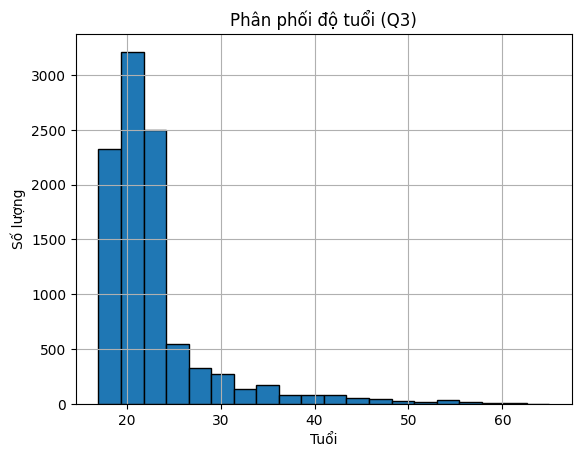

In [93]:
plt.hist(df_valid["Q3"], bins=20, edgecolor='black')
plt.title("Phân phối độ tuổi (Q3)")
plt.xlabel("Tuổi")
plt.ylabel("Số lượng")
plt.grid(True)
plt.show()

Loại bỏ outlier tuổi

In [94]:
df_valid = df_valid[(df_valid["Q3"] >= 15) & (df_valid["Q3"] <= 60)]

In [96]:
print("Số dòng sau khi loại outlier tuổi:", df_valid.shape[0])

Số dòng sau khi loại outlier tuổi: 9915


In [97]:
df = df_valid

# Chuyển đổi tên cột

Xem tên các cột

In [98]:
print(df.columns.tolist())

['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18a', 'Q18b', 'Q18c', 'Q18d', 'Q18e', 'Q18f', 'Q18g', 'Q18h', 'Q18i', 'Q18j', 'Q18k', 'Q18l', 'Q19a', 'Q19b', 'Q19c', 'Q19d', 'Q19e', 'Q19f', 'Q19g', 'Q19h', 'Q19i', 'Q19j', 'Q20', 'Q21a', 'Q21b', 'Q21c', 'Q21d', 'Q22a', 'Q22b', 'Q22c', 'Q22d', 'Q22e', 'Q22f', 'Q22g', 'Q22h', 'Q22i', 'Q22j', 'Q23a', 'Q23b', 'Q23c', 'Q23d', 'Q24a', 'Q24b', 'Q24c', 'Q24d', 'Q24e', 'Q24f', 'Q24g', 'Q25a', 'Q25b', 'Q25c', 'Q25d', 'Q26a', 'Q26b', 'Q26c', 'Q26d', 'Q26e', 'Q26f', 'Q26g', 'Q26h', 'Q26i', 'Q26j', 'Q27a', 'Q27b', 'Q27c', 'Q27d', 'Q27e', 'Q27f', 'Q27g', 'Q27h', 'Q27i', 'Q27j', 'Q28a', 'Q28b', 'Q28c', 'Q28d', 'Q28e', 'Q28f', 'Q28g', 'Q28h', 'Q28i', 'Q29a', 'Q29b', 'Q29c', 'Q29d', 'Q29e', 'Q29f', 'Q29g', 'Q29h', 'Q29i', 'Q30a', 'Q30b', 'Q30c', 'Q30d', 'Q30e', 'Q30f', 'Q30g', 'Q30h', 'Q30i', 'Q30j', 'Q30k', 'Q30l', 'Q31a', 'Q31b', 'Q31c', 'Q31d', 'Q32a', 'Q32b', 'Q32c', 'Q32d', 'Q32e', 'Q

Đổi tên cột

In [99]:
rename_dict = {
    # SECTION 1: SOCIODEMOGRAPHIC CHARACTERISTICS
    'Q1': 'Citizenship',
    'Q2': 'Gender',
    'Q3': 'Age',
    'Q4': 'Study_Country',
    'Q5': 'Institution_Name',
    'Q6': 'Institution_Public',
    'Q7': 'Student_Status',
    'Q8': 'Level_Of_Study',
    'Q9': 'First_Year_Student',
    'Q10': 'Field_Of_Study',
    'Q11': 'Learning_Method',
    'Q12': 'Job_Confidence',

    # SECTION 2: USAGE
    'Q13': 'Used_ChatGPT',
    'Q14': 'ChatGPT_Version',
    'Q15': 'Usage_Frequency',
    'Q16': 'Overall_Experience',
    'Q17': 'How_Did_You_Learn_About_ChatGPT',
    **{f'Q18{c}': f'Usage_{desc}' for c, desc in zip("abcdefghijkl", [
        'Academic_Writing', 'Professional_Writing', 'Creative_Writing', 'Proofreading',
        'Brainstorming', 'Translating', 'Summarizing', 'Calculating_Help',
        'Study_Assistance', 'Personal_Assistance', 'Research_Assistance', 'Coding_Assistance'])},

    # SECTION 3: CAPABILITIES
    **{f'Q19{c}': f'Capability_{desc}' for c, desc in zip("abcdefghij", [
        'Understand_Human_Language', 'Respond_Human_Language', 'Pleasant_Conversation',
        'Provide_Information_Efficiently', 'Provide_Reliable_Information', 'Summarize_Info',
        'Simplify_Complex_Info', 'Facilitate_Traditional_Learning', 'Facilitate_Online_Learning',
        'Facilitate_Blended_Learning'])},

    'Q20': 'Institution_Has_Policy',
    **{f'Q21{c}': f'Regulation_{desc}' for c, desc in zip("abcd", [
        'Need_International_Regulation', 'Need_Gov_Regulation',
        'Need_University_Guidelines', 'Need_Employer_Guidelines'])},
    **{f'Q22{c}': f'Ethical_Concern_{desc}' for c, desc in zip("abcdefghij", [
        'Encourage_Unethical_Behavior', 'Encourage_Cheating', 'Encourage_Plagiarism',
        'Threaten_Ethics', 'Mislead_Info', 'Invade_Privacy', 'Reduce_Interaction',
        'Replace_Education', 'Increase_Isolation', 'Hinder_Learning'])},
    **{f'Q23{c}': f'Student_Ethics_{desc}' for c, desc in zip("abcd", [
        'Consult_Professors', 'Disclose_Use', 'Report_Misuse', 'Protect_Personal_Info'])},

    # SECTION 5: SATISFACTION AND ATTITUDE
    **{f'Q24{c}': f'Satisfaction_{desc}' for c, desc in zip("abcdefg", [
        'More_Useful_Than_Google', 'Easier_Than_Professors', 'Easier_Than_Colleagues',
        'Clearer_Than_Professors', 'Satisfied_Assistance', 'Satisfied_Quality', 'Satisfied_Accuracy'])},
    **{f'Q25{c}': f'Attitude_{desc}' for c, desc in zip("abcd", [
        'Using_Under_Control', 'Interesting', 'Important_To_Use', 'Helps_Everyday_Life'])},

    # SECTION 6–9: Learning, Skills, Labour
    **{f'Q26{c}': f'Learning_{i}' for i, c in enumerate("abcdefghij", 1)},
    **{f'Q27{c}': f'Development_{i}' for i, c in enumerate("abcdefghij", 1)},
    **{f'Q28{c}': f'Skills_Proficiency_{i}' for i, c in enumerate("abcdefghi", 1)},
    **{f'Q29{c}': f'Skills_Analytical_{i}' for i, c in enumerate("abcdefghi", 1)},
    **{f'Q30{c}': f'LabourMarket_{i}' for i, c in enumerate("abcdefghijkl", 1)},
    **{f'Q31{c}': f'SkillsMismatch_{i}' for i, c in enumerate("abcd", 1)},

    # SECTION 9–10
    **{f'Q32{c}': f'Emotion_{i}' for i, c in enumerate("abcdefghijklmno", 1)},
    'Q33': 'Study_Difficulty',
    'Q34': 'Preferred_Learning_Method',
    **{f'Q35{c}': f'Study_Info_{i}' for i, c in enumerate("abcdefghijklmno", 1)},
    'Q36': 'Living_Area',
    'Q37': 'Financial_Aid',
    'Q38': 'Have_Job',
    'Q39': 'Economic_Status',
    **{f'Q40{c}': f'Personality_{i}' for i, c in enumerate("abcdefghijklmno", 1)},
    'source': 'Country_Code'
}

In [100]:
df = df.rename(columns=rename_dict)

# Chuyển mã số sang giá trị có ý nghĩa

In [101]:
likert_5 = {
    1: "Strongly disagree", 2: "Disagree", 3: "Neutral", 4: "Agree", 5: "Strongly agree"
}
likert_5_frequency = {
    1: "Never", 2: "Rarely", 3: "Sometimes", 4: "Often", 5: "Always"
}
likert_5_experience = {
    1: "Very bad", 2: "Bad", 3: "Neutral", 4: "Good", 5: "Very good"
}
likert_5_confidence = {
    1: "Not at all confident", 2: "Slightly confident", 3: "Moderately confident",
    4: "Very confident", 5: "Extremely confident"
}
likert_5_difficulty = {
    1: "Much too easy", 2: "Somewhat easy", 3: "Just about right",
    4: "Somewhat challenging", 5: "Extremely challenging"
}

def safe_map(colname, mapping):
    if colname in df.columns and df[colname].dtype in ['int64', 'float64']:
        df[colname] = df[colname].map(mapping)

safe_map('Gender', {1: "Male", 2: "Female", 3: "Other", 4: "Prefer not to say"})
safe_map('Institution_Public', {1: "Yes", 2: "No"})
safe_map('Student_Status', {1: "Full-time", 2: "Part-time"})
safe_map('Level_Of_Study', {1: "Undergraduate", 2: "Postgraduate", 3: "Doctoral"})
safe_map('First_Year_Student', {1: "Yes", 2: "No"})
safe_map('Field_Of_Study', {1: "Arts and Humanities", 2: "Social Sciences", 3: "Applied Sciences", 4: "Natural and Life Sciences"})
safe_map('Learning_Method', {1: "Traditional", 2: "Online", 3: "Blended"})
safe_map('Job_Confidence', likert_5_confidence)
safe_map('Used_ChatGPT', {1: "Yes", 2: "No"})
safe_map('ChatGPT_Version', {1: "ChatGPT-3.5", 2: "ChatGPT-4", 3: "Both"})
safe_map('Usage_Frequency', {1: "Rarely", 2: "Occasionally", 3: "Moderately", 4: "Considerably", 5: "Extensively"})
safe_map('Overall_Experience', likert_5_experience)
safe_map('How_Did_You_Learn_About_ChatGPT', {1: "Mainstream media", 2: "Social media", 3: "In class or work", 4: "Friends or family"})
safe_map('Institution_Has_Policy', {1: "Yes", 2: "No", 3: "I don't know"})
safe_map('Study_Difficulty', likert_5_difficulty)
safe_map('Preferred_Learning_Method', {1: "Traditional", 2: "Online", 3: "Blended"})
safe_map('Living_Area', {1: "Urban", 2: "Suburban", 3: "Rural"})
safe_map('Financial_Aid', {1: "Yes", 2: "No"})
safe_map('Have_Job', {1: "Full-time", 2: "Part-time", 3: "No"})
safe_map('Economic_Status', {1: "Significantly below-average", 2: "Below-average", 3: "Average", 4: "Above-average", 5: "Significantly above-average"})

valid_likert_values = [1, 2, 3, 4, 5]
columns_likert_agree = [col for col in df.columns if col.startswith((
    'Capability_', 'Regulation_', 'Ethical_Concern_', 'Student_Ethics_',
    'Satisfaction_', 'Attitude_', 'Learning_', 'Development_', 'Skills_Proficiency_',
    'Skills_Analytical_', 'LabourMarket_', 'SkillsMismatch_', 'Study_Info_', 'Personality_'))]
columns_likert_frequency = [col for col in df.columns if col.startswith(('Usage_', 'Emotion_'))]

for col in columns_likert_agree:
    if col in df.columns and df[col].dropna().isin(valid_likert_values).all():
        df[col] = df[col].map(likert_5)

for col in columns_likert_frequency:
    if col in df.columns and df[col].dropna().isin(valid_likert_values).all():
        df[col] = df[col].map(likert_5_frequency)

In [102]:
df

,Citizenship,Gender,Age,Study_Country,Institution_Name,Institution_Public,Student_Status,Level_Of_Study,First_Year_Student,Field_Of_Study,...,Personality_7,Personality_8,Personality_9,Personality_10,Personality_11,Personality_12,Personality_13,Personality_14,Personality_15,Country_Code
4,Afghanistan,Female,26.0,Spain,University of Vigo,Yes,Part-time,Postgraduate,Yes,Social Sciences,...,Agree,Neutral,Agree,Neutral,Neutral,Neutral,Agree,Neutral,Agree,ES
6,Afghanistan,Female,21.0,Turkey,Cumhuriyet University,Yes,Full-time,Undergraduate,No,Social Sciences,...,Disagree,Agree,Agree,Agree,Agree,Agree,Neutral,Neutral,Neutral,TR
7,Afghanistan,Female,21.0,Turkey,Cumhuriyet University,Yes,Full-time,Undergraduate,No,Arts and Humanities,...,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Disagree,Agree,TR
9,Afghanistan,Female,23.0,Turkey,Sivas Cumhuriyet University,Yes,Full-time,Undergraduate,Yes,Arts and Humanities,...,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,TR
16,Albania,Female,18.0,Albania,University of Korça,Yes,Full-time,Undergraduate,Yes,Social Sciences,...,Strongly agree,Agree,Agree,Strongly agree,Agree,Agree,Disagree,Agree,Agree,EN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23070,Unknown,Female,21.0,Zimbabwe,Midlands State University,Yes,Full-time,Undergraduate,No,Applied Sciences,...,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Strongly agree,Agree,EN
23071,Unknown,Female,21.0,Zimbabwe,Midlands State University,Yes,Full-time,Undergraduate,No,Applied Sciences,...,Strongly agree,Strongly agree,Agree,Strongly agree,Neutral,Strongly agree,Agree,Strongly agree,Agree,EN
23096,Unknown,Female,21.0,Unknown,Minia University,Yes,Part-time,Undergraduate,Yes,Social Sciences,...,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Neutral,Strongly agree,AR
23122,Unknown,Female,24.0,Unknown,Unknown,Yes,Full-time,Undergraduate,No,Social Sciences,...,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,EN


# Tạo cột điểm trung bình từ tất cả các câu hỏi liên quan đến mức độ hài lòng (dạng Likert 5 điểm)

Lọc các cột dạng Satisfaction để gộp thành điểm trung bình

In [103]:
satisfaction_cols = [col for col in df.columns if "Satisfaction" in col and df[col].dtype == "object"]

Chuyển lại các giá trị Likert dạng text sang số

In [104]:
likert_mapping = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5
}

Chuyển đổi từng cột Satisfaction từ text sang số

In [105]:
df_numeric = df[satisfaction_cols].replace(likert_mapping).infer_objects(copy=False)

C:\Users\ace\AppData\Local\Temp\ipykernel_17924\3032120576.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric = df[satisfaction_cols].replace(likert_mapping).infer_objects(copy=False)


Tính điểm trung bình của các mức độ hài lòng

In [106]:
df = df.copy()

In [107]:
df["Satisfaction_Score"] = df_numeric.mean(axis=1).round(2)

In [108]:
df

,Citizenship,Gender,Age,Study_Country,Institution_Name,Institution_Public,Student_Status,Level_Of_Study,First_Year_Student,Field_Of_Study,...,Personality_8,Personality_9,Personality_10,Personality_11,Personality_12,Personality_13,Personality_14,Personality_15,Country_Code,Satisfaction_Score
4,Afghanistan,Female,26.0,Spain,University of Vigo,Yes,Part-time,Postgraduate,Yes,Social Sciences,...,Neutral,Agree,Neutral,Neutral,Neutral,Agree,Neutral,Agree,ES,3.43
6,Afghanistan,Female,21.0,Turkey,Cumhuriyet University,Yes,Full-time,Undergraduate,No,Social Sciences,...,Agree,Agree,Agree,Agree,Agree,Neutral,Neutral,Neutral,TR,3.57
7,Afghanistan,Female,21.0,Turkey,Cumhuriyet University,Yes,Full-time,Undergraduate,No,Arts and Humanities,...,Agree,Agree,Agree,Agree,Agree,Agree,Disagree,Agree,TR,4.71
9,Afghanistan,Female,23.0,Turkey,Sivas Cumhuriyet University,Yes,Full-time,Undergraduate,Yes,Arts and Humanities,...,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,TR,3.00
16,Albania,Female,18.0,Albania,University of Korça,Yes,Full-time,Undergraduate,Yes,Social Sciences,...,Agree,Agree,Strongly agree,Agree,Agree,Disagree,Agree,Agree,EN,3.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23070,Unknown,Female,21.0,Zimbabwe,Midlands State University,Yes,Full-time,Undergraduate,No,Applied Sciences,...,Agree,Agree,Agree,Agree,Agree,Agree,Strongly agree,Agree,EN,3.29
23071,Unknown,Female,21.0,Zimbabwe,Midlands State University,Yes,Full-time,Undergraduate,No,Applied Sciences,...,Strongly agree,Agree,Strongly agree,Neutral,Strongly agree,Agree,Strongly agree,Agree,EN,2.57
23096,Unknown,Female,21.0,Unknown,Minia University,Yes,Part-time,Undergraduate,Yes,Social Sciences,...,Agree,Agree,Agree,Agree,Agree,Agree,Neutral,Strongly agree,AR,4.00
23122,Unknown,Female,24.0,Unknown,Unknown,Yes,Full-time,Undergraduate,No,Social Sciences,...,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,EN,3.71


Phân loại mức độ hài lòng theo các mốc Very low, Low, Neutral, High, Very high

In [109]:
bins = [0, 2, 3, 3.5, 4.25, 5.01]
labels = ["Very low", "Low", "Neutral", "High", "Very high"]

In [110]:
satisfaction_level = pd.cut(df["Satisfaction_Score"], bins=bins, labels=labels, right=False)
df = pd.concat([df, satisfaction_level.rename("Satisfaction_Level")], axis=1)

In [111]:
df

,Citizenship,Gender,Age,Study_Country,Institution_Name,Institution_Public,Student_Status,Level_Of_Study,First_Year_Student,Field_Of_Study,...,Personality_9,Personality_10,Personality_11,Personality_12,Personality_13,Personality_14,Personality_15,Country_Code,Satisfaction_Score,Satisfaction_Level
4,Afghanistan,Female,26.0,Spain,University of Vigo,Yes,Part-time,Postgraduate,Yes,Social Sciences,...,Agree,Neutral,Neutral,Neutral,Agree,Neutral,Agree,ES,3.43,Neutral
6,Afghanistan,Female,21.0,Turkey,Cumhuriyet University,Yes,Full-time,Undergraduate,No,Social Sciences,...,Agree,Agree,Agree,Agree,Neutral,Neutral,Neutral,TR,3.57,High
7,Afghanistan,Female,21.0,Turkey,Cumhuriyet University,Yes,Full-time,Undergraduate,No,Arts and Humanities,...,Agree,Agree,Agree,Agree,Agree,Disagree,Agree,TR,4.71,Very high
9,Afghanistan,Female,23.0,Turkey,Sivas Cumhuriyet University,Yes,Full-time,Undergraduate,Yes,Arts and Humanities,...,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,TR,3.00,Neutral
16,Albania,Female,18.0,Albania,University of Korça,Yes,Full-time,Undergraduate,Yes,Social Sciences,...,Agree,Strongly agree,Agree,Agree,Disagree,Agree,Agree,EN,3.86,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23070,Unknown,Female,21.0,Zimbabwe,Midlands State University,Yes,Full-time,Undergraduate,No,Applied Sciences,...,Agree,Agree,Agree,Agree,Agree,Strongly agree,Agree,EN,3.29,Neutral
23071,Unknown,Female,21.0,Zimbabwe,Midlands State University,Yes,Full-time,Undergraduate,No,Applied Sciences,...,Agree,Strongly agree,Neutral,Strongly agree,Agree,Strongly agree,Agree,EN,2.57,Low
23096,Unknown,Female,21.0,Unknown,Minia University,Yes,Part-time,Undergraduate,Yes,Social Sciences,...,Agree,Agree,Agree,Agree,Agree,Neutral,Strongly agree,AR,4.00,High
23122,Unknown,Female,24.0,Unknown,Unknown,Yes,Full-time,Undergraduate,No,Social Sciences,...,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,EN,3.71,High


# Thêm cột Birthday_Year chuyển đổi tuổi sang năm sinh và xoá cột Age

Chuyển đổi tuổi sang năm sinh

In [112]:
df = df.copy()

In [113]:
current_year = datetime.now().year
df['Birthday_Year'] = current_year - df['Age']

Thay cột Age thành Birthday_Year

In [114]:
cols = list(df.columns)
if 'Birthday_Year' in cols and 'Gender' in cols:
    gender_index = cols.index('Gender')
    cols.insert(gender_index + 1, cols.pop(cols.index('Birthday_Year')))
    df = df[cols]

In [115]:
df = df.drop(columns=['Age'])

In [116]:
df.head(5)

,Citizenship,Gender,Birthday_Year,Study_Country,Institution_Name,Institution_Public,Student_Status,Level_Of_Study,First_Year_Student,Field_Of_Study,...,Personality_9,Personality_10,Personality_11,Personality_12,Personality_13,Personality_14,Personality_15,Country_Code,Satisfaction_Score,Satisfaction_Level
4,Afghanistan,Female,1999.0,Spain,University of Vigo,Yes,Part-time,Postgraduate,Yes,Social Sciences,...,Agree,Neutral,Neutral,Neutral,Agree,Neutral,Agree,ES,3.43,Neutral
6,Afghanistan,Female,2004.0,Turkey,Cumhuriyet University,Yes,Full-time,Undergraduate,No,Social Sciences,...,Agree,Agree,Agree,Agree,Neutral,Neutral,Neutral,TR,3.57,High
7,Afghanistan,Female,2004.0,Turkey,Cumhuriyet University,Yes,Full-time,Undergraduate,No,Arts and Humanities,...,Agree,Agree,Agree,Agree,Agree,Disagree,Agree,TR,4.71,Very high
9,Afghanistan,Female,2002.0,Turkey,Sivas Cumhuriyet University,Yes,Full-time,Undergraduate,Yes,Arts and Humanities,...,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,TR,3.00,Neutral
16,Albania,Female,2007.0,Albania,University of Korça,Yes,Full-time,Undergraduate,Yes,Social Sciences,...,Agree,Strongly agree,Agree,Agree,Disagree,Agree,Agree,EN,3.86,High


# Tạo cột phân ra các nhóm tuổi

In [117]:
df = df.copy()

In [118]:
df["Age_Group"] = pd.cut(
    x=(datetime.now().year - df["Birthday_Year"]),  # Tính tuổi trực tiếp
    bins=[0, 17, 21, 25, 30, 100],
    labels=["<18", "18-21", "22-25", "26-30", ">30"],
    right=True
)

In [119]:
df

,Citizenship,Gender,Birthday_Year,Study_Country,Institution_Name,Institution_Public,Student_Status,Level_Of_Study,First_Year_Student,Field_Of_Study,...,Personality_10,Personality_11,Personality_12,Personality_13,Personality_14,Personality_15,Country_Code,Satisfaction_Score,Satisfaction_Level,Age_Group
4,Afghanistan,Female,1999.0,Spain,University of Vigo,Yes,Part-time,Postgraduate,Yes,Social Sciences,...,Neutral,Neutral,Neutral,Agree,Neutral,Agree,ES,3.43,Neutral,26-30
6,Afghanistan,Female,2004.0,Turkey,Cumhuriyet University,Yes,Full-time,Undergraduate,No,Social Sciences,...,Agree,Agree,Agree,Neutral,Neutral,Neutral,TR,3.57,High,18-21
7,Afghanistan,Female,2004.0,Turkey,Cumhuriyet University,Yes,Full-time,Undergraduate,No,Arts and Humanities,...,Agree,Agree,Agree,Agree,Disagree,Agree,TR,4.71,Very high,18-21
9,Afghanistan,Female,2002.0,Turkey,Sivas Cumhuriyet University,Yes,Full-time,Undergraduate,Yes,Arts and Humanities,...,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,TR,3.00,Neutral,22-25
16,Albania,Female,2007.0,Albania,University of Korça,Yes,Full-time,Undergraduate,Yes,Social Sciences,...,Strongly agree,Agree,Agree,Disagree,Agree,Agree,EN,3.86,High,18-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23070,Unknown,Female,2004.0,Zimbabwe,Midlands State University,Yes,Full-time,Undergraduate,No,Applied Sciences,...,Agree,Agree,Agree,Agree,Strongly agree,Agree,EN,3.29,Neutral,18-21
23071,Unknown,Female,2004.0,Zimbabwe,Midlands State University,Yes,Full-time,Undergraduate,No,Applied Sciences,...,Strongly agree,Neutral,Strongly agree,Agree,Strongly agree,Agree,EN,2.57,Low,18-21
23096,Unknown,Female,2004.0,Unknown,Minia University,Yes,Part-time,Undergraduate,Yes,Social Sciences,...,Agree,Agree,Agree,Agree,Neutral,Strongly agree,AR,4.00,High,18-21
23122,Unknown,Female,2001.0,Unknown,Unknown,Yes,Full-time,Undergraduate,No,Social Sciences,...,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,EN,3.71,High,22-25


# Xử lý dữ liệu mất cân bằng cho cột Satisfaction_Level (mức độ hài lòng)

In [120]:
print(df.columns.tolist())

['Citizenship', 'Gender', 'Birthday_Year', 'Study_Country', 'Institution_Name', 'Institution_Public', 'Student_Status', 'Level_Of_Study', 'First_Year_Student', 'Field_Of_Study', 'Learning_Method', 'Job_Confidence', 'Used_ChatGPT', 'ChatGPT_Version', 'Usage_Frequency', 'Overall_Experience', 'How_Did_You_Learn_About_ChatGPT', 'Usage_Academic_Writing', 'Usage_Professional_Writing', 'Usage_Creative_Writing', 'Usage_Proofreading', 'Usage_Brainstorming', 'Usage_Translating', 'Usage_Summarizing', 'Usage_Calculating_Help', 'Usage_Study_Assistance', 'Usage_Personal_Assistance', 'Usage_Research_Assistance', 'Usage_Coding_Assistance', 'Capability_Understand_Human_Language', 'Capability_Respond_Human_Language', 'Capability_Pleasant_Conversation', 'Capability_Provide_Information_Efficiently', 'Capability_Provide_Reliable_Information', 'Capability_Summarize_Info', 'Capability_Simplify_Complex_Info', 'Capability_Facilitate_Traditional_Learning', 'Capability_Facilitate_Online_Learning', 'Capability_Fa

Chọn cột nhãn (ví dụ: Satisfaction_Level)

In [121]:
target_col = "Satisfaction_Level"

Tách X và y

In [122]:
X = df.drop(columns=[target_col])
y = df[target_col]

Tách dữ liệu số và dữ liệu phân loại

In [123]:
num_cols = X.select_dtypes(include=['number']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

Xử lý dữ liệu số: thay giá trị thiếu bằng mean

In [124]:
num_imputer = SimpleImputer(strategy="mean")
X_num = pd.DataFrame(num_imputer.fit_transform(X[num_cols]), columns=num_cols)

Xử lý dữ liệu phân loại: thay giá trị thiếu bằng most_frequent

In [125]:
X_cat_valid = X[cat_cols].dropna(axis=1, how='all')  # Loại bỏ các cột toàn NaN
cat_imputer = SimpleImputer(strategy="most_frequent")
X_cat_array = cat_imputer.fit_transform(X_cat_valid)

Tạo DataFrame đúng kích thước

In [126]:
X_cat_filled = pd.DataFrame(X_cat_array, columns=X_cat_valid.columns)

Mã hóa từng cột phân loại

In [127]:
from sklearn.preprocessing import LabelEncoder
for col in X_cat_filled.columns:
    le = LabelEncoder()
    X_cat_filled[col] = le.fit_transform(X_cat_filled[col])

Ghép lại X

In [128]:
X_processed = pd.concat([X_num, X_cat_filled], axis=1)

Chuẩn hóa

In [129]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_processed)

SMOTE để cân bằng

In [130]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

In [131]:
print("Trước SMOTE:", Counter(y))
print("Sau SMOTE:", Counter(y_resampled))

Trước SMOTE: Counter({'Neutral': 3379, 'Low': 3183, 'High': 2157, 'Very high': 599, 'Very low': 597})
Sau SMOTE: Counter({'Neutral': 3379, 'High': 3379, 'Very high': 3379, 'Low': 3379, 'Very low': 3379})


# Lưu file sau khi làm sạch

In [132]:
df.to_excel("final_data.xlsx", index=False)

# Phân bố giới tính, độ tuổi, mức sử dụng

Biểu đồ: Phân bố giới tính

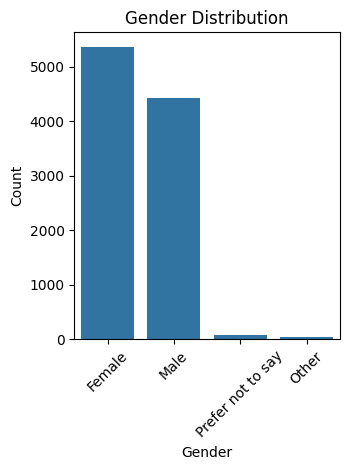

In [133]:
plt.subplot(1, 2, 1)
gender_counts = df["Gender"].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values)
plt.title("Gender Distribution")
plt.ylabel("Count")
plt.xlabel("Gender")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Biểu đồ: Phân bố quốc gia

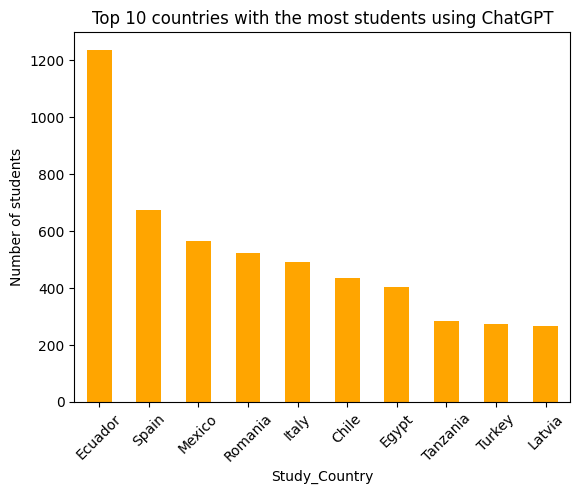

In [134]:
country_counts = df['Study_Country'].value_counts().sort_values(ascending=True)
top10 = country_counts.sort_values(ascending=False).head(10)
top10.plot(kind='bar', color='orange')
plt.title("Top 10 countries with the most students using ChatGPT")
plt.ylabel("Number of students")
plt.xticks(rotation=45)
plt.show()

Biển đồ: Phân bố các nhóm tuổi

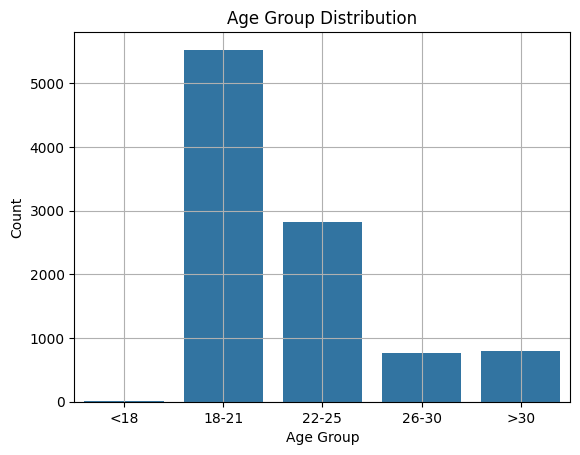

In [135]:
sns.countplot(data=df, x="Age_Group", order=["<18", "18-21", "22-25", "26-30", ">30"])
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.grid(True)
plt.show()

Biểu đồ: Phân bố mức độ sử dụng ChatGPT

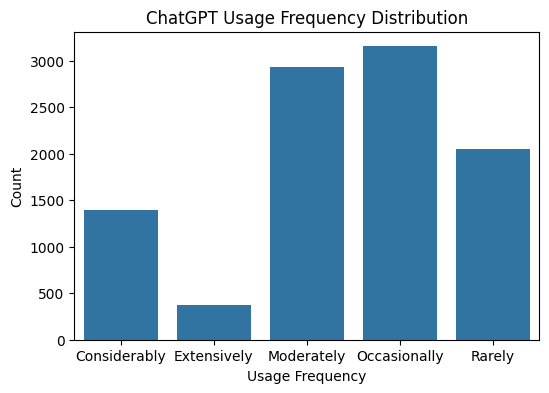

In [136]:
plt.figure(figsize=(6, 4))
usage_col = next(col for col in df.columns if "Usage_Frequency" in col and df[col].nunique() <= 10)
usage_counts = df[usage_col].value_counts().sort_index()
sns.barplot(x=usage_counts.index, y=usage_counts.values)
plt.title("ChatGPT Usage Frequency Distribution")
plt.ylabel("Count")
plt.xlabel("Usage Frequency")
plt.show()

Biểu đồ: Phân phối theo ngành

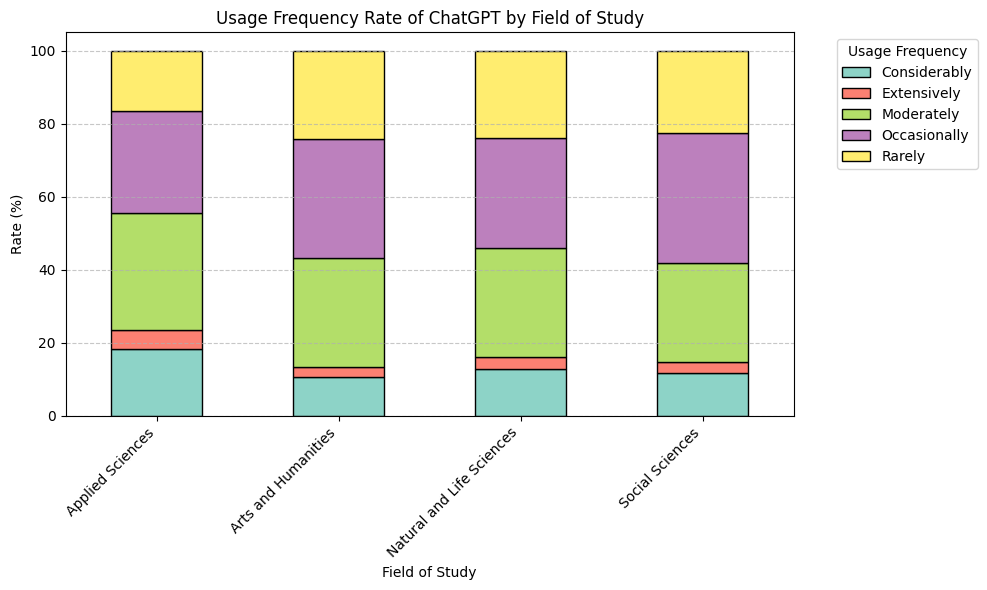

In [137]:
usage_by_field = df.groupby(['Field_Of_Study', 'Usage_Frequency']).size().unstack(fill_value=0)

usage_by_field_pct = usage_by_field.div(usage_by_field.sum(axis=1), axis=0) * 100

ax1 = usage_by_field_pct.plot(kind='bar', 
                            stacked=True, 
                            figsize=(10, 6), 
                            colormap='Set3',
                            edgecolor='black')

plt.title("Usage Frequency Rate of ChatGPT by Field of Study")
plt.xlabel("Field of Study")
plt.ylabel("Rate (%)")
plt.legend(title="Usage Frequency", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Biểu đồ: Phân bố cảm xúc

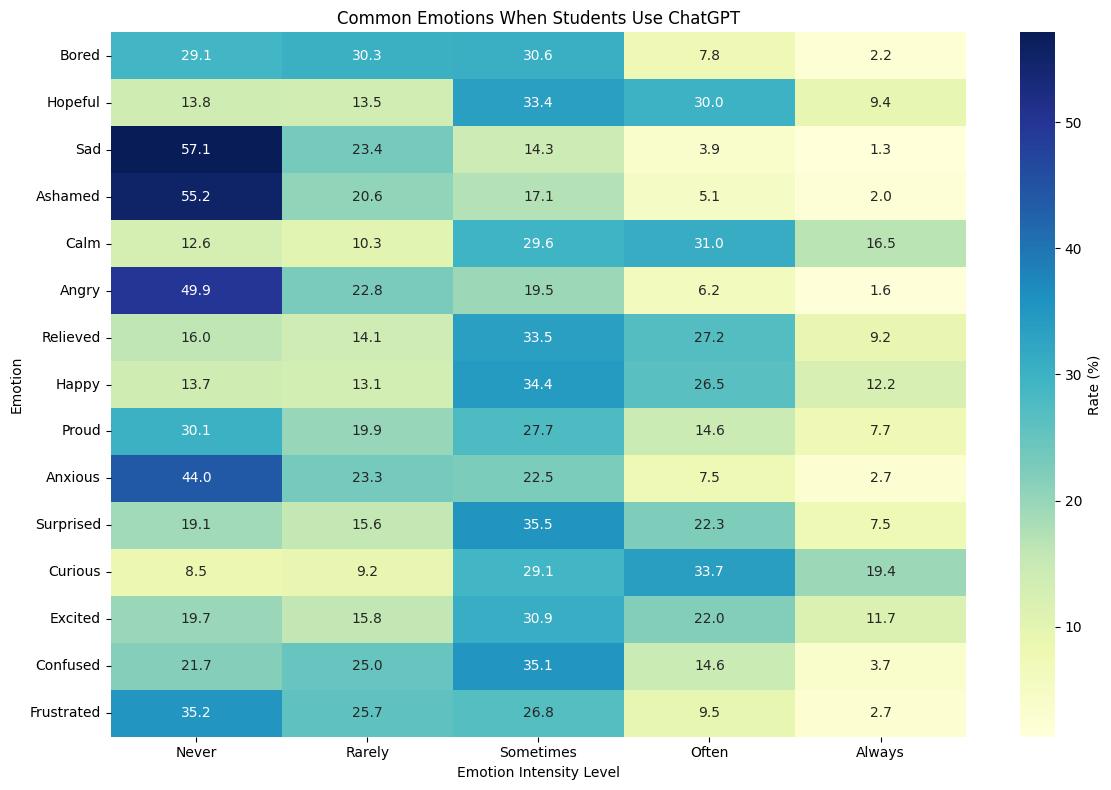

In [138]:
emotion_cols = [col for col in df.columns if col.startswith('Emotion_')]
emotion_order = ["Never", "Rarely", "Sometimes", "Often", "Always"]

emotion_counts = {}
for col in emotion_cols:
    if col in df.columns:
        counts = df[col].value_counts().reindex(emotion_order, fill_value=0)
        emotion_counts[col] = counts

emotion_df = pd.DataFrame(emotion_counts).T
emotion_df.index = [
    "Bored", "Hopeful", "Sad", "Ashamed", "Calm", "Angry", "Relieved", "Happy",
    "Proud", "Anxious", "Surprised", "Curious", "Excited", "Confused", "Frustrated"
]

emotion_pct = emotion_df.div(emotion_df.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 8))
sns.heatmap(emotion_pct, annot=True, cmap="YlGnBu", fmt=".1f", cbar_kws={'label': 'Rate (%)'})
plt.title("Common Emotions When Students Use ChatGPT")
plt.xlabel("Emotion Intensity Level")
plt.ylabel("Emotion")
plt.tight_layout()
plt.show()

# So sánh mức độ hài lòng của các quốc gia và thống kê theo thứ tự giảm dần

Thống kê độ hài lòng trung bình

In [139]:
country_stats = (
    df.groupby('Study_Country')
    .agg(Mean_Satisfaction=('Satisfaction_Score', 'mean'),
        Count=('Satisfaction_Score', 'count'))
    .sort_values(by='Mean_Satisfaction', ascending=False)
)

In [140]:
country_stats.head(5)

,Mean_Satisfaction,Count
Study_Country,,
Sweden,4.430000,1
Estonia,3.957895,114
Oman,3.819091,11
Rwanda,3.802000,5
Andorra,3.785000,2


Lọc ra các quốc gia có ít nhất 30 người tham gia khảo sát để giữ lại các thống kê điểm hài lòng đáng tin cậy.

In [141]:
filtered_stats = country_stats[country_stats['Count'] >= 30]

In [142]:
filtered_stats.head(5)

,Mean_Satisfaction,Count
Study_Country,,
Estonia,3.957895,114
Zimbabwe,3.664694,49
Bangladesh,3.506320,125
Egypt,3.473259,402
Algeria,3.424194,62


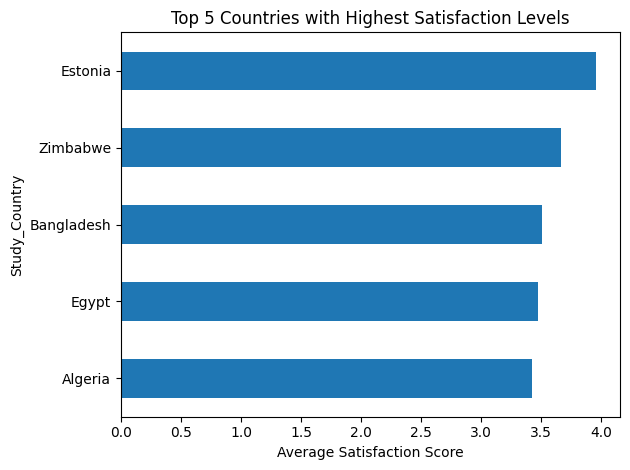

In [143]:
filtered_stats.head(5).plot(kind='barh', y='Mean_Satisfaction', legend=False)
plt.title('Top 5 Countries with Highest Satisfaction Levels')
plt.xlabel('Average Satisfaction Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# So sánh mức độ hài lòng của các ngành và thống kê theo thứ tự giảm dần

Tính mức độ hài lòng trung bình theo ngành

In [144]:
field_stats = (
    df.groupby('Field_Of_Study')
    .agg(Mean_Satisfaction=('Satisfaction_Score', 'mean'),
        Count=('Satisfaction_Score', 'count'))
    .sort_values(by='Mean_Satisfaction', ascending=False)
)

In [145]:
field_stats.head(5)

,Mean_Satisfaction,Count
Field_Of_Study,,
Applied Sciences,3.157021,3622
Arts and Humanities,3.056571,1184
Natural and Life Sciences,3.052050,1073
Social Sciences,3.043320,4036


 Lọc các ngành có ≥ 30 người trả lời

In [146]:
filtered_fields = field_stats[field_stats['Count'] >= 30]

In [147]:
filtered_fields.head(5)

,Mean_Satisfaction,Count
Field_Of_Study,,
Applied Sciences,3.157021,3622
Arts and Humanities,3.056571,1184
Natural and Life Sciences,3.052050,1073
Social Sciences,3.043320,4036


Vẽ biểu đồ mức độ hài lòng theo ngành học

In [148]:
data_to_plot = field_stats.copy()

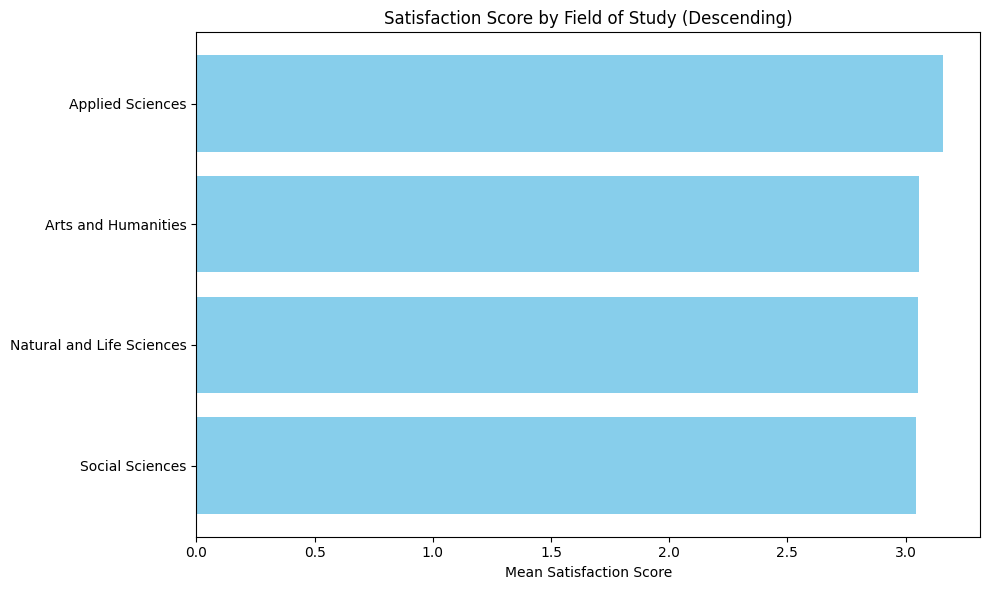

In [149]:
plt.figure(figsize=(10, 6))
plt.barh(data_to_plot.index, data_to_plot['Mean_Satisfaction'], color='skyblue')
plt.xlabel("Mean Satisfaction Score")
plt.title("Satisfaction Score by Field of Study (Descending)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# So sánh mức độ sử dụng ở các quốc gia và thống kê theo mức độ giảm dần

Chuyển đổi dữ liệu từ chữ -> số

In [150]:
df = df.copy()

In [151]:
usage_mapping = {
    'Rarely': 1,
    'Occasionally': 2,
    'Moderately': 3,
    'Considerably': 4,
    'Extensively': 5
}

In [152]:
df['Usage_Score'] = df['Usage_Frequency'].map(usage_mapping)

In [153]:
usage_by_country = (
    df.groupby('Study_Country')['Usage_Score']
    .mean()
    .sort_values(ascending=False)
)

In [154]:
usage_by_country.head(5)

Study_Country
Bahrain           4.000000
Bahamas           4.000000
Czech Republic    4.000000
Chad              4.000000
Colombia          3.626168
Name: Usage_Score, dtype: float64

In [155]:
country_usage_stats = (
    df.groupby('Study_Country')
    .agg(Mean_Usage=('Usage_Score', 'mean'),
        Count=('Usage_Score', 'count'))
    .sort_values(by='Mean_Usage', ascending=False)
)

In [156]:
filtered_stats = country_usage_stats[country_usage_stats['Count'] >= 30]

In [157]:
filtered_stats.head(5)

,Mean_Usage,Count
Study_Country,,
Colombia,3.626168,107
Estonia,3.596491,114
Malaysia,3.115385,52
Zimbabwe,2.938776,49
Egypt,2.825871,402


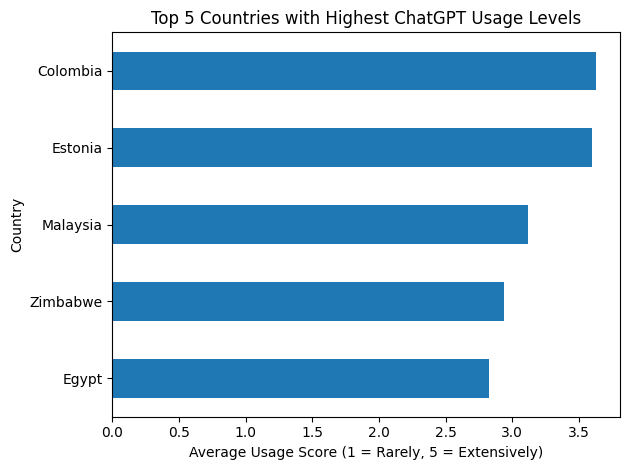

In [158]:
filtered_stats.head(5).plot(kind='barh', y='Mean_Usage', legend=False)
plt.title('Top 5 Countries with Highest ChatGPT Usage Levels')
plt.xlabel('Average Usage Score (1 = Rarely, 5 = Extensively)')
plt.ylabel('Country')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Xử lý đặc trưng và phân cụm người dùng

Xử lý đặc trưng và chuẩn hoá các cột 'Usage_'

In [159]:
# Ánh xạ thanh likert sang số
selected_columns = [
    f'Usage_{desc}' for desc in [
        'Academic_Writing', 'Professional_Writing', 'Creative_Writing', 'Proofreading',
        'Brainstorming', 'Translating', 'Summarizing', 'Calculating_Help',
        'Study_Assistance', 'Personal_Assistance', 'Research_Assistance', 'Coding_Assistance'
    ]
]

likert_map = {
    "Never": 1,
    "Rarely": 2,
    "Sometimes": 3,
    "Often": 4,
    "Always": 5
}

df_features = pd.DataFrame()
for col in selected_columns:
    df_features[col] = df[col].map(likert_map)

df_features = df_features.apply(pd.to_numeric, errors='coerce')

# Chuẩn hoá
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

In [160]:
df_features[selected_columns]

,Usage_Academic_Writing,Usage_Professional_Writing,Usage_Creative_Writing,Usage_Proofreading,Usage_Brainstorming,Usage_Translating,Usage_Summarizing,Usage_Calculating_Help,Usage_Study_Assistance,Usage_Personal_Assistance,Usage_Research_Assistance,Usage_Coding_Assistance
4,3,3,3,3,3,4,3,2,3,3,4,4
6,2,1,1,1,1,2,3,1,2,1,3,1
7,3,2,1,3,3,3,3,1,4,3,3,1
9,2,2,2,2,2,3,3,3,3,3,3,3
16,1,2,1,1,1,2,1,3,3,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
23070,2,1,1,1,2,1,1,1,1,2,3,2
23071,3,2,3,1,4,1,4,3,4,4,2,4
23096,4,3,4,5,5,4,4,4,5,5,5,5
23122,3,1,2,1,3,4,3,3,2,2,1,2


Sử dụng Elbow Method và Silhouette Score để tìm số cụm phù hợp

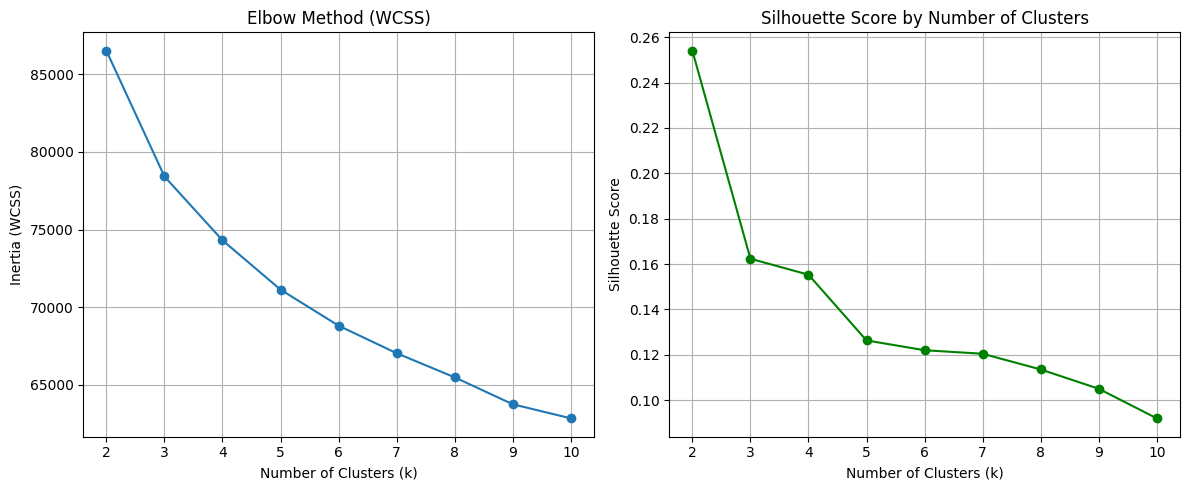

In [161]:
silhouette_scores = []
inertia = []
k_range = range(2, 11)  

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_scaled)
    
    inertia.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Plotting 2 charts: Elbow + Silhouette
plt.figure(figsize=(12, 5))

# Elbow (Inertia)
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method (WCSS)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.grid(True)

# Silhouette
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)

plt.tight_layout()
plt.show()

Phân cụm bằng thuật toán K-Means và trực quan hoá

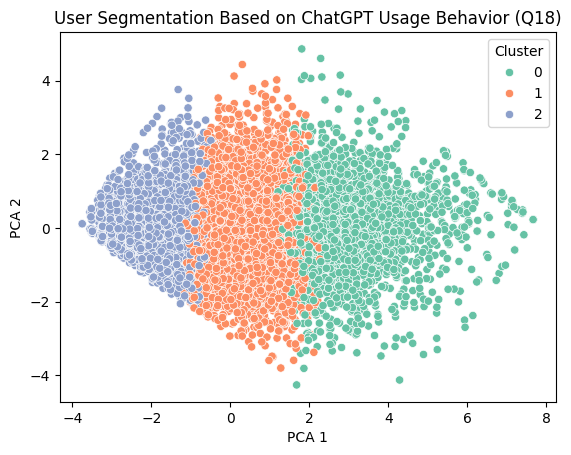

In [162]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_features['Cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_features['Cluster'], palette='Set2')
plt.title("User Segmentation Based on ChatGPT Usage Behavior (Q18)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [163]:
df_features.groupby('Cluster')[df_features.columns].mean().T

Cluster,0,1,2
Usage_Academic_Writing,3.583024,2.850218,1.863212
Usage_Professional_Writing,3.178571,1.932290,1.271244
Usage_Creative_Writing,3.125232,1.794306,1.339896
Usage_Proofreading,3.487941,2.442678,1.468394
Usage_Brainstorming,3.759276,3.031803,1.938083
Usage_Translating,3.319109,2.285201,1.524870
Usage_Summarizing,3.756957,2.978456,1.717617
Usage_Calculating_Help,3.065399,1.933573,1.388601
Usage_Study_Assistance,3.560297,2.406258,1.508549
Usage_Personal_Assistance,3.418831,2.384201,1.624093


Cluster 0 - Nhóm sử dụng ChatGPT nhiều nhất, sử dụng toàn diện
Cluster 1 - Nhóm sử dụng trung bình, dùng có chọn lọc, nghiêng về học tập và ý tưởng
Cluster 2 - Nhóm ít sử dụng, hầu như chưa khai thác công cụ

Thêm cột Field_Of_Study để phân cụm

In [164]:
likert_fos = {
    "Arts and Humanities": 1, "Social Sciences": 2, "Applied Sciences": 3, "Natural and Life Sciences": 4
}

df_features["Field_Of_Study"] = df['Field_Of_Study'].map(likert_fos)
df_features["Field_Of_Study"] = df_features["Field_Of_Study"].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

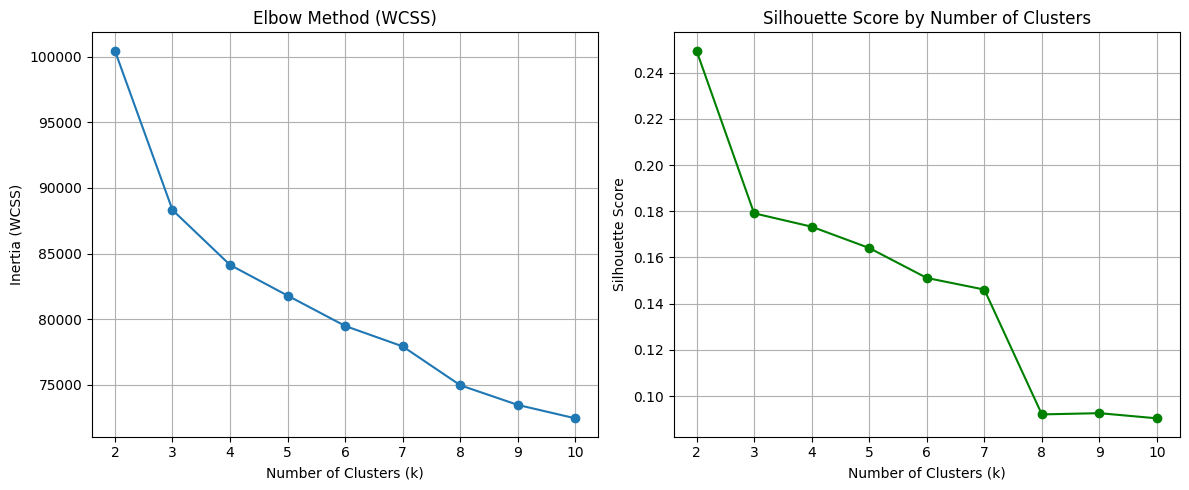

In [165]:
silhouette_scores = []
inertia = []
k_range = range(2, 11)  

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_scaled)
    
    inertia.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Vẽ 2 biểu đồ: Elbow + Silhouette
plt.figure(figsize=(12, 5))

# Elbow (Inertia)
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method (WCSS)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.grid(True)

# Silhouette
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)

plt.tight_layout()
plt.show()

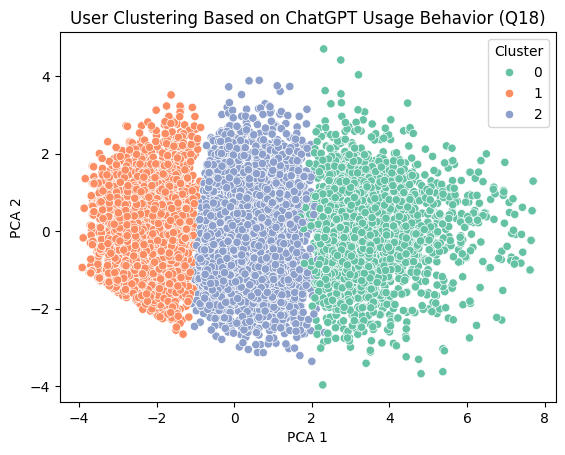

In [166]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_features['Cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_features['Cluster'], palette='Set2')
plt.title("User Clustering Based on ChatGPT Usage Behavior (Q18)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [167]:
df_features.groupby('Cluster')[df_features.columns].mean().T

Cluster,0,1,2
Usage_Academic_Writing,3.583024,1.863212,2.850218
Usage_Professional_Writing,3.178571,1.271244,1.932290
Usage_Creative_Writing,3.125232,1.339896,1.794306
Usage_Proofreading,3.487941,1.468394,2.442678
Usage_Brainstorming,3.759276,1.938083,3.031803
Usage_Translating,3.319109,1.524870,2.285201
Usage_Summarizing,3.756957,1.717617,2.978456
Usage_Calculating_Help,3.065399,1.388601,1.933573
Usage_Study_Assistance,3.560297,1.508549,2.406258
Usage_Personal_Assistance,3.418831,1.624093,2.384201


Cluster 0 - Người dùng tích cực
Cluster 1 - Người dùng vừa phải
Cluster 2 - Người dùng không thường xuyên

In [168]:
usage_cols = [
    "Usage_Academic_Writing", "Usage_Professional_Writing", "Usage_Creative_Writing",
    "Usage_Proofreading", "Usage_Brainstorming", "Usage_Translating",
    "Usage_Summarizing", "Usage_Calculating_Help", "Usage_Study_Assistance",
    "Usage_Personal_Assistance", "Usage_Research_Assistance", "Usage_Coding_Assistance"
]

field_map = {1: "Arts and Humanities", 2: "Social Sciences", 3: "Applied Sciences", 4: "Natural and Life Sciences"}
df_features['Field_Of_Study'] = df_features['Field_Of_Study'].astype(int).map(field_map)

avg_by_field = df_features.groupby("Field_Of_Study")[usage_cols].mean().round(2)
print(avg_by_field)

                           Usage_Academic_Writing  Usage_Professional_Writing  \
Field_Of_Study                                                                  
Applied Sciences                             2.70                        2.03   
Arts and Humanities                          2.55                        1.96   
Natural and Life Sciences                    2.59                        1.90   
Social Sciences                              2.59                        1.88   

                           Usage_Creative_Writing  Usage_Proofreading  \
Field_Of_Study                                                          
Applied Sciences                             1.92                2.36   
Arts and Humanities                          2.03                2.43   
Natural and Life Sciences                    1.80                2.27   
Social Sciences                              1.89                2.19   

                           Usage_Brainstorming  Usage_Translating  \
Field

In [169]:
# Thêm cột tổng điểm sử dụng ChatGPT
avg_by_field["Total_Usage"] = avg_by_field[usage_cols].sum(axis=1)

# Sắp xếp ngành học theo mức độ sử dụng giảm dần
avg_by_field_sorted = avg_by_field.sort_values(by="Total_Usage", ascending=False)

print(avg_by_field_sorted[["Total_Usage"]])

                           Total_Usage
Field_Of_Study                        
Applied Sciences                 29.01
Arts and Humanities              27.69
Natural and Life Sciences        27.20
Social Sciences                  26.71


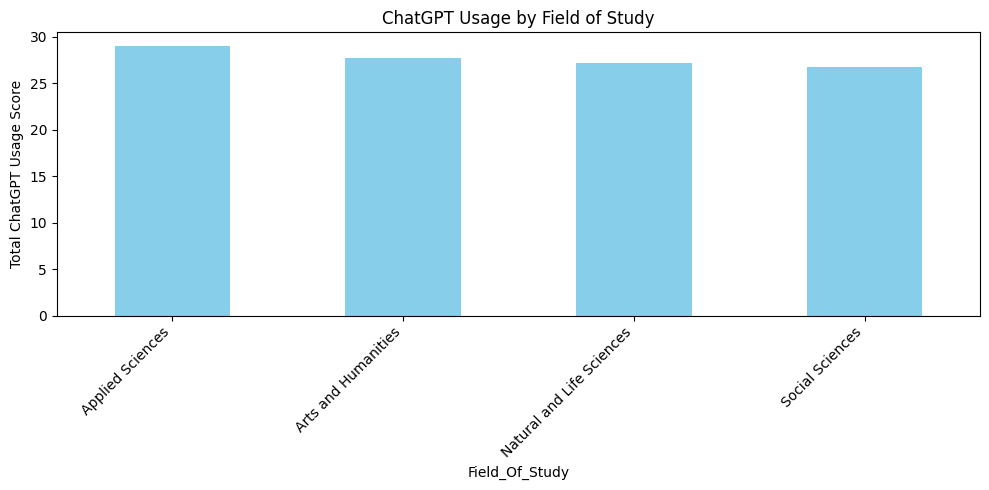

In [170]:
avg_by_field_sorted["Total_Usage"].plot(kind="bar", figsize=(10,5), color='skyblue')
plt.ylabel("Total ChatGPT Usage Score")
plt.title("ChatGPT Usage by Field of Study")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Điểm trung bình giữa các ngành học không có quá khác biệt, cho thấy việc sử dụng ChatGPT giữa các ngành học không quá khác biệt

Thêm các cột phát triển kỹ năng

In [171]:
likert_map = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5
}

cluster_columns = [col for col in df.columns if col.startswith(('Skills_Proficiency_', 'Skills_Analytical_'))]
df_features.drop(columns=['Field_Of_Study'], inplace=True, errors='ignore')

for col in cluster_columns:
    df_features[col] = df[col].map(likert_map).apply(pd.to_numeric, errors='coerce')

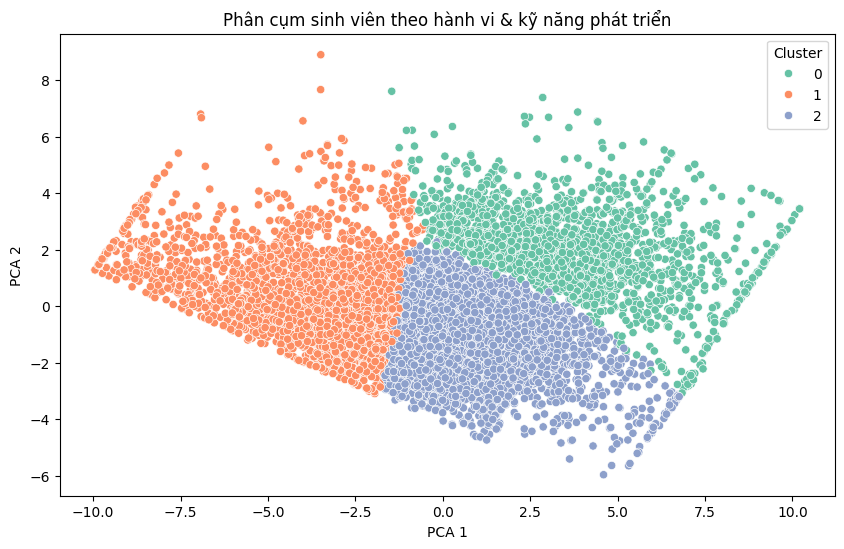

In [172]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

kmeans = KMeans(n_clusters=3, random_state=42)
df_features['Cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_features['Cluster'], palette='Set2')
plt.title("Phân cụm sinh viên theo hành vi & kỹ năng phát triển")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [173]:
df_features.groupby('Cluster')[df_features.columns].mean().T

Cluster,0,1,2
Usage_Academic_Writing,3.600854,2.023438,2.597222
Usage_Professional_Writing,3.170859,1.446250,1.732856
Usage_Creative_Writing,3.111058,1.460938,1.665799
Usage_Proofreading,3.482202,1.708438,2.150174
Usage_Brainstorming,3.768866,2.178750,2.711372
Usage_Translating,3.316089,1.729062,2.046875
Usage_Summarizing,3.761747,2.014063,2.598090
Usage_Calculating_Help,3.056004,1.499688,1.794705
Usage_Study_Assistance,3.554343,1.697188,2.161675
Usage_Personal_Assistance,3.420978,1.748750,2.198785


## Cluster 0
- Hành vi sử dụng: Sử dụng ChatGPT rất tích cực, nhất quán trên mọi chức năng
    + Brainstorming: 3.77
    + Summarizing: 3.76
    + Academic writing: 3.60
    + Study assistance: 3.56
    + Coding assistance: 3.27
- Kỹ năng phát triển: Cao đồng đều ở mọi kỹ năng, đặc biệt là:
    + Skills_Analytical_9 (AI literacy): 3.97
    + Skills_Analytical_7 (Data analysis): 3.83
    + Skills_Proficiency_9 (Content creation): 3.88
=> Đây là nhóm tận dụng ChatGPT toàn diện cho học tập, sáng tạo và kỹ thuật. Họ thấy ChatGPT giúp họ phát triển kỹ năng mạnh mẽ, đặc biệt trong lĩnh vực phân tích và công nghệ
## Cluster 1
- Hành vi sử dụng: Sử dụng mức trung bình
    + Brainstorming: 2.71
    + Summarizing: 2.60
    + Academic writing: 2.60
    + Coding assistance: 1.90
- Kỹ năng phát triển: Ở mức khá tốt, nhưng dưới 0 khoảng 0.2-0.3 điểm
    + AI literacy: 3.78
    + Content creation: 3.69
    + Data analysis: 3.68
=> Đây là nhóm sinh viên sử dụng ChatGPT chủ yếu cho các tác vụ cơ bản, thấy hữu ích nhưng không đến mức làm thay đổi kỹ năng mạnh mẽ như nhóm 0
## Cluster 2
- Hành vi sử dụng: Rất, gần như không sử dụng
    + Academic writing: 2.03
    + Brainstorming: 2.18
    + Coding assistance: 1.59
    + Creative writing: 1.46
- Kỹ năng phát triển: Thấp toàn diện
    + Decision making: 2.11
    + Critical thinking: 2.17
    + Communication: 2.16
=> Đây là nhóm ít hoặc không dùng ChatGPT, dẫn đến ít nhận thức được lợi ích về kỹ năng

# Phân tích các yếu tố ảnh hưởng đến sự tự tin xin việc

Phân bố mức độ tự tin xin việc

* Kiểm tra phân phối của Job_Confidence

In [174]:
job_conf_counts = df["Job_Confidence"].value_counts().sort_index()
job_conf_percent = job_conf_counts / job_conf_counts.sum() * 100

* Vẽ biểu đồ thể hiện phân phối

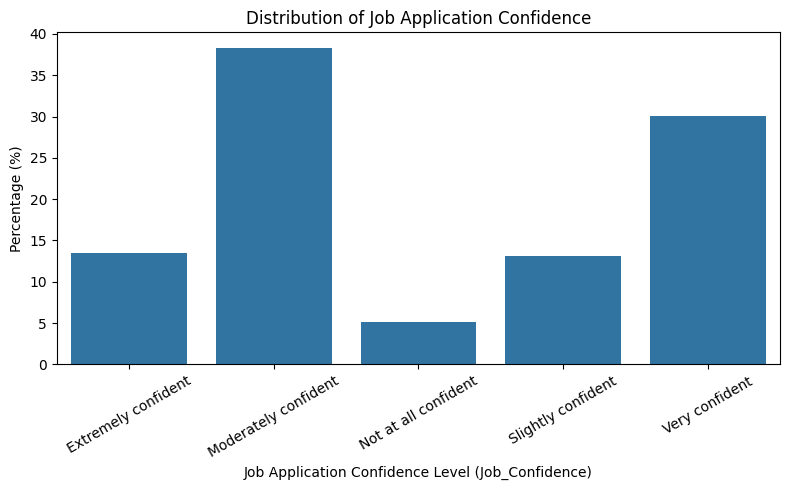

In [175]:
plt.figure(figsize=(8, 5))
sns.barplot(x=job_conf_percent.index, y=job_conf_percent.values)
plt.ylabel("Percentage (%)")
plt.xlabel("Job Application Confidence Level (Job_Confidence)")
plt.title("Distribution of Job Application Confidence")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Phân tích tương quan giữa Job_Confidence và các nhóm đặc trưng

* Nhân khẩu học (Demographic)

In [176]:
df = df.copy()

In [177]:
# Tính tuổi theo năm sinh
df['Age'] = datetime.now().year - df['Birthday_Year']

So sánh Job_Confidence theo độ tuổi (Age)

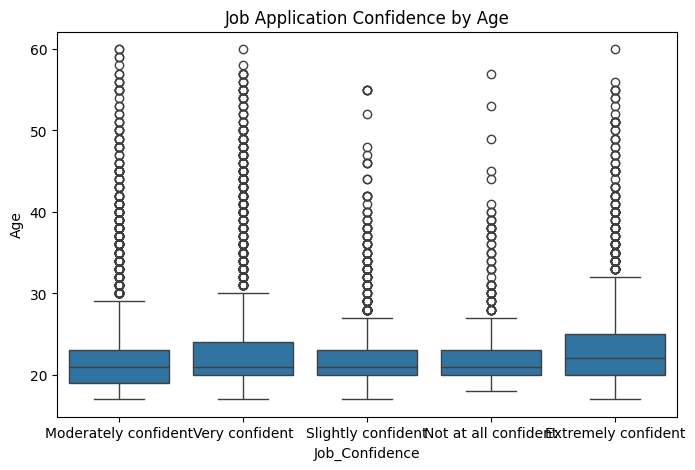

In [178]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Job_Confidence', y='Age', data=df)
plt.title("Job Application Confidence by Age")
plt.show()

So sánh Job_Confidence theo giới tính

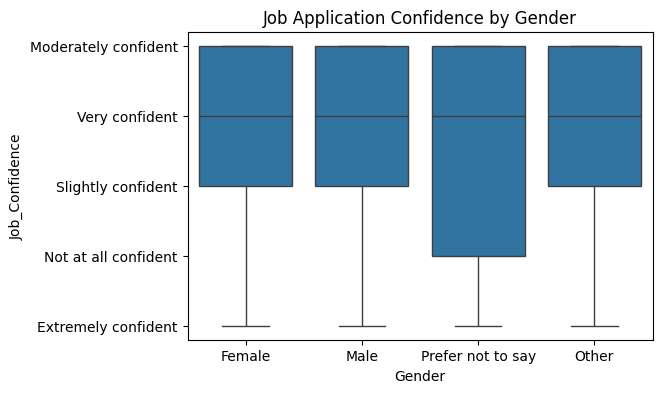

In [179]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Gender', y='Job_Confidence', data=df)
plt.title("Job Application Confidence by Gender")
plt.show()

So sánh theo trình độ học vấn

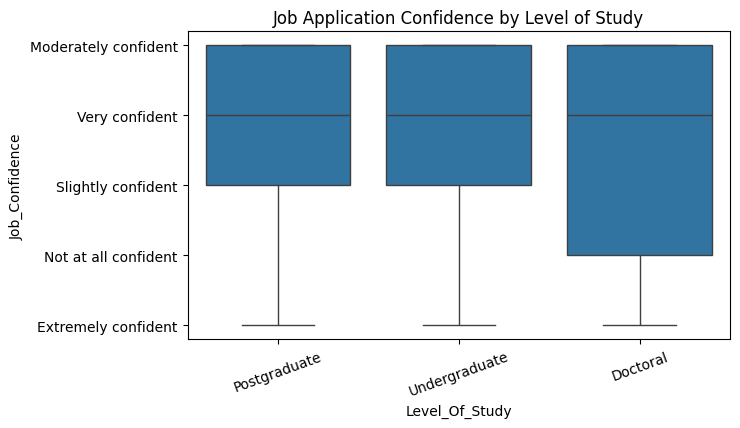

In [180]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='Level_Of_Study', y='Job_Confidence', data=df)
plt.title("Job Application Confidence by Level of Study")
plt.xticks(rotation=20)
plt.show()

So sánh theo ngành học

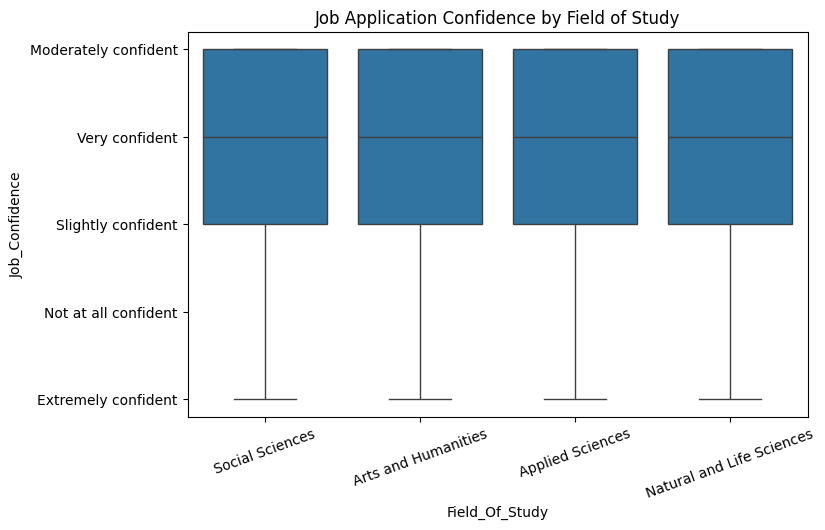

In [181]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Field_Of_Study', y='Job_Confidence', data=df)
plt.title("Job Application Confidence by Field of Study")
plt.xticks(rotation=20)
plt.show()

* Học tập 

Theo mức độ khó của việc học (Study_Difficulty)

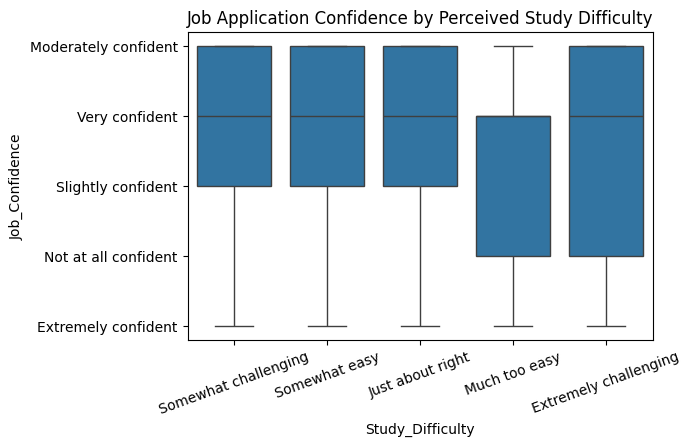

In [182]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Study_Difficulty', y='Job_Confidence', data=df)
plt.title("Job Application Confidence by Perceived Study Difficulty")
plt.xticks(rotation=20)
plt.show()

Theo phương pháp học hiện tại (Learning_Method)

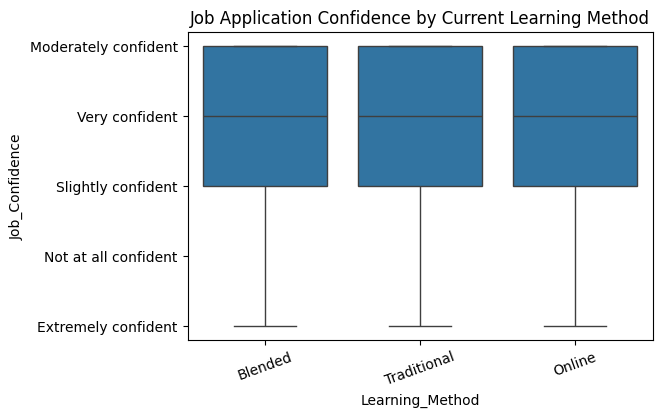

In [183]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Learning_Method', y='Job_Confidence', data=df)
plt.title("Job Application Confidence by Current Learning Method")
plt.xticks(rotation=20)
plt.show()

Theo phương pháp học ưu thích (Preferred_Learning_Method)

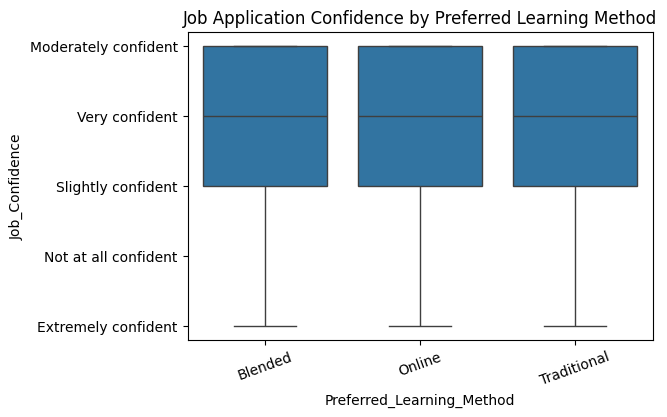

In [184]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Preferred_Learning_Method', y='Job_Confidence', data=df)
plt.title("Job Application Confidence by Preferred Learning Method")
plt.xticks(rotation=20)
plt.show()

* Các yếu tố liên quan đến cảm xúc, hành vi và trải nghiệm khi sử dụng ChatGPT.

Kiểm tra phân phối tần suất sử dụng ChatGPT và mức độ tự tin

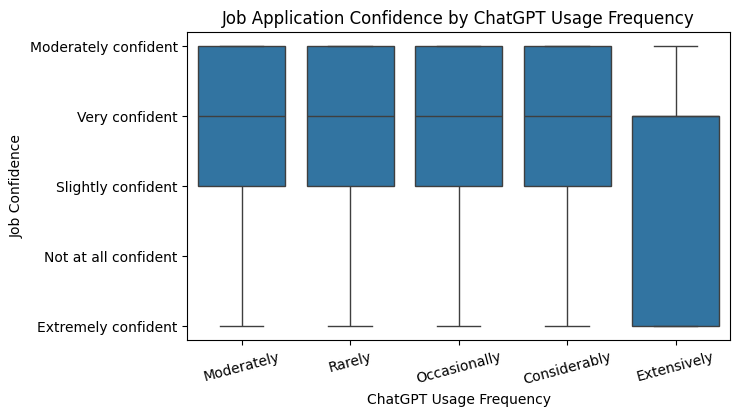

In [185]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='Usage_Frequency', y='Job_Confidence', data=df)
plt.title("Job Application Confidence by ChatGPT Usage Frequency")
plt.xlabel("ChatGPT Usage Frequency")
plt.ylabel("Job Confidence")
plt.xticks(rotation=15)
plt.show()

Kiểm tra mối liên hệ giữa trải nghiệm ChatGPT và sự tự tin

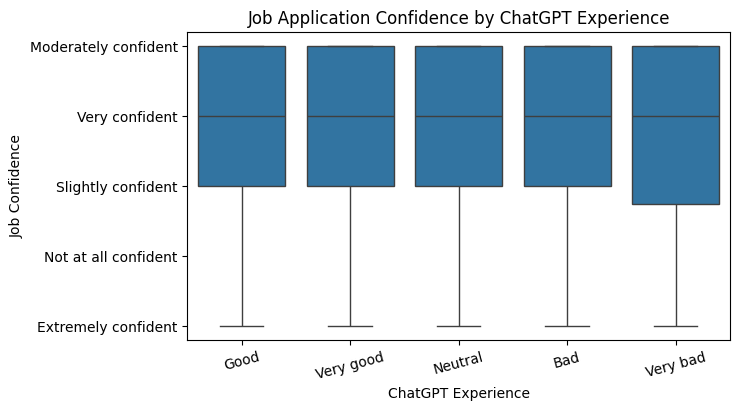

In [186]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='Overall_Experience', y='Job_Confidence', data=df)
plt.title("Job Application Confidence by ChatGPT Experience")
plt.xlabel("ChatGPT Experience")
plt.ylabel("Job Confidence")
plt.xticks(rotation=15)
plt.show()

* Kỹ năng & phát triển cá nhân

In [187]:
job_conf_reverse = {
    "Not at all confident": 1,
    "Slightly confident": 2,
    "Moderately confident": 3,
    "Very confident": 4,
    "Extremely confident": 5
}
df["Job_Confidence_Num"] = df["Job_Confidence"].map(job_conf_reverse)

In [188]:
skill_cols = [col for col in df.columns if col.startswith("Skills_Proficiency_")]
development_cols = [col for col in df.columns if col.startswith("Development_")]
study_info_cols = [col for col in df.columns if col.startswith("Study_Info_")]

In [189]:
target_cols = skill_cols + development_cols + study_info_cols

In [190]:
likert_reverse = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5
}
df[target_cols] = df[target_cols].replace(likert_reverse).infer_objects(copy=False)

C:\Users\ace\AppData\Local\Temp\ipykernel_17924\3444200881.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[target_cols] = df[target_cols].replace(likert_reverse).infer_objects(copy=False)


In [191]:
correlations = df[target_cols + ["Job_Confidence_Num"]].corr(numeric_only=True)["Job_Confidence_Num"].drop("Job_Confidence_Num").sort_values(ascending=False)

In [192]:
rename_map = {
    'Study_Info_1': 'Successful',
    'Study_Info_2': 'Attend_Classes',
    'Study_Info_3': 'Meet_Deadlines',
    'Study_Info_4': 'Grades_Reflect_Knowledge',
    'Study_Info_5': 'Motivated_To_Study',
    'Study_Info_6': 'Enough_Financial_Aid',
    'Study_Info_7': 'Taxes_Too_High',
    'Study_Info_8': 'Strong_Social_Network',
    'Study_Info_9': 'Strong_Skill_Set',
    'Study_Info_10': 'Enough_Work_Experience',
    'Study_Info_11': 'Enough_General_Knowledge',
    'Study_Info_12': 'Enough_Specific_Knowledge',
    'Study_Info_13': 'Faculty_Enhances_Employability',
    'Study_Info_14': 'Want_Job_In_Field',
    'Study_Info_15': 'Personal_Satisfaction',
    'Skills_Proficiency_1': 'Academic_Writing',
    'Skills_Proficiency_2': 'Professional_Writing',
    'Skills_Proficiency_3': 'Typing',
    'Skills_Proficiency_4': 'Native_Language',
    'Skills_Proficiency_5': 'Foreign_Language',
    'Skills_Proficiency_6': 'Interpersonal_Communication',
    'Skills_Proficiency_7': 'Digital_Communication',
    'Skills_Proficiency_8': 'Information_Literacy',
    'Skills_Proficiency_9': 'Digital_Content_Creation',
    'Development_1': 'Exam_Readiness',
    'Development_2': 'Improve_Grades',
    'Development_3': 'Complete_Outside_Activities',
    'Development_4': 'Complete_Internships',
    'Development_5': 'Learning_Experience',
    'Development_6': 'Improve_Skills',
    'Development_7': 'Personal_Development',
    'Development_8': 'Academic_Development',
    'Development_9': 'Study_Satisfaction',
    'Development_10': 'Improve_Employability'
}

correlations_named = correlations.rename(index=rename_map)

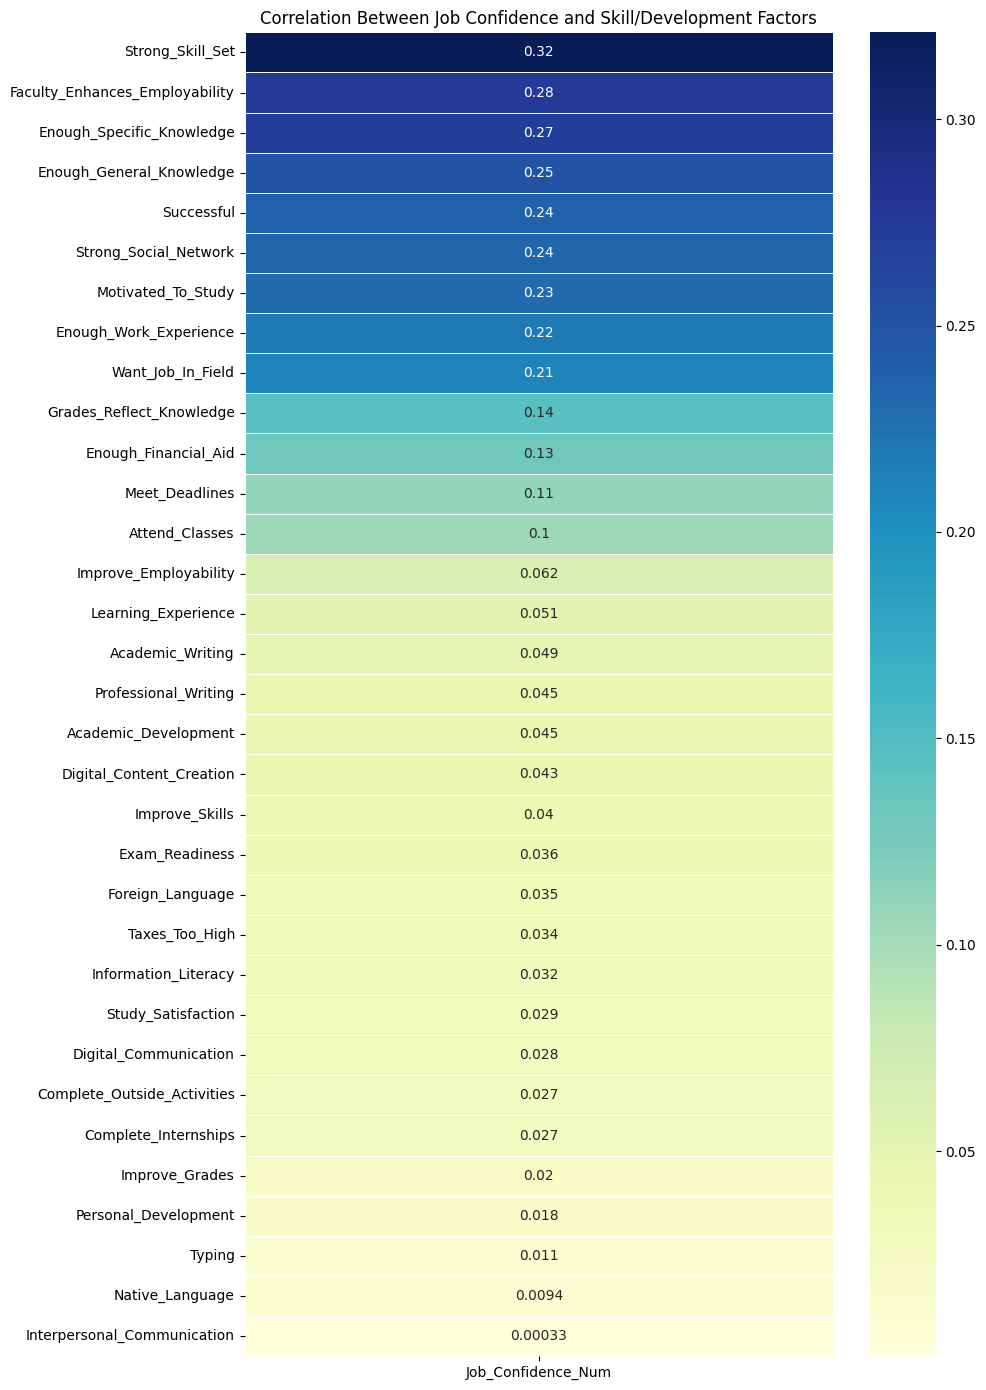

In [193]:
plt.figure(figsize=(10, 14))
sns.heatmap(correlations_named.to_frame(), annot=True, cmap='YlGnBu', linewidths=0.5)
plt.title("Correlation Between Job Confidence and Skill/Development Factors")
plt.tight_layout()
plt.show()

Các yếu tố tương quan mạnh với Job_Confidence như: Development_Employability, Skills_Proficiency_Professional_Writing, Study_Info_Enough_Work_Experience, Development_Personal_Development, Study_Info_Strong_Skill_Set cho thấy những sinh viên có sự tự tin vào kỹ năng chuyên môn, kinh nghiệm thực tế và cảm thấy chương trình học có giá trị với việc làm thường có mức tự tin xin việc cao hơn.

Các yếu tố tương quan yếu hoặc gần như không tương quan như: Skills_Proficiency_Typing, Study_Info_Taxes_Too_High, Development_Complete_Internships cho thấy những yếu tố như kỹ năng đánh máy, hoặc các yếu tố không trực tiếp liên quan đến năng lực xin việc (ví dụ cảm nhận về thuế) không ảnh hưởng nhiều đến mức độ tự tin.

Những yếu tố quan trọng nhất ảnh hưởng đến Job_Confidence là:
* Cảm nhận về khả năng xin việc (Employability)
* Kỹ năng viết chuyên nghiệp
* Kinh nghiệm làm việc
* Bộ kỹ năng tổng thể
* Phát triển bản thân thông qua học tập

=> Những yếu tố này có thể là mục tiêu để cải thiện sự tự tin xin việc của sinh viên.

TRỰC QUAN HÓA VÀ TỔNG HỢP

* Hiển thị 5 biến tương quan cao nhất với Job_Confidence_Num

In [194]:
correlations_named.head(5)

Strong_Skill_Set                  0.321044
Faculty_Enhances_Employability    0.275107
Enough_Specific_Knowledge         0.271285
Enough_General_Knowledge          0.250338
Successful                        0.237536
Name: Job_Confidence_Num, dtype: float64

* Trực quan hoá chi tiết các biến mạnh

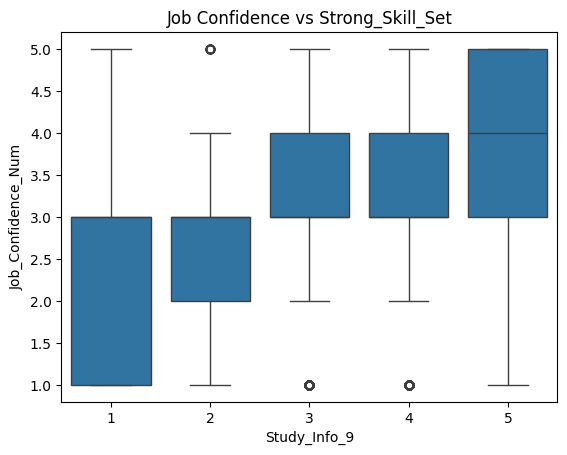

In [195]:
# Strong_Skill_Set
sns.boxplot(x="Study_Info_9", y="Job_Confidence_Num", data=df)
plt.title("Job Confidence vs Strong_Skill_Set")
plt.show()

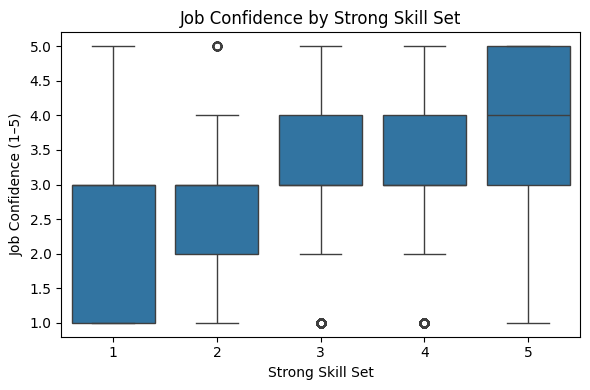

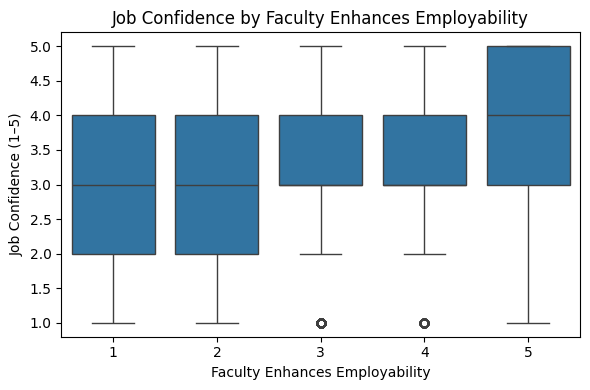

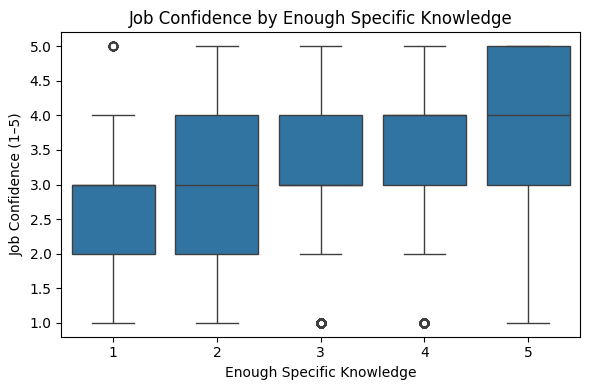

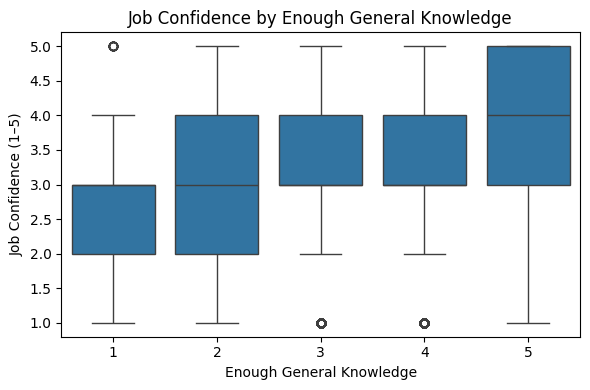

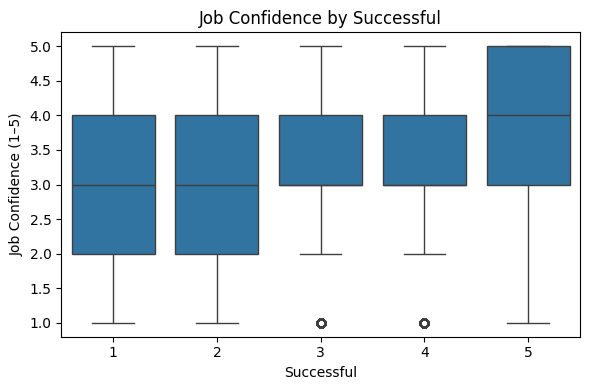

In [196]:
top5_features = correlations.head(5).index.tolist()

for feature in top5_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[feature], y=df["Job_Confidence_Num"])
    title_name = rename_map.get(feature, feature).replace('_', ' ')
    plt.title(f"Job Confidence by {title_name}")
    plt.xlabel(title_name)
    plt.ylabel("Job Confidence (1–5)")
    plt.tight_layout()
    plt.show()

* Trực quan hoá mức độ tương quan giữa Job_Confidence_Num và

    * Nhóm kỹ năng (bắt đầu bằng Skills_Proficiency_)

    * Nhóm phát triển (bắt đầu bằng Development_)

    * Nhóm thông tin học tập (bắt đầu bằng Study_Info_)

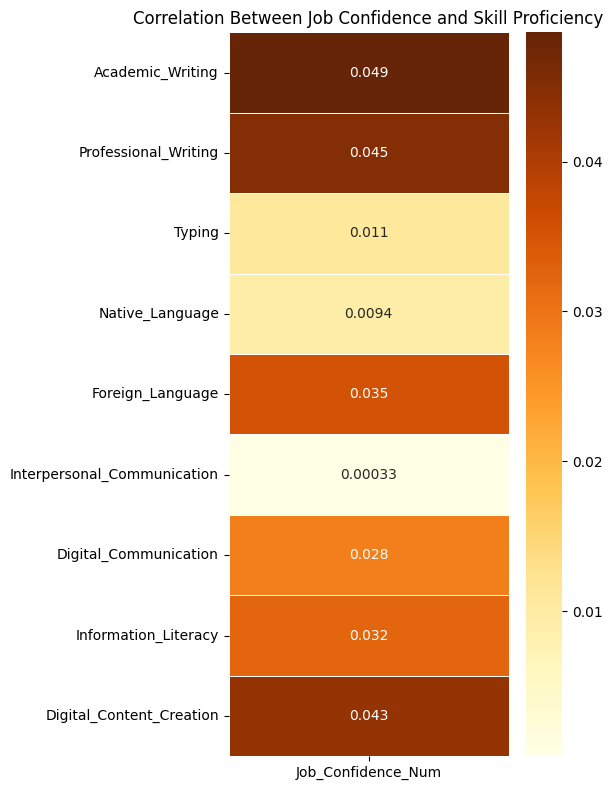

In [197]:
# Kỹ năng
skills_corr = df[skill_cols + ["Job_Confidence_Num"]].corr(numeric_only=True)["Job_Confidence_Num"].drop("Job_Confidence_Num")
skills_corr_named = skills_corr.rename(index=rename_map)

plt.figure(figsize=(6, 8))
sns.heatmap(skills_corr_named.to_frame(), annot=True, cmap='YlOrBr', linewidths=0.5)
plt.title("Correlation Between Job Confidence and Skill Proficiency")
plt.tight_layout()
plt.show()

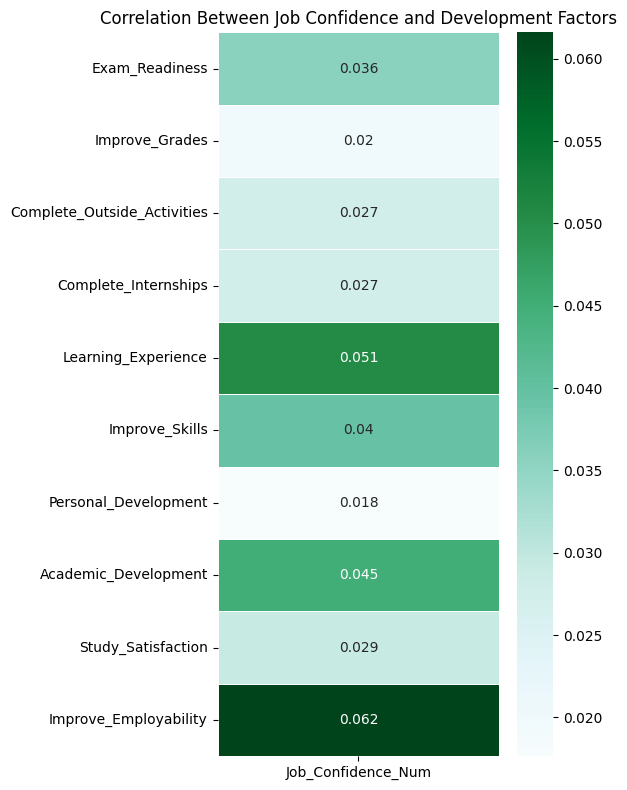

In [198]:
# Phát triển học tập
develop_corr = df[development_cols + ["Job_Confidence_Num"]].corr(numeric_only=True)["Job_Confidence_Num"].drop("Job_Confidence_Num")
develop_corr_named = develop_corr.rename(index=rename_map)

plt.figure(figsize=(6, 8))
sns.heatmap(develop_corr_named.to_frame(), annot=True, cmap='BuGn', linewidths=0.5)
plt.title("Correlation Between Job Confidence and Development Factors")
plt.tight_layout()
plt.show()

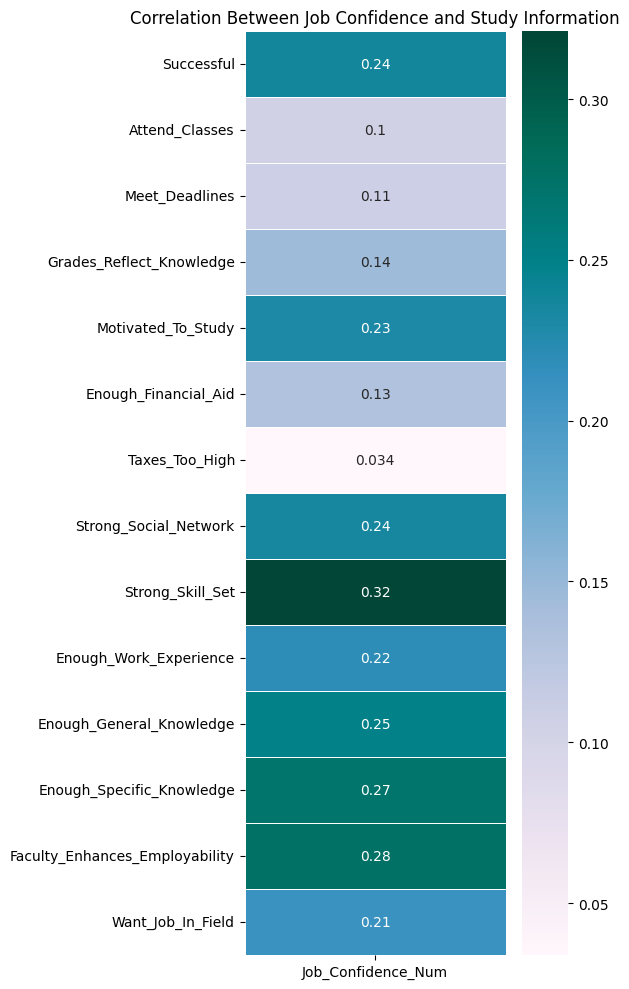

In [199]:
# Thông tin học tập
study_corr = df[study_info_cols + ["Job_Confidence_Num"]].corr(numeric_only=True)["Job_Confidence_Num"].drop("Job_Confidence_Num")
study_corr_named = study_corr.rename(index=rename_map)

plt.figure(figsize=(6, 10))
sns.heatmap(study_corr_named.to_frame(), annot=True, cmap='PuBuGn', linewidths=0.5)
plt.title("Correlation Between Job Confidence and Study Information")
plt.tight_layout()
plt.show()

* So sánh trực quan từng nhóm yếu tố để xác định:

    * Yếu tố nào ảnh hưởng mạnh đến sự tự tin

    * Nhóm nào có mối liên hệ mạnh nhất



In [200]:
mean_corrs = pd.DataFrame({
    "Group": ["Skills", "Development", "Study_Info"],
    "Mean_Correlation": [
        skills_corr.mean(),
        develop_corr.mean(),
        study_corr.mean()
    ],
    "Max_Correlation": [
        skills_corr.max(),
        develop_corr.max(),
        study_corr.max()
    ]
})

print(mean_corrs)

         Group  Mean_Correlation  Max_Correlation
0       Skills          0.028139         0.048624
1  Development          0.035396         0.061606
2   Study_Info          0.198232         0.321044


Đây là kết quả so sánh mức độ tương quan trung bình và lớn nhất giữa các nhóm yếu tố kỹ năng và phát triển với mức độ tự tin xin việc (Job_Confidence).
Nhóm Study_Info cho thấy có tương quan mạnh nhất.

XÂY MÔ HÌNH DỰ ĐOÁN

In [201]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [202]:
correlations = df.corr(numeric_only=True)["Job_Confidence_Num"].drop("Job_Confidence_Num")
top10_features = correlations.abs().sort_values(ascending=False).head(10).index.tolist()

* Chọn X và y

In [203]:
X = df[top10_features]
y = df["Job_Confidence_Num"]

* Xử lý thiếu dữ liệu

In [204]:
X = X.dropna()
y = y[X.index]

* Tách dữ liệu train/test

In [205]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

* Huấn luyện mô hình Random Forest

In [206]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

* Đánh giá

In [207]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.3857791225416036

Classification Report:
               precision    recall  f1-score   support

           1       0.26      0.10      0.15       107
           2       0.19      0.10      0.13       265
           3       0.43      0.58      0.50       754
           4       0.38      0.39      0.39       589
           5       0.32      0.23      0.27       268

    accuracy                           0.39      1983
   macro avg       0.32      0.28      0.29      1983
weighted avg       0.36      0.39      0.36      1983



Độ chính xác tổng thể (Accuracy)

Accuracy : 0.39

-> 39% mẫu trong tập test được dự đoán đúng mức độ tự tin xin việc. Đây là mức khá thấp với dữ liệu xã hội có nhiều yếu tố cảm tính.

Precision: Xác suất dự đoán đúng trong các lần mô hình đoán là mức đó.

Recall: Khả năng tìm đúng tất cả các mẫu thực sự thuộc mức đó.

F1-score: Trung bình hài hòa giữa precision và recall.

→ Nhìn chung:

Các mức 3, 4 có F1 khá tốt (trên 0.39).

Mức 1, 2, 5 hơi thấp, có thể do ít dữ liệu hơn (support thấp).

* Ma trận nhầm lẫn

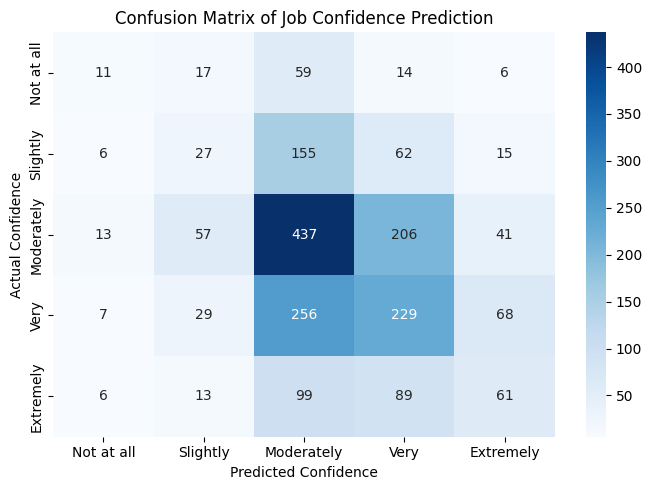

In [208]:
labels = [1, 2, 3, 4, 5]
label_names = [
    "Not at all", "Slightly", "Moderately", "Very", "Extremely"
]

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted Confidence")
plt.ylabel("Actual Confidence")
plt.title("Confusion Matrix of Job Confidence Prediction")
plt.tight_layout()
plt.show()

In [209]:
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

display(report_df.round(2))

,precision,recall,f1-score,support
1,0.26,0.10,0.15,107.00
2,0.19,0.10,0.13,265.00
3,0.43,0.58,0.50,754.00
4,0.38,0.39,0.39,589.00
5,0.32,0.23,0.27,268.00
accuracy,0.39,0.39,0.39,0.39
macro avg,0.32,0.28,0.29,1983.00
weighted avg,0.36,0.39,0.36,1983.00


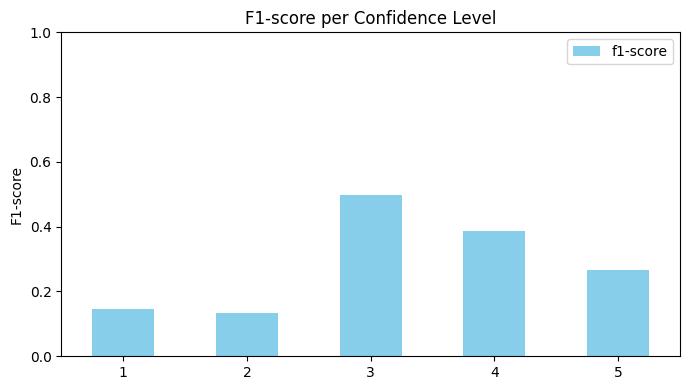

In [210]:
report_df.iloc[:-3][['f1-score']].plot(kind='bar', figsize=(7, 4), color='skyblue')
plt.title("F1-score per Confidence Level")
plt.ylabel("F1-score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

***Phân tích cụm Q24***

In [211]:
file_path = "final_data.xlsx"
df = pd.read_excel(file_path)

In [212]:
# Danh sach cac cot thuoc cum Q24 (Q24a -> Q24g)
q24_cols = [
    "Satisfaction_More_Useful_Than_Google",
    "Satisfaction_Easier_Than_Professors",
    "Satisfaction_Easier_Than_Colleagues",
    "Satisfaction_Clearer_Than_Professors",
    "Satisfaction_Satisfied_Assistance",
    "Satisfaction_Satisfied_Quality",
    "Satisfaction_Satisfied_Accuracy"
]

In [213]:
# Thang do danh gia tu 1 den 5
rating_labels = {
    1: "Strongly disagree",
    2: "Disagree",
    3: "Neutral",
    4: "Agree",
    5: "Strongly agree"
}

C:\Users\ace\AppData\Local\Temp\ipykernel_17924\98050376.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data.values, palette="viridis")


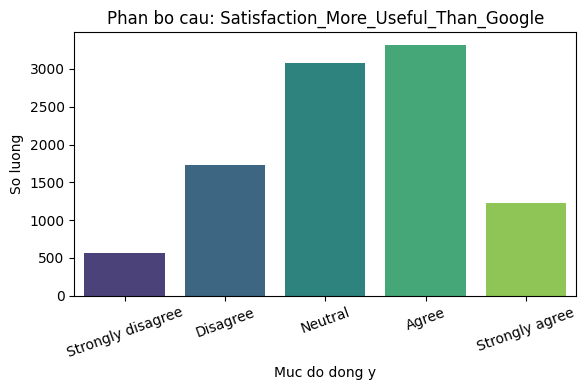

C:\Users\ace\AppData\Local\Temp\ipykernel_17924\98050376.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data.values, palette="viridis")


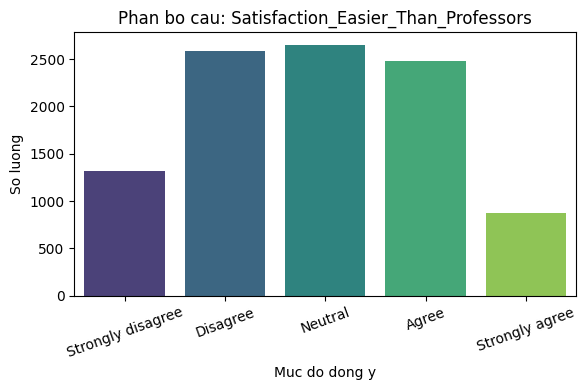

C:\Users\ace\AppData\Local\Temp\ipykernel_17924\98050376.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data.values, palette="viridis")


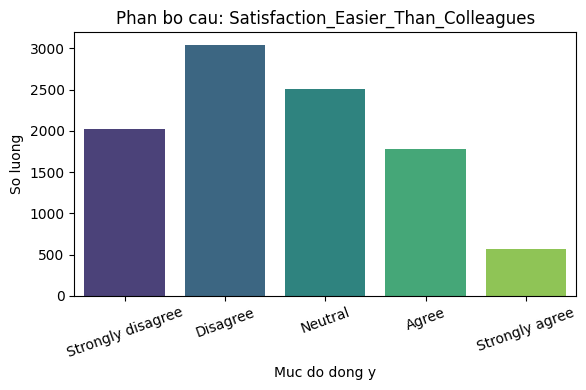

C:\Users\ace\AppData\Local\Temp\ipykernel_17924\98050376.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data.values, palette="viridis")


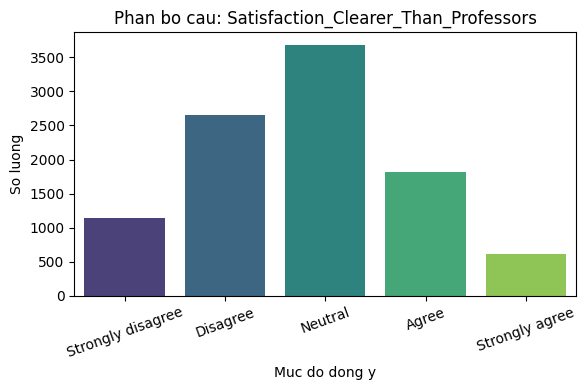

C:\Users\ace\AppData\Local\Temp\ipykernel_17924\98050376.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data.values, palette="viridis")


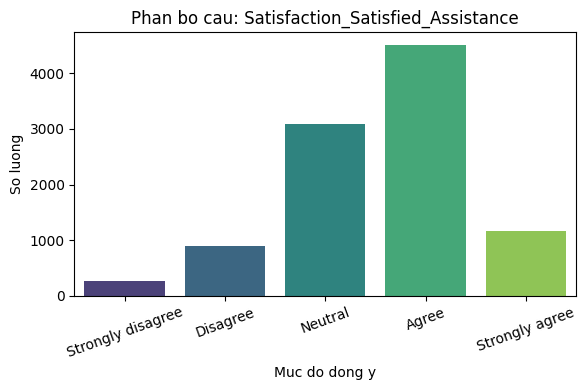

C:\Users\ace\AppData\Local\Temp\ipykernel_17924\98050376.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data.values, palette="viridis")


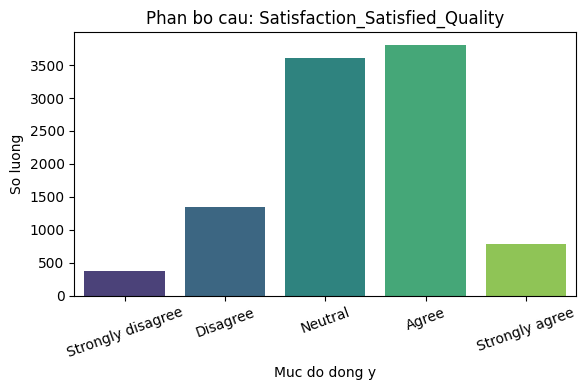

C:\Users\ace\AppData\Local\Temp\ipykernel_17924\98050376.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data.values, palette="viridis")


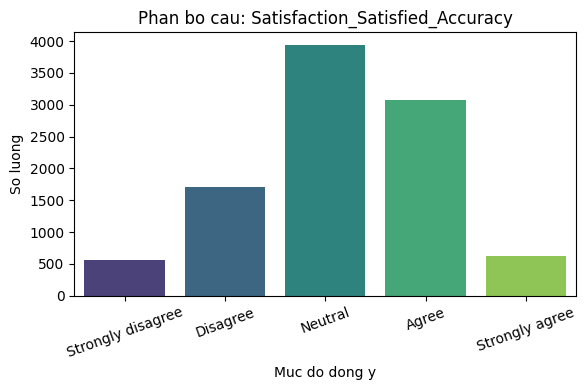

In [215]:
# Phân tích và vẽ biểu đồ từng câu trong Q24
for col in q24_cols:
    if col in df.columns:
        values = df[col].dropna().unique()
        
        # Nếu là dạng số → map sang chuỗi
        if all(isinstance(v, (int, float)) for v in values):
            data = df[col].map(rating_labels).value_counts().reindex(rating_labels.values(), fill_value=0)
        else:
            data = df[col].value_counts().reindex(rating_labels.values(), fill_value=0)

        # Vẽ biểu đồ cột
        plt.figure(figsize=(6, 4))
        sns.barplot(x=data.index, y=data.values, palette="viridis")
        plt.title(f"Phan bo cau: {col}", fontsize=12)
        plt.xlabel("Muc do dong y")
        plt.ylabel("So luong")
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Cot {col} khong tim thay trong du lieu.")
